# Reporting — granular varieties, comparative advantage at the attraction-area level

Companion to `analysis.ipynb` (the continuum / ZE-level reporting), for runs made with
`./run.sh <industry> --granular=true --ca_level=aa`.

What differs from the old notebook:

* the moment vector has a sixth block, $\bar G_s(0)$, and the $\gamma$ block lives at the
  **attraction-area** level rather than the ZE level;
* the combined table reports the labor share and the industry shares only;
* the cloglog distance coefficients and $\bar G_s(0)$ get their own figures, empirical
  against simulated, **with standard errors**;
* the Jacobian and the moment variance-covariance matrices get block-structured
  heatmaps, so which parameter block moves which moment block can be read off. The
  parameter axis now includes the **variety counts** $N_s$, on the same footing as the
  comparative advantages $T_{as}$: both are calibrated inside the model rather than
  searched over, and both belong in a picture of what the model's parameters do;
* every elasticity heatmap comes as a **triptych** — the matrix, the cells whose
  elasticity is drowned in simulation noise, and the matrix with those cells blanked —
  because an elasticity estimated from simulated moments is only readable where its
  Monte-Carlo standard deviation is small relative to its own size;
* a sensitivity / identification section thresholds the same elasticities, so the
  near-orthogonality of the $\alpha$ / $T_{as}$ / $N_s$ channels can be read off directly;
* an untargeted-moment section estimates, by Poisson pseudo-maximum-likelihood
  (`pyfixest.fepois`) on the simulated firm-level economy, the distance elasticity
  $\eta$ of $\mathbb{E}[a_{ir}]$ — under a sector $\times$ buyer-region effect, a
  **supplier** effect and both — and compares it with the reduced-form $\delta/\gamma$
  of Table 3, on the reduced form's own scale rather than as a raw elasticity;
* a comparative-advantage section weighs $T_{as}$ against distance within each sector, as
  **six tests taken one at a time**: the spread of $\hat T$, what it is worth in distance,
  whether the favoured area actually wins buyer by buyer, which force disperses the
  competition, what the Sinkhorn inversion implies for the covariance term, and the
  allocation of winners with one force switched off;
* an amplification section reproduces Figure 6 — the coefficient $D_r$ and the share
  of upstream sales within a radius of the shock, the radius being a free parameter;
* the loader takes `mu = 1` (step-1 best parameters) or `mu = 2` (step-3 best parameters).

`load_granular_data` returns a flat dict, so the `analysis.ipynb` pattern still works:

```python
data = load_granular_data(industry, mu=2)
globals().update(data)
```

**How the notebook is organised.** Every section is a pair: one cell that *defines* its
functions, one cell that *runs* it on both industries and writes its figures. Each pair
can be executed on its own, and the last cell of the notebook (`Full Run`) re-executes
all of them in order for a clean end-to-end pass. A new figure therefore has to be added
in two places: its own section's run cell, and the full run.


## Setup

In [245]:
%pip install matplotlib pandas statsmodels seaborn geopandas pyfixest pyarrow


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [246]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.api as sm
import pyfixest as pf          # PPML with absorbed fixed effects (ppmlhdfe)

try:
    import geopandas as gpd
except Exception:            # maps are optional in this notebook
    gpd = None
try:
    import seaborn as sns
except Exception:
    sns = None

# ---------------------------------------------------------------- style
document_width_pt = 511.0
plt.rc("font", family="serif")
toulouse_color = (132 / 255, 46 / 255, 27 / 255)
reference_color = toulouse_color#(0.75, 0.30, 0.20)
sim_color = (0.247, 0.404, 0.667)
font_size = 15
plt.rcParams.update({
    "font.size": font_size,
    "axes.labelsize": font_size,
    "axes.titlesize": font_size + 2,
    "xtick.labelsize": font_size - 3,
    "ytick.labelsize": font_size - 3,
    "legend.fontsize": font_size - 3,
    "legend.title_fontsize": font_size,
    "figure.titlesize": font_size,
})


def get_figsize(document_width_pt=document_width_pt, wf=1.0, hf=0.5):
    """Figure size in inches from a LaTeX \\showthe\\columnwidth width in points."""
    fig_width = document_width_pt * wf / 72.27
    return [fig_width, fig_width * hf]


def _despine(ax=None):
    if sns is not None:
        sns.despine(ax=ax)
    else:
        for side in ("top", "right"):
            (ax or plt.gca()).spines[side].set_visible(False)


## Loading

`load_granular_data` rebuilds on the Python side the moment layout that
`load_parameters.jl` builds under `--granular=true --ca_level=aa`. The full (unmasked)
moment vector stacks six blocks in this order:

| # | block | length | content |
|---|-------|--------|---------|
| 1 | labor          | 1 | aggregate labor share |
| 2 | industry share | $S$ | share of the downstream industry's input bill going to each sector |
| 3 | $\pi_r$        | $R_d$ | share of downstream sales made in each downstream region |
| 4 | reg_coef       | $N_{REG}$ | distance-bin coefficients of the extensive margin (cloglog) |
| 5 | $\gamma$       | $S \times n_{AA}$ | sourcing shares by (sector, attraction area), sector-major |
| 6 | $\bar G_s(0)$  | $S$ | share of regions hosting no supplier of sector $s$ |

The criterion does not use all of them. `MOMENT_MASK` drops the first industry share and
the first $\pi_r$ (both are implied by the others adding up), every (sector, area) pair
with no observed supplier, and, in each sector, the **reference area** — the one with the
largest observed sourcing share, which the within-sector adding-up constraint determines
once the others are known. Block 6 is never masked.

**Which estimate is being reported.** `mu` selects it, and it selects *everything*
consistently — moments, standard errors, Jacobian, and the simulated firm-level economy:

| `mu` | estimate | moments | inference |
|------|----------|---------|-----------|
| 1 | $\hat\theta_1$, the Step-1 identity-weighted fit | `step1/best_simulated_moments.npy` | `step2/inference/` (inference *at* $\hat\theta_1$ is written there) |
| 2 | $\hat\theta_2$, the Step-3 efficiently-weighted fit | `step3/best_simulated_moments.npy` | `step3/inference/` |

The run folder is reconstructed from the flags rather than passed as a path, so a
mismatch between the flags used for estimation and the flags used here surfaces as a
missing folder instead of a plausible-looking but wrong set of numbers.


In [247]:
# Rebuilds, on the Python side, the moment layout `load_parameters.jl` builds under
# `--granular=true --ca_level=aa`, and reads back everything the reporting needs.
# The block layout, the mask and the meaning of `mu` are documented in the markdown
# cell above.

# mu -> (folder holding the moments, folder holding the inference)
MU_DIRS = {1: ("step1", "step2"), 2: ("step3", "step3")}


def reporting_folder(industry, base="..", profile_T=True, ca_level="aa",
                     granular=True, relax_n_lo=False, optimizer="pso"):
    """Reproduce main.jl's output_folder naming exactly."""
    name = f"reporting_{industry}"
    name += "_profiled" if profile_T else ""
    name += "_aa" if ca_level == "aa" else ""
    name += "_gran" if granular else ""
    name += "_nlo1" if (relax_n_lo and granular) else ""
    name += f"_{optimizer}"
    return Path(base) / name


def _read_named_value(coefs, name):
    """stats.csv scalar by name: a column called `name`, else a labelled row."""
    if name in coefs.columns:
        vals = coefs[name].dropna().values
        if len(vals):
            return float(vals[0])
    if "value" in coefs.columns:
        for col in coefs.columns:
            hit = coefs.index[coefs[col].astype(str).str.strip().str.lower() == name.lower()]
            if len(hit):
                return float(coefs.loc[hit[0], "value"])
    return None


def _gk_col(G_K, cands):
    """Column of G_K.csv by case-insensitive name, mirroring load_parameters.jl's _gk_col."""
    hit = next((c for c in G_K.columns if c.strip().lower() in cands), None)
    if hit is None:
        raise KeyError(f"G_K.csv is missing a column among {cands}; has {list(G_K.columns)}")
    return hit


def _as_ze_string(col):
    """ZE codes as 4-character strings, whether the column came back as int, float or str."""
    if pd.api.types.is_numeric_dtype(col):
        return col.astype("Int64").astype(str).str.zfill(4)
    return col.astype(str).str.strip().str.replace(r"\.0$", "", regex=True).str.zfill(4)


def _aa_names(X_dr, n_AA):
    """
    Attraction-area names, in the model's AA column order.

    AA column `a` is anchored on the a-th downstream region, and the downstream
    regions are enumerated in ZE-index (sorted ze2010) order — which is the row
    order of X_dr.csv restricted to the downstream rows. The names live in
    `X_dr.query('downstream').ze2010_downstream`.
    """
    flag = next((c for c in ("downstream", "downstream_region") if c in X_dr.columns), None)
    if flag is None:
        raise KeyError("X_dr.csv has neither a `downstream` nor a `downstream_region` column")
    sub = X_dr[X_dr[flag].astype(bool)]
    col = next((c for c in ("ze2010_downstream", "ze2010") if c in sub.columns), None)
    if col is None:
        raise KeyError("X_dr.csv has neither `ze2010_downstream` nor `ze2010`")
    names = _as_ze_string(sub[col]).tolist()
    if len(names) != n_AA:
        raise ValueError(f"{len(names)} downstream rows in X_dr.csv vs n_AA = {n_AA} "
                         "attraction areas in attraction_area_linkages.npy")
    return names


def _region_labels(data):
    """
    Model region index (1..R) -> ZE code -> display NAME.

    The model orders regions by sorted `ze2010`, exactly as `load_parameters.jl` builds
    `X_rs`, so the l-th row of the distance matrix and the integer codes in
    `suppliers.parquet` are the l-th entry of that sorted list. `france` covers more
    commuting zones than the model does, so the join is on the CODE, and a zone with no
    name falls back to its code rather than to NaN.
    """
    fdf = data.get("filter_N_upstream_df")
    if fdf is None:
        codes = [str(i) for i in range(1, data["R"] + 1)]
    else:
        codes = sorted(_as_ze_string(fdf["ze2010"]).unique())
    if len(codes) != data["R"]:
        raise ValueError(f"{len(codes)} ZE codes in filter_N_upstream.csv but R = "
                         f"{data['R']} regions in the model.")
    out = pd.DataFrame({"index": np.arange(1, data["R"] + 1), "ze2010": codes})
    fr = data.get("france")
    if fr is not None and "ze2010_name" in fr.columns:
        names = fr[["ze2010", "ze2010_name"]].copy()
        names["ze2010"] = _as_ze_string(names["ze2010"])
        out = out.merge(names.drop_duplicates("ze2010"), on="ze2010", how="left")
    else:
        out["ze2010_name"] = out["ze2010"]
    out["ze2010_name"] = out["ze2010_name"].fillna(out["ze2010"])
    return out


def ze_name_of_code(data):
    """ZE code -> display name, for anything keyed on the code rather than the index."""
    lab = _region_labels(data)
    return dict(zip(lab["ze2010"], lab["ze2010_name"]))


def aa_display_names(data):
    """
    Attraction-area display names, in AA column order.

    Area `a` is anchored on the a-th downstream region, so its name is that commuting
    zone's name — which is what a reader recognises, unlike the bare ZE code.
    """
    m = ze_name_of_code(data)
    return [m.get(str(a), str(a)) for a in data["aa_names"]]


def load_granular_data(industry, mu=2, base="..", profile_T=True, ca_level="aa",
                       granular=True, relax_n_lo=False, optimizer="pso", K=-1,
                       k_max=None):
    """
    Load everything the granular / attraction-area reporting needs.

    Parameters
    ----------
    industry : str          "aero", "auto", ...
    mu       : 1 or 2       1 = step1 best parameters (mu_1), 2 = step3 best
                            parameters (mu_2, the efficient estimate).
    K        : int          which stage column of best_simulated_moments to read
                            (-1 = the last, i.e. the final stage of the step).

    Returns a flat dict meant to be splatted into the namespace, exactly like
    `load_industry_data` in analysis.ipynb:

        data = load_granular_data(industry, mu=2)
        globals().update(data)        # in a script / notebook cell

    which binds `input_folder`, `folder`, `coefs`, `agg_labor_share`, `epsilon`,
    `agg_industry_share`, `emp_pi_r`, `reg_coef`, `emp_gamma_ls`, `X_dr`, `X_rs`,
    `filter_N_upstream_df`, `distances`, `france`, `ref`, `idf_ze`, `N_downstream`,
    `regional_wage`, `best_params`, `best_simulated_moments`,
    `suppliers`, `empirical_moments`, `empirical_moments_dict`
    and `best_simulated_moments_dict` under the same names the old notebook used —
    plus the granular / attraction-area additions (`emp_gamma_aa`, `AA_ACTIVE`,
    `CELL_MASK`, `aa_of_ze`, `aa_names`, `T_REF_AA`, `G_target`, `se_empirical`,
    `se_simulated`, `granular_diagnostics`, ...). The gamma blocks are at the
    ATTRACTION-AREA level and keyed `gamma_aa`, not `emp_gamma_ls`.
    """
    if mu not in MU_DIRS: # Load the best parameter index, either one or two. 
        raise ValueError(f"mu must be 1 (step1) or 2 (step3), got {mu}")
    # Highest K kept from the count-curve inputs. Defaults to the notebook constant, so
    # raising COUNT_CURVE_K_MAX in the Constants cell widens everything at once.
    k_max = int(globals().get("COUNT_CURVE_K_MAX", 3)) if k_max is None else int(k_max)
    step_dir, inf_step = MU_DIRS[mu]

    input_folder = Path(base) / f"baseline_{industry}"
    folder = reporting_folder(industry, base=base, profile_T=profile_T, ca_level=ca_level, 
                              granular=granular, relax_n_lo=relax_n_lo, optimizer=optimizer) # Given the argument, construct the folder name. 
    if not folder.exists():
        raise FileNotFoundError(f"run folder {folder} not found — check profile_T / ca_level / "
                                "granular / relax_n_lo / optimizer against main.jl's naming")

    n_coef = int(np.load(folder / "n_reg_coef.npy")) # Number of regression coefficients. 
    n_tau_path = folder / "n_tau.npy" 
    n_tau = int(np.load(n_tau_path)) if n_tau_path.exists() else n_coef  # Number of coefficients parametrizing the trade costs.  

    # ---------------------------------------------------------------- targets
    coefs = pd.read_csv(input_folder / "stats.csv")
    epsilon = coefs.loc[0, "value"]
    agg_labor_share = coefs.loc[1, "value"]

    agg_industry_share = np.load(input_folder / "input_share.npy").ravel()
    emp_gamma_ls = np.load(input_folder / "emp_gamma_ls.npy")          # (S, R)
    filter_N_upstream = np.load(input_folder / "filter_N_upstream.npy")  # (S, R), binary
    X_rs = np.load(input_folder / "X_rs.npy")                          # (S, R)
    domestic_share = np.load(input_folder / "domestic_share.npy").ravel()
    N_downstream = np.load(input_folder / "N_downstream_per_region.npy").ravel()
    S, R = filter_N_upstream.shape

    X_dr = pd.read_csv(input_folder / "X_dr.csv")
    if "ze2010" in X_dr.columns:
        X_dr["ze2010"] = _as_ze_string(X_dr["ze2010"])
    emp_pi_r = X_dr["X_dr"].values[N_downstream != 0].astype(float)
    emp_pi_r = emp_pi_r / emp_pi_r.sum()

    if n_coef == 1:
        reg_coef = np.array([_read_named_value(coefs, "reg_coef_cloglog_1")], dtype=float)
    else:
        reg_coef = np.load(input_folder / f"reg_coef_cloglog_{n_coef}.npy").ravel()

    # ------------------------------------------------- attraction-area mapping
    AA_link = np.load(input_folder / "attraction_area_linkages.npy")   # (R, R_downstream)
    if AA_link.shape[0] != R:
        raise ValueError(f"attraction_area_linkages.npy is {AA_link.shape}, expected ({R}, R_d)")
    if not np.all(AA_link.sum(axis=1) == 1):
        raise ValueError("every ZE must belong to exactly one attraction area")
    aa_of_ze = AA_link.argmax(axis=1)          # 0-based AA index per ZE
    n_AA = AA_link.shape[1]
    aa_names = _aa_names(X_dr, n_AA)

    # 𝒜⁺_s : (sector, AA) hosting at least one observed supplier; CELL_MASK: simulated cells
    supplier_cells = (filter_N_upstream == 1) & (X_rs > 0)
    AA_ACTIVE = np.zeros((S, n_AA), dtype=bool)
    for s in range(S):
        AA_ACTIVE[s, aa_of_ze[supplier_cells[s]]] = True
    CELL_MASK = (filter_N_upstream == 1) & AA_ACTIVE[:, aa_of_ze]

    # gamma target at the AA level: sum over EVERY cell of the area, controls included
    emp_gamma_aa = np.zeros((S, n_AA))                                 # (S, n_AA)
    for s in range(S):
        np.add.at(emp_gamma_aa[s], aa_of_ze[CELL_MASK[s]], emp_gamma_ls[s][CELL_MASK[s]])

    # reference AA per sector = largest empirical share among the active columns
    T_REF_AA = np.full(S, -1, dtype=int)
    for s in range(S):
        act = np.flatnonzero(AA_ACTIVE[s])
        if act.size:
            T_REF_AA[s] = act[np.argmax(emp_gamma_aa[s, act])]

    # ------------------------------------------------------------- count moment
    G_target = np.full(S, np.nan)
    N_supplier_s = np.full(S, np.nan)
    sector_codes = None
    G_curve, G_curve_K, G_pmf = None, None, None
    G_pmf_se = None
    gk_path = input_folder / "G_K.csv"
    if granular:
        # G_K.csv is `group, A129, G, K, N_supplier_s`: `G` is the value column,
        # G = Pr(K_ls <= K), and the K = 0 row is the targeted moment Gbar_s(0).
        # Names are matched case-insensitively, as load_parameters.jl does.
        #
        # The WHOLE curve is kept, not only the targeted row: G_s(K) for K >= 1 is a
        # genuinely untargeted check on the count distribution (gate V8 of
        # documentation/granular_validation.md), and load_parameters.jl reads the K = 0
        # row alone, so nothing on the Julia side carries it.
        G_K = pd.read_csv(gk_path)
        c_sector = _gk_col(G_K, ("a129", "sector"))
        c_K = _gk_col(G_K, ("k",))
        c_G = _gk_col(G_K, ("g",))
        c_N = _gk_col(G_K, ("n_supplier_s", "n_supplier", "n_suppliers"))
        sector_codes = sorted(G_K[c_sector].unique())
        if len(sector_codes) != S:
            raise ValueError(f"G_K.csv covers {len(sector_codes)} sectors, expected S = {S}")
        G_curve_K = sorted({int(k) for k in G_K[c_K].astype(float).round()})
        G_curve = np.full((S, len(G_curve_K)), np.nan)
        for s, code in enumerate(sector_codes):
            sub = G_K[G_K[c_sector] == code]
            k_sub = sub[c_K].astype(float).round().astype(int).values
            g_sub = sub[c_G].astype(float).values
            for kk, gg in zip(k_sub, g_sub):
                G_curve[s, G_curve_K.index(kk)] = gg
            if 0 not in k_sub:
                raise ValueError(f"G_K.csv has no K=0 row for A129={code}")
            G_target[s] = G_curve[s, G_curve_K.index(0)]
            N_supplier_s[s] = float(pd.unique(sub[c_N])[0])

        # The INCREMENTS, p_s(K) = Pr[K_ls = K] = G(K) - G(K-1), which is what the
        # reporting plots. G_K.csv stores the CDF, but N_hat_s is calibrated on the
        # K = 0 level, so under a cumulative convention every panel would contain the
        # fitted level and re-test what is already targeted. The increments isolate the
        # untargeted content -- the SHAPE of the count distribution. p_s(0) = G_s(0), so
        # the targeted panel is unchanged.
        # Truncate at k_max BEFORE differencing (the increment at K needs only K and
        # K-1, so dropping the tail changes nothing that survives). G_target was already
        # taken from the K = 0 column above and is unaffected.
        keep = [i for i, k in enumerate(G_curve_K) if k <= k_max]
        G_curve_K = [G_curve_K[i] for i in keep]
        G_curve = G_curve[:, keep]

        # A (sector, K) row absent from G_K.csv leaves a NaN in the CDF, and differencing
        # then poisons TWO increments -- K and K+1 -- so a single missing row silently
        # erases two empirical points. But G is CUMULATIVE: where no row was written, no
        # mass was added, so the CDF is simply flat there. Carry the last value forward
        # (K = 0 is required present, asserted above) and say which cells were filled,
        # so a gap is visible rather than turning into a hole in the figure.
        filled = []
        for s_i in range(S):
            for j in range(1, len(G_curve_K)):
                if not np.isfinite(G_curve[s_i, j]) and np.isfinite(G_curve[s_i, j - 1]):
                    G_curve[s_i, j] = G_curve[s_i, j - 1]
                    filled.append((sector_codes[s_i], G_curve_K[j]))
        if filled:
            print(f"[load] G_K.csv has no row for {filled}; the CDF is flat there (no mass "
                  "added), so those increments are read as 0 rather than dropped.")
        # Requires consecutive K from 0; a gap would make the difference meaningless.
        if G_curve_K == list(range(len(G_curve_K))):
            G_pmf = np.diff(G_curve, axis=1, prepend=0.0)
        else:
            G_pmf = None
            print(f"[load] G_K.csv has non-consecutive K = {G_curve_K}; the increments "
                  "p_s(K) = G(K) - G(K-1) are not well defined and are left empty.")

    # ------------------- bootstrap variance of the empirical increments (optional)
    # `G_K_var.csv` is `A129, K, var` (or `se`) and carries the BOOTSTRAP variance of
    # p_s(K) = share of cells with EXACTLY K suppliers -- the same object G_pmf holds.
    # It is optional: absent, the empirical panels are drawn without a band, exactly as
    # before. Sigma_data's count block covers K = 0 only, which is why the rest needs a
    # file at all; the K = 0 column is therefore a free CONSISTENCY CHECK against it and
    # is compared below rather than trusted.
    gkv_path = input_folder / "G_K_var.csv"
    if granular and gkv_path.exists() and sector_codes is not None:
        gkv = pd.read_csv(gkv_path)
        v_sector = _gk_col(gkv, ("a129", "sector"))
        v_K = _gk_col(gkv, ("k",))
        # The value column, by name where the name says what it is, and otherwise by
        # elimination: a file written off G_K.csv's own schema often keeps the column
        # called `G`, which names the object measured, not the statistic. Whatever is
        # left once A129 and K are removed is taken as a VARIANCE (the file's stated
        # content), and the choice is printed rather than assumed silently -- a variance
        # read as an SE would be off by orders of magnitude, which is exactly what the
        # K = 0 check against diag(Sigma_data) below is there to catch.
        _named = {c: c.strip().lower() for c in gkv.columns}
        v_col = next((c for c, n in _named.items()
                      if n in ("var", "variance", "v", "var_g", "g_var")), None)
        is_var = v_col is not None
        if v_col is None:
            v_col = next((c for c, n in _named.items()
                          if n in ("se", "sd", "std", "stderr", "se_g")), None)
        if v_col is None:
            spare = [c for c in gkv.columns if c not in (v_sector, v_K)]
            if len(spare) != 1:
                raise KeyError(
                    f"{gkv_path.name}: cannot tell which column holds the variance. "
                    f"Columns are {list(gkv.columns)}; expected one named var/variance "
                    "(or se/sd/std) beside A129 and K, or exactly one other column.")
            v_col, is_var = spare[0], True
            print(f"[load] {gkv_path.name}: reading column '{v_col}' as the VARIANCE of "
                  "the increment p_s(K) (no var/se column name to go on). Rename it to "
                  "`var` or `se` to be explicit.")
        # Sectors are matched BY VALUE on the A129 code, so the two files must agree on
        # its dtype: an int64 A129 here against a string one in G_K.csv (a leading zero,
        # a quoted field) matches nothing and would hand back an all-NaN band with no
        # complaint. Compare on the stripped string form, and say which codes missed.
        gkv_key = gkv[v_sector].astype(str).str.strip()
        G_pmf_se = np.full((S, len(G_curve_K)), np.nan)
        unmatched = []
        for s_i, code in enumerate(sector_codes):
            sub = gkv[gkv_key == str(code).strip()]
            if sub.empty:
                unmatched.append(code)
                continue
            for kk, vv in zip(sub[v_K].astype(float).round().astype(int).values,
                              sub[v_col].astype(float).values):
                if kk in G_curve_K:
                    G_pmf_se[s_i, G_curve_K.index(kk)] = (
                        np.sqrt(max(vv, 0.0)) if is_var else abs(vv))
        if unmatched:
            print(f"[load] G_K_var.csv has no row for A129 = {unmatched} (it carries "
                  f"{sorted(gkv_key.unique())[:6]}...); those sectors get no empirical "
                  "band. The A129 column must hold the same sector CODES as G_K.csv.")

    # sector names, in the model's 1..S order (sorted A129), as in load_parameters.jl
    fdf_path = input_folder / "filter_N_upstream.csv"
    if fdf_path.exists():
        filter_N_upstream_df = pd.read_csv(fdf_path)
        filter_N_upstream_df["ze2010"] = filter_N_upstream_df["ze2010"].astype(str).str.zfill(4)
        sector_names = [str(a) for a in sorted(filter_N_upstream_df["A129"].unique())]
    else:
        filter_N_upstream_df = None
        sector_names = [str(s + 1) for s in range(S)]
    if len(sector_names) != S:
        sector_names = [str(s + 1) for s in range(S)]

    # G_target is ordered by G_K.csv's OWN sorted A129, the labels by
    # filter_N_upstream.csv's. load_parameters.jl does the same and asserts only that
    # the two have the same LENGTH, so a differing code SET silently assigns each
    # sector another sector's zero-supplier target — the count moment then reads as a
    # fit failure (or a suspiciously good fit) in the wrong sector, in Julia and here
    # alike. Compare the sets, not the counts.
    if granular and sector_codes is not None and filter_N_upstream_df is not None:
        _gk = [str(a) for a in sector_codes]
        if _gk != list(sector_names):
            raise ValueError(
                "G_K.csv and filter_N_upstream.csv do not enumerate the same sectors:\n"
                f"  G_K.csv            : {_gk}\n"
                f"  filter_N_upstream  : {list(sector_names)}\n"
                "Gbar_s(0) would be attached to the wrong sector (in load_parameters.jl too).")

    # ------------------------------------------------ FULL empirical moment vector
    blocks_emp = [np.array([agg_labor_share], dtype=float),
                  agg_industry_share.astype(float),
                  emp_pi_r,
                  reg_coef.astype(float),
                  emp_gamma_aa.ravel()]            # C-order on (S, n_AA) == Julia vec((n_AA, S))
    if granular:
        blocks_emp.append(G_target)
    block_sizes = [b.size for b in blocks_emp]
    empirical_moments_full = np.concatenate(blocks_emp)

    # MOMENT_MASK, exactly as load_parameters.jl builds it
    mask = np.ones(empirical_moments_full.size, dtype=bool)
    # Indices at where each moment starts.
    off_ind, off_pi = 1, 1 + S
    off_reg = off_pi + emp_pi_r.size
    off_gam = off_reg + reg_coef.size
    mask[off_ind] = False                              # first industry share
    mask[off_pi] = False                               # first pi_r
    mask[off_gam:off_gam + S * n_AA] = AA_ACTIVE.ravel()
    for s in range(S):
        if T_REF_AA[s] >= 0:
            mask[off_gam + s * n_AA + T_REF_AA[s]] = False

    # ------------------------------------------------------- simulated moments
    sim_path = folder / step_dir / "best_simulated_moments.npy"
    if not sim_path.exists():
        raise FileNotFoundError(
            f"{sim_path} not found. main.jl writes it via run_reporting(<run>/{step_dir}); "
            "for mu = 2 the step-3 reporting call must have run.")
    best_simulated_moments = np.load(sim_path)
    if best_simulated_moments.ndim == 1:
        best_simulated_moments = best_simulated_moments[:, None]
    if best_simulated_moments.shape[0] != empirical_moments_full.size:
        raise ValueError(
            f"simulated moment vector has {best_simulated_moments.shape[0]} rows but the "
            f"empirical layout has {empirical_moments_full.size}. The run's "
            "granular/ca_level flags and the ones passed here disagree.")
    sim_vec = best_simulated_moments[:, K]

    keys = ["agg_labor_share", "agg_industry_share", "emp_pi_r", "reg_coef", "gamma_aa"] # Moment name
    if granular:
        keys.append("G0")
    edges = np.cumsum(block_sizes)[:-1]
    emp_blocks = dict(zip(keys, np.split(empirical_moments_full, edges)))
    sim_blocks = dict(zip(keys, np.split(sim_vec, edges)))
    emp_blocks["gamma_aa"] = emp_blocks["gamma_aa"].reshape(S, n_AA)
    sim_blocks["gamma_aa"] = sim_blocks["gamma_aa"].reshape(S, n_AA)

    # All stages, block by block, with the STAGE axis last — the layout
    # analysis.ipynb's `best_simulated_moments_dict[key][..., K]` expects.
    stage_blocks = {}
    for k, b in zip(keys, np.split(best_simulated_moments, edges, axis=0)):
        stage_blocks[k] = (b.reshape(S, n_AA, b.shape[1]) if k == "gamma_aa" else b)

    best_parameters_list, best_params = None, None
    bp_path = folder / step_dir / "best_parameters_list.npy"
    if bp_path.exists():
        best_parameters_list = np.load(bp_path)
        best_params = best_parameters_list[:, K] if best_parameters_list.ndim > 1 \
            else best_parameters_list

    # --------------------------------------------------------- standard errors
    # The inference subsystem stacks three moment blocks in a fixed order — the
    # extensive-margin coefficients, the sourcing shares, the zero-supplier shares (the
    # "beta, gamma, G" ordering invariant of CLAUDE.md; the arrows used elsewhere in the
    # code name that stacking order, nothing causal).
    #   Sigma_data       : the bootstrap covariance of the EMPIRICAL moments — how
    #                      precisely each target is measured in the data;
    #   se_moments_fitted: sqrt(diag(G V G')), the SE of the FITTED moment. Under
    #                      profile_T, V is the SANDWICH covariance of alpha_hat and G the
    #                      PROFILED Jacobian dm/dalpha (alpha moved, T following through
    #                      the Sinkhorn inversion), so this is the delta-method
    #                      propagation of alpha_hat's sandwich SE — not an efficient SE
    #                      from the free-parameter Jacobian, which under profiling would
    #                      treat T as free when it is not.
    n_gamma_kept = int(mask[off_gam:off_gam + S * n_AA].sum())
    n_gb = reg_coef.size + n_gamma_kept + (S if granular else 0)

    def _gb_split(v, what):
        v = np.asarray(v).ravel()
        if v.size != n_gb:
            raise ValueError(f"{what} has length {v.size}, expected n_gb = {n_gb} "
                             f"(= {reg_coef.size} beta + {n_gamma_kept} gamma"
                             + (f" + {S} G0)" if granular else ")"))
        out = {"reg_coef": v[:reg_coef.size],
               "gamma_aa": v[reg_coef.size:reg_coef.size + n_gamma_kept]}
        if granular:
            out["G0"] = v[-S:]
        return out

    se_emp, se_sim = None, None
    sigma_path = folder / "step2" / "Sigma_data.npy"
    if sigma_path.exists():
        Sigma_data = np.load(sigma_path)
        se_emp = _gb_split(np.sqrt(np.maximum(np.diag(Sigma_data), 0.0)), "diag(Sigma_data)")
    else:
        Sigma_data = None
    fitted_path = folder / inf_step / "inference" / "se_moments_fitted.npy"
    if fitted_path.exists():
        se_sim = _gb_split(np.load(fitted_path), "se_moments_fitted.npy")

    # ------- the count DISTRIBUTION: Julia's own fitted curve and its delta-method SE
    # Written by `compute_profiled_T_inference`. `se_G_curve_delta.npy` is (S, |K|):
    # for a FREE sector at K = 0 it collapses to the bootstrap SE of the target (the
    # count moment is fit by construction, so its variance IS the target's); for K >= 1
    # it is the residualized alpha + gamma propagation plus the scaled target channel;
    # for a CLAMPED sector N_hat_s cannot move, so the target channel drops out at
    # every K. Absent (an older run, or a Jacobian reloaded from disk) => the simulated
    # panels fall back to the Python reconstruction with no band.
    G_curve_sim, G_curve_sim_se, G_curve_sim_K = None, None, None
    inf_dir = folder / inf_step / "inference"
    if granular:
        p_se, p_fit, p_K = (inf_dir / "se_G_curve_delta.npy",
                            inf_dir / "G_curve_fitted.npy",
                            inf_dir / "count_curve_K.npy")
        if p_se.exists():
            G_curve_sim_se = np.load(p_se)
        if p_fit.exists():
            G_curve_sim = np.load(p_fit)
        if p_K.exists():
            G_curve_sim_K = [int(round(k)) for k in np.load(p_K).ravel()]

    # ----------------------------------------- moment and parameter labels ----
    # Both axes of the Jacobian, rebuilt exactly as load_parameters.jl SECTION 13 does.
    #   rows    : the MASKED moment vector, six blocks;
    #   columns : the IDENTIFIED parameters, layout [Omega_L | Omega_s(S) | A(R_d) |
    #             alpha(N_TAU) | T(active (s,AA), s-major)], minus the S+2 directions
    #             the internal normalisations kill (Omega_s[1], A[1], each sector's
    #             reference T).
    moment_labels, moment_block_sizes = [], []
    moment_labels.append("labor")
    moment_block_sizes.append(1)
    moment_labels += [f"Omega_s[{sector_names[s]}]" for s in range(1, S)]
    moment_block_sizes.append(S - 1)
    moment_labels += [f"pi_r[{a}]" for a in aa_names[1:]]
    moment_block_sizes.append(len(aa_names) - 1)
    moment_labels += ([f"reg_coef[{b + 1}]" for b in range(n_coef)] if n_coef > 1
                      else ["reg_coef"])
    moment_block_sizes.append(n_coef)
    gam_free = AA_ACTIVE.copy()
    for s in range(S):
        if T_REF_AA[s] >= 0:
            gam_free[s, T_REF_AA[s]] = False
    moment_labels += [f"gamma[{sector_names[s]}-AA{aa_names[a]}]"
                      for s in range(S) for a in range(n_AA) if gam_free[s, a]]
    moment_block_sizes.append(int(gam_free.sum()))
    if granular:
        moment_labels += [f"G0[{sector_names[s]}]" for s in range(S)]
        moment_block_sizes.append(S)

    param_labels, param_block_sizes = [], []
    param_labels.append("Omega_L")
    param_block_sizes.append(1)
    param_labels += [f"Omega_s[{sector_names[s]}]" for s in range(1, S)]   # Omega_s[1] normalised out
    param_block_sizes.append(S - 1)
    param_labels += [f"A[{a}]" for a in aa_names[1:]]                      # A[1] normalised out
    param_block_sizes.append(len(aa_names) - 1)
    param_labels += (["alpha"] if n_tau == 1 else [f"alpha_{b + 1}" for b in range(n_tau)])
    param_block_sizes.append(n_tau)
    param_labels += [f"T[{sector_names[s]}-AA{aa_names[a]}]"
                     for s in range(S) for a in range(n_AA) if gam_free[s, a]]
    param_block_sizes.append(int(gam_free.sum()))

    moment_block_names = ["Labor share", "Industry shares", "Downstream sales",
                          "Extensive margin", "Regional sourcing shares"] \
        + (["Zero-supplier share"] if granular else [])
    param_block_names = ["Omega_L", "Industry shares", "Productivity",
                         "Trade cost", "Comparative advantage"]

    # ------------------------------------------------------------- Jacobian ---
    # Rows = the masked moments, columns = the parameters. The full free-parameter
    # Jacobian is saved for diagnostics at both estimates, even under profile_T (where
    # INFERENCE runs on the alpha-only profiled Jacobian instead).
    #
    # Under GRANULAR the Julia side appends the S VARIETY-COUNT columns dm/dN_s on the
    # right (compute_jacobian's `append_N_s`): N_s is calibrated by the integer bisection
    # exactly as T is calibrated by the Sinkhorn inversion, so both belong on the
    # parameter axis. `<file>_n_s_columns.npy` records how many were appended; older
    # trees have none, and the width settles it.
    jac_file = "jacobian_all.npy" if mu == 1 else "jacobian_all_step3.npy"
    jac_dir = folder / inf_step
    jac = {}
    for key, suffix in (("J", ""), ("J_elast", "_elasticity"),
                        ("J_sd", "_sd"), ("J_elast_sd", "_elasticity_sd"),
                        ("jacobian_param_indices", "_param_indices")):
        p = jac_dir / jac_file.replace(".npy", f"{suffix}.npy")
        jac[key] = np.load(p) if p.exists() else None
    n_N_path = jac_dir / jac_file.replace(".npy", "_n_s_columns.npy")
    n_N_cols = int(np.load(n_N_path).ravel()[0]) if n_N_path.exists() else None
    if jac["J"] is not None:
        n_r, n_c = jac["J"].shape
        if n_N_cols is None:
            n_N_cols = n_c - len(param_labels)
        if (n_r != int(mask.sum()) or n_c != len(param_labels) + n_N_cols
                or n_N_cols not in (0, S)):
            raise ValueError(
                f"{jac_file} is {n_r}x{n_c} but the layout rebuilt here is "
                f"{int(mask.sum())} moments x {len(param_labels)} parameters "
                f"(+{n_N_cols} variety counts) — the run's flags and the ones passed "
                "here disagree.")
        if n_N_cols:
            param_labels += [f"N_s[{sector_names[s]}]" for s in range(S)]
            param_block_sizes.append(S)
            param_block_names.append("Variety count")
    else:
        n_N_cols = n_N_cols or 0

    # --------------------------------------------------- variance-covariance ---
    # Sigma_data (bootstrap, empirical) and Sigma_sim (K re-simulations) over the same
    # three-block subsystem; Omega = Sigma_data + Sigma_sim is what the estimator
    # actually weighted with, and W_step3 = inv(Omega).
    def _npy(p):
        return np.load(p) if p.exists() else None

    Sigma_sim = _npy(folder / "step2" / "Sigma_sim.npy")
    Omega = _npy(folder / "step2" / "Omega.npy")
    W_step3 = _npy(folder / "step2" / "W_step3.npy")
    if Omega is None and Sigma_data is not None and Sigma_sim is not None:
        Omega = Sigma_data + Sigma_sim

    # ------------------------------------------------- granular diagnostics
    granular_diag = None
    diag_path = folder / inf_step / "granular_diagnostics.npz"
    if granular and diag_path.exists():
        with np.load(diag_path) as z:
            granular_diag = {k: z[k] for k in z.files}

    # ------------------------------- optional artefacts (geography, panels) -----
    # Everything below is best-effort: it is what the DOWNSTREAM cells of the old
    # notebook reach for after `globals().update(data)`, and none of it is needed by
    # the moment reporting, so a missing file leaves a None rather than failing.
    idf_ze = ['1101', '1111', '1102', '1104', '1118', '1115', '1116', '1105',
              '1117', '1110', '1119', '1112', '1103', '1109', '1106', '1114',
              '1113', '1108', '1107']

    def _opt(fn, *a, **kw):
        try:
            return fn(*a, **kw)
        except Exception:
            return None

    distances = _opt(np.load, input_folder / "full_distances.npy")
    regional_wage = _opt(np.load, input_folder / "regional_wages.npy")
    france = None if gpd is None else _opt(
        lambda: gpd.read_file(input_folder / "france.gpkg", encoding="utf-8").sort_values(by="ze2010"))
    ref = None
    if france is not None and distances is not None:
        def _build_ref():
            n = len(france)
            r = pd.DataFrame(distances[:n, :n], index=france["ze2010"].values,
                             columns=france["ze2010"].values).reset_index()
            r.rename(columns={"index": "ze2010_i"}, inplace=True)
            return r.melt(id_vars="ze2010_i", var_name="ze2010_j", value_name="M_ij")
        ref = _opt(_build_ref)

    # Firm-level artefacts. main.jl writes them into the STEP folder of the estimate
    # they were computed at — step1 for theta_hat_1, step3 for theta_hat_2 — so `mu`
    # selects the simulated economy exactly as it selects the moments and the inference.
    suppliers_path = folder / step_dir / "suppliers.parquet"
    suppliers = _opt(pd.read_parquet, suppliers_path) if suppliers_path.exists() else None
    w_srd_r_path = folder / step_dir / "w_srd_r.npy"
    w_srd_r = _opt(np.load, w_srd_r_path) if w_srd_r_path.exists() else None

    return {
        # identity / paths
        "industry": industry, "mu": mu, "K": K,
        "input_folder": input_folder, "folder": folder,
        "step_dir": step_dir, "inference_step": inf_step,
        "granular": granular, "ca_level": ca_level,
        # dimensions
        "S": S, "R": R, "n_AA": n_AA, "n_coef": n_coef, "n_tau": n_tau,
        "sector_names": sector_names, "sector_codes": sector_codes, "aa_names": aa_names,
        # structure
        "aa_of_ze": aa_of_ze, "AA_ACTIVE": AA_ACTIVE, "CELL_MASK": CELL_MASK,
        "T_REF_AA": T_REF_AA, "domestic_share": domestic_share,
        "filter_N_upstream": filter_N_upstream, "filter_N_upstream_df": filter_N_upstream_df,
        "X_rs": X_rs, "X_dr": X_dr, "emp_gamma_ls": emp_gamma_ls,
        # scalars / targets
        "epsilon": epsilon, "agg_labor_share": agg_labor_share,
        "agg_industry_share": agg_industry_share, "emp_pi_r": emp_pi_r,
        "reg_coef": reg_coef, "G_target": G_target, "N_supplier_s": N_supplier_s,
        # the WHOLE empirical count curve, Pr(K_ls <= K) by (sector, K); only the
        # K = 0 column is targeted, the rest is the untargeted fit check
        "G_curve": G_curve, "G_curve_K": G_curve_K,
        # the INCREMENTS (exactly K) and their bootstrap SE, which is what is plotted
        "G_pmf": G_pmf, "G_pmf_se": G_pmf_se,
        "emp_gamma_aa": emp_gamma_aa, "coefs": coefs,
        "d": "C30C" if industry == "aero" else "C29A",
        # moments
        "block_sizes": block_sizes, "moment_mask": mask,
        "empirical_moments_full": empirical_moments_full,
        "empirical_moments": empirical_moments_full.reshape(-1, 1),
        "reference_empirical_moments": blocks_emp,
        "best_simulated_moments": best_simulated_moments,
        "best_parameters_list": best_parameters_list, "best_params": best_params,
        "empirical_moments_dict": emp_blocks,
        "simulated_moments_dict": sim_blocks,
        # every stage, stage axis LAST — the analysis.ipynb layout
        # (`best_simulated_moments_dict[key][..., K]`)
        "best_simulated_moments_dict": stage_blocks,
        # geography / panels (None when the file is absent)
        "idf_ze": idf_ze, "distances": distances, "france": france, "ref": ref,
        "regional_wage": regional_wage, "N_downstream": N_downstream,
        "suppliers": suppliers, "suppliers_path": suppliers_path, "w_srd_r": w_srd_r,
        # labels / block layout (both Jacobian axes)
        "moment_labels": moment_labels, "moment_block_sizes": moment_block_sizes,
        "moment_block_names": moment_block_names,
        "param_labels": param_labels, "param_block_sizes": param_block_sizes,
        "param_block_names": param_block_names,
        # Jacobian (None when the file is absent)
        "J": jac["J"], "J_elast": jac["J_elast"], "J_sd": jac["J_sd"],
        "J_elast_sd": jac["J_elast_sd"], "n_N_cols": n_N_cols,
        "jacobian_param_indices": jac["jacobian_param_indices"],
        # inference
        "Sigma_data": Sigma_data, "Sigma_sim": Sigma_sim, "Omega": Omega,
        "W_step3": W_step3,
        "se_empirical": se_emp, "se_simulated": se_sim,
        "G_curve_sim": G_curve_sim, "G_curve_sim_se": G_curve_sim_se,
        "G_curve_sim_K": G_curve_sim_K,
        "granular_diagnostics": granular_diag,
    }


# --- The Ricardian geometry: the estimated T and alpha, and the closed-form win
# probabilities -------------------------------------------------------------------
#
# These live HERE, beside the loader, rather than inside the comparative-advantage
# section, because TWO sections need them: that one, to weigh comparative advantage
# against distance, and the amplification section, to propagate a shock with one of
# the two forces switched off. A section must run on its own after the loader, so a
# helper with two consumers cannot sit in either of them.
#
# Everything is computed CELL by CELL — a cell is a (sector, region) pair. Comparative
# advantage is read off the cell's attraction area, `T[s, aa_of_ze[l]]`, which is the
# one line to change the day regions are allowed a T of their own; distance is always
# the region's own distance to the buyer.


def model_theta(data):
    """Frechet shape parameter: from stats.csv when it carries one, else THETA_DEFAULT.

    Every theta*alpha-scaled quantity below — the distance equivalence, the variance
    decomposition, the win probabilities — moves with it.
    """
    v = _read_named_value(data["coefs"], "theta") if data.get("coefs") is not None else None
    return float(v) if v is not None and np.isfinite(v) and v > 0 else THETA_DEFAULT


def unpack_estimated_T(data):
    """
    The estimated comparative advantage, reference-normalised exactly as
    `unpack_params` does, plus alpha.

    `best_params` is the RAW theta vector, layout
        [Omega_L(1) | Omega_s(S) | A(R_d) | alpha(N_TAU) | T(active (s,AA), s-major)],
    where the T block carries EVERY active (sector, area) including each sector's
    reference — `unpack_params` divides the sector by its reference entry, which is
    what makes T_{ref,s} = 1 the gauge. The length is asserted against the rebuilt
    layout, so a flag mismatch is an error rather than a silently shifted vector.
    """
    bp = data.get("best_params")
    if bp is None:
        raise FileNotFoundError(
            f"no best_params in {data['folder']}/{data['step_dir']}/ — "
            "best_parameters_list.npy is written by run_reporting.")
    bp = np.asarray(bp, dtype=float).ravel()

    S, n_AA, n_tau = data["S"], data["n_AA"], data["n_tau"]
    AA_ACTIVE = data["AA_ACTIVE"]
    R_d = len(data["aa_names"])                       # one area per downstream region
    n_T = int(AA_ACTIVE.sum())
    expected = 1 + S + R_d + n_tau + n_T
    if bp.size != expected:
        raise ValueError(
            f"best_params has {bp.size} entries but the layout rebuilt here is "
            f"{expected} = 1 + {S} + {R_d} + {n_tau} + {n_T} — the run's flags and the "
            "ones passed here disagree.")

    alpha = bp[1 + S + R_d: 1 + S + R_d + n_tau]
    T = np.zeros((S, n_AA))
    T[AA_ACTIVE] = bp[1 + S + R_d + n_tau:]           # C-order on (S, n_AA) == s-major
    for s in range(S):
        ref = data["T_REF_AA"][s]
        if ref >= 0 and T[s, ref] > 0:
            T[s] = T[s] / T[s, ref]
    return {"T": T, "alpha": alpha, "theta": model_theta(data)}


def _downstream_ze_index(data):
    """The 1..R ZE index of each attraction area, in AA column order."""
    Nd = np.asarray(data["N_downstream"]).ravel()
    idx = np.flatnonzero(Nd != 0) + 1                 # 1-based, sorted — the model's order
    if idx.size != data["n_AA"]:
        raise ValueError(f"{idx.size} downstream regions in N_downstream_per_region.npy "
                         f"but {data['n_AA']} attraction areas.")
    return idx


def sourcing_geometry(data, alpha=None, equalise_T=False):
    """
    The exact Ricardian win probabilities `rho[s][l, r]` and the pieces they are built
    from, per sector, over CELLS l = regions.

    `alpha=0` switches the distance force off, `equalise_T=True` switches comparative
    advantage off — the two counterfactuals, both closed form.
    """
    est = unpack_estimated_T(data)
    if est["alpha"].size != 1:
        raise ValueError(
            f"N_TAU = {est['alpha'].size}: tau is binned, not the power law d^alpha, so "
            "there is no single distance elasticity to trade off against T. Re-run the "
            "reporting on an n_tau = 1 fit for this section.")
    a = float(est["alpha"][0]) if alpha is None else float(alpha)
    theta = est["theta"]

    D = np.load(data["input_folder"] / "distances.npy")[:data["R"], :data["R"]]
    down = _downstream_ze_index(data)
    aa_of_ze, CELL_MASK = data["aa_of_ze"], data["CELL_MASK"]

    out = {}
    for s in range(data["S"]):
        cells = np.flatnonzero(CELL_MASK[s])                       # 0-based ZE
        if cells.size == 0:
            continue
        # the ONE line that assumes comparative advantage is constant within an area
        T_cell = np.ones(cells.size) if equalise_T else est["T"][s, aa_of_ze[cells]]
        d = np.maximum(D[np.ix_(cells, down - 1)], 1.0)            # (n_cell, R_d)
        psi = T_cell[:, None] * d ** (-theta * a)
        tot = psi.sum(axis=0, keepdims=True)
        out[s] = {"cells": cells, "areas": aa_of_ze[cells], "T_cell": T_cell,
                  "distance": d, "log_psi": np.log(np.maximum(psi, 1e-300)),
                  "rho": np.divide(psi, tot, out=np.zeros_like(psi), where=tot > 0)}
    return {"by_sector": out, "alpha": a, "theta": theta, "T": est["T"],
            "alpha_hat": float(est["alpha"][0]), "downstream": down}


## Constants

In [248]:
# mu = 1 -> step1 best parameters (theta_hat_1)
# mu = 2 -> step3 best parameters (theta_hat_2, the efficient estimate)
MU = 2
THETA_DEFAULT = 1.
# within-sector CES elasticity. CALIBRATED, not estimated and not written to any
# artefact: `load_parameters.jl` sets nu_s = 1.5 for every sector. It is the
# substitution parameter of the granular decomposition, so it belongs beside theta.
NU_S_DEFAULT = 1.5

# Joint reporting: both industries in one table, one figure set each.
INDUSTRIES = [{"industry": "auto", "display_name": "Motor Vehicles"},
              {"industry": "aero", "display_name": "Aerospace"}]
RUN_KWARGS = dict(base="..", profile_T=True, ca_level="aa",
                  granular=True, relax_n_lo=True, optimizer="pso")

# Highest K kept anywhere in the count-curve reporting: the panels, the empirical
# increments read out of G_K.csv, and the bootstrap variances read out of G_K_var.csv
# are ALL truncated here. Raise it to look further into the tail, but only as far as
# the data pipeline actually tabulates — G_K_var.csv in particular is usually written
# for a few low K only, and a K beyond it simply leaves that panel's empirical band
# empty rather than failing.
#
# K = 0 is the targeted moment (block 6); everything above it is a free check on the
# SHAPE of the supplier-count distribution (gate V8).
COUNT_CURVE_K_MAX = 3
COUNT_CURVE_K = tuple(range(COUNT_CURVE_K_MAX + 1))

# Radii for the amplification section; the FIRST is the headline one, used by the
# bar chart and the scatter. Any tuple works — (100,), (100, 200), (50, 100, 200)...
AMPLIFICATION_RADII = (100, 200)

# Mean of log Dist in the EMPIRICAL estimation sample of the spatial-comovement
# regression (both industries). The reduced form is linear in the level of the exposure,
# so its delta/gamma is a compressed reading of an elasticity and the compression depends
# on this number — it is what puts the model's eta and the published delta/gamma on the
# same scale. See the untargeted-moment section.
EMPIRICAL_MEAN_LOG_D = 5.8

out_folder = "../reporting_combined"
os.makedirs(out_folder, exist_ok=True)

# Reporting

## Moment table

Empirical against simulated for the two blocks that read naturally as a table: the
aggregate labor share (Panel A) and the sectoral industry shares (Panel B), both
industries side by side, with `---` where a sector is absent from an industry's sample.

The distance coefficients and the zero-supplier shares are *not* table panels here. They
are few enough to plot, and they are the two blocks where the sampling uncertainty
matters for reading the fit, so they get their own figures with standard errors below.


In [249]:
def generate_combined_table(industries_config, output_file="moments_comparison_combined.tex",
                            mu=2, name_A129_path="../external/A129_name_fr_eng.csv", **load_kwargs):
    """
    LaTeX table with one {Emp., Sim.} column pair per industry.

    Panel A: aggregate labor share.  Panel B: aggregate industry shares.

    industries_config : [{'industry': 'aero', 'display_name': 'Aerospace'}, ...]
    mu                : 1 (step1 best parameters) or 2 (step3 best parameters)
    """
    all_data = {c["industry"]: load_granular_data(c["industry"], mu=mu, **load_kwargs)
                for c in industries_config}

    try:
        name_A129 = pd.read_csv(name_A129_path)
    except Exception:
        name_A129 = None

    n_ind = len(industries_config)
    col_spec = "l " + " ".join(["S[table-format=1.4] S[table-format=1.4]"] * n_ind)
    header_row1 = " & " + " & ".join(
        [f"\\multicolumn{{2}}{{c}}{{{c['display_name']}}}" for c in industries_config]) + r" \\"
    cmidrules = " ".join([f"\\cmidrule(lr){{{2 + 2 * i}-{3 + 2 * i}}}" for i in range(n_ind)])
    header_row2 = " & " + " & ".join(["{Emp.} & {Sim.}"] * n_ind) + r" \\"

    # --- Panel A -------------------------------------------------------------
    row_A = ["Aggregate Labor Share"]
    for c in industries_config:
        d = all_data[c["industry"]]
        row_A += [float(d["empirical_moments_dict"]["agg_labor_share"][0]),
                  float(d["simulated_moments_dict"]["agg_labor_share"][0])]

    # --- Panel B -------------------------------------------------------------
    all_codes = sorted({code for d in all_data.values() for code in d["sector_names"]})
    shares = {}
    for c in industries_config:
        d = all_data[c["industry"]]
        shares[c["industry"]] = pd.DataFrame({
            "A129": d["sector_names"],
            "Empirical": d["empirical_moments_dict"]["agg_industry_share"],
            "Simulated": d["simulated_moments_dict"]["agg_industry_share"],
        })

    panel_B_rows = []
    for code in all_codes:
        label = code
        if name_A129 is not None and "A129" in name_A129.columns:
            hit = name_A129.loc[name_A129["A129"].astype(str) == str(code), "name"].values
            if len(hit):
                label = hit[0]
        row = [label]
        for c in industries_config:
            df = shares[c["industry"]]
            m = df[df["A129"].astype(str) == str(code)]
            row += ([float(m.iloc[0]["Empirical"]), float(m.iloc[0]["Simulated"])]
                    if len(m) else ["---", "---"])
        panel_B_rows.append(row)

    def fmt(v, decimals=4):
        if isinstance(v, str) or (isinstance(v, float) and np.isnan(v)):
            return "{---}"
        return f"{v:.{decimals}f}"

    mu_label = r"$\hat{\mu}_1$ (Step~1)" if mu == 1 else r"$\hat{\mu}_2$ (Step~3)"
    tex = (r"\begin{table}[H]" "\n" r"\centering" "\n"
           r"\caption{Empirical and Simulated Moments: Comparison Across Industries}" "\n"
           r"\label{tab:moments_comparison_combined}" "\n"
           r"\renewcommand{\arraystretch}{1.2}" "\n" r"\small" "\n"
           r"\begin{tabular}{" + col_spec + "}\n" r"\toprule" "\n"
           + header_row1 + "\n" + cmidrules + "\n" + header_row2 + "\n")

    tex += "\\midrule\n"
    tex += f"\\multicolumn{{{1 + 2 * n_ind}}}{{l}}{{\\textbf{{Panel A: Aggregate Labor Share}}}} \\\\\n"
    tex += "\\midrule\n"
    tex += row_A[0] + " & " + " & ".join(fmt(v) for v in row_A[1:]) + " \\\\\n"

    tex += "\\midrule\n"
    tex += f"\\multicolumn{{{1 + 2 * n_ind}}}{{l}}{{\\textbf{{Panel B: Aggregate Industry Shares}}}} \\\\\n"
    tex += "\\midrule\n"
    for row in panel_B_rows:
        tex += str(row[0]) + " & " + " & ".join(fmt(v) for v in row[1:]) + " \\\\\n"

    tex += "\\bottomrule\n" + r"\end{tabular}" + "\n\n"
    tex += (r"\vspace{0.3cm}" "\n"
            r"\caption*{\footnotesize \emph{Notes}: Empirical moments against moments simulated "
            r"from the model calibrated on each industry, evaluated at " + mu_label + r". "
            r"``Emp.'' = Empirical, ``Sim.'' = Simulated. Panel~A reports the aggregate labor "
            r"share, Panel~B the sectoral industry shares. ``---'' indicates the sector is not "
            r"present in that industry's sample. The distance-bin (cloglog) coefficients and the "
            r"zero-supplier shares $\bar{G}_s(0)$ are reported in separate figures, with standard "
            r"errors.}" "\n" r"\end{table}" "\n")

    if output_file is not None:
        os.makedirs(os.path.dirname(output_file) or ".", exist_ok=True)
        with open(output_file, "w") as f:
            f.write(tex)
        print(f"Combined table saved to: {output_file}")
    return tex


In [250]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
tex = generate_combined_table(INDUSTRIES, mu=MU, **RUN_KWARGS,
                              output_file=os.path.join(out_folder, f"moments_comparison_combined_mu{MU}.tex"))
print(tex)


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(
/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


Combined table saved to: ../reporting_combined/moments_comparison_combined_mu2.tex
\begin{table}[H]
\centering
\caption{Empirical and Simulated Moments: Comparison Across Industries}
\label{tab:moments_comparison_combined}
\renewcommand{\arraystretch}{1.2}
\small
\begin{tabular}{l S[table-format=1.4] S[table-format=1.4] S[table-format=1.4] S[table-format=1.4]}
\toprule
 & \multicolumn{2}{c}{Motor Vehicles} & \multicolumn{2}{c}{Aerospace} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5}
 & {Emp.} & {Sim.} & {Emp.} & {Sim.} \\
\midrule
\multicolumn{5}{l}{\textbf{Panel A: Aggregate Labor Share}} \\
\midrule
Aggregate Labor Share & 0.1551 & 0.1558 & 0.1489 & 0.1471 \\
\midrule
\multicolumn{5}{l}{\textbf{Panel B: Aggregate Industry Shares}} \\
\midrule
Rubber Manufacturing & 0.0367 & 0.0357 & {---} & {---} \\
Plastic Manufacturing & 0.0673 & 0.0675 & 0.0149 & 0.0126 \\
Steel Manufacturing & 0.0314 & 0.0320 & {---} & {---} \\
Forging \& Metal Machining & 0.0797 & 0.0797 & 0.0132 & 0.0159 \\
Instrume

## Fit: sourcing shares and downstream sales

Simulated against empirical, on the 45-degree line. Bubble area is proportional to the
empirical value, so a visually large miss on a small moment is seen for what it is.

For the sourcing shares $\gamma_{s,a}$ the figure reproduces the first panel of the Julia
dashboard. Each sector's **reference area** is dropped from the criterion, so its
simulated value is not fitted directly; it is reconstructed from the within-sector
adding-up constraint

$$\gamma_{\text{ref},s} \;=\; c_s - \sum_{a \neq \text{ref}} \gamma_{s,a},$$

and drawn in a separate colour. The fit statistics annotated on the panel (a weighted
regression through the origin) use the non-reference points only — the reconstructed
ones are an identity, not an independent observation.


In [251]:
def bubble_scatter(ax, x, y, xlabel, ylabel, title, size_scale=300,
                   regression_line=False, weights=None, color=None, label=None):
    """Bubble scatter of simulated against empirical, with a WLS-through-origin fit."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    keep = x > 0
    x, y = x[keep], y[keep]
    w = np.ones_like(x) if weights is None else np.asarray(weights, float)[keep]

    lims = [min(x.min(), y.min()) * 0.9, max(x.max(), y.max()) * 1.1]
    ax.scatter(x, y, s=size_scale * x / x.max(), alpha=1, edgecolor="black",
               linewidths=0.5, color=color or toulouse_color, label=label)

    b, t = wls_through_origin(x, y, w)
    ax.text(0.98, 0.09, rf"Coefficient: ${np.round(b, 3)}$", ha="right", va="bottom",
            fontsize=10, transform=ax.transAxes)
    ax.text(0.98, 0.01, rf"t-stat: ${np.round(t, 1)}$", ha="right", va="bottom",
            fontsize=10, transform=ax.transAxes)

    if regression_line:
        xx = np.linspace(0, lims[1], 100)
        ax.plot(xx, b * xx, linestyle="--", color="green")
    else:
        ax.plot(lims, lims, color="black")

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(linestyle="dashed", alpha=0.5)
    _despine(ax)
    return b, t


def wls_through_origin(x, y, weights=None):
    """b and its t-stat for y = b*x (no intercept); weights default to x."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    w = x if weights is None else np.asarray(weights, float)
    denom = np.sum(w * x ** 2)
    b = np.sum(w * x * y) / denom
    resid = y - b * x
    s2 = np.sum(w * resid ** 2) / max(len(x) - 1, 1)
    se = np.sqrt(s2 / denom)
    return b, (b / se if se > 0 else np.inf)


def gamma_aa_points(data):
    """
    Split the AA-level gamma moments into the two series the dashboard panel plots.

    Returns (x_free, y_free, x_ref, y_ref):
      * free      — active, non-reference (sector, AA) pairs, i.e. the moments that
                    actually enter the criterion;
      * reference — each sector's dropped reference area, RECONSTRUCTED from the
                    within-sector adding-up constraint
                        gamma_ref,s = domestic_share_s - sum_{a != ref} gamma_{s,a},
                    applied to the SIMULATED gammas; its x is the observed share.
    """
    emp, sim = data["empirical_moments_dict"]["gamma_aa"], data["simulated_moments_dict"]["gamma_aa"]
    S, ref, act, c = data["S"], data["T_REF_AA"], data["AA_ACTIVE"], data["domestic_share"]

    free = act.copy()
    for s in range(S):
        if ref[s] >= 0:
            free[s, ref[s]] = False

    x_free, y_free = emp[free], sim[free]
    x_ref, y_ref = [], []
    for s in range(S):
        if ref[s] < 0 or not free[s].any() or emp[s, ref[s]] <= 0:
            continue
        x_ref.append(emp[s, ref[s]])
        y_ref.append(c[s] - sim[s, free[s]].sum())
    keep = x_free > 0
    return x_free[keep], y_free[keep], np.array(x_ref), np.array(y_ref)


def plot_gamma_aa(data, ax=None, save_to=None):
    """Empirical vs simulated gamma at the attraction-area level (dashboard panel 1)."""
    x_free, y_free, x_ref, y_ref = gamma_aa_points(data)
    fig, ax = (plt.subplots(figsize=get_figsize()) if ax is None else (ax.figure, ax))

    all_x = np.concatenate([x_free, x_ref]) if len(x_ref) else x_free
    all_y = np.concatenate([y_free, y_ref]) if len(y_ref) else y_free
    lims = [min(all_x.min(), all_y.min()) * 0.9, max(all_x.max(), all_y.max()) * 1.1]

    ax.scatter(x_free, y_free, s=300 * x_free / x_free.max(), alpha=0.6, edgecolor="black",
               linewidths=0.5, color=sim_color, label="Non-reference")
    if len(x_ref):
        ax.scatter(x_ref, y_ref, s=60, marker="D", alpha=0.8, edgecolor="black",
                   linewidths=0.5, color=reference_color, label="Reference")

    # WLS through the origin on the NON-REFERENCE points only.
    b, t = wls_through_origin(x_free, y_free, weights=x_free)
    ax.plot(lims, lims, color="black", linewidth=1)
    ax.text(0.98, 0.09, rf"Coefficient: ${np.round(b, 3)}$", ha="right", va="bottom",
            fontsize=10, transform=ax.transAxes)
    ax.text(0.98, 0.01, rf"t-stat: ${np.round(t, 1)}$", ha="right", va="bottom",
            fontsize=10, transform=ax.transAxes)

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(r"Empirical ")
    ax.set_ylabel(r"Simulated ")
    ax.grid(linestyle="dashed", alpha=0.5)
    ax.legend(loc="upper left", frameon=False)   # bottom-right is taken by the fit annotation
    _despine(ax)

    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, format="pdf", bbox_inches="tight")
    return ax


def plot_pi_r(data, ax=None, save_to=None):
    """Empirical vs simulated downstream sales shares pi_r."""
    fig, ax = (plt.subplots(figsize=get_figsize()) if ax is None else (ax.figure, ax))
    bubble_scatter(ax,
                   data["empirical_moments_dict"]["emp_pi_r"],
                   data["simulated_moments_dict"]["emp_pi_r"],
                   r"Empirical", r"Simulated", None, size_scale=400)
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, format="pdf", bbox_inches="tight")
    return ax


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
auto: S=10  n_AA=22  N_REG=4  moments from reporting_auto_profiled_aa_gran_nlo1_pso/step3, SEs from step3/inference


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


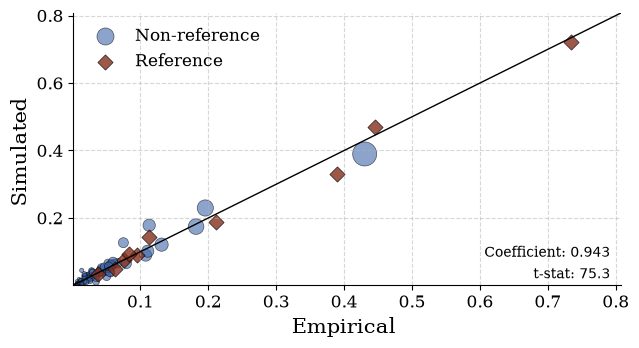

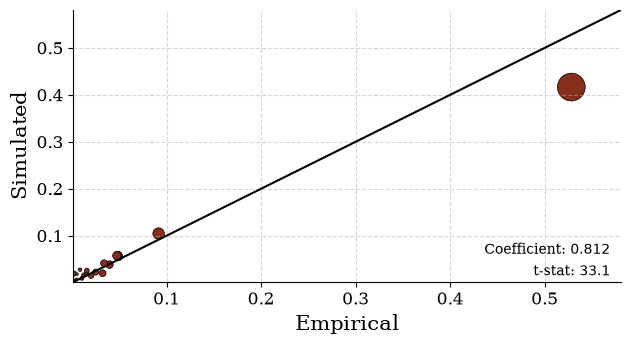

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
aero: S=10  n_AA=18  N_REG=4  moments from reporting_aero_profiled_aa_gran_nlo1_pso/step3, SEs from step3/inference


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


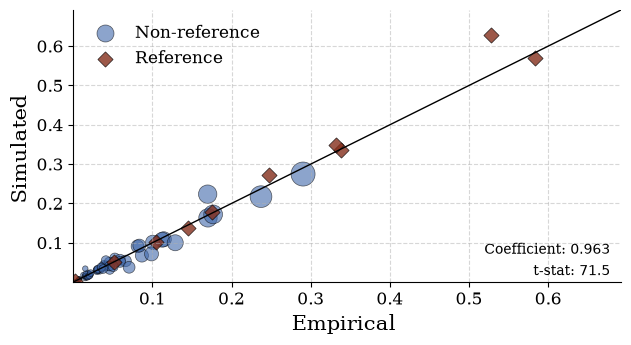

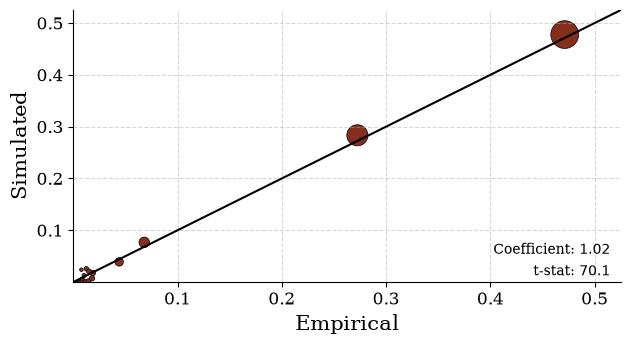

In [252]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)   # the analysis.ipynb pattern: binds input_folder, folder,
                             # coefs, emp_gamma_ls, X_dr, best_params, france, ... by name
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"moments from {data['folder'].name}/{data['step_dir']}, "
          f"SEs from {data['inference_step']}/inference")

    plot_gamma_aa(data, save_to=f"{out_folder}/emp_sim_gamma_aa_{industry}_mu{MU}.pdf")
    plt.show()
    plot_pi_r(data, save_to=f"{out_folder}/emp_sim_pi_{industry}_mu{MU}.pdf")
    plt.show()


## Fit with standard errors: extensive margin and zero-supplier share

The two blocks where the comparison is only meaningful against sampling uncertainty: the
cloglog distance-bin coefficients (block 4) and the zero-supplier shares $\bar G_s(0)$
(block 6). Each tick carries the empirical value on the left and the simulated one on the
right, both with 95% bars. **Two different objects, deliberately:**

* **Empirical bars** — $\sqrt{\mathrm{diag}(\Sigma_{data})}$, the bootstrap sampling
  standard error of the moment *in the data*. How precisely the target is measured.
* **Simulated bars** — `se_moments_fitted.npy`, the standard error of the *fitted*
  moment, $\sqrt{\mathrm{diag}(G\,V\,G')}$, i.e. the estimation uncertainty of the
  parameters carried through to the moment they generate.

Under the profiled estimator (`--profile_T=true`, what these runs use) $V$ is the
**sandwich** covariance of $\hat\alpha$ and $G = \partial m / \partial \alpha$ is the
*profiled* Jacobian — $\alpha$ moved with $T$ following through the Sinkhorn inversion.
So the simulated bar is the delta-method propagation of $\hat\alpha$'s sandwich standard
error onto that moment, not an efficient standard error built from the free-parameter
Jacobian: under profiling $T$ is not a free parameter, it is a function of $\alpha$ and of
the sourcing-share targets, and the reported bar takes that dependence into account.
Two consequences worth keeping in mind when reading the figure: the bar does *not*
include the data noise of the $\gamma$ targets that $T$ is inverted from (that channel is
reported separately, in Julia's `inference_delta.txt`), and $\bar G_s(0)$'s bar does not
include the uncertainty of $\hat N_s$, which is calibrated on that very moment.

Both numbers come out of the Julia inference step; nothing is re-estimated here.

Each sector of the $\bar G_s(0)$ panel is annotated with its profiled variety count
$\hat N_s$, starred when it sits on a bound: a sector clamped at a bound cannot close its
own count residual through $\hat N_s$, so a visible miss there is expected rather than a
fit failure.

**Where the same numbers appear on the Julia side, and why they must agree.**
$\bar G_s(0)$ is written down in four places, and the panel shows two of them: the red
marker is `G_K.csv` at $K = 0$ (block 6 of the empirical moment vector, printed as
`G0_emp` in a stage `report.txt`), the blue one is block 6 of
`<step>/best_simulated_moments.npy`, which `run_reporting` evaluates at the **last stage
folder's** `best_params.npy` on `U_DRAWS`. The other two are `G0_target` and `G0_fit` in
`<step>/granular_diagnostics.npz` (and its `.txt` twin), which `report_granular` computes
at the $\hat\theta$ that step saved. The two $\theta$ are the same vector —
`run_optimization` returns its final sub-stage's parameters and writes that same vector
into the last stage folder — and $\bar G_s(0)$ is a closed form in the win counts, so it
carries no simulation noise of its own: the two pairs must agree to the solver tolerance.

**The rest of the curve, $\bar G_s(1), \bar G_s(2), \bar G_s(3)$.** Only $K = 0$ is
targeted, and it is targeted *tightly*: $\hat N_s$ is the integer that solves
$\bar G_s(0) = \hat G_s$, so a good fit in that panel is close to mechanical. Nothing in
the criterion asks the model to reproduce the **shape** of the supplier-count
distribution, which makes $K \geq 1$ a free check — gate V8 of
`documentation/granular_validation.md` — on whether one variety count per sector is
enough structure to generate the observed spread of $K_{ls}$, or whether the model
concentrates suppliers into too few cells (the simulated curve then climbs too fast) or
scatters them over too many (too slow).

Neither side of it is on disk. The empirical curve is the rest of `G_K.csv`, which
`load_parameters.jl` reads only at $K = 0$; the simulated curve Julia never evaluates at
all, since the moment vector stops there. `count_curve` rebuilds it from the two
diagnostics that determine it, $\hat q_{ls}$ and $\hat N_s$: a cell hosts a supplier for
each variety it wins somewhere, so $K_{ls} \sim \mathrm{Bin}(\hat N_s, \hat q_{ls})$ and
$\bar G_s(K) = \mathrm{mean}_l \Pr(K_{ls} \leq K)$. It is estimated under the same
unbiased convention `gbar_cell` uses — take the $\hat N_s$ varieties to be that many of
the $m$ simulated draws sampled without replacement, so the win count among them is
hypergeometric and $\mathbb{E}[C(k,j)C(m-k,\hat N_s-j)/C(m,\hat N_s)]$ is the binomial
pmf exactly — which at $K = 0$ collapses to `gbar_cell` itself. That is what ties the
untargeted panels to the targeted one, and it is checked rather than asserted: the
rebuilt $K = 0$ column must reproduce block 6 of the moment vector, or the function falls
back to the plug-in binomial and says so.

**Standard errors on $K = 0$ only.** $\Sigma_{data}$'s count block is the $S$ rows of
$\bar G_s(0)$; the bootstrap never covered the rest of the curve, so a bar there would be
invented.

They come apart for one reason, and it is a bookkeeping one rather than a modelling one:
`report_granular` writes the npz only when *its* step runs (Step 2 at $\hat\theta_1$,
Step 4 at $\hat\theta_2$), whereas `main.jl`'s post-hoc block rewrites
`best_simulated_moments.npy` on **every** invocation. A run resumed with
`run_step4 = false` therefore leaves the reporting frozen at an older $\theta$ while the
figure follows the newest one. `g0_consistency(data)` puts all four columns side by side
and says which of the two gaps opened; `plot_G0` calls it and warns if either does.


In [253]:
REG_BIN_LABELS_5 = [r"$]0,50]$", r"$]50,100]$", r"$]100,150]$", r"$]150,200]$", r"$>200$"]


def reg_bin_labels(n_coef):
    if n_coef == 1:
        return [r"$\log d$"]
    if n_coef == 4:
        return REG_BIN_LABELS_5[1:]
    if n_coef == 5:
        return list(REG_BIN_LABELS_5)
    return [rf"$\beta_{{{i + 1}}}$" for i in range(n_coef)]


def _paired_errorbar(ax, labels, emp, sim, se_emp=None, se_sim=None, ci=1.96,
                     ylabel="", xlabel="", title=None, rotate=0):
    """
    Empirical (left) against simulated (right) at each tick, with +/- ci*SE bars.

    A point whose SE is zero, missing or NaN keeps its MARKER and simply gets no bar.
    Drawing it through `errorbar` with a zero yerr would put a bare cap on the marker,
    which reads as a measurement of zero precision rather than as an absent one; and a
    NaN yerr silently drops the point altogether, which is worse — the value is known,
    only its uncertainty is not.
    """
    x = np.arange(len(labels), dtype=float)
    off = 0.12

    def _series(xs, vals, se, **kw):
        vals = np.asarray(vals, float)
        if se is None:
            ax.errorbar(xs, vals, yerr=None, **kw)
            return
        se = np.asarray(se, float)
        has = np.isfinite(se) & (se > 0)
        # With bars, then without — one legend entry, taken from whichever is non-empty.
        if has.any():
            ax.errorbar(xs[has], vals[has], yerr=ci * se[has], **kw)
            kw = {**kw, "label": None}
        if (~has).any():
            ax.errorbar(xs[~has], vals[~has], yerr=None, **kw)

    _series(x - off, emp, se_emp,
            fmt="o", color=toulouse_color, capsize=3, markersize=7,
            markeredgecolor="black", markeredgewidth=0.5, linestyle="none",
            label="Empirical")
    _series(x + off, sim, se_sim,
            fmt="D", color=sim_color, capsize=3, markersize=6,
            markeredgecolor="black", markeredgewidth=0.5, linestyle="none",
            label="Simulated")
    #ax.axhline(0, color="black", linewidth=0.6, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=rotate, ha="right" if rotate else "center")
    ax.set_xlim(-0.6, len(labels) - 0.4)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    if title:
        ax.set_title(title)
    ax.grid(axis="y", linestyle="dashed", alpha=0.5)
    ax.legend(frameon=False)
    _despine(ax)
    return ax


def plot_reg_coef(data, ax=None, save_to=None, ci=1.96):
    """Empirical vs simulated cloglog distance coefficients, with SEs."""
    emp = np.asarray(data["empirical_moments_dict"]["reg_coef"], float)
    sim = np.asarray(data["simulated_moments_dict"]["reg_coef"], float)
    se_e = data["se_empirical"]["reg_coef"] if data["se_empirical"] else None
    se_s = data["se_simulated"]["reg_coef"] if data["se_simulated"] else None

    fig, ax = (plt.subplots(figsize=get_figsize(hf=0.62)) if ax is None else (ax.figure, ax))
    _paired_errorbar(ax, reg_bin_labels(data["n_coef"]), emp, sim, se_e, se_s, ci=ci,
                     ylabel=r"Extensive margin coefficient",
                     xlabel="Distance bin (km)")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, format="pdf", bbox_inches="tight")
    return ax


def plot_G0(data, ax=None, save_to=None, ci=1.96, annotate_N=True):
    """Empirical vs simulated Gbar_s(0) — the share of cells with no supplier."""
    if not data["granular"]:
        raise ValueError("Gbar_s(0) only exists under --granular=true")
    emp = np.asarray(data["empirical_moments_dict"]["G0"], float)
    sim = np.asarray(data["simulated_moments_dict"]["G0"], float)
    se_e = data["se_empirical"]["G0"] if data["se_empirical"] else None
    se_s = data["se_simulated"]["G0"] if data["se_simulated"] else None

    fig, ax = (plt.subplots(figsize=get_figsize(hf=0.62)) if ax is None else (ax.figure, ax))
    _paired_errorbar(ax, data["sector_names"], emp, sim, se_e, se_s, ci=ci,
                     ylabel=r"$\bar{G}_s(0)$", xlabel="Sector (A129)", rotate=45)

    # The profiled variety count is what the model moves to hit this moment, so
    # print it next to each sector — a clamped sector cannot close its own residual.
    diag = data.get("granular_diagnostics")
    if annotate_N and diag is not None and "N_hat" in diag:
        N_hat = np.asarray(diag["N_hat"]).ravel()
        clamped = np.asarray(diag.get("clamped", np.zeros_like(N_hat))).ravel()
        top = ax.get_ylim()[1]
        for i, (n, cl) in enumerate(zip(N_hat, clamped)):
            ax.text(i, top, rf"$\hat{{N}}_s={int(n)}$" + ("*" if cl != 0 else ""),
                    ha="center", va="bottom", fontsize=font_size-3, rotation=45)
        #ax.set_ylim(ax.get_ylim()[0], top * 1.02)
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, format="pdf", bbox_inches="tight")

    # The same two numbers are printed by Julia's own reporting; a gap between the
    # figure and that report is a wiring fault, not a modelling result, so say so
    # rather than leaving it to be discovered by eye.
    chk = g0_consistency(data, verbose=False)
    if chk is not None and not bool(chk.attrs.get("agrees", True)):
        print(f"[plot_G0] {data['industry']}: the figure and "
              f"{data['inference_step']}/granular_diagnostics.npz disagree on "
              "Gbar_s(0) — run g0_consistency(data) for the per-sector table.")
    return ax


G0_TOL = 1e-6


def g0_consistency(data, tol=None, verbose=True):
    """
    The four places Gbar_s(0) is written down, side by side.

    The figure above plots two numbers, and Julia's own reporting prints the same two
    out of a different file, so the pair is a cross-check rather than one source read
    twice:

    ``target``      G_K.csv at K = 0, i.e. block 6 of the empirical moment vector — the
                    red marker in the figure, and `G0_emp` in a stage `report.txt`.
    ``target_diag`` `G0_target` in `<step>/granular_diagnostics.npz`, written by
                    `report_granular` straight off `G_TARGET`.
    ``fit``         block 6 of `<step>/best_simulated_moments.npy` — the blue marker.
                    `run_reporting` evaluates it at the LAST stage folder's
                    `best_params.npy`, on `U_DRAWS`.
    ``fit_diag``    `G0_fit` in the same npz, evaluated by `granular_report` at the
                    theta the step saved (`theta_hat_1` for mu = 1, `theta_hat_2` for
                    mu = 2), also on `U_DRAWS`.

    The two thetas are the same vector — `run_optimization` returns the final
    sub-stage's parameters and writes that same vector into the last stage folder —
    and `Gbar_s(0)` is a closed form in the win counts, carrying no simulation noise of
    its own. So `fit` and `fit_diag` must agree to the inversion tolerance. They
    separate when the npz is STALE: `report_granular` writes it only when its step
    actually runs (Step 2 for mu = 1, Step 4 for mu = 2), while the post-hoc block of
    `main.jl` rewrites `best_simulated_moments.npy` on every invocation. A run resumed
    with `run_step4 = false` therefore leaves the npz at an older theta while the
    figure moves with the latest one.

    Returns a per-sector DataFrame (`None` when the npz is absent);
    `df.attrs["agrees"]` carries the verdict.
    """
    if not data["granular"]:
        raise ValueError("Gbar_s(0) only exists under --granular=true")
    tol = G0_TOL if tol is None else tol
    diag = data.get("granular_diagnostics")
    if diag is None:
        if verbose:
            print(f"[g0_consistency] {data['industry']}: no granular_diagnostics.npz in "
                  f"{data['folder'].name}/{data['inference_step']}/ — nothing to check against.")
        return None

    target = np.asarray(data["empirical_moments_dict"]["G0"], float)
    fit = np.asarray(data["simulated_moments_dict"]["G0"], float)
    nanlike = np.full_like(target, np.nan)
    target_diag = np.asarray(diag["G0_target"], float).ravel() if "G0_target" in diag else nanlike
    fit_diag = np.asarray(diag["G0_fit"], float).ravel() if "G0_fit" in diag else nanlike
    N_hat = np.asarray(diag["N_hat"], float).ravel() if "N_hat" in diag else nanlike
    clamp = np.asarray(diag["clamped"], float).ravel() if "clamped" in diag else np.zeros_like(target)

    df = pd.DataFrame({
        "target (G_K.csv)": target,
        "target (diagnostics)": target_diag,
        "d_target": target - target_diag,
        "fit (moment vector)": fit,
        "fit (diagnostics)": fit_diag,
        "d_fit": fit - fit_diag,
        "N_hat": N_hat,
        "clamp": np.where(clamp < 0, "lo", np.where(clamp > 0, "hi", "none")),
        "residual (fit - target)": fit - target,
    }, index=pd.Index(data["sector_names"], name="A129"))

    worst_t = float(np.nan_to_num(np.nanmax(np.abs(df["d_target"].values))))
    worst_f = float(np.nan_to_num(np.nanmax(np.abs(df["d_fit"].values))))
    agrees = bool(worst_t <= tol and worst_f <= tol)
    df.attrs.update(agrees=agrees, max_abs_target_gap=worst_t, max_abs_fit_gap=worst_f)

    if verbose or not agrees:
        src = (f"{data['folder'].name}: moments {data['step_dir']}/best_simulated_moments.npy "
               f"vs {data['inference_step']}/granular_diagnostics.npz")
        if agrees:
            print(f"[g0_consistency] {data['industry']} (mu = {data['mu']}) OK — {src}; "
                  f"max |gap| target {worst_t:.2e}, fit {worst_f:.2e}")
        else:
            print(f"[g0_consistency] {data['industry']} (mu = {data['mu']}) MISMATCH — {src}\n"
                  f"  max |gap| on the target {worst_t:.2e}, on the fit {worst_f:.2e} "
                  f"(tol {tol:.0e}).\n"
                  "  A TARGET gap means G_K.csv changed since the run: the figure reads the "
                  "CSV now, the npz froze G_TARGET at estimation time.\n"
                  "  A FIT gap means the npz sits at a different theta than the last stage "
                  "folder — typically a resumed run whose Step 2 / Step 4 did not re-execute. "
                  "Re-run that step, or read both numbers off the moment vector.")
    return df


# ---------------------------------------------------------------------------
# The whole count curve, Gbar_s(K) for K = 0, 1, 2, 3 — only K = 0 is targeted
# ---------------------------------------------------------------------------
# The K to show is a free parameter: the run cells pass `COUNT_CURVE_K` from the
# Constants cell, and this is the fallback when a function is called on its own.
_DEFAULT_COUNT_K = tuple(range(int(globals().get("COUNT_CURVE_K_MAX", 3)) + 1))


def _logfact(m):
    """`lg[i] = log(i!)` for i = 0..m, by cumulative sum — Julia's gbar_logfact_table."""
    lg = np.zeros(int(m) + 1)
    if m >= 1:
        lg[1:] = np.cumsum(np.log(np.arange(1, int(m) + 1, dtype=float)))
    return lg


def _log_binom(a, b, lg):
    return lg[a] - lg[b] - lg[a - b]


def gbar_cells(k, m, n, K, lg):
    """
    Unbiased per-cell estimate of `Pr(K_ls == K)` -- EXACTLY K suppliers, not at most K.

    A cell hosts a supplier for a variety it wins somewhere, so with `n` varieties
    `K_ls ~ Bin(n, q_ls)`. Take the `n` varieties to be `n` of the `m` simulated draws
    sampled WITHOUT replacement: the number of wins among them is Hypergeometric, and
    marginalising over the draws each is a win with probability `q` independently, so

        E[ C(k,K) C(m-k, n-K) / C(m,n) ]  =  C(n,K) q^K (1-q)^(n-K)

    exactly. At `K = 0` it collapses to `C(m-k,n)/C(m,n)`, which is `gbar_cell` in
    model_CP.jl verbatim -- so the targeted panel and the untargeted ones are the same
    estimator, and a discrepancy at K = 0 is a bug rather than a convention.

    INCREMENTS, not the CDF. `N_hat_s` is calibrated on the K = 0 level, so under a
    cumulative convention every panel would contain that fitted level and re-test what
    is already targeted; the increments isolate the free content -- the SHAPE of the
    supplier-count distribution (gate V8).
    """
    k = np.asarray(k, dtype=int)
    m, n, K = int(m), int(n), int(K)
    if n <= 0:
        return np.ones(k.shape) if K == 0 else np.zeros(k.shape)
    out = np.zeros(k.shape, float)
    if K < 0 or K > n:
        return out
    ok = (K <= k) & (n - K <= m - k)
    if ok.any():
        kk = k[ok]
        out[ok] = np.exp(_log_binom(kk, K, lg)
                         + _log_binom(m - kk, n - K, lg) - _log_binom(m, n, lg))
    return out


def _plugin_cells(q, n, K):
    """Plug-in fallback: the Binomial(n, q_hat) pmf at exactly K. Biased (Jensen), robust."""
    q = np.clip(np.asarray(q, float), 0.0, 1.0)
    n, K = int(n), int(K)
    if K < 0 or K > n:
        return np.zeros(q.shape, float)
    lg = _logfact(max(n, 1))
    return float(np.exp(_log_binom(n, K, lg))) * q ** K * (1 - q) ** (n - K)


def _cell_sectors(data):
    """
    Sector of each simulated cell, in the model's own good order.

    `load_parameters.jl` builds the cells as `findall(CELL_MASK)` over the `(S, R)`
    mask, and Julia's `findall` walks a matrix in COLUMN-major order — sector fastest,
    region slowest. Reading `q_hat` (which is stored in that order) with numpy's
    default C-order would silently shuffle cells between sectors.
    """
    S = data["S"]
    flat = np.flatnonzero(np.asarray(data["CELL_MASK"]).ravel(order="F"))
    return flat % S


def count_curve(data, K_values=None, tol=1e-9):
    """
    Empirical against simulated `Gbar_s(K)` = share of cells with EXACTLY K suppliers.

    **Only `K = 0` is targeted.** It is block 6 of the moment vector and the variety
    count `N_hat_s` is calibrated on it, so a good fit there is close to mechanical.
    `K >= 1` is free: nothing in the criterion asks the model to reproduce the SHAPE of
    the supplier-count distribution, which makes the rest of the curve an untargeted
    check (gate V8 of `documentation/granular_validation.md`).

    Increments, not the CDF -- see `gbar_cells`. `p_s(0) = G_s(0)`, so the targeted
    panel is the same number under either convention; only `K >= 1` changes.

    Sources, in order of preference:

    * simulated  -- `<step>/inference/G_curve_fitted.npy`, written by Julia at the same
      theta_hat and the same pinned `N_hat_s` the delta-method SE was built at. Absent,
      it is rebuilt here from `q_hat` and `N_hat_s` under the same unbiased convention,
      with `m = N_rho` RECOVERED from the diagnostics (`max(100, max N_HI)`, the rule in
      load_parameters.jl) and the recovery CHECKED twice: `q_hat * m` must be integral
      (it is a win count), and the K = 0 column must reproduce block 6 of the moment
      vector. If either fails the plug-in Binomial pmf is used and `attrs["estimator"]`
      says so.
    * empirical  -- the increments of `G_K.csv`, `p_s(K) = G(K) - G(K-1)`.

    Returns a (sector, K)-indexed DataFrame with both standard errors where available;
    `df.attrs` carries the estimator, the K = 0 gap against the moment vector, and the
    draw count used.
    """
    if not data["granular"]:
        raise ValueError("the count curve only exists under --granular=true")
    Ks = list(_DEFAULT_COUNT_K if K_values is None else K_values)
    S = data["S"]
    diag = data.get("granular_diagnostics")
    if diag is None or "q_hat" not in diag or "N_hat" not in diag:
        raise FileNotFoundError(
            f"{data['folder'].name}/{data['inference_step']}/granular_diagnostics.npz is "
            "absent or carries no q_hat/N_hat — the simulated curve is rebuilt from those "
            "two, so there is nothing to plot against. Re-run the step that writes it "
            f"({'Step 2' if data['mu'] == 1 else 'Step 4'} of main.jl).")

    q = np.asarray(diag["q_hat"], float).ravel()
    N_hat = np.rint(np.asarray(diag["N_hat"], float).ravel()).astype(int)
    N_HI = np.asarray(diag["N_HI"], float).ravel() if "N_HI" in diag else np.array([100.0])
    clamped = (np.asarray(diag["clamped"], float).ravel() if "clamped" in diag
               else np.zeros(S))
    good_s = _cell_sectors(data)
    if q.size != good_s.size:
        raise ValueError(f"q_hat has {q.size} cells but CELL_MASK has {good_s.size} — "
                         "the run's granular/ca_level flags and the ones passed here disagree.")

    n_rho = max(100, int(round(np.nanmax(N_HI))))        # load_parameters.jl's N_rho rule
    k_counts = np.rint(q * n_rho).astype(int)
    integral_gap = float(np.max(np.abs(q * n_rho - k_counts))) if q.size else 0.0
    lg = _logfact(n_rho)

    def curve(unbiased):
        out = np.full((S, len(Ks)), np.nan)
        for s in range(S):
            cells = good_s == s
            if not cells.any():
                continue
            for i, K in enumerate(Ks):
                out[s, i] = (gbar_cells(k_counts[cells], n_rho, N_hat[s], K, lg).mean()
                             if unbiased else _plugin_cells(q[cells], N_hat[s], K).mean())
        return out

    block6 = np.asarray(data["simulated_moments_dict"]["G0"], float)
    sim = curve(True)
    estimator, gap = "unbiased (gbar_cell)", np.inf
    if 0 in Ks:
        gap = float(np.nanmax(np.abs(sim[:, Ks.index(0)] - block6)))
    if integral_gap > 1e-6 or (0 in Ks and gap > 1e-6):
        sim_pi = curve(False)
        gap_pi = (float(np.nanmax(np.abs(sim_pi[:, Ks.index(0)] - block6)))
                  if 0 in Ks else np.inf)
        print(f"[count_curve] {data['industry']}: the unbiased reconstruction does not "
              f"reproduce block 6 at K = 0 (gap {gap:.2e}, q_hat*N_rho integrality "
              f"{integral_gap:.2e} at N_rho = {n_rho}); falling back to the plug-in "
              f"Binomial pmf (gap {gap_pi:.2e}). K >= 1 is then biased by Jensen "
              "— read it as indicative, and check N_rho against the run's log line.")
        sim, estimator, gap = sim_pi, "plug-in Binomial(N_hat, q_hat)", gap_pi

    # Julia's own curve wins when present: it was evaluated at the same theta_hat and
    # the same PINNED N_hat_s as the delta-method SE beside it, so the point and its
    # band cannot drift apart the way a Python reconstruction can.
    sim_se = np.full((S, len(Ks)), np.nan)
    jK = data.get("G_curve_sim_K")
    if jK is not None:
        jc, js = data.get("G_curve_sim"), data.get("G_curve_sim_se")
        for i, K in enumerate(Ks):
            if K in jK:
                c = jK.index(K)
                if js is not None and js.shape == (S, len(jK)):
                    sim_se[:, i] = js[:, c]
                if jc is not None and jc.shape == (S, len(jK)):
                    d = float(np.nanmax(np.abs(jc[:, c] - sim[:, i])))
                    if d > 1e-6:
                        print(f"[count_curve] {data['industry']}: K = {K}, Julia's fitted "
                              f"curve and the Python reconstruction differ by {d:.2e}; "
                              "using Julia's (it shares theta_hat and the pinned N_hat_s "
                              "with the SE). A large gap means N_rho was mis-recovered.")
                    sim[:, i] = jc[:, c]
        estimator += " [Julia G_curve_fitted]" if data.get("G_curve_sim") is not None else ""

    # ---- empirical: the increments of G_K.csv, and their bootstrap SE if supplied ----
    emp = np.full((S, len(Ks)), np.nan)
    emp_se = np.full((S, len(Ks)), np.nan)
    gk, gp, gse = data.get("G_curve_K"), data.get("G_pmf"), data.get("G_pmf_se")
    if gp is not None and gk is not None:
        for i, K in enumerate(Ks):
            if K in gk:
                emp[:, i] = gp[:, gk.index(K)]
                if gse is not None:
                    emp_se[:, i] = gse[:, gk.index(K)]
    missing = [K for K in Ks if gk is not None and K not in gk]
    if missing:
        print(f"[count_curve] {data['industry']}: G_K.csv has no row for K = {missing} — "
              "those panels show the simulated curve only.")

    # Free consistency gate: p_s(0) = G_s(0) IS block 6, whose bootstrap variance is
    # already the G block of Sigma_data. A supplied CSV must agree with it at K = 0.
    if 0 in Ks and gse is not None and data.get("se_empirical") is not None:
        ref = np.asarray(data["se_empirical"]["G0"], float)
        got = emp_se[:, Ks.index(0)]
        ok = np.isfinite(got) & np.isfinite(ref) & (ref > 0)
        if ok.any():
            rel = float(np.nanmax(np.abs(got[ok] - ref[ok]) / ref[ok]))
            if rel > 0.05:
                print(f"[count_curve] {data['industry']}: the supplied G_K_var.csv "
                      f"disagrees with diag(Sigma_data)'s count block at K = 0 by up to "
                      f"{rel:.1%}. They are the SAME object (p_s(0) = G_s(0)), so one of "
                      "the two bootstraps is not the one the estimator used — most "
                      "likely the CSV holds the CDF's variance rather than the "
                      "increment's, which coincide only at K = 0 if the resampling is "
                      "identical.")

    idx = pd.MultiIndex.from_product([data["sector_names"], Ks], names=["A129", "K"])
    df = pd.DataFrame({"empirical": emp.ravel(),
                       "simulated": sim.ravel(),
                       "se_empirical": emp_se.ravel(),
                       "se_simulated": sim_se.ravel(),
                       "residual": (sim - emp).ravel(),
                       "N_hat": np.repeat(N_hat, len(Ks)),
                       "clamped": np.repeat(clamped != 0, len(Ks)),
                       "targeted": np.tile([K == 0 for K in Ks], S)}, index=idx)
    df.attrs.update(estimator=estimator, K0_gap_vs_moment_vector=gap,
                    n_rho=n_rho, K_values=Ks)
    return df


def plot_count_curve(data, K_values=None, save_to=None, ci=1.96, df=None):
    """
    One INDEPENDENT figure per K: empirical against simulated `Gbar_s(K)` across sectors.

    Same marks and same layout as `plot_G0`, which IS the K = 0 case — so each K stands
    on its own, in its own file, and can be dropped into a paper or a slide without
    carrying the others with it. The y label names the K it shows (`Gbar_s(1)`,
    `Gbar_s(2)`, ...), which is what distinguishes the panels now that there is no title
    and no shared axis to read them against.

    Because the panels are INCREMENTS rather than a CDF they do not climb mechanically
    toward 1: a model whose count distribution is too concentrated puts too much mass at
    low K and too little in the tail, which reads directly as a mismatch at each K.

    Both bands are delta-method / bootstrap objects, and neither is decorative:

    * simulated — `se_G_curve_delta.npy`. At K = 0 for a FREE sector it collapses to the
      bootstrap SE of the target, because `N_hat_s` is calibrated to make the fitted
      moment EQUAL the target: the K = 0 fit is not evidence, and the band says so. For
      a CLAMPED sector `N_hat_s` cannot move, the target channel drops out, and the band
      is the alpha + gamma propagation instead. For K >= 1 it is the residualized
      structural loading plus the scaled target channel.
    * empirical — the bootstrap SE of the increments, from `G_K_var.csv`. Absent, the
      empirical points are drawn bare rather than with an invented bar.

    `save_to` is a STEM, not a file: K is appended before the extension, so
    `.../count_curve_auto_mu2.pdf` writes `..._K0.pdf`, `..._K1.pdf`, ... One call still
    produces the whole set, and nothing overwrites anything.

    `K_values` selects which K to draw; passed alongside a precomputed `df` it SUBSETS
    it, which is how a run cell draws only the untargeted K >= 1 while `plot_G0` keeps
    the targeted one (with its N_hat annotation). Returns `{K: ax}`.
    """
    df = count_curve(data, K_values=K_values) if df is None else df
    available = list(df.attrs["K_values"])
    Ks = available if K_values is None else [int(K) for K in np.atleast_1d(K_values)]
    absent = [K for K in Ks if K not in available]
    if absent:
        raise KeyError(f"K = {absent} is not in the count curve passed here "
                       f"(it carries K = {available}) — rebuild it with "
                       f"`count_curve(data, K_values={Ks})`.")
    sectors = data["sector_names"]

    def _band(v):
        # NaN and zero entries are passed through as they are: `_paired_errorbar` keeps
        # the marker and omits the bar for those, so a sector with no measured variance
        # is still visible as a point. A column with no SE anywhere gets None.
        v = np.asarray(v, float)
        return None if not np.isfinite(v).any() else v

    stem, ext = os.path.splitext(save_to) if save_to else (None, ".pdf")
    axes = {}
    for K in Ks:
        sub = df.xs(K, level="K").reindex(sectors)
        _, ax = plt.subplots(figsize=get_figsize(hf=0.62))
        _paired_errorbar(
            ax, sectors, sub["empirical"].values, sub["simulated"].values,
            _band(sub["se_empirical"].values), _band(sub["se_simulated"].values), ci=ci,
            ylabel=rf"$\bar{{G}}_s({K})$", xlabel="Sector (A129)", rotate=45)
        ax.figure.tight_layout()
        if stem:
            path = f"{stem}_K{K}{ext or '.pdf'}"
            os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
            ax.figure.savefig(path, format="pdf", bbox_inches="tight")
        axes[K] = ax
    return axes


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
auto: S=10  n_AA=22  N_REG=4  moments from reporting_auto_profiled_aa_gran_nlo1_pso/step3, SEs from step3/inference


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


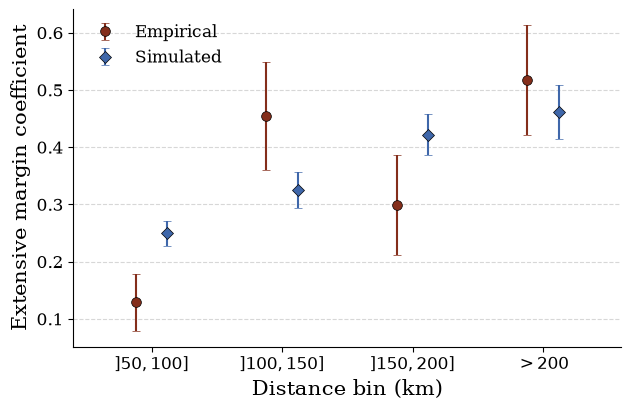

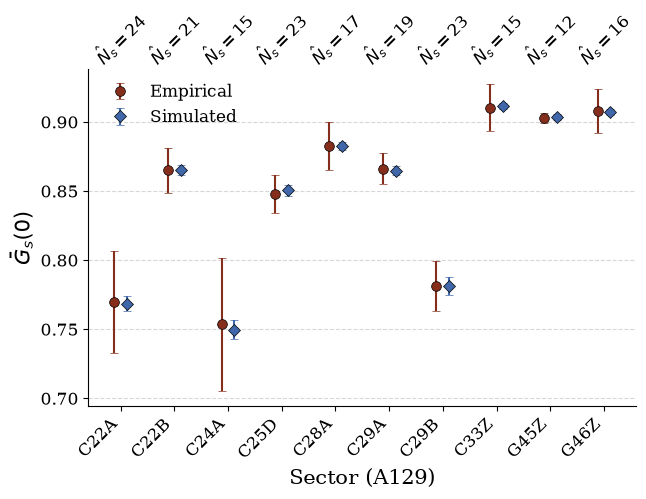

[g0_consistency] auto (mu = 2) OK — reporting_auto_profiled_aa_gran_nlo1_pso: moments step3/best_simulated_moments.npy vs step3/granular_diagnostics.npz; max |gap| target 1.11e-16, fit 0.00e+00


,target (G_K.csv),target (diagnostics),d_target,fit (moment vector),fit (diagnostics),d_fit,N_hat,clamp,residual (fit - target)
A129,,,,,,,,,
C22A,0.769912,0.769912,0.000000e+00,0.768570,0.768570,0.0,24.0,none,-0.001341
C22B,0.865000,0.865000,0.000000e+00,0.865368,0.865368,0.0,21.0,none,0.000368
C24A,0.753623,0.753623,0.000000e+00,0.749705,0.749705,0.0,15.0,none,-0.003918
C25D,0.847826,0.847826,0.000000e+00,0.850610,0.850610,0.0,23.0,none,0.002784
C28A,0.882682,0.882682,0.000000e+00,0.882697,0.882697,0.0,17.0,none,0.000016
C29A,0.866279,0.866279,0.000000e+00,0.864825,0.864825,0.0,19.0,none,-0.001454
C29B,0.781250,0.781250,0.000000e+00,0.781316,0.781316,0.0,23.0,none,0.000066
C33Z,0.910448,0.910448,0.000000e+00,0.911608,0.911608,0.0,15.0,none,0.001160
G45Z,0.902778,0.902778,0.000000e+00,0.903788,0.903788,0.0,12.0,none,0.001010


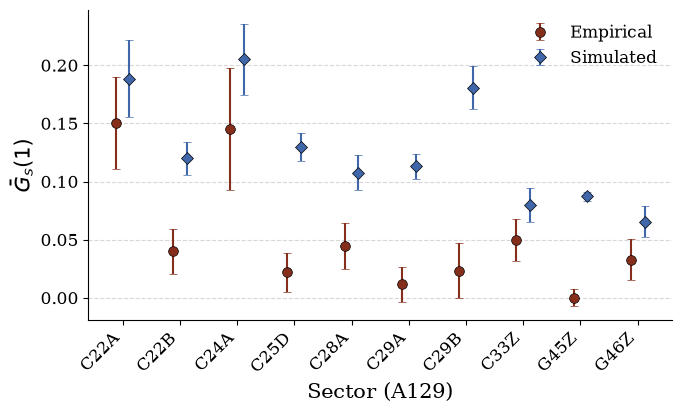

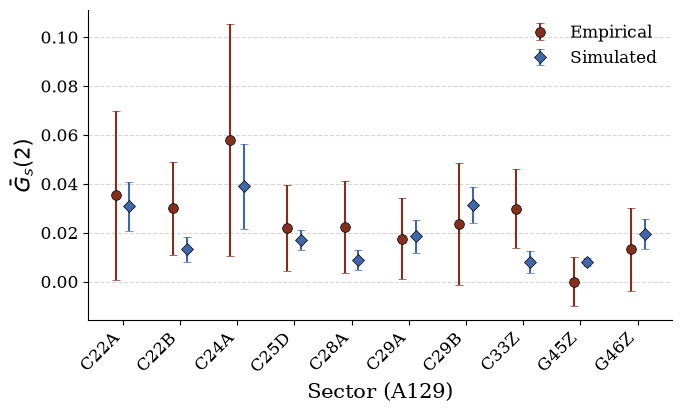

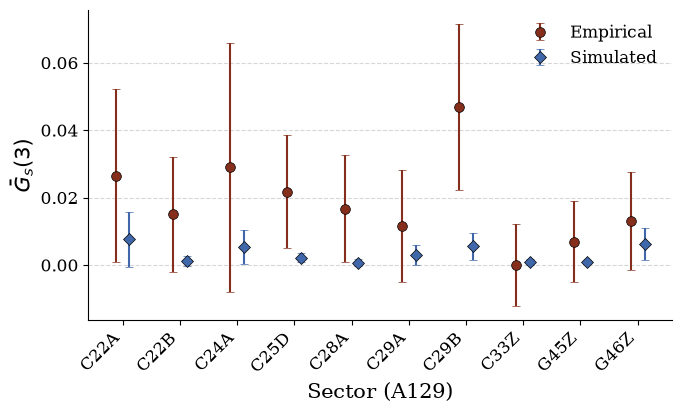

empirical                               simulated                      \
K            0         1         2         3         0         1         2   
A129                                                                         
C22A  0.769912  0.150442  0.035398  0.026549  0.768570  0.188525  0.030807   
C22B  0.865000  0.040000  0.030000  0.015000  0.865368  0.120165  0.013156   
C24A  0.753623  0.144928  0.057971  0.028986  0.749705  0.205259  0.039066   
C25D  0.847826  0.021739  0.021739  0.021739  0.850610  0.129725  0.016963   
C28A  0.882682  0.044693  0.022346  0.016760  0.882697  0.107672  0.008911   
C29A  0.866279  0.011628  0.017442  0.011628  0.864825  0.112990  0.018495   
C29B  0.781250  0.023438  0.023438  0.046875  0.781316  0.180857  0.031204   
C33Z  0.910448  0.049751  0.029851  0.000000  0.911608  0.079469  0.008002   
G45Z  0.902778  0.000000  0.000000  0.006944  0.903788  0.087260  0.008097   
G46Z  0.907895  0.032895  0.013158  0.013158  0.907177  0.065408  0.019559   

               se_empirical            ... N_hat     clamped                \
K            3            0         1  ...     2   3       0      1      2   
A129                                   ...                                   
C22A  0.007627     0.018883  0.020130  ...    24  24   False  False  False   
C22B  0.001215     0.008435  0.009897  ...    21  21   False  False  False   
C24A  0.005354     0.024620  0.026772  ...    15  15   False  False  False   
C25D  0.002218     0.006926  0.008605  ...    23  23   False  False  False   
C28A  0.000668     0.008899  0.010033  ...    17  17   False  False  False   
C29A  0.003098     0.005852  0.007677  ...    19  19   False  False  False   
C29B  0.005588     0.009249  0.012003  ...    23  23   False  False  False   
C33Z  0.000847     0.008672  0.009374  ...    15  15   False  False  False   
G45Z  0.000794     0.001942  0.003685  ...    12  12   False  False  False   
G46Z  0.006199     0.008081  0.009151  ...    16  16   False  False  False   

            targeted                       
K         3        0      1      2      3  
A129                                       
C22A  False     True  False  False  False  
C22B  False     True  False  False  False  
C24A  False     True  False  False  False  
C25D  False     True  False  False  False  
C28A  False     True  False  False  False  
C29A  False     True  False  False  False  
C29B  False     True  False  False  False  
C33Z  False     True  False  False  False  
G45Z  False     True  False  False  False  
G46Z  False     True  False  False  False  

[10 rows x 32 columns]

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
aero: S=10  n_AA=18  N_REG=4  moments from reporting_aero_profiled_aa_gran_nlo1_pso/step3, SEs from step3/inference


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


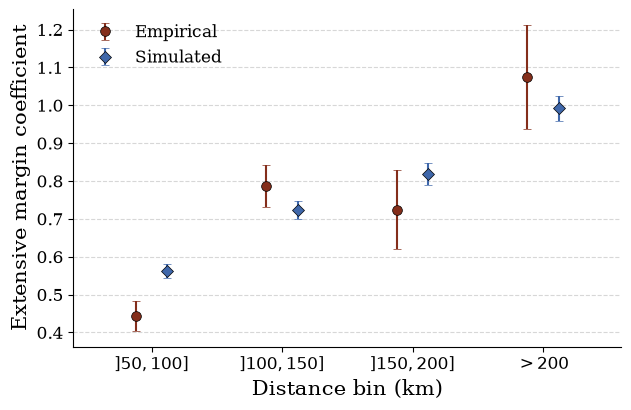

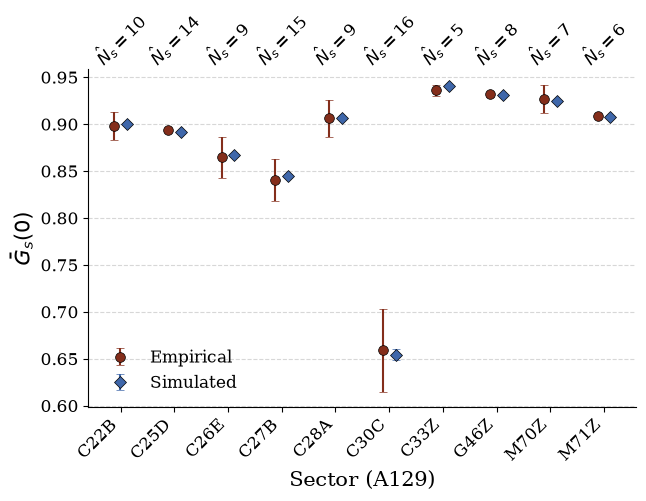

[g0_consistency] aero (mu = 2) OK — reporting_aero_profiled_aa_gran_nlo1_pso: moments step3/best_simulated_moments.npy vs step3/granular_diagnostics.npz; max |gap| target 0.00e+00, fit 0.00e+00


,target (G_K.csv),target (diagnostics),d_target,fit (moment vector),fit (diagnostics),d_fit,N_hat,clamp,residual (fit - target)
A129,,,,,,,,,
C22B,0.898305,0.898305,0.0,0.900665,0.900665,0.0,10.0,none,0.002360
C25D,0.893519,0.893519,0.0,0.891896,0.891896,0.0,14.0,none,-0.001623
C26E,0.864583,0.864583,0.0,0.866884,0.866884,0.0,9.0,none,0.002300
C27B,0.840764,0.840764,0.0,0.844783,0.844783,0.0,15.0,none,0.004019
C28A,0.906250,0.906250,0.0,0.906988,0.906988,0.0,9.0,none,0.000738
C30C,0.659091,0.659091,0.0,0.654534,0.654534,0.0,16.0,none,-0.004557
C33Z,0.936306,0.936306,0.0,0.940553,0.940553,0.0,5.0,none,0.004247
G46Z,0.931677,0.931677,0.0,0.930603,0.930603,0.0,8.0,none,-0.001074
M70Z,0.926471,0.926471,0.0,0.924905,0.924905,0.0,7.0,none,-0.001566


[count_curve] aero: the supplied G_K_var.csv disagrees with diag(Sigma_data)'s count block at K = 0 by up to 100.0%. They are the SAME object (p_s(0) = G_s(0)), so one of the two bootstraps is not the one the estimator used — most likely the CSV holds the CDF's variance rather than the increment's, which coincide only at K = 0 if the resampling is identical.


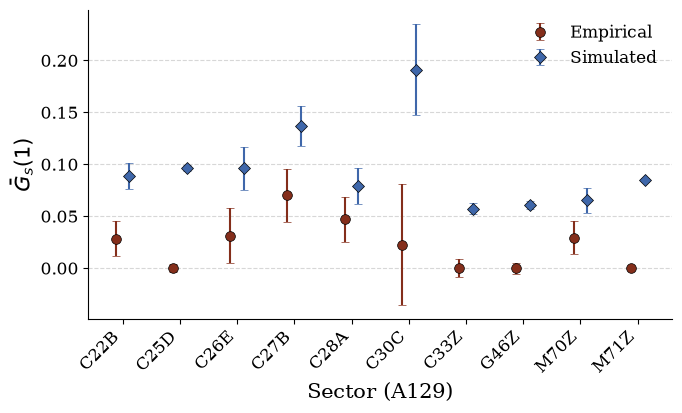

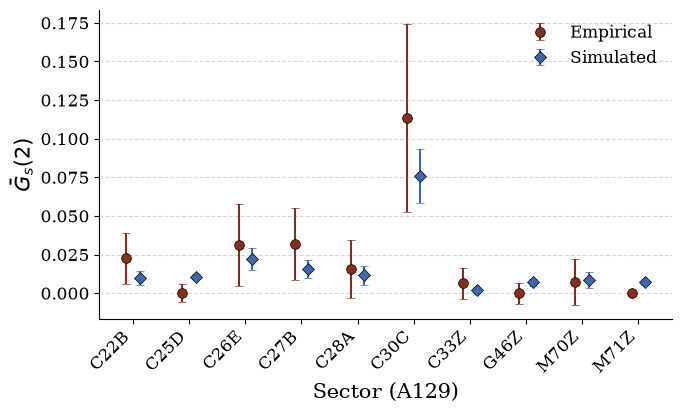

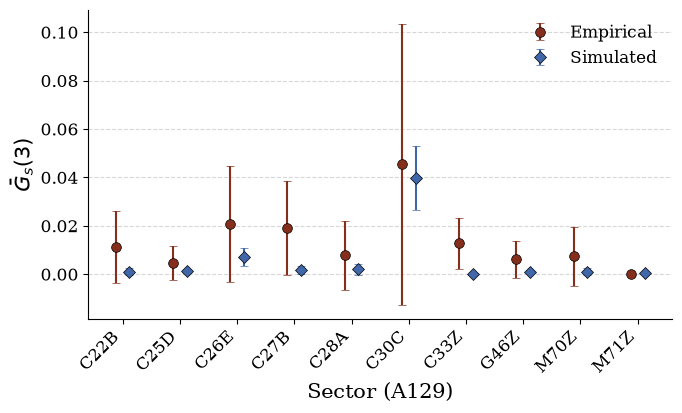

empirical                               simulated                      \
K            0         1         2         3         0         1         2   
A129                                                                         
C22B  0.898305  0.028249  0.022599  0.011299  0.900665  0.088480  0.009666   
C25D  0.893519  0.000000  0.000000  0.004630  0.891896  0.096226  0.010614   
C26E  0.864583  0.031250  0.031250  0.020833  0.866884  0.096409  0.021866   
C27B  0.840764  0.070064  0.031847  0.019108  0.844783  0.137274  0.015965   
C28A  0.906250  0.046875  0.015625  0.007812  0.906988  0.078924  0.011736   
C30C  0.659091  0.022727  0.113636  0.045455  0.654534  0.191243  0.075716   
C33Z  0.936306  0.000000  0.006369  0.012739  0.940553  0.057152  0.002238   
G46Z  0.931677  0.000000  0.000000  0.006211  0.930603  0.061054  0.007178   
M70Z  0.926471  0.029412  0.007353  0.007353  0.924905  0.065317  0.008615   
M71Z  0.908257  0.000000  0.000000  0.000000  0.907392  0.085093  0.007078   

               se_empirical            ... N_hat     clamped                \
K            3            0         1  ...     2   3       0      1      2   
A129                                   ...                                   
C22B  0.001069     0.007500  0.008685  ...    10  10   False  False  False   
C25D  0.001142     0.001148  0.002119  ...    14  14   False  False  False   
C26E  0.007084     0.011308  0.013503  ...     9   9   False  False  False   
C27B  0.001778     0.011554  0.012888  ...    15  15   False  False  False   
C28A  0.002043     0.010121  0.010828  ...     9   9   False  False  False   
C30C  0.039728     0.022455  0.029601  ...    16  16   False  False  False   
C33Z  0.000057     0.002960  0.004458  ...     5   5   False  False  False   
G46Z  0.001043     0.001508  0.002650  ...     8   8   False  False  False   
M70Z  0.001065     0.007664  0.008263  ...     7   7   False  False  False   
M71Z  0.000419     0.000000  0.000000  ...     6   6   False  False  False   

            targeted                       
K         3        0      1      2      3  
A129                                       
C22B  False     True  False  False  False  
C25D  False     True  False  False  False  
C26E  False     True  False  False  False  
C27B  False     True  False  False  False  
C28A  False     True  False  False  False  
C30C  False     True  False  False  False  
C33Z  False     True  False  False  False  
G46Z  False     True  False  False  False  
M70Z  False     True  False  False  False  
M71Z  False     True  False  False  False  

[10 rows x 32 columns]

In [254]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)   # the analysis.ipynb pattern: binds input_folder, folder,
                             # coefs, emp_gamma_ls, X_dr, best_params, france, ... by name
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"moments from {data['folder'].name}/{data['step_dir']}, "
          f"SEs from {data['inference_step']}/inference")

    plot_reg_coef(data, save_to=f"{out_folder}/emp_sim_reg_coef_{industry}_mu{MU}.pdf")
    plt.show()
    plot_G0(data, save_to=f"{out_folder}/emp_sim_G0_{industry}_mu{MU}.pdf")
    plt.show()
    # The figure against Julia's own reporting of the same moment, sector by sector.
    display(g0_consistency(data))
    # ... and the rest of the count curve, which nothing in the criterion targets.
    cc = count_curve(data, K_values=COUNT_CURVE_K)
    # one figure per K, each in its own file; K = 0 is `plot_G0` above, which carries
    # the N_hat annotation, so only the untargeted K >= 1 are drawn here
    plot_count_curve(data, df=cc, K_values=[K for K in COUNT_CURVE_K if K > 0],
                     save_to=f"{out_folder}/emp_sim_count_curve_{industry}_mu{MU}.pdf")
    plt.show()
    display(cc.unstack("K"))


# Jacobian and variance-covariance


## Jacobian — which parameter moves which moment

Rows are the moments the criterion actually uses (the masked vector, six blocks),
columns are the parameters. The parameter axis is
$[\Omega^L \mid \Omega^s \mid A \mid \alpha \mid T \mid N_s]$: the head parameters, the
trade-cost elasticity, the comparative advantages, and — appended on the right — the
**variety counts**.

**Why $N_s$ is in the picture.** $T$ and $N_s$ are both *calibrated* rather than
searched over: $T$ is the Sinkhorn image that reproduces the observed sourcing shares at
a given $\alpha$, $N_s$ is the solution of $\bar G_s(n) = \hat G_s$ found by integer
bisection. $T$ appeared in the Jacobian only because it happens to be a coordinate of the
parameter vector and $N_s$ is not — a bookkeeping accident, not a statement about the
model. The Julia side now appends $\partial m/\partial N_s$ to the saved Jacobian, so the
matrix covers every parameter the model has. Two conventions for reading those columns:

* the derivative is a unit **first difference** $m(N_s+1) - m(N_s)$. $N_s$ is an integer,
  so one variety *is* the step and there is no step size to choose;
* the zeros outside block 6 are **structural**, not numerical. The two evaluations share
  the same productivity draws, so any moment with no $N_s$ term differences to exactly
  `0.0`, and Julia asserts it (the extensive margin is $N_s$-free by Proposition 1, the
  win probabilities by Lemma 2). An exact zero in an $N_s$ column is the model saying the
  channel does not exist, not a small number that fell below a threshold.

**What is plotted is the elasticity** $\varepsilon_{jk} = \partial \log m_j / \partial
\log \theta_k$ (for $N_s$, $\hat N_s \cdot \partial m_j/\partial N_s / m_j$). The raw
$\partial m/\partial\theta$ mixes units across blocks and cannot share one colour scale.

**The noise-to-signal triptych.** These derivatives are finite differences of *simulated*
moments, so each entry is itself an estimate: `compute_jacobian` averages over $K$
independent draw sets and reports the across-replication standard deviation
$\sigma_{jk}$. An entry is readable only if $\sigma_{jk}/|\varepsilon_{jk}|$ is small —
a large elasticity with a larger standard deviation is not evidence of a channel, and a
zero there means "not measured", not "not there". So each elasticity figure comes in
three panels:

1. the elasticity Jacobian as it is;
2. the noise-to-signal ratio $\sigma/|\varepsilon|$ alone, with the cells that fail the
   criterion marked — which parts of panel 1 are readable at all;
3. the elasticity Jacobian with those cells blanked to white — what survives.

A cell fails when $\sigma/|\varepsilon| \geq$ `NOISE_MAX` (default 0.5: the Monte-Carlo
standard deviation is at least half the elasticity itself). Entries that are *exactly*
zero are treated as readable, since a structural zero carries no simulation noise —
distinguishing them from unmeasured entries is the whole point of the panel.

**Under `profile_T` this is the FREE-parameter Jacobian**, saved for diagnostics: it
answers "what would move if $T$ were free". The inference itself runs on the $\alpha$-only
profiled Jacobian, where $T$ follows $\alpha$ through the Sinkhorn inversion.


In [255]:
# Jacobian heatmaps. `kind="elasticity"` is what should be read; "raw" mixes units.
# The parameter axis carries the variety counts N_s when the run wrote them (see the
# markdown above); `data["n_N_cols"]` says how many columns they occupy.

JACOBIAN_BOUNDARIES = [-1, -0.1, -0.05, -0.025, -0.01, -0.001,
                       0.001, 0.01, 0.025, 0.05, 0.1, 1]

# An elasticity is unreadable when its Monte-Carlo standard deviation across the K
# Jacobian replications is at least this fraction of the elasticity itself.
NOISE_MAX = 0.5


def _binned_cmap(boundaries, coarse=False):
    from matplotlib.colors import BoundaryNorm, ListedColormap
    if coarse:
        return ListedColormap(["#2166ac", "#f0f0f0", "#b2182b"]), \
            BoundaryNorm([-1, -0.1, 0.1, 1], 3)
    n_bins = len(boundaries) - 1
    cmap = ListedColormap(plt.get_cmap("RdBu_r")(np.linspace(0, 1, n_bins)))
    return cmap, BoundaryNorm(boundaries, n_bins)


def jacobian_matrix(data, kind="elasticity"):
    """The Jacobian to plot, with a clear error when it is not on disk."""
    key = {"elasticity": "J_elast", "raw": "J", "sd": "J_sd",
           "elasticity_sd": "J_elast_sd"}[kind]
    J = data.get(key)
    if J is None:
        step = data["inference_step"]
        raise FileNotFoundError(
            f"no Jacobian in {data['folder']}/{step}/ — main.jl writes "
            f"jacobian_all*.npy at theta_hat_1 (step2) and jacobian_all_step3*.npy at "
            f"theta_hat_2 (step3); the corresponding inference step must have run.")
    return J


def jacobian_noise_ratio(data, kind="elasticity"):
    """
    sigma / |epsilon| entry by entry — the Monte-Carlo standard deviation of the
    elasticity across the K Jacobian replications, relative to the elasticity itself.

    Scale-free: the theta/m rescaling that turns dm/dtheta into an elasticity cancels
    between numerator and denominator, so this is the same number for the raw and the
    elasticity Jacobian. An EXACTLY zero entry gets ratio 0 rather than infinity: a
    structural zero (the N_s columns outside block 6) carries no simulation noise, and
    conflating it with an unmeasured entry is precisely what this diagnostic is for.
    """
    E = np.asarray(jacobian_matrix(data, kind), float)
    sd = data.get("J_elast_sd" if "elast" in kind else "J_sd")
    if sd is None:
        raise FileNotFoundError(
            f"no across-replication SD for the Jacobian in {data['folder']}/"
            f"{data['inference_step']}/ — compute_jacobian writes it as "
            "jacobian_all*_elasticity_sd.npy when K > 1.")
    sd = np.abs(np.asarray(sd, float))
    A = np.abs(E)
    with np.errstate(divide="ignore", invalid="ignore"):
        R = sd / A
    R[(A == 0) & (sd == 0)] = 0.0          # structural zero: measured, and exactly zero
    R[~np.isfinite(R)] = np.inf            # nonzero noise on a zero signal: unreadable
    return R


def jacobian_noise_mask(data, kind="elasticity", noise_max=NOISE_MAX):
    """True where the elasticity is DROWNED in simulation noise and must not be read."""
    return jacobian_noise_ratio(data, kind) >= noise_max


def _edges(sizes):
    return np.cumsum([0] + list(sizes))


def _tick_every(n, target=25):
    """Tick stride that keeps roughly `target` labels on an axis of length n."""
    return max(1, int(np.ceil(n / target)))


def _block_grid(ax, data, m_edges, p_edges, block_names=True):
    """Block separators, plus the block names on the outer margins."""
    for e in m_edges[1:-1]:
        ax.axhline(e - 0.5, color="black", linewidth=1.2, alpha=0.6)
    for e in p_edges[1:-1]:
        ax.axvline(e - 0.5, color="black", linewidth=1.2, alpha=0.6)
    if not block_names:
        return
    ax_top, ax_right = ax.secondary_xaxis("top"), ax.secondary_yaxis("right")
    ax_top.set_xticks((p_edges[:-1] + p_edges[1:]) / 2 - 0.5)
    ax_top.set_xticklabels(data["param_block_names"], fontsize=10, fontweight="bold",
                           rotation=45)
    ax_right.set_yticks((m_edges[:-1] + m_edges[1:]) / 2 - 0.5)
    ax_right.set_yticklabels(data["moment_block_names"], fontsize=10, fontweight="bold")


def _axis_labels(ax, data, shape):
    xs = np.arange(shape[1])[::_tick_every(shape[1])]
    ax.set_xticks(xs)
    ax.set_xticklabels(np.array(data["param_labels"])[xs], rotation=90, fontsize=7)
    ax.xaxis.set_ticks_position("bottom")
    ys = np.arange(shape[0])[::_tick_every(shape[0])]
    ax.set_yticks(ys)
    ax.set_yticklabels(np.array(data["moment_labels"])[ys], fontsize=7)
    ax.set_xlabel("Parameter")
    ax.set_ylabel("Moment")


def plot_jacobian_full(data, kind="elasticity", coarse=False, figsize=(15, 11),
                       mask=None, title=None, save_to=None):
    """
    One heatmap of the whole Jacobian, moment blocks on the rows and parameter blocks on
    the columns — the direct read of which parameter block moves which moment block.

    `mask` (boolean, same shape) blanks entries to white: pass `jacobian_noise_mask(...)`
    for the third panel of the triptych, i.e. the matrix purged of the entries whose
    elasticity is not measured precisely enough to be read.
    """
    J = np.asarray(jacobian_matrix(data, kind), float)
    cmap, norm = _binned_cmap(JACOBIAN_BOUNDARIES, coarse=coarse)
    cmap = cmap.copy()
    cmap.set_bad("white")
    M = np.ma.masked_where(np.asarray(mask, bool), J) if mask is not None else J
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.matshow(M, cmap=cmap, norm=norm, aspect="auto")
    _block_grid(ax, data, m_edges, p_edges)
    _axis_labels(ax, data, J.shape)

    if title is None:
        title = (f"Jacobian ({kind}) — {data['industry']}, "
                 rf"$\hat{{\mu}}_{data['mu']}$   ({J.shape[0]}$\times${J.shape[1]})")
        if mask is not None:
            kept = float((~np.asarray(mask, bool)).mean())
            title += f"\nnoise-purged: {100 * kept:.1f}% of entries readable"
    ax.set_title(title, pad=28)
    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.04, pad=0.22,
                        ticks=(None if coarse else JACOBIAN_BOUNDARIES))
    cbar.set_label("Elasticity" if "elast" in kind else "d m / d theta")
    if not coarse:
        cbar.ax.set_xticklabels([f"{t:g}" for t in JACOBIAN_BOUNDARIES],
                                fontsize=8, rotation=45)
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_jacobian_noise(data, kind="elasticity", noise_max=NOISE_MAX, figsize=(15, 11),
                        save_to=None):
    """
    The middle panel of the triptych: the noise-to-signal ratio sigma/|epsilon| alone.

    Dark = the elasticity is well measured relative to its own size; light = it is not.
    Entries at or above `noise_max` are hatched, and those are exactly the ones the
    purged panel blanks out. Reading this panel first says WHICH parts of the Jacobian
    can be interpreted at all, before any statement is made about what they show.
    """
    R = jacobian_noise_ratio(data, kind)
    bad = R >= noise_max
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])

    fig, ax = plt.subplots(figsize=figsize)
    cmap = plt.get_cmap("YlOrRd").copy()
    cmap.set_over("black")
    im = ax.matshow(np.clip(R, 0, noise_max * 2), cmap=cmap, aspect="auto",
                    vmin=0, vmax=noise_max * 2)
    # mark the failures explicitly, so a reader is not left inferring them from a colour
    ys, xs = np.where(bad)
    ax.scatter(xs, ys, s=1.5, marker="s", color="black", alpha=0.35, linewidths=0)
    _block_grid(ax, data, m_edges, p_edges)
    _axis_labels(ax, data, R.shape)

    share = float(bad.mean())
    ax.set_title(f"Jacobian noise-to-signal $\\sigma/|\\varepsilon|$ — "
                 f"{data['industry']}, " rf"$\hat{{\mu}}_{data['mu']}$"
                 f"\n{100 * share:.1f}% of entries at or above {noise_max:g} "
                 "(black squares) — not readable", pad=28)
    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.04, pad=0.22,
                        extend="max")
    cbar.set_label(r"$\sigma_{jk} / |\varepsilon_{jk}|$ across the Jacobian replications"
                   f"   (threshold {noise_max:g})")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_jacobian_triptych(data, kind="elasticity", noise_max=NOISE_MAX,
                           figsize=(15, 11), out_folder=None, tag="jacobian",
                           show=True):
    """
    The three panels together: the elasticity Jacobian, the noise-to-signal map, and the
    Jacobian purged of the entries the map rejects. Saves `<tag>`, `<tag>_noise` and
    `<tag>_purged` under `out_folder` when one is given.
    """
    def _p(name):
        return None if out_folder is None else \
            f"{out_folder}/{name}_{data['industry']}_mu{data['mu']}.pdf"

    mask = jacobian_noise_mask(data, kind=kind, noise_max=noise_max)
    axes = [plot_jacobian_full(data, kind=kind, figsize=figsize, save_to=_p(tag))]
    if show:
        plt.show()
    axes.append(plot_jacobian_noise(data, kind=kind, noise_max=noise_max,
                                    figsize=figsize, save_to=_p(tag + "_noise")))
    if show:
        plt.show()
    axes.append(plot_jacobian_full(data, kind=kind, figsize=figsize, mask=mask,
                                   save_to=_p(tag + "_purged")))
    if show:
        plt.show()
    return axes


def plot_jacobian_blocks(data, kind="elasticity", coarse=True, ncols=3,
                         figsize=(18, 12), mask=None, save_to=None):
    """One panel per MOMENT block, columns spanning all parameters."""
    J = np.asarray(jacobian_matrix(data, kind), float)
    cmap, norm = _binned_cmap(JACOBIAN_BOUNDARIES, coarse=coarse)
    cmap = cmap.copy()
    cmap.set_bad("white")
    if mask is not None:
        J = np.ma.masked_where(np.asarray(mask, bool), J)
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])
    blocks = np.split(J, m_edges[1:-1], axis=0)
    names = data["moment_block_names"]

    nrows = int(np.ceil(len(names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    for i, (name, block) in enumerate(zip(names, blocks)):
        ax = axes[i]
        im = ax.matshow(block, cmap=cmap, norm=norm, aspect="auto")
        for e in p_edges[1:-1]:
            ax.axvline(e - 0.5, color="black", linewidth=1.2, alpha=0.5)

        cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.05, pad=0.12)
        cbar.set_label("Elasticity", fontsize=9)
        ax.set_title(f"{name}\n({block.shape[0]}x{block.shape[1]})",
                     fontsize=13, fontweight="bold", pad=12)
        ax.set_xlabel("Parameter", fontsize=10)

        xs = np.arange(block.shape[1])[::_tick_every(block.shape[1], 20)]
        ax.set_xticks(xs)
        ax.set_xticklabels(np.array(data["param_labels"])[xs], rotation=90, fontsize=7)
        ax.xaxis.set_ticks_position("bottom")

        row_labels = np.array(data["moment_labels"][m_edges[i]:m_edges[i + 1]])
        ys = np.arange(block.shape[0])[::_tick_every(block.shape[0], 20)]
        ax.set_yticks(ys)
        ax.set_yticklabels(row_labels[ys], fontsize=7)

    for ax in axes[len(names):]:
        ax.axis("off")
    fig.suptitle(f"Jacobian by moment block — {data['industry']}, "
                 rf"$\hat{{\mu}}_{data['mu']}$", fontsize=18, fontweight="bold")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes[:len(names)]


def jacobian_block_summary(data, kind="elasticity", noise_max=NOISE_MAX):
    """
    Per (moment block x parameter block): the mean |elasticity|, and the share of the
    block's entries that are readable at all (noise-to-signal below `noise_max`).

    A large mean elasticity in a block whose readable share is low is a statement about
    the simulation, not about the model.
    """
    E = np.abs(np.asarray(jacobian_matrix(data, kind), float))
    try:
        ok = ~jacobian_noise_mask(data, kind=kind, noise_max=noise_max)
    except FileNotFoundError:
        ok = np.ones_like(E, dtype=bool)
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])
    rows = []
    for i, mname in enumerate(data["moment_block_names"]):
        for j, pname in enumerate(data["param_block_names"]):
            sl = (slice(m_edges[i], m_edges[i + 1]), slice(p_edges[j], p_edges[j + 1]))
            sub, sub_ok = E[sl], ok[sl]
            rows.append({"moment_block": mname, "param_block": pname,
                         "mean_abs": sub.mean() if sub.size else np.nan,
                         "max_abs": sub.max() if sub.size else np.nan,
                         "share_readable": sub_ok.mean() if sub.size else np.nan})
    df = pd.DataFrame(rows)
    return df.set_index(["moment_block", "param_block"]).unstack("param_block") \
             .reindex(index=data["moment_block_names"]) \
             .reindex(columns=data["param_block_names"], level=1)


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
auto: S=10  n_AA=22  N_REG=4  10 variety-count columns in the Jacobian


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


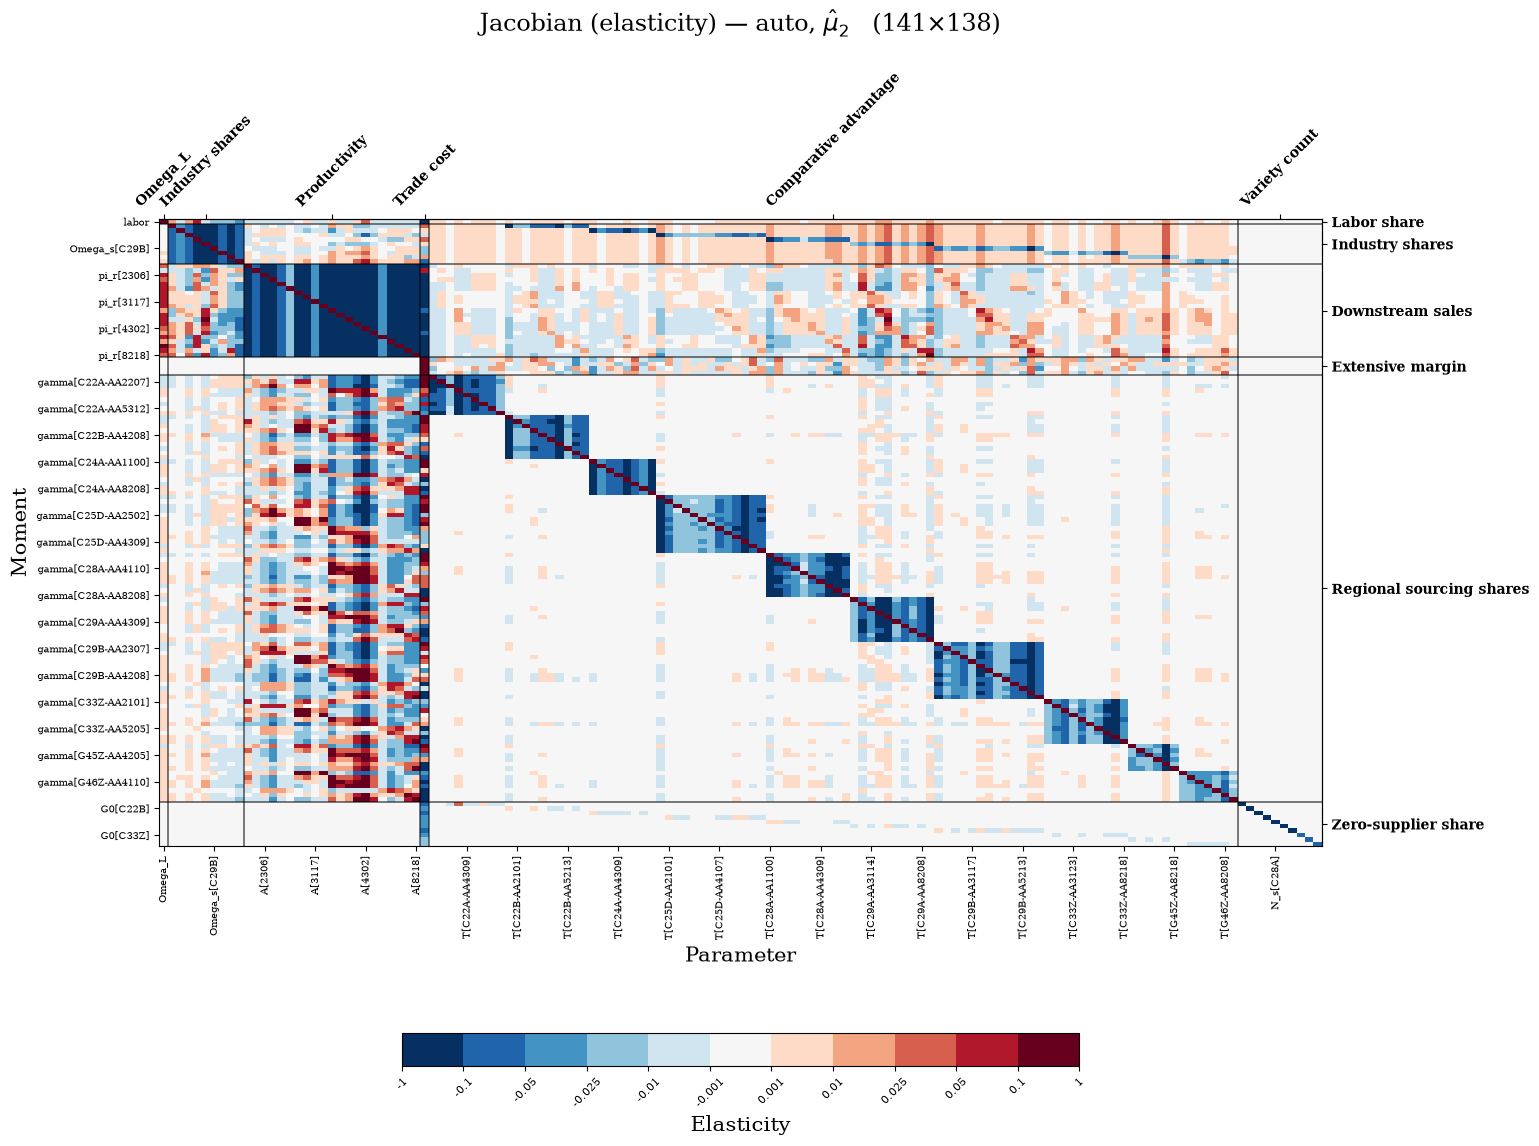

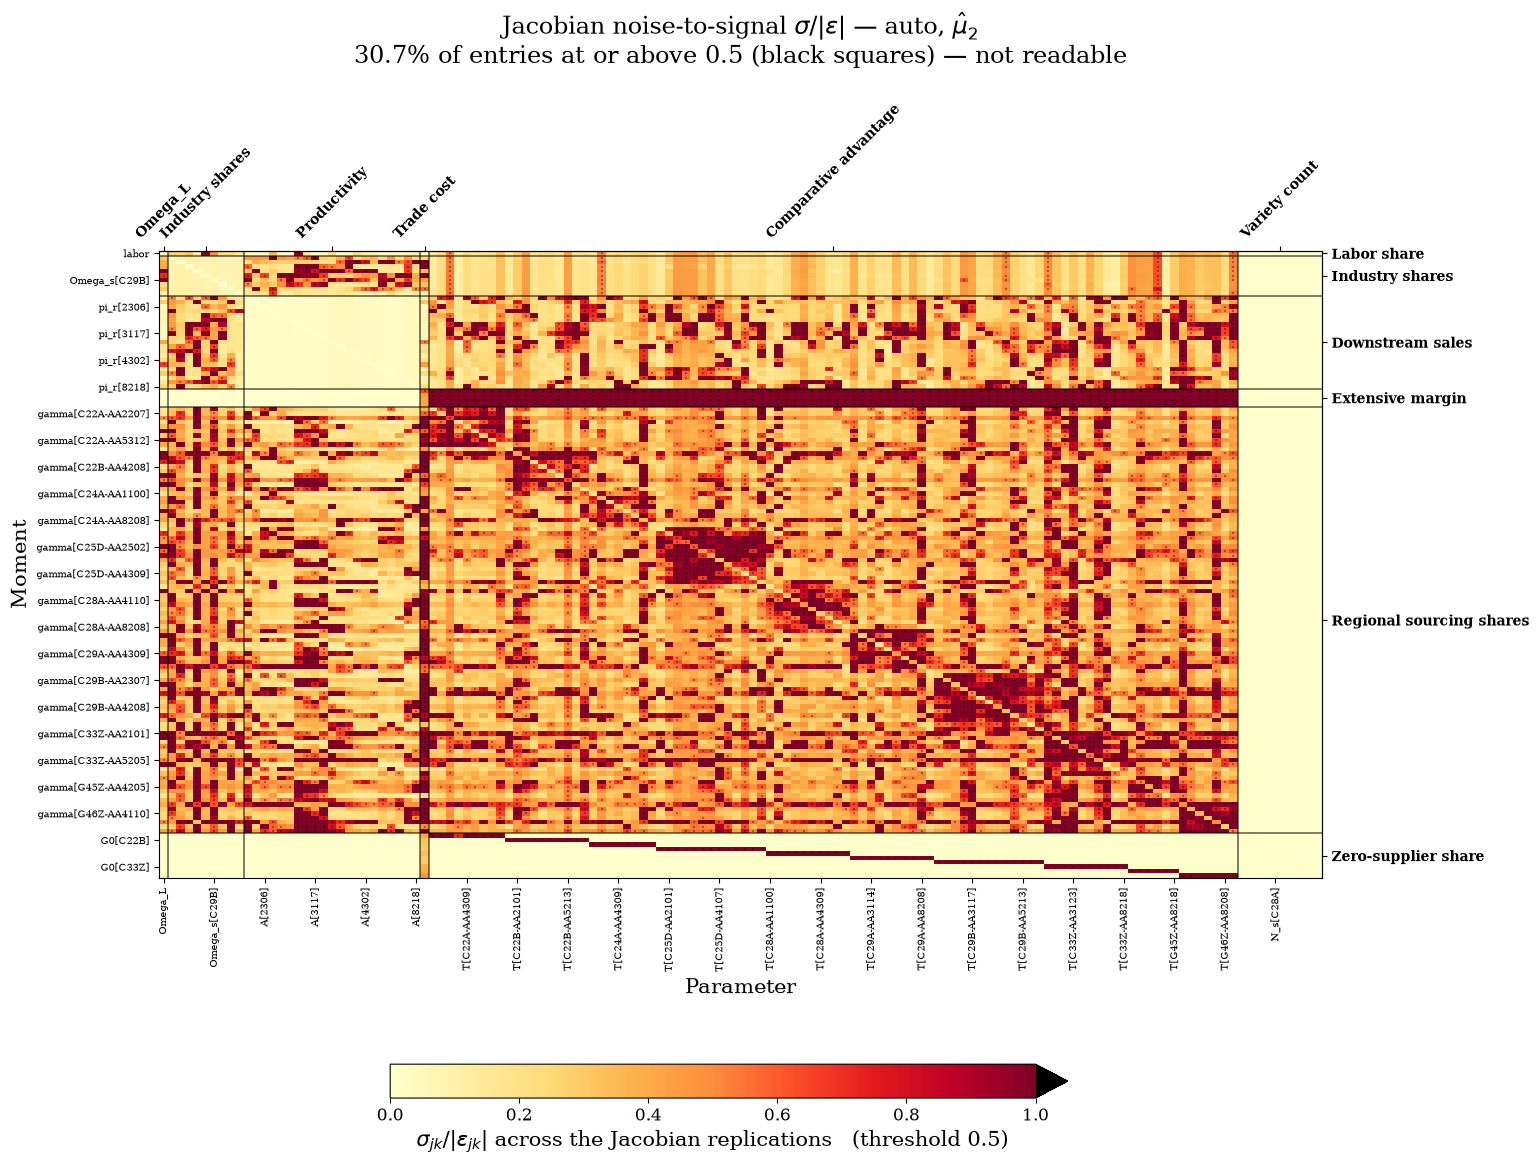

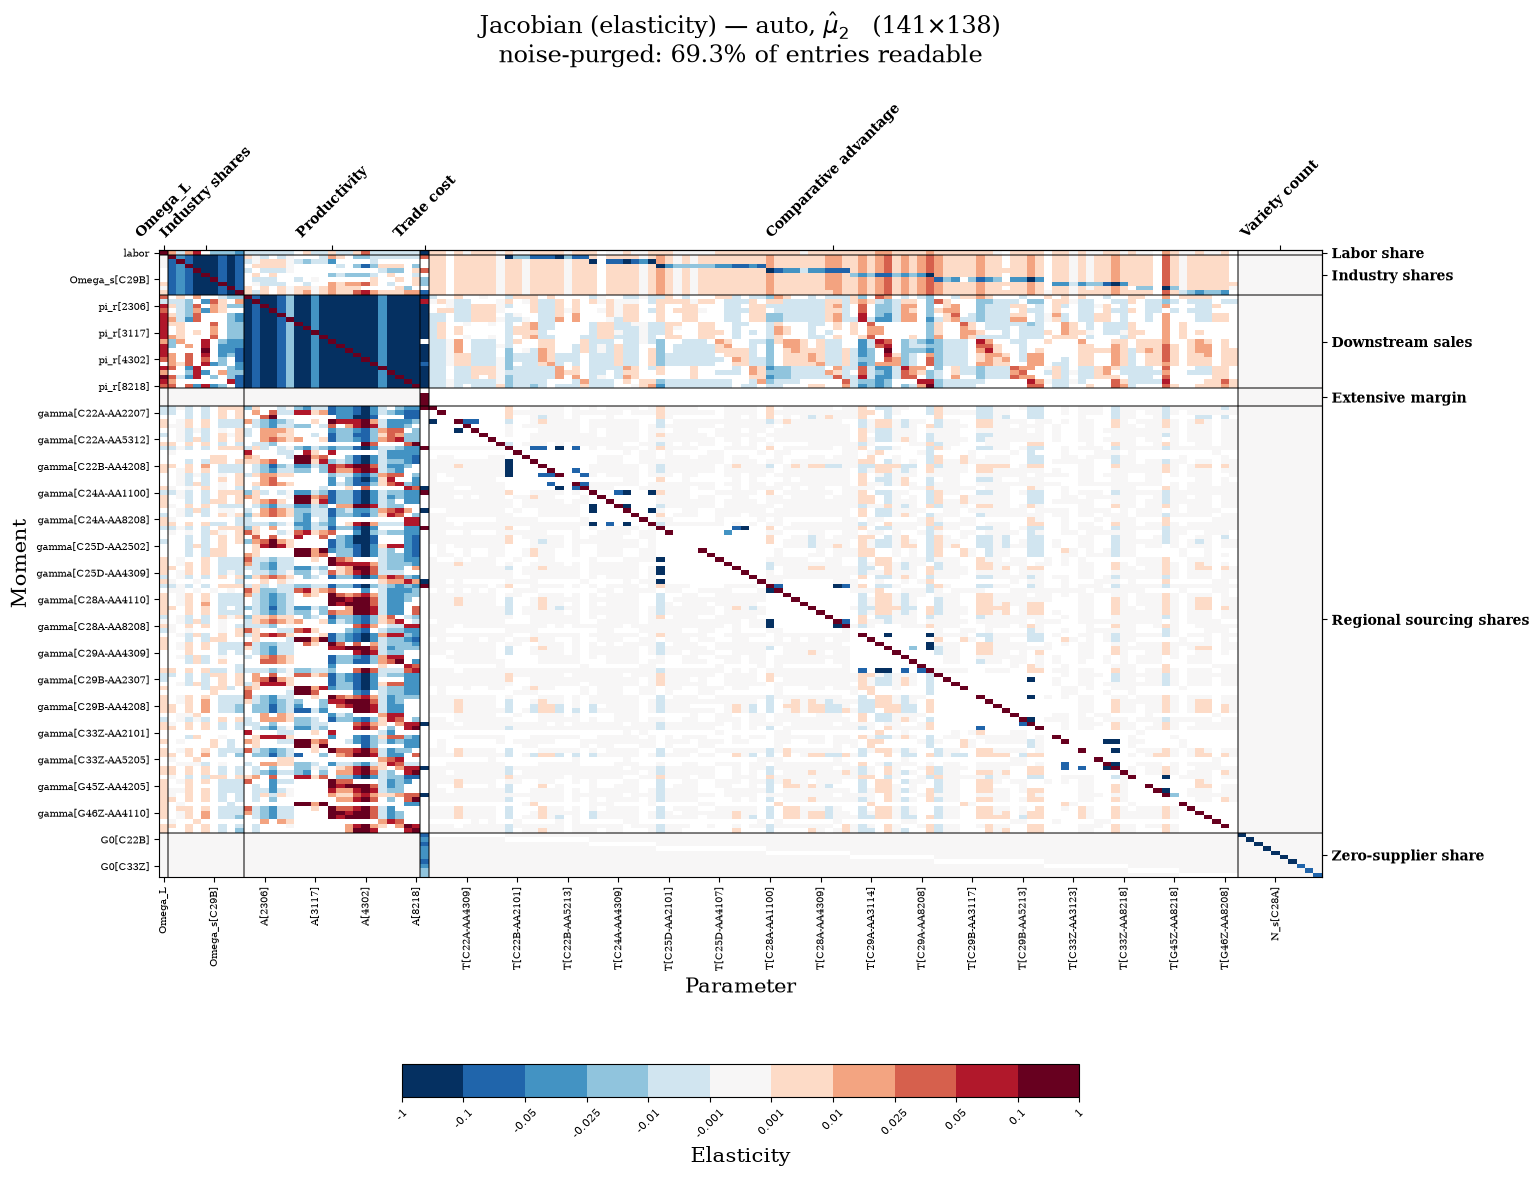

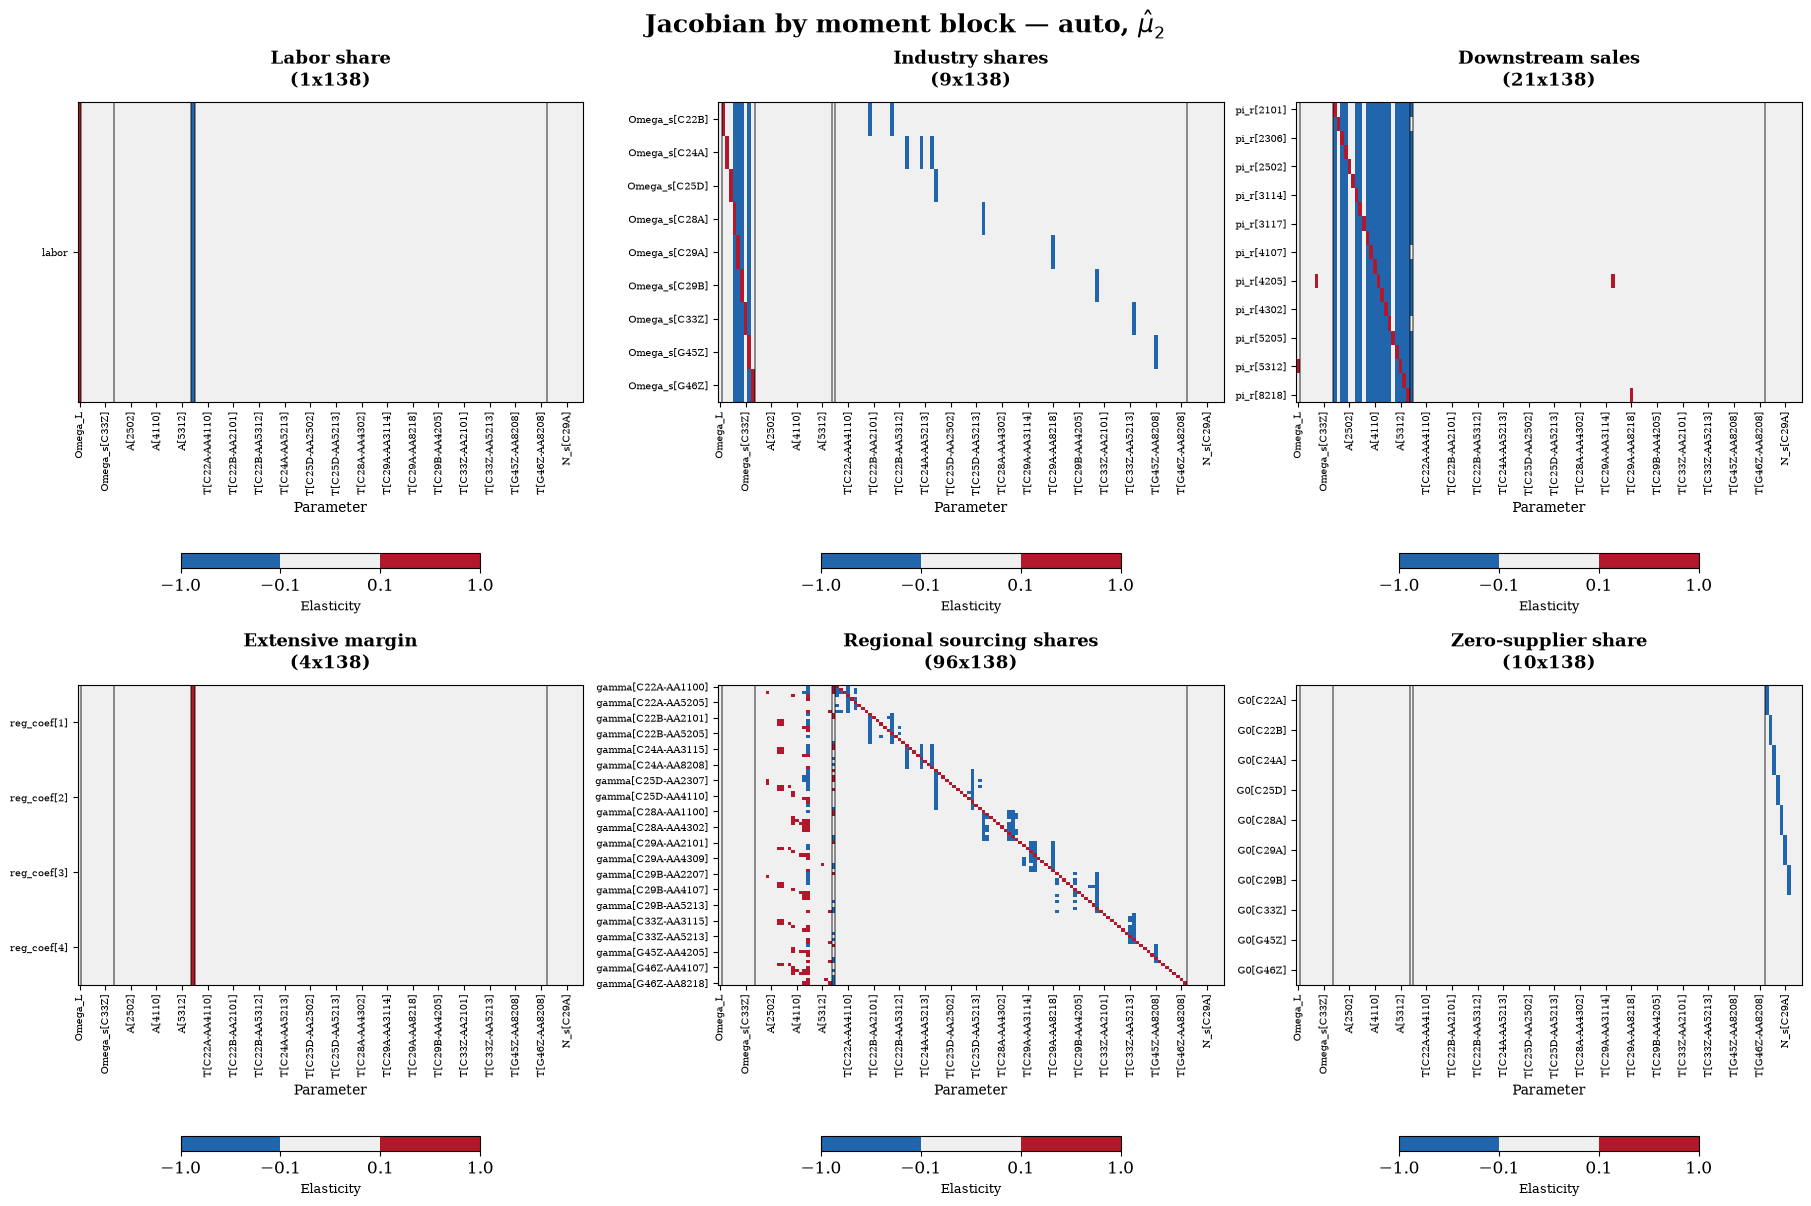

mean_abs                                          \
param_block                Omega_L Industry shares Productivity Trade cost   
moment_block                                                                 
Labor share               0.850863        0.019183     0.008162   0.496615   
Industry shares           0.000936        0.194207     0.005525   0.020718   
Downstream sales          0.050058        0.020346     0.655007   0.337642   
Extensive margin          0.000000        0.000000     0.000000   1.007340   
Regional sourcing shares  0.003350        0.001895     0.031987   0.081453   
Zero-supplier share       0.000000        0.000000     0.000000   0.047259   

                                                               max_abs  \
param_block              Comparative advantage Variety count   Omega_L   
moment_block                                                             
Labor share                           0.002888      0.000000  0.850863   
Industry shares                       0.010077      0.000000  0.002860   
Downstream sales                      0.005671      0.000000  0.104109   
Extensive margin                      0.008475      0.000000  0.000000   
Regional sourcing shares              0.017223      0.000000  0.009342   
Zero-supplier share                   0.000272      0.014944  0.000000   

                                                                  \
param_block              Industry shares Productivity Trade cost   
moment_block                                                       
Labor share                     0.060631     0.048392   0.496615   
Industry shares                 0.970375     0.059456   0.072624   
Downstream sales                0.148678     8.999605   0.707852   
Extensive margin                0.000000     0.000000   1.075402   
Regional sourcing shares        0.013277     0.720860   0.266545   
Zero-supplier share             0.000000     0.000000   0.084504   

                                                             share_readable  \
param_block              Comparative advantage Variety count        Omega_L   
moment_block                                                                  
Labor share                           0.022065      0.000000       1.000000   
Industry shares                       0.308449      0.000000       0.666667   
Downstream sales                      0.152740      0.000000       0.952381   
Extensive margin                      0.049996      0.000000       1.000000   
Regional sourcing shares              1.391970      0.000000       0.677083   
Zero-supplier share                   0.028440      0.258579       1.000000   

                                                                  \
param_block              Industry shares Productivity Trade cost   
moment_block                                                       
Labor share                     0.888889     0.952381   1.000000   
Industry shares                 1.000000     0.608466   0.555556   
Downstream sales                0.629630     1.000000   0.952381   
Extensive margin                1.000000     1.000000   0.750000   
Regional sourcing shares        0.547454     0.707837   0.114583   
Zero-supplier share             1.000000     1.000000   1.000000   

                                                              
param_block              Comparative advantage Variety count  
moment_block                                                  
Labor share                           0.937500           1.0  
Industry shares                       0.942130           1.0  
Downstream sales                      0.689484           1.0  
Extensive margin                      0.000000           1.0  
Regional sourcing shares              0.614583           1.0  
Zero-supplier share                   0.900000           1.0

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
aero: S=10  n_AA=18  N_REG=4  10 variety-count columns in the Jacobian


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


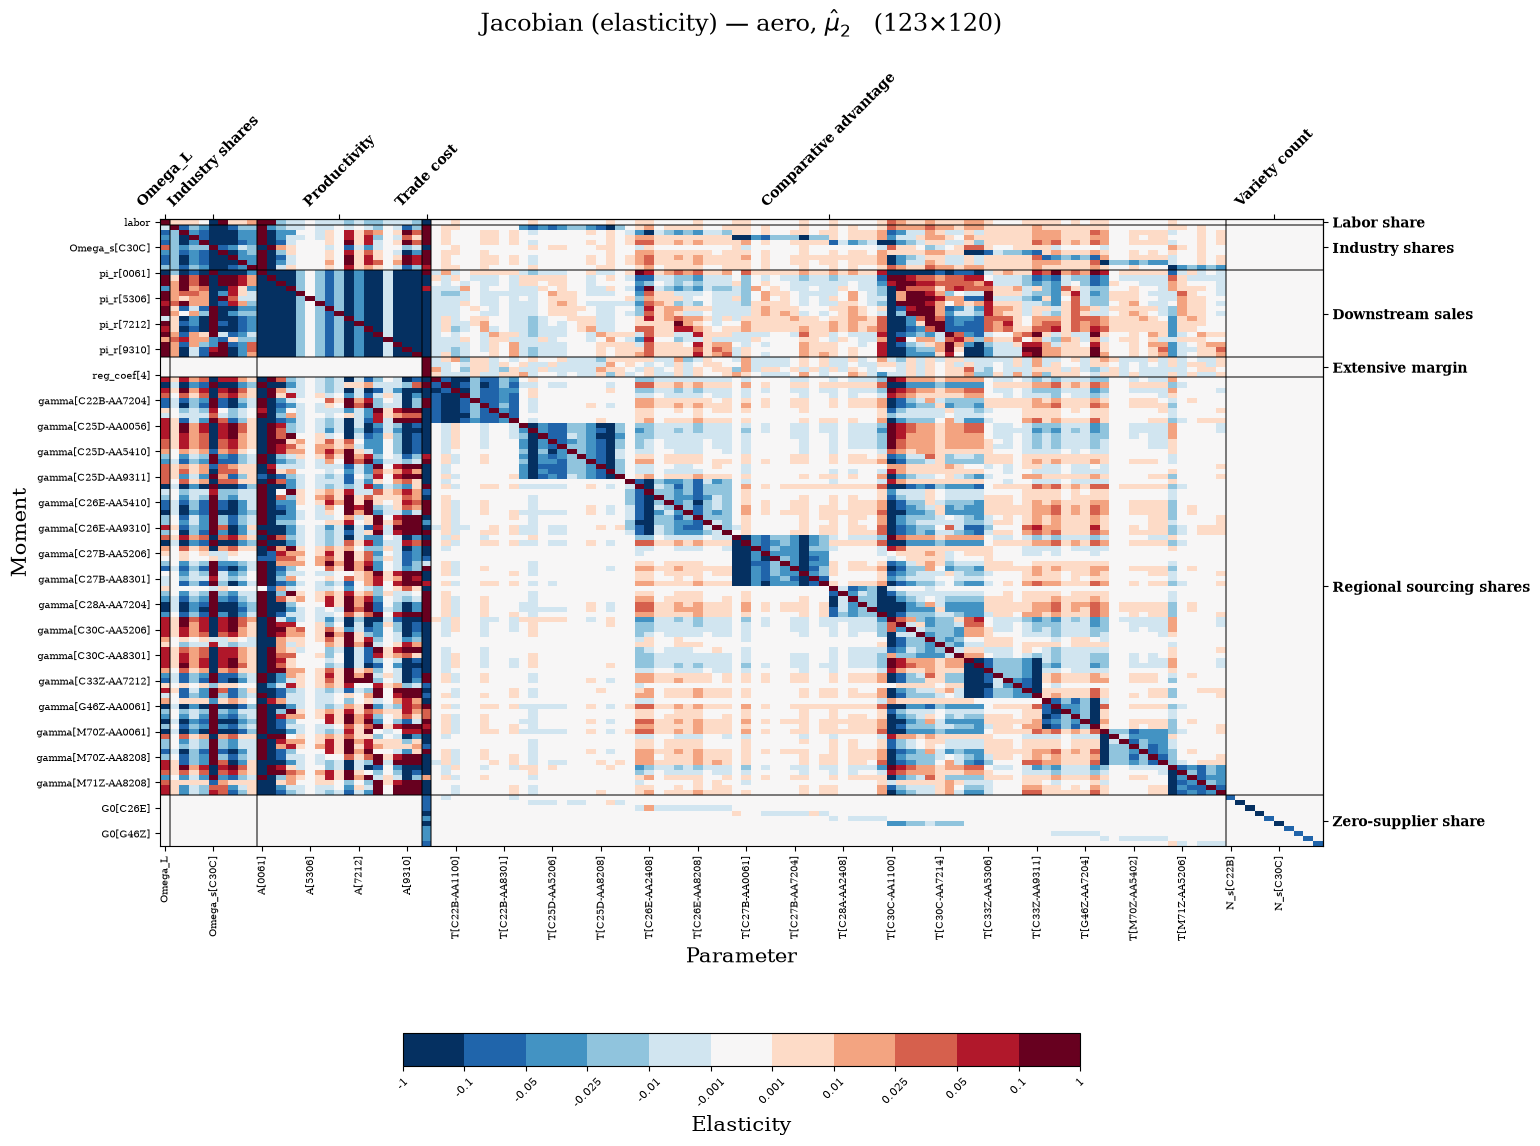

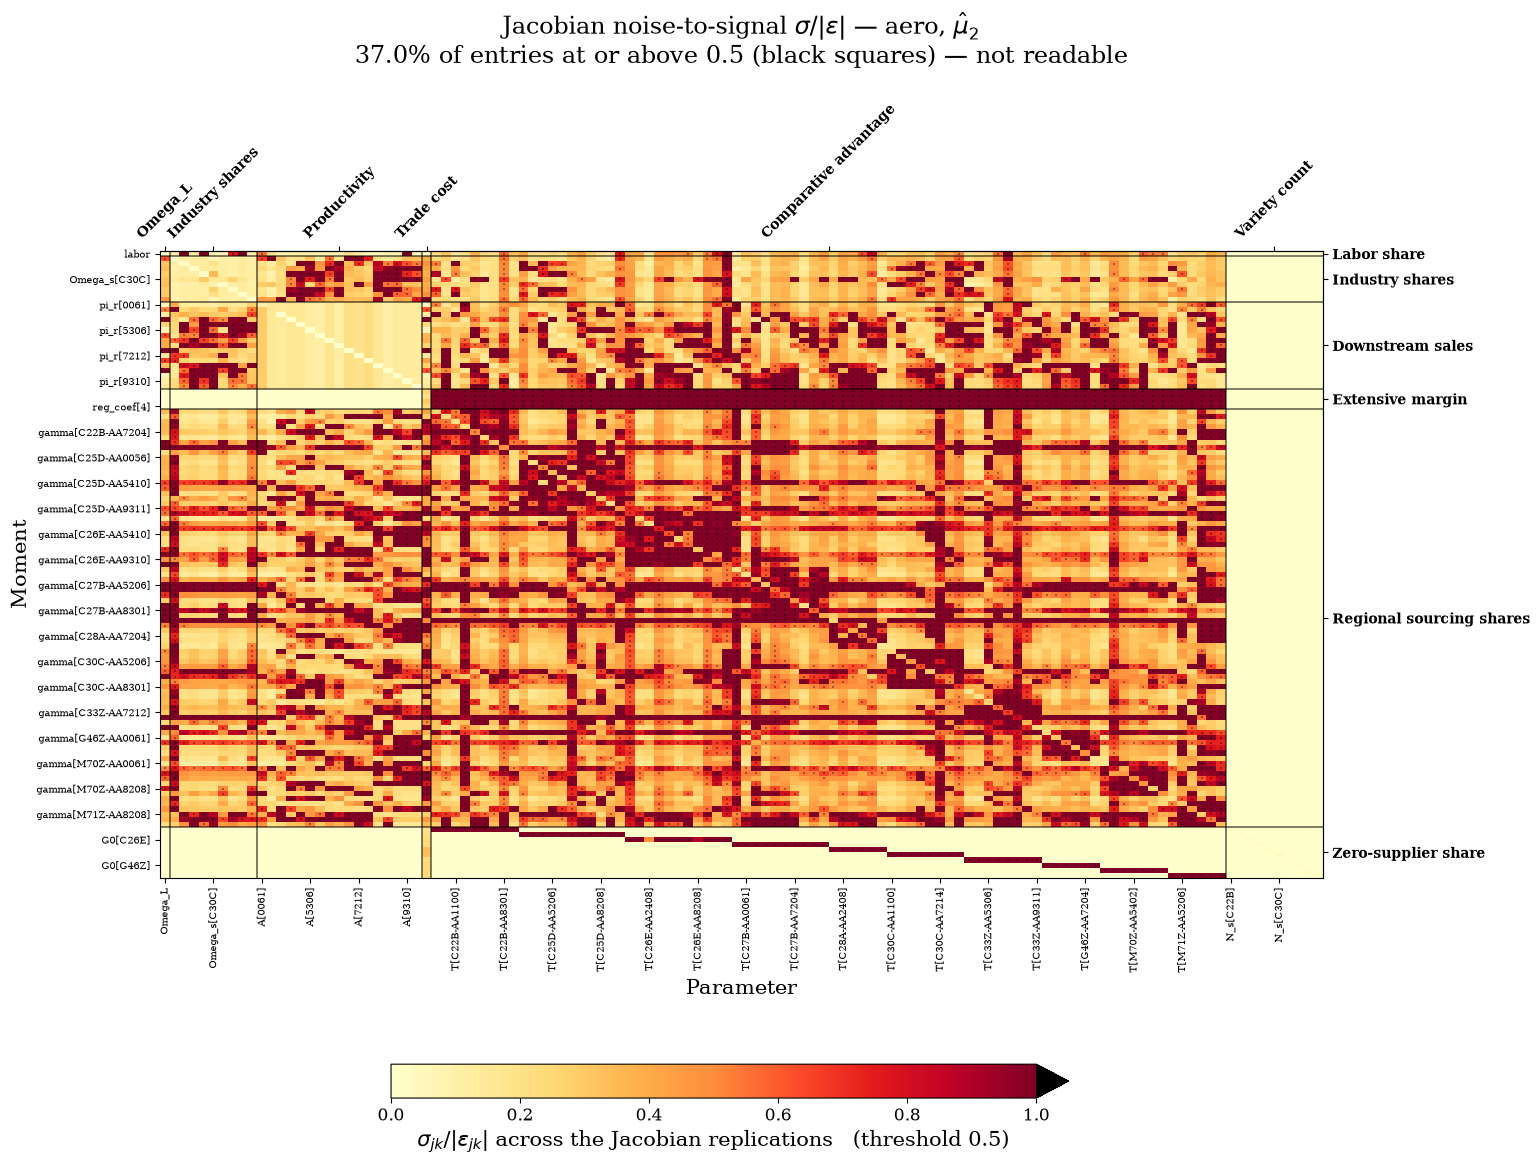

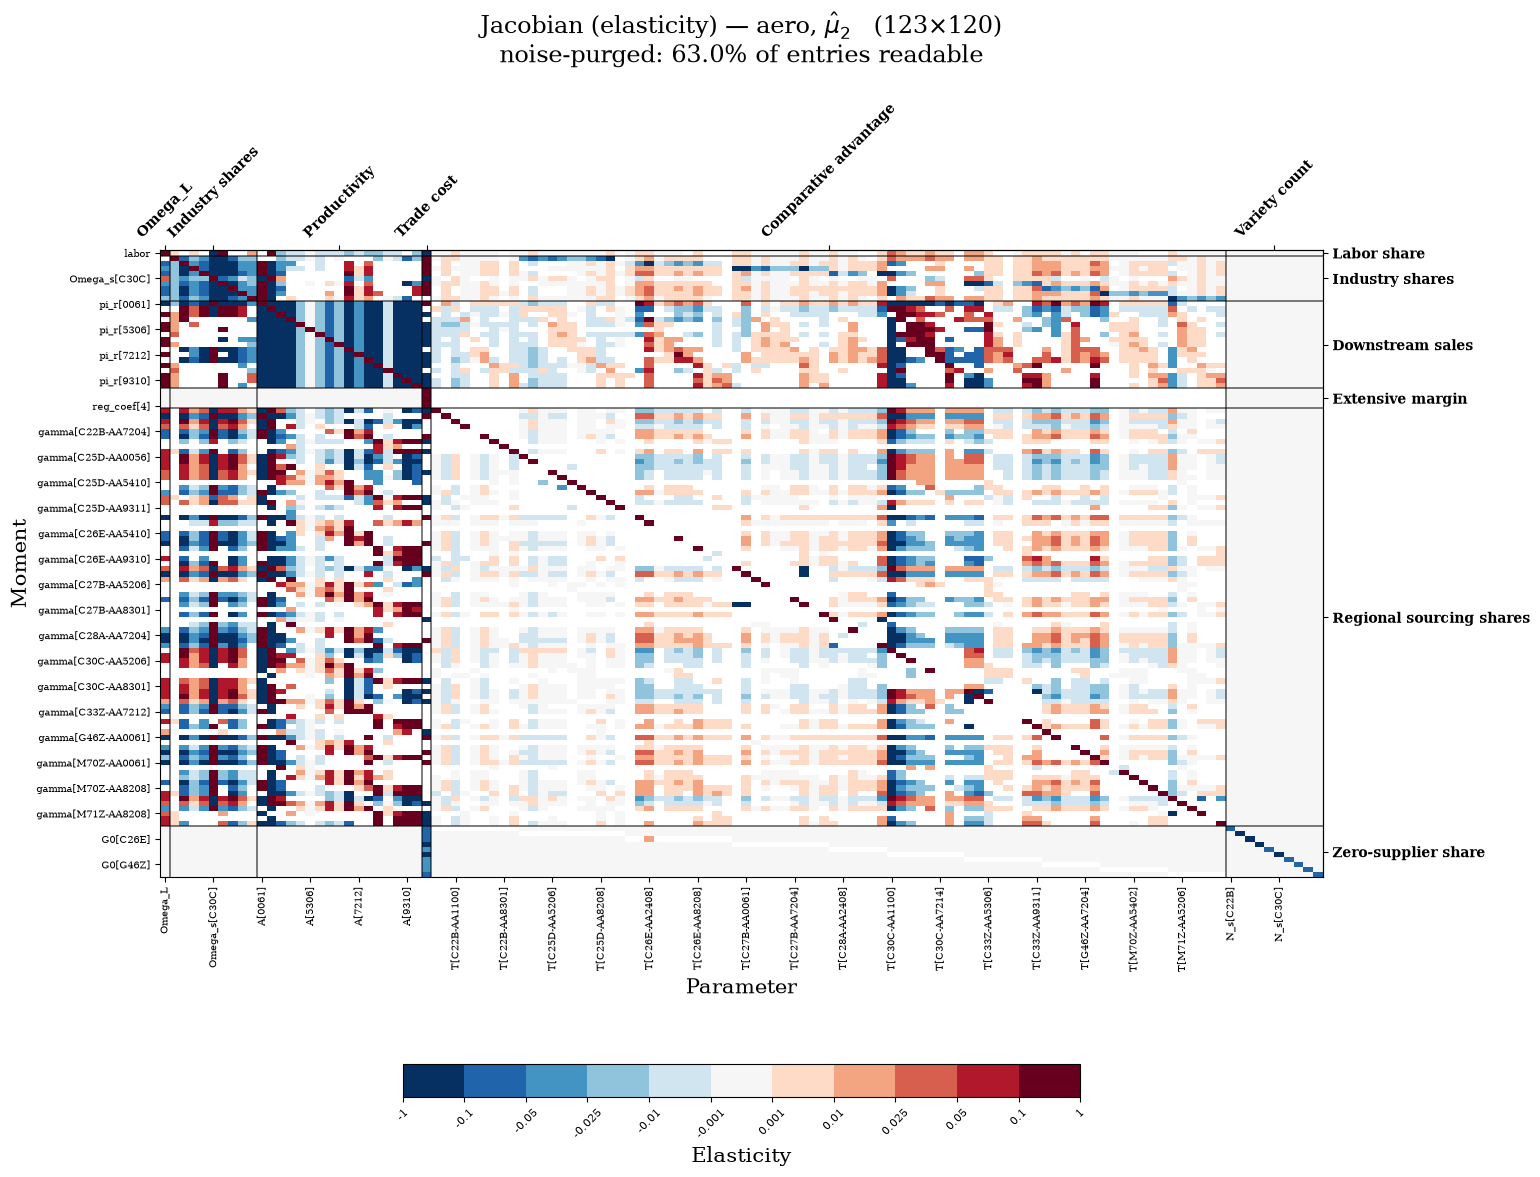

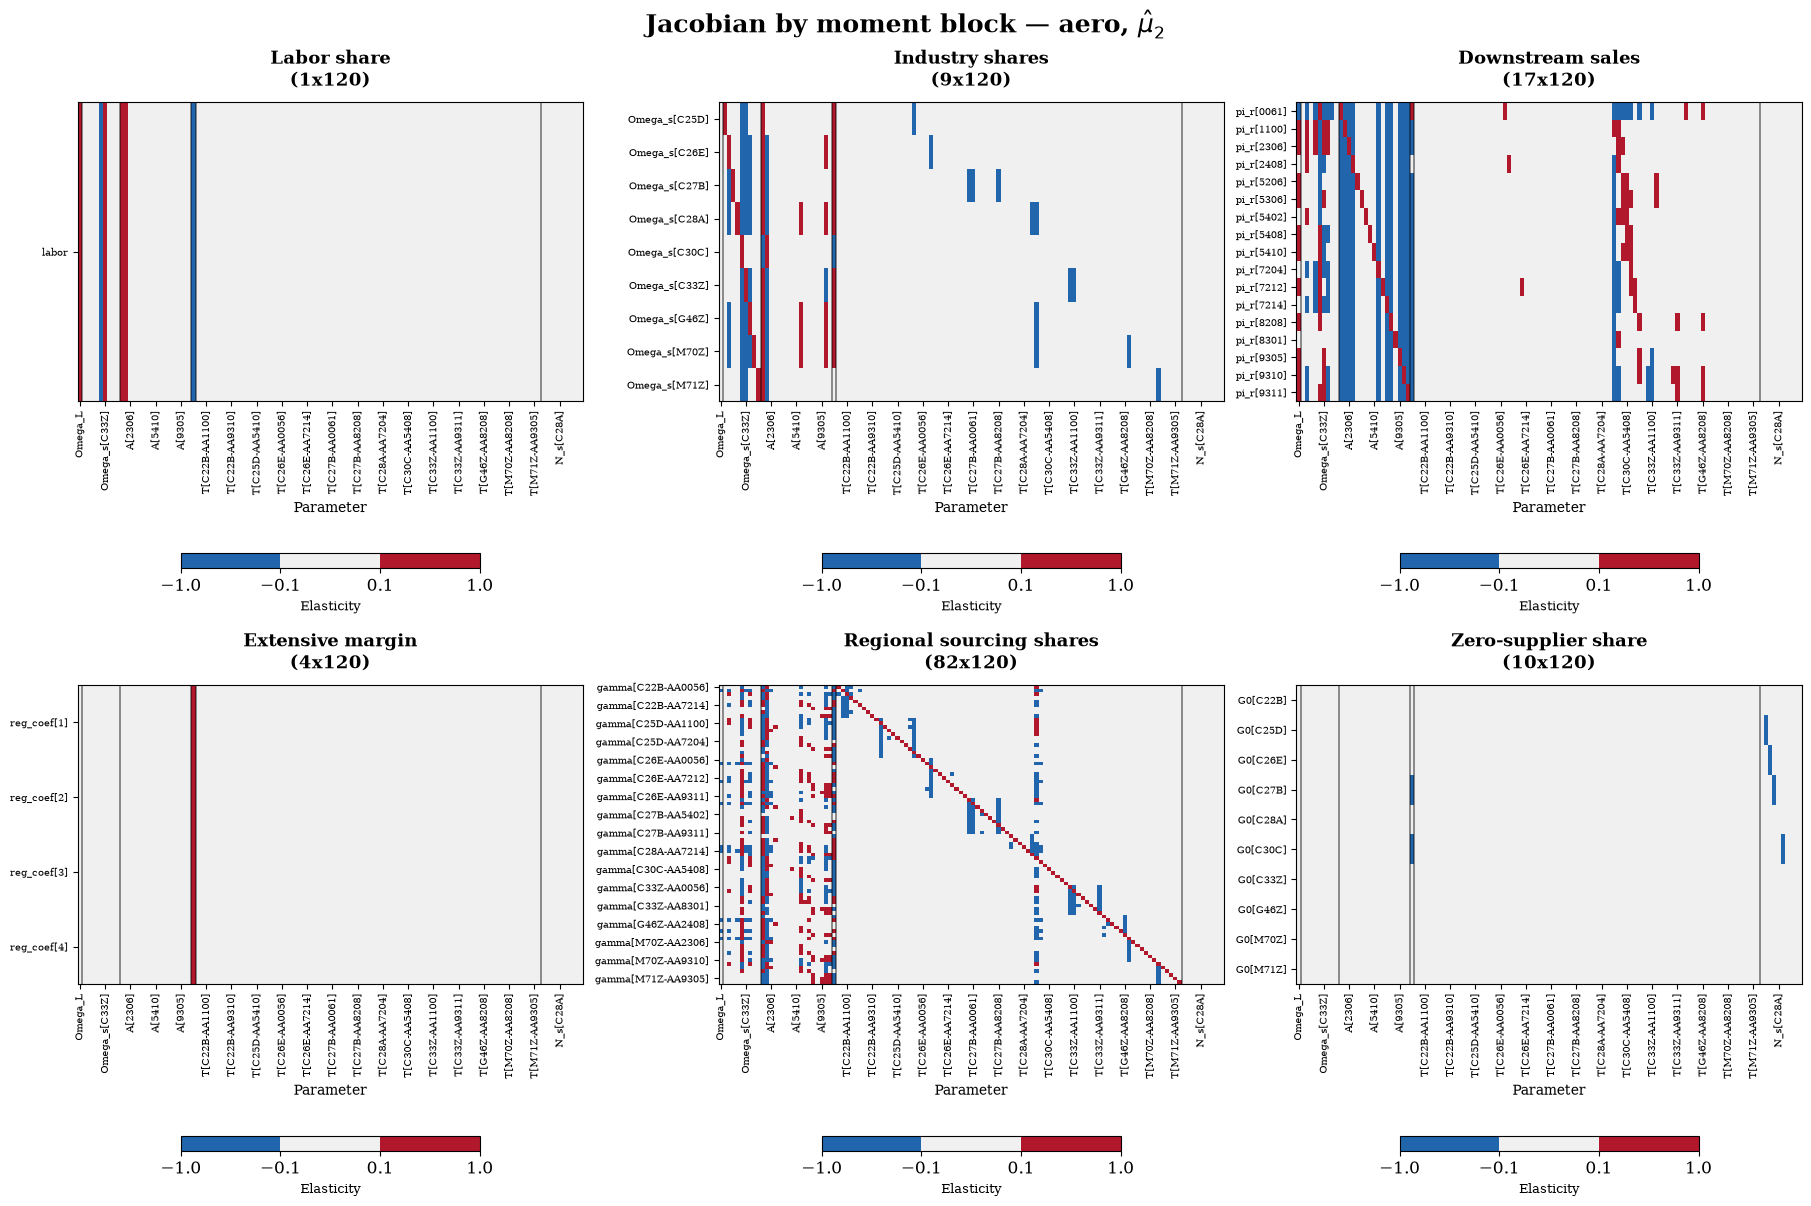

mean_abs                                          \
param_block                Omega_L Industry shares Productivity Trade cost   
moment_block                                                                 
Labor share               0.915422        0.036849     0.042412   1.032185   
Industry shares           0.044140        0.184033     0.145745   0.316900   
Downstream sales          0.247298        0.135028     1.751117   2.219452   
Extensive margin          0.000000        0.000000     0.000000   1.004450   
Regional sourcing shares  0.048798        0.063231     0.226990   0.421135   
Zero-supplier share       0.000000        0.000000     0.000000   0.070399   

                                                               max_abs  \
param_block              Comparative advantage Variety count   Omega_L   
moment_block                                                             
Labor share                           0.002375      0.000000  0.915422   
Industry shares                       0.008963      0.000000  0.079184   
Downstream sales                      0.023208      0.000000  0.749105   
Extensive margin                      0.004433      0.000000  0.000000   
Regional sourcing shares              0.023655      0.000000  0.174007   
Zero-supplier share                   0.000364      0.011081  0.000000   

                                                                  \
param_block              Industry shares Productivity Trade cost   
moment_block                                                       
Labor share                     0.170592     0.470336   1.032185   
Industry shares                 0.983702     2.108277   0.612056   
Downstream sales                2.044766    16.068156   6.665822   
Extensive margin                0.000000     0.000000   1.033366   
Regional sourcing shares        0.848383     4.169801   1.764828   
Zero-supplier share             0.000000     0.000000   0.207330   

                                                             share_readable  \
param_block              Comparative advantage Variety count        Omega_L   
moment_block                                                                  
Labor share                           0.042311      0.000000       1.000000   
Industry shares                       0.288524      0.000000       0.888889   
Downstream sales                      0.771355      0.000000       0.647059   
Extensive margin                      0.029725      0.000000       1.000000   
Regional sourcing shares              1.300148      0.000000       0.634146   
Zero-supplier share                   0.026829      0.268595       1.000000   

                                                                  \
param_block              Industry shares Productivity Trade cost   
moment_block                                                       
Labor share                     0.555556     0.882353   1.000000   
Industry shares                 1.000000     0.496732   0.888889   
Downstream sales                0.470588     1.000000   0.764706   
Extensive margin                1.000000     1.000000   1.000000   
Regional sourcing shares        0.643631     0.585366   0.304878   
Zero-supplier share             1.000000     1.000000   1.000000   

                                                              
param_block              Comparative advantage Variety count  
moment_block                                                  
Labor share                           0.817073           1.0  
Industry shares                       0.808943           1.0  
Downstream sales                      0.575323           1.0  
Extensive margin                      0.000000           1.0  
Regional sourcing shares              0.523498           1.0  
Zero-supplier share                   0.901220           1.0

In [256]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"{data['n_N_cols']} variety-count columns in the Jacobian")

    # the triptych: as is, the noise-to-signal map, and the purged matrix
    plot_jacobian_triptych(data, noise_max=NOISE_MAX, out_folder=out_folder,
                           tag="jacobian")
    plot_jacobian_blocks(data, save_to=f"{out_folder}/jacobian_blocks_{industry}_mu{MU}.pdf")
    plt.show()
    display(jacobian_block_summary(data, noise_max=NOISE_MAX))


## Variance-covariance of the moments


Three matrices, all written by Step 2:

* $\Sigma_{data}$ — the bootstrap covariance of the **empirical** moments: how precisely
  the targets are measured;
* $\Sigma_{sim}$ — the covariance across $K$ re-simulations at $\hat\theta_1$: how much
  of the moment vector is Monte-Carlo noise from the simulator;
* $\Omega = \Sigma_{data} + \Sigma_{sim}$ — what the estimator actually weighted with,
  $W = \Omega^{-1}$.

Two views of each. The **covariance** panels are on a common diverging scale, so the
relative magnitude of the three is visible — which is the point, since
$\mathrm{tr}(\Sigma_{sim})/\mathrm{tr}(\Sigma_{data})$ is the share of the weighting that
is simulation rather than data, and the dial for it is `--n_rho_inf`. The **correlation**
panels rescale each matrix by its own diagonal, which removes that magnitude and leaves
the dependence structure: whether the sampling error of the sourcing shares is correlated
across areas, whether the simulation noise is (it is, through the shared draws), and
whether $\Omega$ inherits its correlation from the data or from the simulator.


In [257]:
# The three moment covariance matrices, and the correlations they imply.

def _gb_edges(data):
    """
    Block edges of the inference subsystem and their names.

    The three blocks are stacked in a fixed order — extensive-margin coefficients,
    sourcing shares, zero-supplier shares — on both axes of every Sigma / Omega / W on
    disk. That order is the "beta, gamma, G" ordering invariant of CLAUDE.md.
    """
    n_beta = data["n_coef"]
    n_gam = int(np.asarray(data["moment_block_sizes"])[4])
    sizes = [n_beta, n_gam] + ([data["S"]] if data["granular"] else [])
    names = ["reg_coef", "gamma", "G0"][:len(sizes)]
    return np.cumsum([0] + sizes), names


def _cov_panel(ax, M, data, title, mode="cov", pct=95):
    """One matrix panel with the block grid drawn on; `mode` is "cov" or "corr"."""
    from matplotlib.colors import TwoSlopeNorm
    edges, names = _gb_edges(data)
    if mode == "corr":
        d = np.sqrt(np.clip(np.diag(M), 1e-300, None))
        M = M / np.outer(d, d)
        im = ax.matshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
    else:
        v = np.percentile(np.abs(M), pct)
        v = v if v > 0 else (np.abs(M).max() or 1.0)
        im = ax.matshow(M, cmap="RdBu_r", norm=TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v))
    for e in edges[1:-1]:
        ax.axhline(e - 0.5, color="black", linewidth=0.8, alpha=0.6)
        ax.axvline(e - 0.5, color="black", linewidth=0.8, alpha=0.6)
    ticks = (edges[:-1] + edges[1:]) / 2 - 0.5
    ax.set_xticks(ticks)
    ax.set_xticklabels(names, fontsize=9)
    ax.set_yticks(ticks)
    ax.set_yticklabels(names, fontsize=9, rotation=90, va="center")
    ax.set_title(title, pad=14)
    return im


def _cov_matrices(data):
    return [("$\\Sigma_{sim}$ (simulation noise)", data.get("Sigma_sim")),
            ("$\\Sigma_{data}$ (bootstrap)", data.get("Sigma_data")),
            ("$\\Omega = \\Sigma_{data} + \\Sigma_{sim}$", data.get("Omega"))]


def plot_variance_covariance(data, figsize=(16, 5.5), pct=95, save_to=None):
    """Sigma_sim, Sigma_data and Omega side by side, each on its own diverging scale."""
    mats = _cov_matrices(data)
    if all(m is None for _, m in mats):
        raise FileNotFoundError(f"no Sigma_*/Omega in {data['folder']}/step2/ — "
                                "build_step3_weight_matrix writes them in Step 2.")
    fig, axes = plt.subplots(1, len(mats), figsize=figsize)
    for ax, (title, M) in zip(np.atleast_1d(axes), mats):
        if M is None:
            ax.axis("off")
            ax.set_title(title + "\n(absent)")
            continue
        im = _cov_panel(ax, M, data, title, mode="cov", pct=pct)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"Moment variance-covariance — {data['industry']} "
                 "(extensive margin, sourcing shares, zero-supplier shares)", fontsize=14)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes


def plot_moment_correlation(data, figsize=(16, 5.5), save_to=None):
    """
    The same three matrices as CORRELATIONS, on a common [-1, 1] scale.

    Rescaling by the diagonal removes the magnitude — which the covariance figure is
    there to show — and leaves the dependence structure, so the three are comparable:
    whether the bootstrap error of the sourcing shares is correlated across areas,
    whether the simulator's noise is (it is, through the shared draws), and which of the
    two Omega inherits its structure from.
    """
    mats = _cov_matrices(data)
    if all(m is None for _, m in mats):
        raise FileNotFoundError(f"no Sigma_*/Omega in {data['folder']}/step2/")
    fig, axes = plt.subplots(1, len(mats), figsize=figsize)
    for ax, (title, M) in zip(np.atleast_1d(axes), mats):
        if M is None:
            ax.axis("off")
            ax.set_title(title + "\n(absent)")
            continue
        im = _cov_panel(ax, M, data, title, mode="corr")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"Moment CORRELATION — {data['industry']} "
                 "(same three matrices, rescaled by their own diagonal)", fontsize=14)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes


def variance_covariance_summary(data):
    """
    How much of the weighting is simulation noise, and how well conditioned is Omega?

    `trace(Sigma_sim)/trace(Sigma_data)` is the share of total moment variance that comes
    from the simulation rather than the data — raise `--n_rho_inf` if it is not small.
    `mean_abs_offdiag_corr` is the average absolute off-diagonal correlation, the same
    thing the correlation figure shows, as one number per matrix. The condition numbers
    say whether inverting Omega to build W is safe.
    """
    out = {}
    for name in ("Sigma_data", "Sigma_sim", "Omega"):
        M = data.get(name)
        if M is None:
            continue
        ev = np.linalg.eigvalsh((M + M.T) / 2)
        d = np.sqrt(np.clip(np.diag(M), 1e-300, None))
        C = M / np.outer(d, d)
        off = ~np.eye(C.shape[0], dtype=bool)
        out[name] = {"trace": float(np.trace(M)),
                     "eig_min": float(ev.min()), "eig_max": float(ev.max()),
                     "cond": float(ev.max() / ev.min()) if ev.min() > 0 else np.inf,
                     "mean_abs_offdiag_corr": float(np.abs(C[off]).mean())}
    if "Sigma_sim" in out and "Sigma_data" in out and out["Sigma_data"]["trace"] != 0:
        out["Sigma_sim"]["share_of_data_trace"] = \
            out["Sigma_sim"]["trace"] / out["Sigma_data"]["trace"]
    return pd.DataFrame(out).T


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


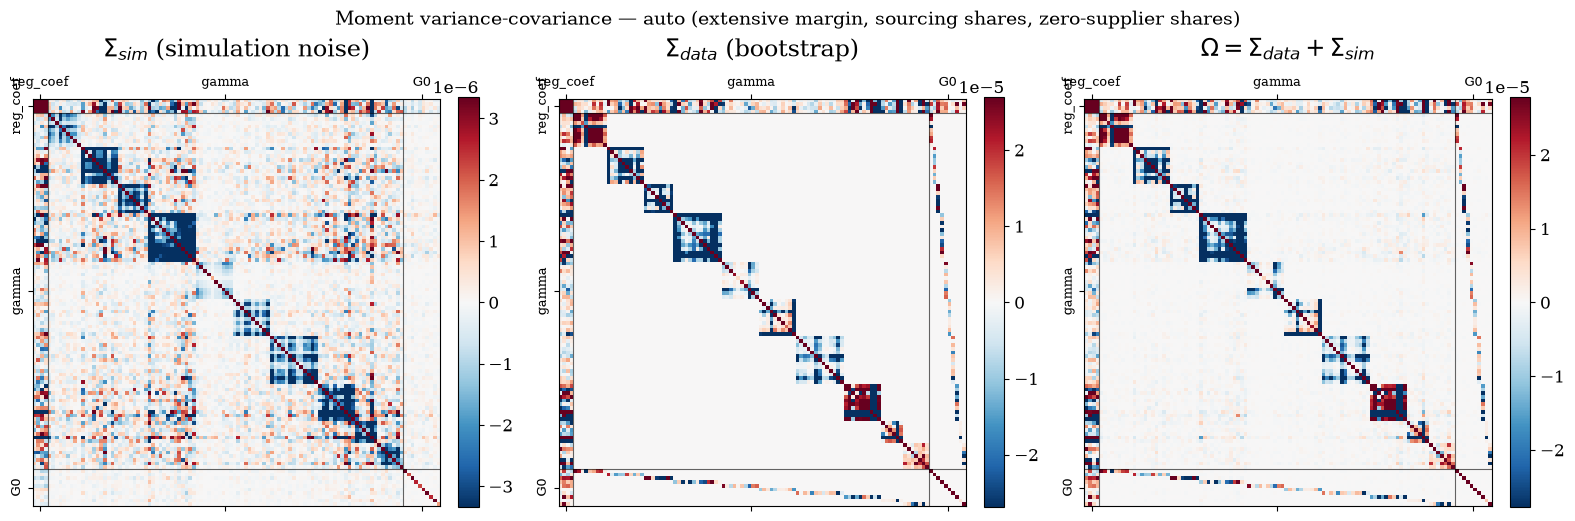

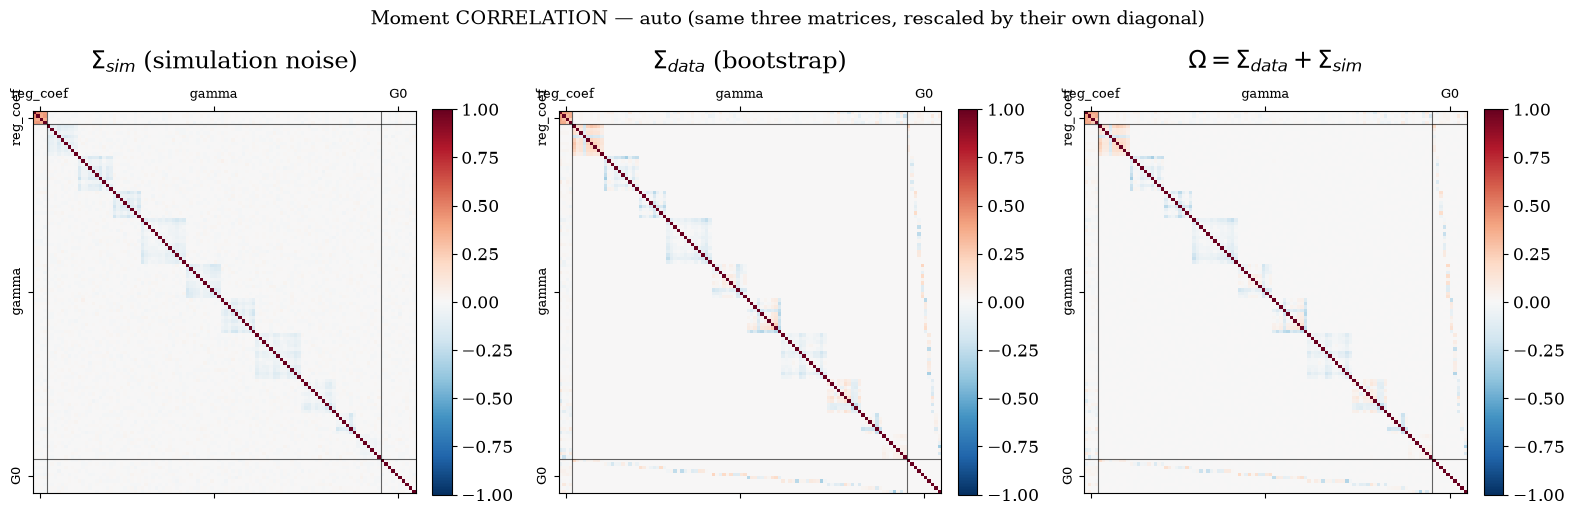

,trace,eig_min,eig_max,cond,mean_abs_offdiag_corr,share_of_data_trace
Sigma_data,0.104737,0.000004,0.016072,4364.240277,0.008364,NaN
Sigma_sim,0.010705,0.000001,0.001025,897.200289,0.012564,0.102207
Omega,0.115442,0.000006,0.017066,2675.166214,0.008446,NaN


[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


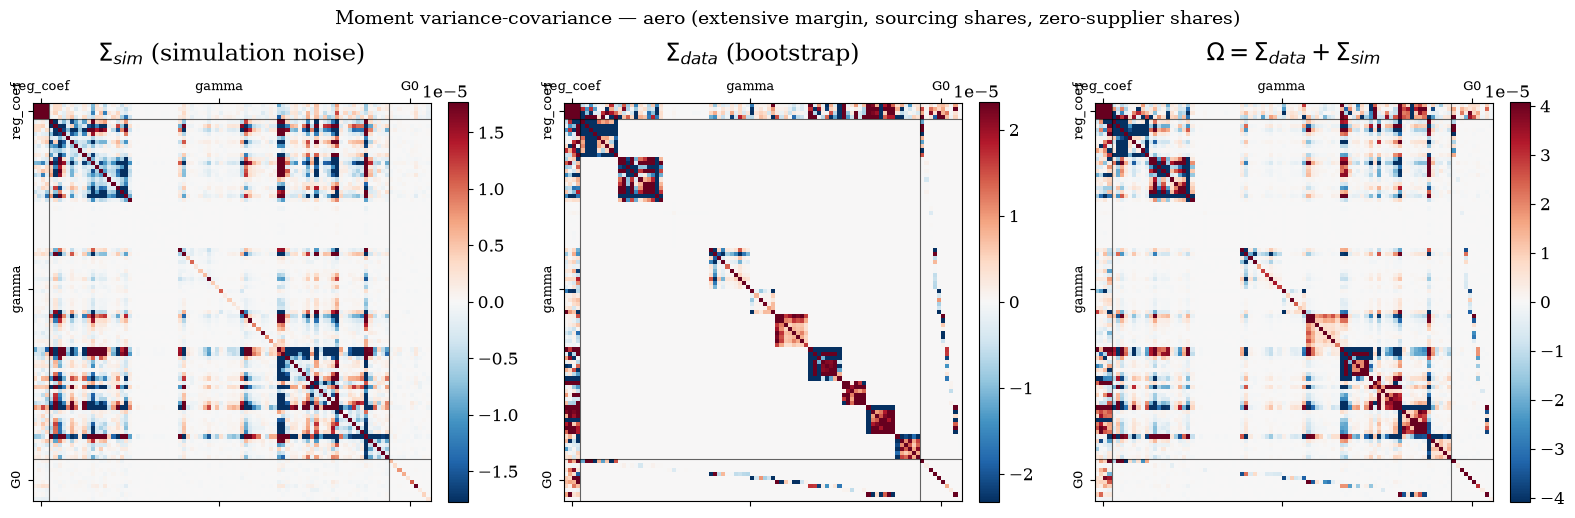

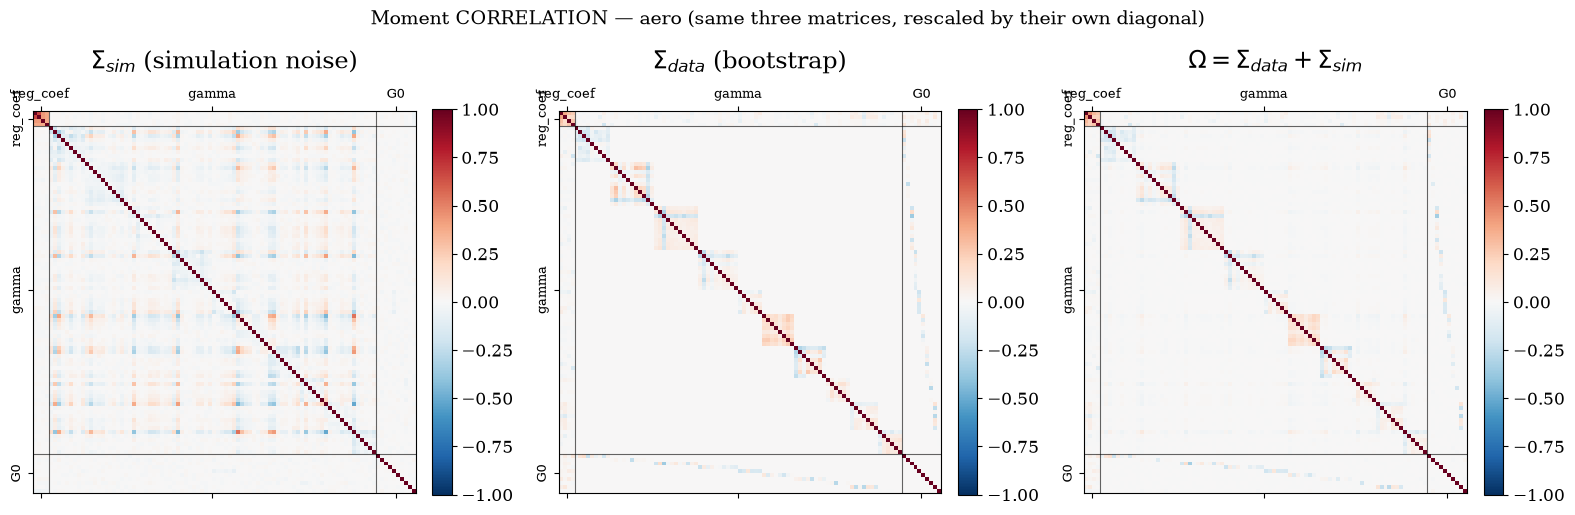

,trace,eig_min,eig_max,cond,mean_abs_offdiag_corr,share_of_data_trace
Sigma_data,0.105054,1.109410e-31,0.018817,1.696163e+29,0.009591,NaN
Sigma_sim,0.012335,8.476414e-10,0.002070,2.442018e+06,0.030626,0.117417
Omega,0.117389,5.094955e-09,0.019603,3.847463e+06,0.011524,NaN


In [258]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_variance_covariance(data, save_to=f"{out_folder}/varcov_{industry}.pdf")
    plt.show()
    plot_moment_correlation(
        data, save_to=f"{out_folder}/moment_correlation_{industry}.pdf")
    plt.show()
    display(variance_covariance_summary(data))


## Identification / sensitivity

A sensitivity analysis fixes every parameter, moves one of them above and below its
estimate, and checks that the moments respond smoothly and in the direction the design
predicts. The elasticity Jacobian *is* that experiment, linearised at the estimate:
$\varepsilon_{jk} = \partial \log m_j / \partial \log \theta_k$ is the local slope of
moment $j$ against parameter $k$. With ten sectors, the attraction areas, the $T$ block
and the variety counts there are far too many parameters to draw a curve each, so the
matrix is drawn instead and everything too small — or too noisy — is blanked out.

Two thresholds, and they answer different questions:

* $|\varepsilon| \geq$ `IDENT_THRESHOLD` (0.01): a 1% move in the parameter shifts the
  moment by at least 0.01%. **Is there a channel?**
* $\sigma/|\varepsilon| <$ `NOISE_MAX` (0.5): the elasticity is estimated precisely
  enough relative to its own size. **Can we see it?** An entry that fails this is not
  evidence of a weak channel; it is evidence of nothing at all, and the summary counts it
  separately rather than pooling it with the structural zeros.

What the figures are meant to show: the three channels are close to orthogonal *by
construction*. $\alpha$ is read from a **within**-area distance gradient that comparative
advantage cannot touch, since comparative advantage is constant within an area; $T_{as}$
is read from **across**-area value shares; $N_s$ is read from the **level** of the
empty-region share, which the sector $\times$ nearest-downstream fixed effect strips out
of the $\alpha$ regression. So the expected picture is near-block-diagonal on the
(Trade cost, Comparative advantage, Variety count) $\times$ (Extensive margin, Regional
sourcing shares, Zero-supplier share) corner — and in the $N_s$ columns *exact* zeros
rather than merely small numbers.


In [259]:
# Identification / sensitivity — the elasticity Jacobian read as the experiment
# "move one parameter, watch the moments", with two thresholds: is there a channel
# (IDENT_THRESHOLD), and is it measured well enough to see (NOISE_MAX).
#
# The variety counts N_s are part of the parameter axis: the Julia side appends
# dm/dN_s to the saved Jacobian, so no re-attachment is done here.

IDENT_THRESHOLD = 0.01


def _blocks_2d(data, M):
    """M split into (moment block x parameter block) sub-matrices."""
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])
    return {(i, j): M[m_edges[i]:m_edges[i + 1], p_edges[j]:p_edges[j + 1]]
            for i in range(len(data["moment_block_names"]))
            for j in range(len(data["param_block_names"]))}


def _readable(data, kind="elasticity", noise_max=NOISE_MAX):
    """Boolean matrix: entries whose elasticity is precise enough to be interpreted."""
    if noise_max is None:
        return np.ones_like(np.asarray(jacobian_matrix(data, kind), float), dtype=bool)
    try:
        return ~jacobian_noise_mask(data, kind=kind, noise_max=noise_max)
    except FileNotFoundError:
        return np.ones_like(np.asarray(jacobian_matrix(data, kind), float), dtype=bool)


def identification_summary(data, threshold=IDENT_THRESHOLD, kind="elasticity",
                           noise_max=NOISE_MAX):
    """
    Per (moment block x parameter block), four numbers that answer four questions:

      share_above       is there a channel?  share of entries with |elasticity| >= threshold
      share_readable    can it be seen?      share whose sigma/|elasticity| < noise_max
      share_live        both at once         above the threshold AND readable
      share_exact_zero  is it absent by construction?  share of entries exactly 0

    The last two are the pair worth reading together: an exact zero is the model saying
    the channel does not exist (the N_s columns outside block 6, asserted in Julia),
    whereas an unreadable entry says nothing at all.
    """
    E = np.abs(np.asarray(jacobian_matrix(data, kind), float))
    ok = _readable(data, kind, noise_max)
    rows = []
    for (i, j), sub in _blocks_2d(data, E).items():
        sub_ok = _blocks_2d(data, ok)[(i, j)]
        rows.append({
            "moment_block": data["moment_block_names"][i],
            "param_block": data["param_block_names"][j],
            "share_above": float((sub >= threshold).mean()) if sub.size else np.nan,
            "share_readable": float(sub_ok.mean()) if sub.size else np.nan,
            "share_live": float(((sub >= threshold) & sub_ok).mean()) if sub.size else np.nan,
            "max_abs": float(sub.max()) if sub.size else np.nan,
            "mean_abs": float(sub.mean()) if sub.size else np.nan,
            "share_exact_zero": float((sub == 0).mean()) if sub.size else np.nan,
        })
    df = pd.DataFrame(rows)
    return df.set_index(["moment_block", "param_block"]).unstack("param_block") \
             .reindex(index=data["moment_block_names"]) \
             .reindex(columns=data["param_block_names"], level=1)


def plot_identification_map(data, threshold=IDENT_THRESHOLD, kind="elasticity",
                            noise_max=NOISE_MAX, figsize=(9, 6), save_to=None):
    """
    One cell per (moment block x parameter block), coloured by the share of entries that
    are BOTH above the threshold and readable, annotated with that share, the block's
    max |elasticity|, and — when it is not 100% — the share of the block that is readable
    at all. A near-diagonal pattern down the (Trade cost, Comparative advantage, Variety
    count) columns is the identification claim, read off directly.
    """
    E = np.abs(np.asarray(jacobian_matrix(data, kind), float))
    ok = _readable(data, kind, noise_max)
    m_names, p_names = data["moment_block_names"], data["param_block_names"]
    blocks, blocks_ok = _blocks_2d(data, E), _blocks_2d(data, ok)
    n_m, n_p = len(m_names), len(p_names)

    def _grid(fn):
        return np.array([[fn(blocks[(i, j)], blocks_ok[(i, j)])
                          if blocks[(i, j)].size else np.nan
                          for j in range(n_p)] for i in range(n_m)])

    live = _grid(lambda s, o: ((s >= threshold) & o).mean())
    mx = _grid(lambda s, o: s.max())
    read = _grid(lambda s, o: o.mean())

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.matshow(live, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    for i in range(n_m):
        for j in range(n_p):
            if not np.isfinite(live[i, j]):
                continue
            txt = f"{100 * live[i, j]:.0f}%\nmax {mx[i, j]:.3g}"
            if read[i, j] < 0.999:
                txt += f"\n({100 * read[i, j]:.0f}% readable)"
            ax.text(j, i, txt, ha="center", va="center", fontsize=8,
                    color="white" if live[i, j] > 0.55 else "black")
    ax.set_xticks(range(n_p))
    ax.set_xticklabels(p_names, rotation=30, ha="left", fontsize=10)
    ax.xaxis.set_ticks_position("top")
    ax.set_yticks(range(n_m))
    ax.set_yticklabels(m_names, fontsize=10)
    ax.set_xlabel("Parameter block")
    ax.set_ylabel("Moment block")
    ax.set_title(f"Identification map — {data['industry']}, "
                 rf"$\hat{{\mu}}_{data['mu']}$"
                 f"\nshare of $|\\varepsilon| \\geq {threshold:g}$ AND "
                 f"$\\sigma/|\\varepsilon| < {noise_max:g}$", pad=52)
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
    cbar.set_label("share of entries that are both large and measured")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_jacobian_thresholded(data, threshold=IDENT_THRESHOLD, kind="elasticity",
                              noise_max=NOISE_MAX, figsize=(15, 11), save_to=None):
    """
    The whole elasticity Jacobian with two kinds of entry removed: those below the
    threshold (grey — a channel too small to matter) and those drowned in simulation
    noise (white — nothing was measured). What is left is the set of channels through
    which a parameter can actually be identified, on a symmetric log colour scale so
    three orders of magnitude of live channel stay distinguishable.
    """
    from matplotlib.colors import SymLogNorm

    E = np.asarray(jacobian_matrix(data, kind), float)
    A = np.abs(E)
    ok = _readable(data, kind, noise_max)
    vmax = A[ok].max() if ok.any() and A[ok].max() > 0 else 1.0

    cmap = plt.get_cmap("RdBu_r").copy()
    cmap.set_bad("#f2f2f2")                     # below threshold
    small = np.ma.masked_where(A < threshold, E)
    M = np.ma.masked_where(~ok, small)          # unreadable painted white on top
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor("white")
    im = ax.matshow(M, cmap=cmap, aspect="auto",
                    norm=SymLogNorm(linthresh=threshold, vmin=-vmax, vmax=vmax, base=10))
    # the noise-rejected cells, drawn white over the grey "below threshold" background
    ys, xs = np.where(~ok)
    ax.scatter(xs, ys, s=2.0, marker="s", color="white", linewidths=0)
    _block_grid(ax, data, m_edges, p_edges)
    _axis_labels(ax, data, M.shape)

    kept = float(((A >= threshold) & ok).mean())
    ax.set_title(f"Elasticity Jacobian, $|\\varepsilon| \\geq {threshold:g}$ and "
                 f"$\\sigma/|\\varepsilon| < {noise_max:g}$ — "
                 f"{data['industry']}, " rf"$\hat{{\mu}}_{data['mu']}$"
                 f"   ({100 * kept:.1f}% of {A.size} entries shown)", pad=28)
    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.04, pad=0.22)
    cbar.set_label(r"$\varepsilon = \partial \log m / \partial \log \theta$"
                   "   (symmetric log; grey = below threshold, white = too noisy)")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_channel_elasticities(data, param_blocks=("Trade cost", "Comparative advantage",
                                                  "Variety count"),
                              threshold=IDENT_THRESHOLD, kind="elasticity",
                              noise_max=NOISE_MAX, stat="max", figsize=(11, 5),
                              save_to=None):
    """
    One panel per channel: the largest READABLE |elasticity| that channel produces in
    each moment block, on a log axis, with the threshold drawn in.

    This is the identification paragraph in one picture — alpha tall on the extensive
    margin, T tall on the sourcing shares, N_s tall on the zero-supplier share and
    EXACTLY zero (no bar, marked "0") everywhere else. Entries rejected for noise are
    excluded from the reduction, so a bar cannot be produced by a single unmeasurable
    outlier; a block with nothing readable left is marked "n/m".
    """
    E = np.abs(np.asarray(jacobian_matrix(data, kind), float))
    ok = _readable(data, kind, noise_max)
    m_names, p_names = data["moment_block_names"], data["param_block_names"]
    blocks, blocks_ok = _blocks_2d(data, E), _blocks_2d(data, ok)
    reduce = {"max": np.max, "mean": np.mean}[stat]
    stat_tex = {"max": r"\max", "mean": r"\mathrm{mean}"}[stat]

    wanted = [p for p in param_blocks if p in p_names]
    missing = [p for p in param_blocks if p not in p_names]
    if missing:
        raise ValueError(f"parameter block(s) {missing} absent — the Jacobian has "
                         f"{p_names}. Under --granular=true the run must have written "
                         "the variety-count columns (compute_jacobian append_N_s).")

    vals, unmeasured = {}, {}
    for p in wanted:
        j = p_names.index(p)
        v, nm = [], []
        for i in range(len(m_names)):
            sub, sub_ok = blocks[(i, j)], blocks_ok[(i, j)]
            if sub.size == 0 or not sub_ok.any():
                v.append(0.0)
                nm.append(sub.size > 0)
            else:
                v.append(float(reduce(sub[sub_ok])))
                nm.append(False)
        vals[p], unmeasured[p] = np.array(v), np.array(nm)

    pos = np.concatenate([v[v > 0] for v in vals.values()] or [np.array([threshold])])
    bottom = (pos.min() / 4) if pos.size else threshold / 10

    fig, axes = plt.subplots(1, len(wanted), figsize=figsize, sharey=True)
    axes = np.atleast_1d(axes)
    x = np.arange(len(m_names))
    for ax, pname in zip(axes, wanted):
        v_p, nm_p = vals[pname], unmeasured[pname]
        ax.bar(x, v_p, color=[sim_color if v >= threshold else "0.75" for v in v_p])
        ax.set_yscale("log")
        ax.set_ylim(bottom=bottom)
        ax.axhline(threshold, color=reference_color, linestyle="--", linewidth=1.2)
        for i, (v, nm) in enumerate(zip(v_p, nm_p)):
            if v == 0:
                ax.text(i, bottom * 1.35, "n/m" if nm else "0", ha="center", va="bottom",
                        fontsize=9, color=reference_color, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(m_names, rotation=45, ha="right", fontsize=9)
        ax.set_title(pname, fontsize=13, fontweight="bold")
        _despine(ax)
    axes[0].set_ylabel(rf"${stat_tex}_{{j,k}} |\varepsilon_{{jk}}|$ in block (readable only)")
    fig.suptitle(f"Where each channel acts — {data['industry']}, "
                 rf"$\hat{{\mu}}_{data['mu']}$"
                 f"   (dashed: threshold {threshold:g}; \"0\" = exactly zero, "
                 "\"n/m\" = nothing measured)", fontsize=13)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


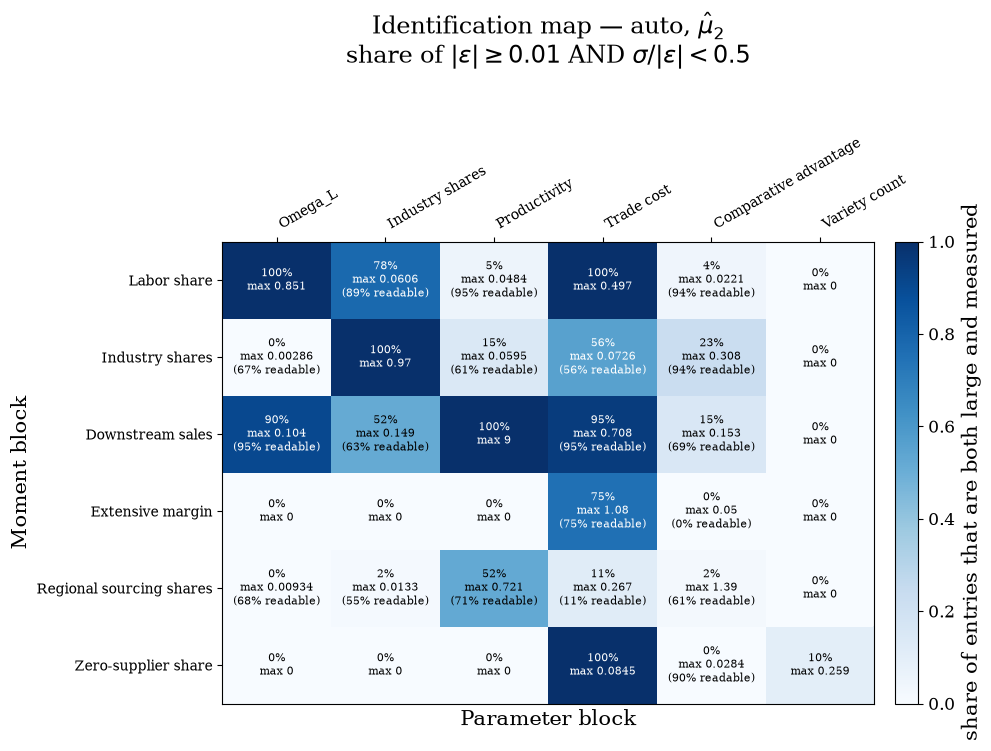

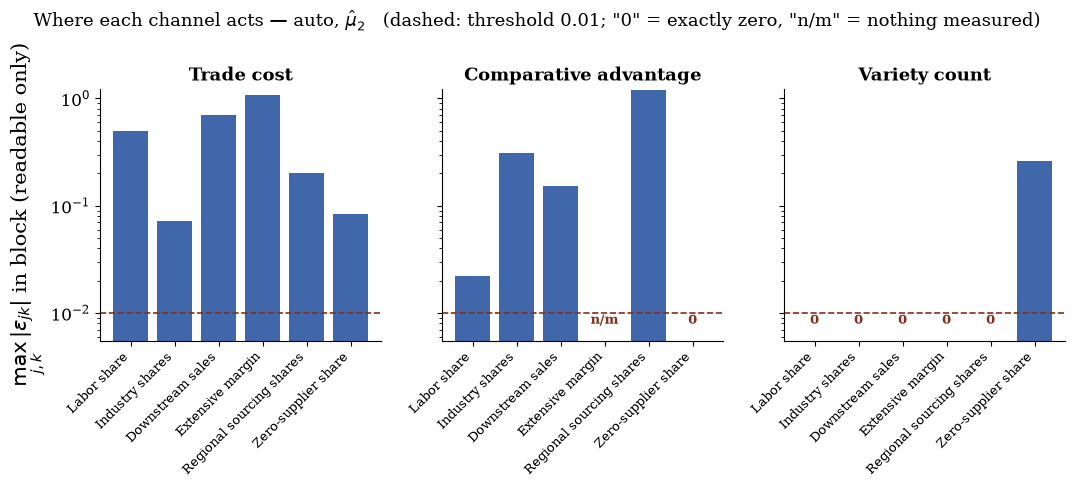

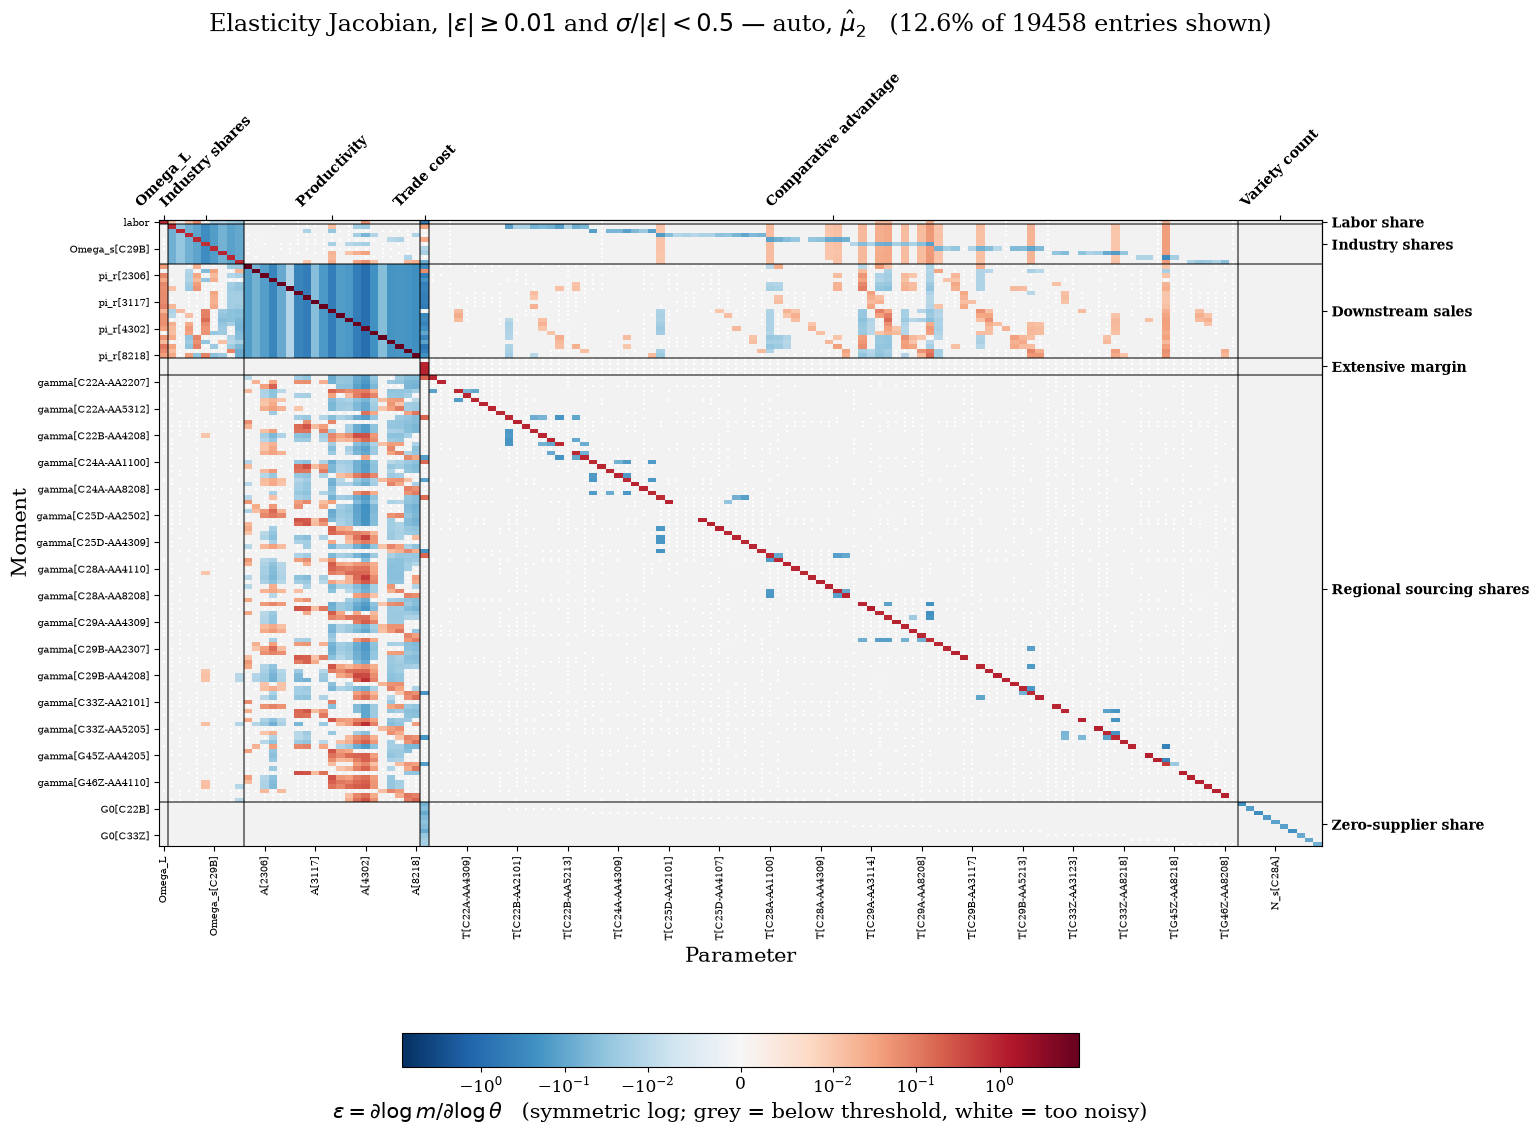

share_above                                          \
param_block                  Omega_L Industry shares Productivity Trade cost   
moment_block                                                                   
Labor share                 1.000000        0.777778     0.047619   1.000000   
Industry shares             0.000000        1.000000     0.158730   0.666667   
Downstream sales            0.952381        0.597884     1.000000   1.000000   
Extensive margin            0.000000        0.000000     0.000000   1.000000   
Regional sourcing shares    0.000000        0.016204     0.596726   0.906250   
Zero-supplier share         0.000000        0.000000     0.000000   1.000000   

                                                             share_readable  \
param_block              Comparative advantage Variety count        Omega_L   
moment_block                                                                  
Labor share                           0.041667           0.0       1.000000   
Industry shares                       0.233796           0.0       0.666667   
Downstream sales                      0.149802           0.0       0.952381   
Extensive margin                      0.312500           0.0       1.000000   
Regional sourcing shares              0.103950           0.0       0.677083   
Zero-supplier share                   0.001042           0.1       1.000000   

                                                                  ...  \
param_block              Industry shares Productivity Trade cost  ...   
moment_block                                                      ...   
Labor share                     0.888889     0.952381   1.000000  ...   
Industry shares                 1.000000     0.608466   0.555556  ...   
Downstream sales                0.629630     1.000000   0.952381  ...   
Extensive margin                1.000000     1.000000   0.750000  ...   
Regional sourcing shares        0.547454     0.707837   0.114583  ...   
Zero-supplier share             1.000000     1.000000   1.000000  ...   

                             mean_abs                                   \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                  0.008162   0.496615              0.002888   
Industry shares              0.005525   0.020718              0.010077   
Downstream sales             0.655007   0.337642              0.005671   
Extensive margin             0.000000   1.007340              0.008475   
Regional sourcing shares     0.031987   0.081453              0.017223   
Zero-supplier share          0.000000   0.047259              0.000272   

                                       share_exact_zero                  \
param_block              Variety count          Omega_L Industry shares   
moment_block                                                              
Labor share                   0.000000              0.0             0.0   
Industry shares               0.000000              0.0             0.0   
Downstream sales              0.000000              0.0             0.0   
Extensive margin              0.000000              1.0             1.0   
Regional sourcing shares      0.000000              0.0             0.0   
Zero-supplier share           0.014944              1.0             1.0   

                                                                        \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                       0.0        0.0                   0.0   
Industry shares                   0.0        0.0                   0.0   
Downstream sales                  0.0        0.0                   0.0   
Extensive margin                  1.0        0.0                   0.0   
Regional sourcing shares          0.0        0.0                   0.0   

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


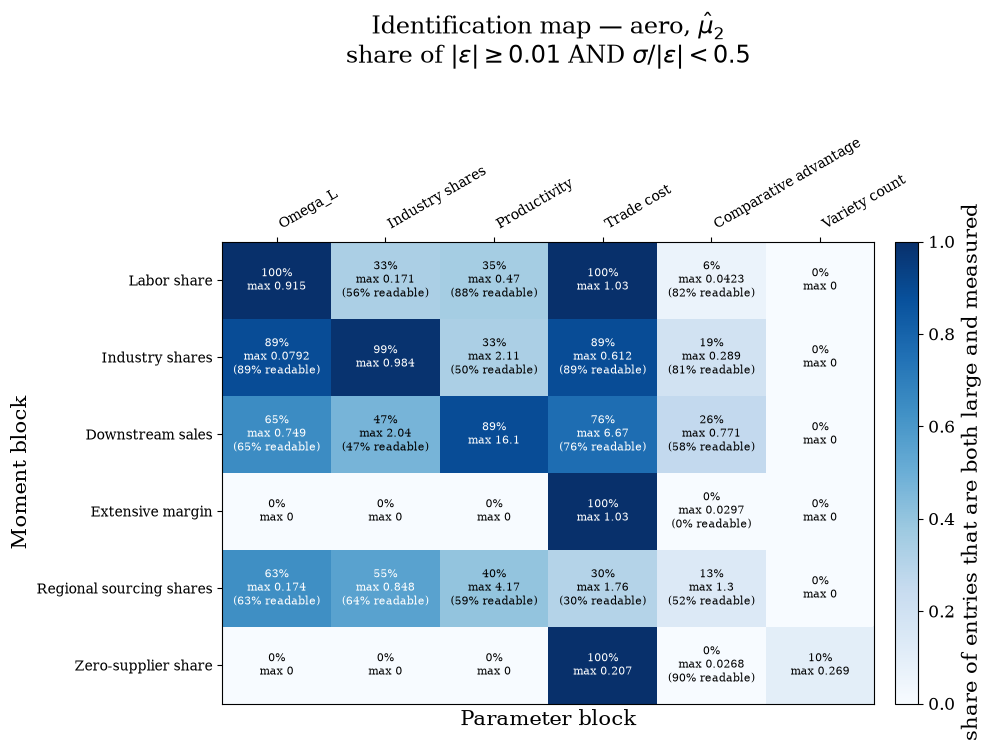

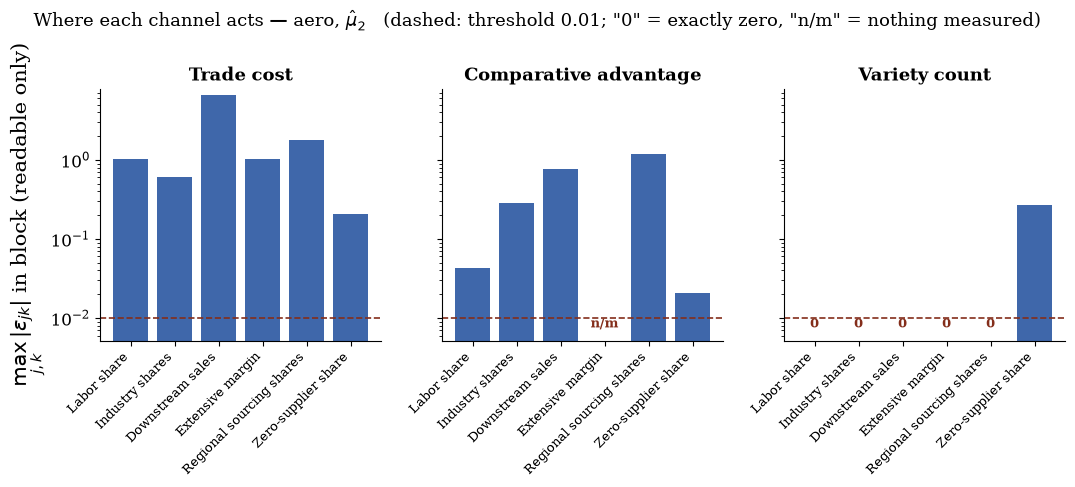

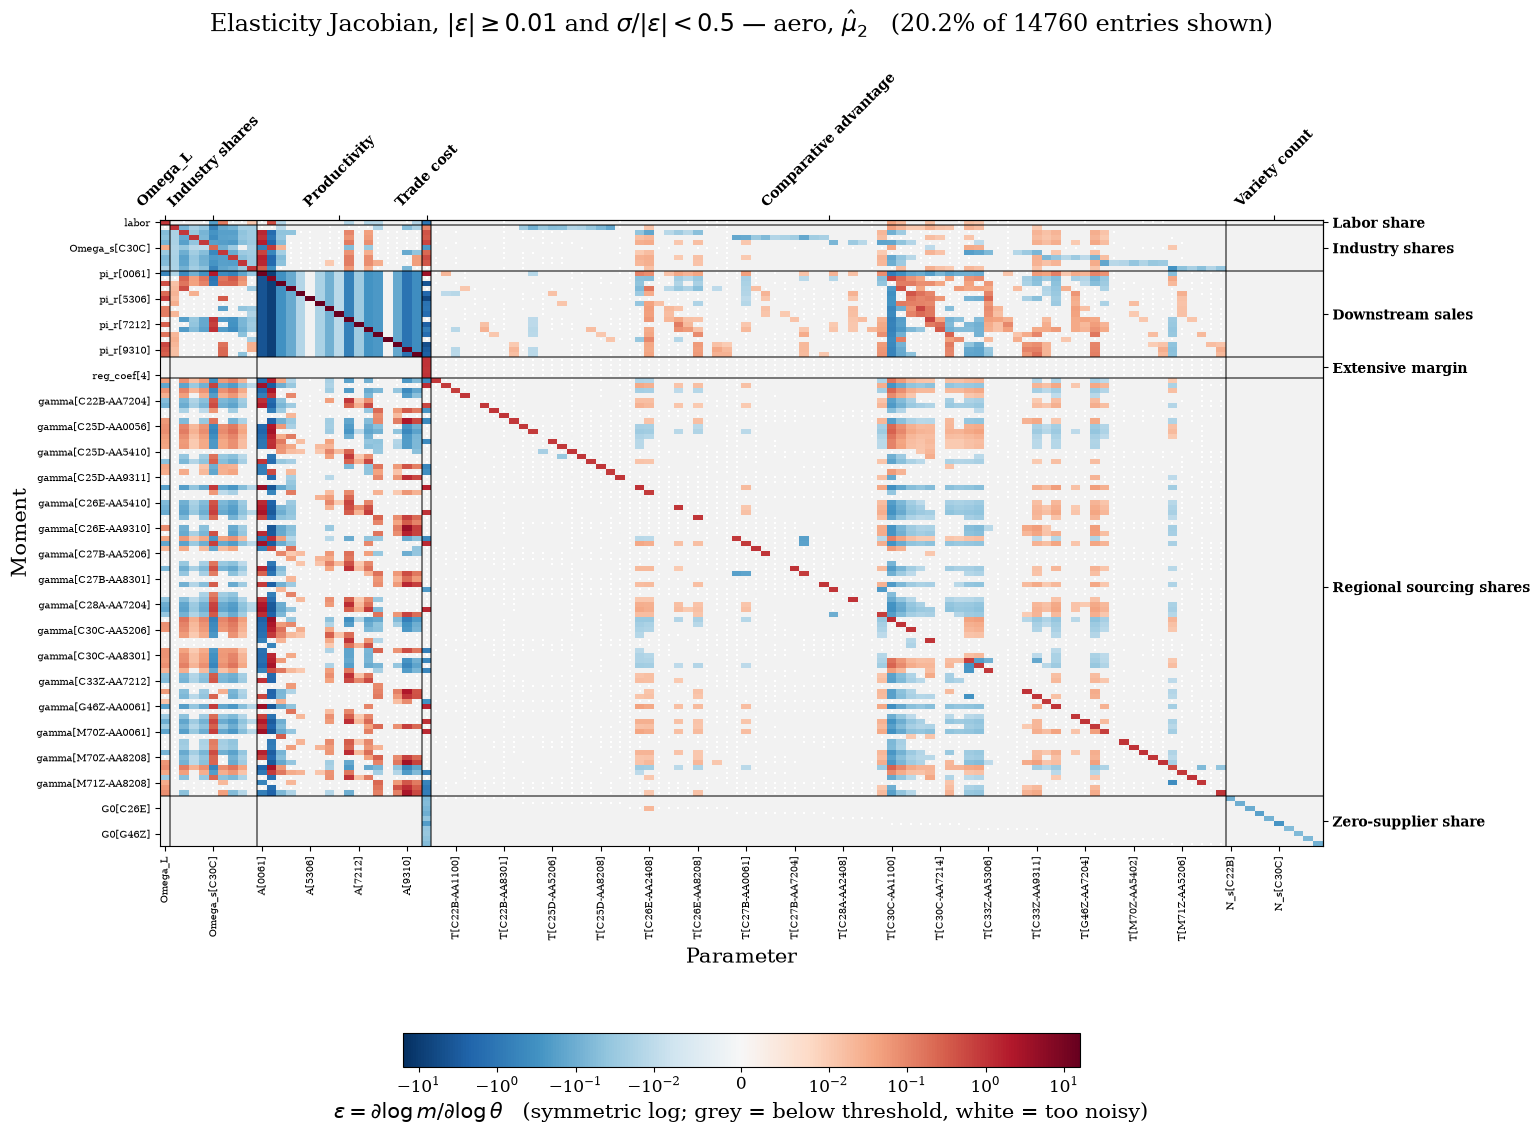

share_above                                          \
param_block                  Omega_L Industry shares Productivity Trade cost   
moment_block                                                                   
Labor share                 1.000000        0.333333     0.411765   1.000000   
Industry shares             0.888889        0.987654     0.424837   1.000000   
Downstream sales            0.941176        0.875817     0.889273   1.000000   
Extensive margin            0.000000        0.000000     0.000000   1.000000   
Regional sourcing shares    0.853659        0.651762     0.583214   0.987805   
Zero-supplier share         0.000000        0.000000     0.000000   1.000000   

                                                             share_readable  \
param_block              Comparative advantage Variety count        Omega_L   
moment_block                                                                  
Labor share                           0.060976           0.0       1.000000   
Industry shares                       0.201897           0.0       0.888889   
Downstream sales                      0.322812           0.0       0.647059   
Extensive margin                      0.103659           0.0       1.000000   
Regional sourcing shares              0.230666           0.0       0.634146   
Zero-supplier share                   0.009756           0.1       1.000000   

                                                                  ...  \
param_block              Industry shares Productivity Trade cost  ...   
moment_block                                                      ...   
Labor share                     0.555556     0.882353   1.000000  ...   
Industry shares                 1.000000     0.496732   0.888889  ...   
Downstream sales                0.470588     1.000000   0.764706  ...   
Extensive margin                1.000000     1.000000   1.000000  ...   
Regional sourcing shares        0.643631     0.585366   0.304878  ...   
Zero-supplier share             1.000000     1.000000   1.000000  ...   

                             mean_abs                                   \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                  0.042412   1.032185              0.002375   
Industry shares              0.145745   0.316900              0.008963   
Downstream sales             1.751117   2.219452              0.023208   
Extensive margin             0.000000   1.004450              0.004433   
Regional sourcing shares     0.226990   0.421135              0.023655   
Zero-supplier share          0.000000   0.070399              0.000364   

                                       share_exact_zero                  \
param_block              Variety count          Omega_L Industry shares   
moment_block                                                              
Labor share                   0.000000              0.0             0.0   
Industry shares               0.000000              0.0             0.0   
Downstream sales              0.000000              0.0             0.0   
Extensive margin              0.000000              1.0             1.0   
Regional sourcing shares      0.000000              0.0             0.0   
Zero-supplier share           0.011081              1.0             1.0   

                                                                        \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                       0.0        0.0                   0.0   
Industry shares                   0.0        0.0                   0.0   
Downstream sales                  0.0        0.0                   0.0   
Extensive margin                  1.0        0.0                   0.0   
Regional sourcing shares          0.0        0.0                   0.0   

In [260]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_identification_map(
        data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX,
        save_to=f"{out_folder}/identification_map_{industry}_mu{MU}.pdf")
    plt.show()
    plot_channel_elasticities(
        data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX,
        save_to=f"{out_folder}/identification_channels_{industry}_mu{MU}.pdf")
    plt.show()
    plot_jacobian_thresholded(
        data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX,
        save_to=f"{out_folder}/jacobian_thresholded_{industry}_mu{MU}.pdf")
    plt.show()
    display(identification_summary(data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX))


# Untargeted moment — the distance elasticity of spatial comovement

**The test.** The estimation targets the spatial decay of production **linkages** (moment
block 4). It does not target how the equilibrium network turns those linkages into the
spatial propagation of downstream shocks, which is what the reduced-form ratio
$\delta/\gamma$ of Table 3 measures. Appendix B.5 shows that ratio identifies
$\partial \log \mathbb{E}[a_{ir}\mid s, r', \mathrm{Dist}_{r'r}=d]/\partial \log d$, with
$a_{ir}$ the share of supplier $i$'s sales going to downstream region $r$. The model
counterpart computes $a_{ir}$ in the simulated economy and estimates

$$\mathbb{E}\!\left[a_{ir}\mid s, r', r\right] \;=\; \exp\!\big(\alpha_{i} + \alpha_{r,s(i)} + \eta \log \mathrm{Dist}_{r'r}\big)$$

by Poisson pseudo-ML (`pyfixest.fepois`, draw weights, standard errors clustered on the
supplier's region as in Table 3 — Poisson because a third to a half of the cells are zeros
and those zeros are the extensive margin). The two-way effect is the specification because
it is the reduced form's own design and the variation Appendix B.5 differentiates: within
one supplier, within one buyer cell. Nothing in the criterion was asked to match this, which
is what makes it a test.

**One scale.** $\delta/\gamma$ comes from a regression linear in the *level* of the
exposure, so it is a compressed reading of an elasticity,
$\delta/\gamma \approx \eta/(1+|\eta|\overline{\log d})$ with
$\overline{\log d} = 5.8$ — and it is bounded by $1/\overline{\log d} = 0.172$ whatever the
elasticity behind it. Everything the section reports is on that scale; the elasticity appears
only in the console line of the estimator.

### What `suppliers.parquet` contains

One row per **realised linkage**: a (simulated firm, downstream region) pair such that the
firm won at least one variety supplied to that region. A firm is a (cell, sector, variety)
triple — one variety producer, which is the model's supplier — and the file has no row for a
firm-region pair with no linkage, which is why the panel below has to be zero-filled.

| column | what it is |
|--------|-----------|
| `SIREN` | synthetic firm identifier, one per (upstream region, sector, variety) triple |
| `A129` | the sector, as the model's own index $1..S$ — **not** the A129 code; map through `sector_names` |
| `ze2010` | the **supplier's** region, as the model's own index $1..R$ (regions sorted by ZE code) |
| `ze2010_downstream` | the **buyer's** downstream region, same $1..R$ index space |
| `share` | the badly-named one. It is $\texttt{exp\_val}$: the share of the buyer region's **unit cost** spent on this firm, $w_\rho\,\Omega^s(1-\Omega^L)(p_{\rho s}/P_{sr})^{1-\nu_s}(P_{sr}/P_r)^{1-\nu}(P_r/c_r)^{1-\lambda}$. Summed over every firm it gives that region's intermediate-input share of cost — it is *not* a share of the supplier's sales, and it is *not* normalised within the supplier |
| `downstream_purchase` | $\mu Y_r$, the buyer region's total spending on intermediates. `share` $\times$ `downstream_purchase` is the euro flow $X_{i \to r}$ |
| `intermediate_derivative` | `share` renormalised *within* intermediates ($\texttt{exp\_val}$ divided by $(1-\Omega^L)(P_r/c_r)^{1-\lambda}$). Sums to one by construction, so it is a composition, not a magnitude — do not use it as a flow |
| `productivity` | the firm's Fréchet productivity draw $z$ |
| `sample_weight` | the Monte-Carlo weight of the variety draw ($1/N_\rho$ under the flat designs), i.e. how many real firms this simulated one stands for |

The moment's regressand is built from these: $X_{i \to r} = \texttt{share} \times
\texttt{downstream\_purchase}$ and $a_{ir} = X_{i\to r}/\sum_{r'} X_{i \to r'}$, which sums to
one over $r$ for every supplier.


### The granular decomposition

A supplier here is one *variety* producer, and the appendix's derivation — written for the
continuum, where a supplier is a whole cell — changes in one place. The pair-level derivative
is

$$\frac{d\log a_{ir}}{d\log d} \;=\; -\alpha\Big[\underbrace{\theta\,\Lambda_{ir}}_{\text{extensive}} \;+\; \underbrace{(\nu_s-1)\,(1-a_{ir})}_{\text{substitution}}\Big],$$

with $\Lambda_{ir} = \Phi_{-r',rs}(w_{r's}\tau_{r'r})^{\theta}z_i^{-\theta}$ the surprisal of
winning. Three points.

**The extensive term is the trade elasticity.** $\Lambda$ is exponentially distributed across
Fréchet draws with rate $k = T(w\tau)^{-\theta}/\Phi_{-r'}$, so
$\Pr(\text{win}) = \mathbb{E}(e^{-\Lambda}) = \gamma_{r'rs}$ and

$$\mathbb{E}(\Lambda \mid \text{win}) = \frac{\mathbb{E}(\Lambda e^{-\Lambda})}{\mathbb{E}(e^{-\Lambda})} = 1-\gamma_{r'rs}.$$

Among realised suppliers the extensive term is therefore $-\theta\alpha(1-\gamma)$: exactly
the elasticity of the continuum sourcing share. Granularity does not change it.

**The substitution term carries $(\nu_s-1)$, not $\theta$.** At the variety level, winning is
already inside $\Lambda$; conditional on winning, the variety is not reallocated across
origins and only its *volume* responds, at the within-sector CES elasticity. With $\theta=1$
and $\nu_s=1.5$ that term is half the continuum one. The $(1-a)$ factor is the portfolio
reallocation, and it is where the hub story lives: a diversified portfolio (motor vehicles,
demand spread over many assembly hubs) has $a$ small in every buyer, so what is lost to
distance in one is regained in the others; a concentrated one (aerospace, Toulouse and
Île-de-France) has the dominant buyer *as* the portfolio, and reallocates little.

**Both terms are computed, not estimated.** Every object entering them is observed in the
simulated economy: $\Lambda$ from $\hat T$, the distances and the draws (`attach_lambda`),
$a_{ir}$ from the panel, $\theta\alpha$ from `best_params`, $\nu_s$ from the calibration. The
shares therefore sum to one by construction and there is no identity that can fail to close.

This is a change from a previous version of this section, which estimated the two margins by
separate PPMLs and read their non-closure as an economic term. It should not have: a
probability bounded by one cannot be exponential in $\log d$, so with serving rates of $0.72$
and $0.59$ the extensive regression is attenuated by construction, and its apparent agreement
with $-\theta\alpha$ was not evidence for the theory. `validate_structural` replaces that
"confirmation" with three checks that compare closed forms against **measured frequencies** —
$\mathbb{E}(\Lambda\mid\text{win})$ against $1-\hat\gamma$ counted off the panel,
$\overline{e^{-\Lambda}}$ against the serving rate, and the substitution scale against
$(\nu_s-1)/\theta$ — none of which can be satisfied by the specification error it is meant to
catch.


In [261]:
# The (supplier x downstream region) panel, and the PPML that reads eta off it.
# The estimator is pyfixest.fepois — ppmlhdfe's algorithm — so nothing about Poisson
# pseudo-ML is re-implemented here.

# Empirical delta/gamma from Table 3 (the spatial comovement regression): point estimate
# and 95% CI. These are DATA, not model output, and they are not read from any file in
# this repository — override them here if the reduced-form estimates change.
EMPIRICAL_DELTA_OVER_GAMMA = {
    "auto": {"estimate": -0.109, "ci_lo": -0.122, "ci_hi": -0.096,
             "display_name": "Motor Vehicles"},
    "aero": {"estimate": -0.098, "ci_lo": -0.130, "ci_hi": -0.065,
             "display_name": "Aerospace"},
}


def build_a_ir_panel(data, min_distance_km=1.0, firm_key=("SIREN",)):
    """
    The (supplier x downstream region) panel the PPML runs on, ZERO-FILLED.

    `suppliers.parquet` records only realised linkages (see the column glossary above).
    The regression needs the non-linkages too — a supplier that does not serve region r
    has a_ir = 0, and that extensive margin is half of what the moment measures — so
    every supplier is crossed with every downstream region and the missing cells are
    filled at 0.

    The sample is suppliers, i.e. varieties that win somewhere, which is the
    conditioning Sup_i = 1 of equation (3) and of (B36).

    Region codes are the model's own 1..R indices for BOTH `ze2010` (the supplier's
    cell) and `ze2010_downstream` (the buyer), so the distance is read straight out of
    `distances.npy` with no name round-trip.

    `firm_key` is what counts as one supplier. The default is the parquet's own `SIREN`,
    i.e. ONE VARIETY in one cell — the model's supplier. Passing `("ze2010", "A129")`
    pools every variety a (region, sector) produces into a single multi-variety firm,
    which is closer to what a SIREN is in the data and flattens the distance profile; the
    specification ladder below uses it to measure how much.

    `min_distance_km` is a floor, not a convention: the own-region entry of the distance
    matrix is the region's own internal distance, which is POSITIVE and differs across
    regions (a large commuting zone is further from itself than a small one), exactly as
    the model uses it. The floor only guards against a data file that happens to store a
    hard zero on the diagonal, which would send log d to -infinity.
    """
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data['step_dir']}/ (or it was "
            "unreadable — pyarrow missing?). main.jl writes one per estimate in its "
            "post-hoc block, after the estimation.")

    dist_path = data["input_folder"] / "distances.npy"
    if not dist_path.exists():
        raise FileNotFoundError(f"{dist_path} not found — needed for log Dist_{{r'r}}.")
    D = np.load(dist_path)
    R = data["R"]
    if D.shape[0] < R or D.shape[1] < R:
        raise ValueError(f"distances.npy is {D.shape}, too small for R = {R} regions.")
    D = D[:R, :R]

    df = sup[["SIREN", "A129", "ze2010", "ze2010_downstream",
              "share", "downstream_purchase", "productivity", "sample_weight"]].copy()

    # The supplier identifier. Under the default it IS the parquet's SIREN; under an
    # aggregating `firm_key` the column is rebuilt from the key, and the euro flows of the
    # pooled varieties are added before the share is formed — which is what makes the
    # aggregated firm a genuine multi-variety supplier rather than an average of shares.
    if tuple(firm_key) != ("SIREN",):
        df["SIREN"] = df[list(firm_key)].astype(str).agg("-".join, axis=1)

    # X_{i->r} = share x (mu Y_r); a_ir = X_{i->r} / sum_r X_{i->r}
    df["X_ir"] = df["share"] * df["downstream_purchase"]
    # how many real firms one simulated supplier stands for: the MEAN of its varieties'
    # draw weights, so that pooling varieties does not multiply the weight (under the
    # flat draw designs every variety carries 1/N_rho and a pooled firm still does)
    w_firm = df.groupby("SIREN", sort=True)["sample_weight"].mean()
    df = (df.groupby(["SIREN", "ze2010_downstream"], as_index=False)
            .agg(A129=("A129", "first"), ze2010=("ze2010", "first"),
                 X_ir=("X_ir", "sum"), productivity=("productivity", "mean")))
    tot = df.groupby("SIREN", sort=False)["X_ir"].transform("sum")
    df["a_ir"] = np.where(tot > 0, df["X_ir"] / tot, 0.0)

    # --------------------------------------------------------- zero-filling ---
    firms = df.groupby("SIREN", sort=True).agg(
        A129=("A129", "first"), ze2010=("ze2010", "first"),
        productivity=("productivity", "first")).reset_index()
    firms["sample_weight"] = firms["SIREN"].map(w_firm)
    downstream = np.sort(df["ze2010_downstream"].unique())

    panel = firms.merge(pd.DataFrame({"ze2010_downstream": downstream}), how="cross")
    panel = panel.merge(df[["SIREN", "ze2010_downstream", "a_ir"]],
                        on=["SIREN", "ze2010_downstream"], how="left")
    panel["a_ir"] = panel["a_ir"].fillna(0.0)

    # ------------------------------------------------------------ regressors --
    d = D[panel["ze2010"].to_numpy() - 1, panel["ze2010_downstream"].to_numpy() - 1]
    panel["distance"] = d
    panel["log_distance"] = np.log(np.maximum(d, min_distance_km))
    panel["log_productivity"] = np.log(np.maximum(panel["productivity"].to_numpy(), 1e-300))
    panel["served"] = (panel["a_ir"].to_numpy() > 0).astype(float)
    # alpha_{r, s(i)} : sector x downstream-region
    panel["fe_group"] = (panel["A129"].astype(str) + "-"
                         + panel["ze2010_downstream"].astype(str))
    panel["cluster"] = panel["ze2010"].astype(str)     # supplier's region, as in Table 3
    # what one row is: under the default a single variety, under an aggregating key a
    # bundle of them. `attach_lambda` refuses the latter, since z is then a mean of draws.
    panel.attrs["firm_key"] = tuple(firm_key)
    return panel


def fepois_fit(panel, y, rhs=("log_distance",), fe="fe_group", cluster="cluster",
               weights="sample_weight"):
    """
    One `pyfixest.fepois` call: E[y | .] = exp(fixed effect + rhs'beta).

    `fe` is passed to pyfixest as written, so "fe_group" absorbs the sector x
    downstream-region effect, "SIREN" absorbs a SUPPLIER effect, and "fe_group + SIREN"
    absorbs both.

    A three-line wrapper around the library, not an estimator: it writes the formula,
    passes the Monte-Carlo draw weights as analytic weights, clusters on the supplier's
    own region and lets pyfixest drop the fixed-effect groups that are separated (a
    group with no positive outcome contributes nothing to the Poisson score, exactly as
    in `ppmlhdfe`). Returns the fitted object, so `.coef()`, `.se()`, `.tidy()` and
    `.summary()` are all available at the call site.
    """
    fml = f"{y} ~ " + " + ".join(rhs) + (f" | {fe}" if fe else "")
    return pf.fepois(fml=fml, data=panel, weights=weights, weights_type="aweights",
                     vcov=None if cluster is None else {"CRV1": cluster},
                     separation_check=["fe"])


def delta_over_gamma_from_eta(eta, mean_log_d=None):
    """
    A constant elasticity `eta` expressed as the reduced form's `delta/gamma`.

    The spatial-comovement regression is LINEAR IN THE LEVEL of the exposure — gamma on
    the demand shock, delta on the shock interacted with log distance — so it fits
    E[a|d] = gamma + delta log d. Fitting a constant-elasticity profile A d^eta that way
    puts gamma at the extrapolated intercept log d = 0 (one kilometre, far outside any
    data), and linearising around the mean gives

        delta/gamma  ~=  eta / (1 + |eta| * mean(log d)).

    Two things follow. The map is strongly COMPRESSIVE, and it is BOUNDED: whatever the
    true elasticity, |delta/gamma| can never exceed 1/mean(log d) — 0.17 at the empirical
    mean of 5.8. So a model eta and a published delta/gamma cannot be compared as they
    stand; one has to be put on the other's scale, which is what this does.

    `mean_log_d` defaults to `EMPIRICAL_MEAN_LOG_D`, the mean in the ESTIMATION SAMPLE OF
    THE REDUCED FORM — the right one here, since the compression is a property of the
    regression that produced the published number, not of the simulated geography.
    """
    m = EMPIRICAL_MEAN_LOG_D if mean_log_d is None else mean_log_d
    return float(eta) / (1.0 + abs(float(eta)) * m)


def eta_from_delta_over_gamma(ratio, mean_log_d=None):
    """The inverse map: the constant elasticity a published `delta/gamma` implies."""
    m = EMPIRICAL_MEAN_LOG_D if mean_log_d is None else mean_log_d
    r = float(ratio)
    denom = 1.0 - abs(r) * m
    return r / denom if denom > 0 else -np.inf


# The fixed effect the moment is estimated under. ONE specification is the baseline,
# and it is the two-way one: a supplier effect AND a sector x buyer-region effect.
# Two reasons, and they agree. (a) It is the reduced form's own design: the
# spatial-comovement regression of Appendix B.5 carries a firm effect alpha_i and an
# FE_{r s(i), t}. (b) It is the object the appendix DIFFERENTIATES: delta_rs is the
# derivative of a_ir in log d holding the supplier (hence its other distances) and the
# destination fixed, which is exactly what absorbing both effects leaves.
# There is no second specification: every figure, every table and the decomposition run
# at this fixed effect, so the section reports one object throughout.
BASELINE_FE_LABEL = "supplier + sector x buyer region"
BASELINE_FE = "fe_group + SIREN"


def model_nu_s(data):
    """
    The within-sector CES elasticity: from stats.csv when it carries one, else
    NU_S_DEFAULT. Same rule as `model_theta` for theta, and the same reason — it is a
    calibrated number that the run does not write out.

    Raises if the run carries a sector-specific nu_s: the granular decomposition below is
    written for a scalar, and averaging elasticities across sectors would be silent.
    """
    v = _read_named_value(data["coefs"], "nu_s") if data.get("coefs") is not None else None
    if v is None or not np.isfinite(v):
        return float(NU_S_DEFAULT)
    v = np.asarray(v, dtype=float).ravel()
    if v.size != 1:
        raise ValueError(f"stats.csv carries {v.size} values for nu_s; the granular "
                         "decomposition is written for a scalar elasticity.")
    return float(v[0])


def theta_alpha(data):
    """
    `theta * alpha_hat` for this run, read off the LOADED estimate — the scale every term
    of the moment is measured in (Appendix B.5: both margins are theta*alpha times a
    dimensionless number, so |eta_int| <= theta*alpha and |eta_ext| = theta*alpha E(Lambda)).

    `best_params` is the raw theta vector, layout
        [Omega_L(1) | Omega_s(S) | A(R_d) | alpha(N_TAU) | T(active (s,AA), s-major)],
    so alpha is the N_TAU-long slice after the A block; the length is asserted against the
    rebuilt layout, exactly as `unpack_estimated_T` does in the comparative-advantage
    section. theta follows the same rule as `model_theta` there: stats.csv when it carries
    one, else THETA_DEFAULT. Defined here so the section runs on its own.
    """
    bp = data.get("best_params")
    if bp is None:
        raise FileNotFoundError(f"no best_params in {data['folder']}/{data['step_dir']}/.")
    bp = np.asarray(bp, dtype=float).ravel()
    S, n_tau = data["S"], data["n_tau"]
    R_d = len(data["aa_names"])
    expected = 1 + S + R_d + n_tau + int(data["AA_ACTIVE"].sum())
    if bp.size != expected:
        raise ValueError(f"best_params has {bp.size} entries, layout rebuilt here is "
                         f"{expected} — the run's flags and the ones passed here disagree.")
    if n_tau != 1:
        raise ValueError(f"N_TAU = {n_tau}: tau is binned, so there is no single distance "
                         "elasticity. Re-run the reporting on an n_tau = 1 fit.")
    v = _read_named_value(data["coefs"], "theta") if data.get("coefs") is not None else None
    theta = float(v) if v is not None and np.isfinite(v) and v > 0 else THETA_DEFAULT
    return float(theta) * float(bp[1 + S + R_d])


def estimate_untargeted_moment(data, controls=(), cluster="cluster", panel=None,
                               fe=BASELINE_FE, verbose=True):
    """
    The measured moment: PPML of E[a_ir] = exp(alpha_i + alpha_{r,s(i)} + eta log Dist).

    One specification — a supplier effect and a sector x downstream-region effect — which
    is the reduced form's own design and the variation Appendix B.5 differentiates: within
    one supplier (its market access held fixed) and within one buyer cell (Y_r and P_sr
    absorbed).

    `controls` adds columns of the panel to the right-hand side (the paper's specification
    has none). `cluster=None` gives the classical Poisson variance.
    """
    panel = build_a_ir_panel(data) if panel is None else panel
    cols = ["log_distance"] + list(controls)
    fit = fepois_fit(panel, "a_ir", rhs=cols, fe=fe, cluster=cluster)
    eta = float(fit.coef()["log_distance"])
    se = float(fit.se()["log_distance"])
    emp = EMPIRICAL_DELTA_OVER_GAMMA.get(data["industry"], {})
    try:
        ta = theta_alpha(data)
    except Exception:
        ta = np.nan

    out = {"industry": data["industry"], "mu": data["mu"], "spec": "+".join(cols),
           "fe": fe, "fe_label": BASELINE_FE_LABEL, "theta_alpha": ta,
           "eta": eta, "se": se, "t": eta / se if se > 0 else np.nan,
           "ci_lo": eta - 1.96 * se, "ci_hi": eta + 1.96 * se,
           # the same estimate on the reduced form's own scale — the one that is reported
           "dg": delta_over_gamma_from_eta(eta),
           "dg_lo": delta_over_gamma_from_eta(eta - 1.96 * se),
           "dg_hi": delta_over_gamma_from_eta(eta + 1.96 * se),
           "n_obs": int(getattr(fit, "_N", len(panel))),
           "n_firms": int(panel["SIREN"].nunique()),
           "share_zero": float((panel["a_ir"].to_numpy() == 0).mean()),
           "emp_estimate": emp.get("estimate"), "emp_ci_lo": emp.get("ci_lo"),
           "emp_ci_hi": emp.get("ci_hi"), "fit": fit, "panel": panel}

    if verbose:
        print(f"[{data['industry']}]  {len(panel):,} supplier x downstream-region cells, "
              f"{out['n_firms']:,} suppliers, {100 * out['share_zero']:.1f}% zeros, "
              f"from {data['suppliers_path']}")
        print(f"  measured eta = {eta:+.4f} ({se:.4f})   ->  delta/gamma = {out['dg']:+.4f} "
              f"[{out['dg_lo']:+.4f}, {out['dg_hi']:+.4f}]   "
              f"(mean log d = {EMPIRICAL_MEAN_LOG_D}, theta*alpha = {ta:.4f})")
        if out["emp_estimate"] is not None:
            print(f"  DATA delta/gamma = {out['emp_estimate']:+.4f}  "
                  f"[{out['emp_ci_lo']:+.4f}, {out['emp_ci_hi']:+.4f}]")
    return out


def panel_facts(panel):
    """
    What the panel says about the geography, with no regression in sight.

      `serving_rate`         share of (supplier, region) cells that are served;
      `openness_weighted`    1 - sum(w a^2)/sum(w a): the SHARE-WEIGHTED portfolio openness,
                             which is the average the moment's weight takes (large shares
                             carry large weight);
      `buyers_per_supplier`  how many of the `n_buyers` downstream regions a supplier serves.

    Openness is a property of the geography of DOWNSTREAM demand — high when a supplier's
    sales are spread over many buyers, so that losing one to distance reallocates onto the
    others — and it is the object the substitution term of the granular decomposition needs.
    """
    a = panel["a_ir"].to_numpy(float)
    w = panel["sample_weight"].to_numpy(float)
    served = a > 0
    denom = float((w * a).sum())
    n_sup = int(panel["SIREN"].nunique())
    return {"serving_rate": float(np.average(served.astype(float), weights=w)),
            "openness_weighted": float(1.0 - (w * a * a).sum() / denom) if denom > 0 else np.nan,
            "buyers_per_supplier": float(served.sum() / n_sup) if n_sup else np.nan,
            "n_buyers": int(panel["ze2010_downstream"].nunique())}


In [262]:
# The untargeted-moment figures and the summary table.

def untargeted_summary(results):
    """
    ONE row per industry — the baseline estimate — with the fixed effect it was run under
    as a column, the moment on the reduced form's own delta/gamma scale, and the published
    number beside it.

    The elasticity is deliberately NOT a column: eta and delta/gamma are two readings of
    one profile on two scales, only the second is comparable to Table 3, and printing both
    invites the comparison of a number with itself measured differently. `theta*alpha` is
    kept, because it is the scale the structural moment is read in (see `structural_eta`).
    """
    rows = []
    for r in results:
        emp = EMPIRICAL_DELTA_OVER_GAMMA.get(r["industry"], {})
        rows.append({
            "industry": emp.get("display_name", r["industry"]),
            "fixed effect": r["fe_label"],
            "delta/gamma (model)": r["dg"],
            "95% CI (model, delta/gamma)": f"[{r['dg_lo']:+.3f}, {r['dg_hi']:+.3f}]",
            "delta/gamma (data)": r["emp_estimate"],
            "95% CI (data)": (f"[{r['emp_ci_lo']:+.3f}, {r['emp_ci_hi']:+.3f}]"
                              if r["emp_ci_lo"] is not None else "---"),
            "inside data CI": (None if r["emp_ci_lo"] is None
                               else bool(r["emp_ci_lo"] <= r["dg"] <= r["emp_ci_hi"])),
            "theta*alpha": r.get("theta_alpha", np.nan),
            "suppliers": r["n_firms"], "cells": r["n_obs"],
        })
    return pd.DataFrame(rows).set_index("industry")


def plot_untargeted_moment(results, figsize=None, save_to=None):
    """
    The model against the published reduced form, one group per industry, on the reduced
    form's own delta/gamma scale — the only scale the section reports, since it is the one
    Table 3 is on.

    One model marker per industry with its 95% interval, and a square for the published
    estimate with its own. The dotted line is the ceiling -1/mean(log d): no level-linear
    ratio can lie beyond it, so how close the markers sit to it says how much room the
    scale has left.
    """
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.95, hf=0.65))
    x = np.arange(len(results))

    for i, r in enumerate(results):
        v, lo, hi = r["dg"], r["dg_lo"], r["dg_hi"]
        ax.errorbar(x[i] - 0.12, v, yerr=[[v - lo], [hi - v]], fmt="o", color=sim_color,
                    capsize=4, markersize=7,
                    label="Model (baseline)" if i == 0 else None)
        if r["emp_estimate"] is not None:
            ax.errorbar(x[i] + 0.22, r["emp_estimate"],
                        yerr=[[r["emp_estimate"] - r["emp_ci_lo"]],
                              [r["emp_ci_hi"] - r["emp_estimate"]]],
                        fmt="s", color=reference_color, capsize=4, markersize=8,
                        label="Data $\\delta/\\gamma$ (Table 3)" if i == 0 else None)

    ceil = -1.0 / EMPIRICAL_MEAN_LOG_D
    ax.axhline(ceil, color="0.4", linestyle=":", linewidth=1.1)
    ax.annotate(rf"ceiling $-1/\overline{{\log d}}$ = {ceil:.3f}", (0.01, ceil),
                xycoords=("axes fraction", "data"), fontsize=8, color="0.35", va="bottom")
    ax.axhline(0.0, color="0.6", linewidth=0.8)
    ax.set_xlim(-0.5, len(results) - 0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([EMPIRICAL_DELTA_OVER_GAMMA.get(r["industry"], {})
                        .get("display_name", r["industry"]) for r in results])
    ax.set_ylabel(r"$\delta/\gamma$ (reduced-form scale)")
    ax.set_title("Untargeted moment: model against the spatial-comovement regression",
                 fontsize=10)
    ax.legend(frameon=False, loc="best", fontsize=8)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


In [263]:
# The STRUCTURAL moment: the granular derivative of Appendix B.5, computed in closed form
# on the simulated economy. Nothing here is estimated — every object entering
#     dlog a_ir/dlog d = -alpha [ theta * Lambda_ir + (nu_s - 1)(1 - a_ir) ]
# is observed, so the margin split is exact by construction and there is no identity that
# can fail to close. What IS estimated, and compared with it, is the PPML above.


def _estimated_T(data):
    """`unpack_estimated_T` with a legible error when the section is run on its own.

    The comparative-advantage definitions cell sits BELOW this one in the notebook, so a
    standalone run of the untargeted section has to execute it first. Everything else here
    is self-contained.
    """
    try:
        return unpack_estimated_T(data)
    except NameError as e:
        raise NameError(
            "`unpack_estimated_T` is defined in the comparative-advantage section, which "
            "is below this one — run its definitions cell first (the full run does)."
        ) from e


def attach_lambda(data, panel, min_distance_km=1.0):
    """
    The pair-level surprisal of winning,

        Lambda_ir = Phi_{-r', r s} (w_{r's} tau_{r'r})^theta z_i^{-theta},
        tau_{r'r} = d_{r'r}^alpha,
        Phi_{-r', r s} = Phi_{rs} - T_{a(r') s} (w_{r's} tau_{r'r})^{-theta},

    added to the panel as `lambda_ir`. This is the only genuinely new computation of the
    section, and it is the one that makes the structural moment computable rather than
    estimable: Lambda is the object the extensive margin of the appendix is written in.

    Where each piece comes from. `T_{as}` is `unpack_estimated_T` (the comparative-advantage
    section), mapped region -> area with `aa_of_ze`. `alpha` and `theta` come from
    `theta_alpha`'s own layout read of `best_params`. Distances are `distances.npy` with the
    SAME floor `build_a_ir_panel` uses, so the two objects live on one distance matrix.
    `z_i` is the panel's `productivity`.

    `w_{r's}` is the upstream cost shifter the model competes on — `w_rs.npy`. Note that
    `load_parameters.jl:29` normalises it to one wherever it is positive, so in the fitted
    model it is identically one; the file is read anyway and the same normalisation applied,
    so a future run that stops normalising is picked up rather than silently ignored. (The
    loader's `regional_wage` is the DOWNSTREAM wage and is a different object — it must not
    be used here.)

    KNOWN APPROXIMATION. `Phi_{rs}` is summed over the modelled domestic cells only: the
    foreign origin enters the model's own price index but is not recoverable from the
    artefacts loaded here. Excluding it UNDERSTATES Phi, hence understates Lambda, hence
    understates |eta_ext^struct| — the structural moment reported below is a lower bound in
    that respect.

    Raises when the panel was built with an aggregating `firm_key`: a pooled firm's
    `productivity` is a mean of draws, and Lambda is not defined pair by pair for it.
    """
    key = tuple(panel.attrs.get("firm_key", ("SIREN",)))
    if key != ("SIREN",):
        raise ValueError(
            f"the panel was built with firm_key={key}: `productivity` is then a mean over "
            "the pooled varieties and Lambda is not defined pair by pair. Build the panel "
            "with the default key for the structural moment.")

    est = _estimated_T(data)                       # T (S, n_AA), alpha, theta
    if est["alpha"].size != 1:
        raise ValueError(f"N_TAU = {est['alpha'].size}: tau is binned, so there is no "
                         "single distance elasticity to raise to the power theta.")
    alpha, theta = float(est["alpha"][0]), float(est["theta"])
    S, R = data["S"], data["R"]
    aa_of_ze = np.asarray(data["aa_of_ze"]).ravel()          # region -> area, 0-based
    CELL_MASK = np.asarray(data["CELL_MASK"], dtype=bool)    # (S, R) simulated cells

    D = np.load(data["input_folder"] / "distances.npy")[:R, :R]
    d = np.maximum(D, min_distance_km)
    tau = d ** alpha                                          # (R, R) origin x buyer

    w_path = data["input_folder"] / "w_rs.npy"
    if w_path.exists():
        w_rs = np.asarray(np.load(w_path), dtype=float).ravel()[:R]
        w_rs = np.where(w_rs > 0, 1.0, 1.0)                   # the model's own normalisation
    else:
        w_rs = np.ones(R)
        print("  note: w_rs.npy not found — the upstream cost shifter is taken as one, "
              "which is what load_parameters.jl normalises it to anyway.")

    wtau = w_rs[:, None] * tau                                # (R, R): (w_{r'} tau_{r'r})
    # Phi_{rs} = sum over the sector's simulated cells; T is at the AREA level
    T_ze = np.zeros((S, R))
    for s in range(S):
        T_ze[s] = est["T"][s, aa_of_ze]
    contrib = np.where(CELL_MASK[:, :, None], (T_ze[:, :, None]
                                               * wtau[None, :, :] ** (-theta)), 0.0)
    Phi = contrib.sum(axis=1)                                 # (S, R) over origins
    Phi_minus = Phi[:, None, :] - contrib                     # (S, R_origin, R_buyer)

    s_idx = panel["A129"].to_numpy() - 1
    o_idx = panel["ze2010"].to_numpy() - 1
    b_idx = panel["ze2010_downstream"].to_numpy() - 1
    z = np.maximum(panel["productivity"].to_numpy(float), 1e-300)
    out = panel.copy()
    out["lambda_ir"] = (np.maximum(Phi_minus[s_idx, o_idx, b_idx], 0.0)
                        * wtau[o_idx, b_idx] ** theta * z ** (-theta))
    out.attrs.update(panel.attrs)
    out.attrs.update({"alpha": alpha, "theta": theta})
    return out


def _structural_weights(panel):
    """
    The appendix's weight w = a * rho/rho_tilde, as it is realised in the panel.

    `rho/rho_tilde` is the probability of OBSERVING the pair given that the firm is a
    supplier — and the panel is a realised economy conditioned on exactly that (a variety
    is in `suppliers.parquet` only if it won somewhere), so the empirical frequency of the
    pair already carries it: each realised (i, r) row stands for `sample_weight` firms.
    `sample_weight` is flat under every draw design the model uses (`FlatWeights`, 1/N_rho
    in `model_CP.jl`), so the weight reduces to `a` up to a constant — but it is written out
    so an importance-sampled run would still be weighted correctly.
    """
    a = panel["a_ir"].to_numpy(float)
    w = a * panel["sample_weight"].to_numpy(float)
    assert np.all(w[a <= 0] == 0.0), "unserved cells must carry zero weight"
    return w


def structural_eta(data, panel, verbose=True):
    """
    The theoretical moment, from the granular derivation, with no regression.

        dlog a_ir / dlog d = -alpha [ theta * Lambda_ir + (nu_s - 1)(1 - a_ir) ]

    averaged with w = a * rho/rho_tilde over the SERVED cells (the derivative is conditional
    on winning; unserved cells carry zero weight, which is asserted rather than assumed).

    The two shares sum to one by construction — that is the point of computing rather than
    estimating them: there is no identity left to fail.
    """
    if "lambda_ir" not in panel.columns:
        raise KeyError("run `attach_lambda(data, panel)` first — the structural moment "
                       "needs the pair-level surprisal.")
    est = _estimated_T(data)
    alpha, theta = float(est["alpha"][0]), float(est["theta"])
    nu_s = model_nu_s(data)

    w = _structural_weights(panel)
    lam = panel["lambda_ir"].to_numpy(float)
    a = panel["a_ir"].to_numpy(float)
    W = w.sum()
    E_lambda = float((w * lam).sum() / W)
    E_open = float((w * (1.0 - a)).sum() / W)

    eta_ext = -theta * alpha * E_lambda
    eta_int = -(nu_s - 1.0) * alpha * E_open
    eta = eta_ext + eta_int
    out = {"industry": data["industry"], "theta": theta, "alpha": alpha, "nu_s": nu_s,
           "theta_alpha": theta * alpha, "eta_struct": eta,
           "eta_struct_ext": eta_ext, "eta_struct_int": eta_int,
           "E_lambda": E_lambda, "E_open": E_open,
           "share_ext": eta_ext / eta if eta != 0 else np.nan,
           "share_int": eta_int / eta if eta != 0 else np.nan,
           "dg_struct": delta_over_gamma_from_eta(eta)}
    out.update({f"panel_{k}": v for k, v in panel_facts(panel).items()})
    if verbose:
        print(f"  structural eta = {eta:+.4f}  =  extensive {eta_ext:+.4f} "
              f"({100 * out['share_ext']:.0f}%) + substitution {eta_int:+.4f} "
              f"({100 * out['share_int']:.0f}%)   ->  delta/gamma = {out['dg_struct']:+.4f}")
        print(f"    E_w(Lambda) = {E_lambda:.3f},  E_w(1-a) = {E_open:.3f},  "
              f"theta*alpha = {theta * alpha:.4f},  (nu_s-1)/theta = "
              f"{(nu_s - 1.0) / theta:.3f}")
    return out


def validate_structural(data, panel, sres, verbose=True):
    """
    Three numerical checks on `attach_lambda`, each comparing a closed form against a
    MEASURED FREQUENCY — never against a fitted coefficient, so nothing here can be
    confirmed by the same specification error twice.

      1. E(Lambda | win) = 1 - gamma. gamma is measured as the fraction of a cell's
         varieties that win in r, straight off the panel;
      2. Lambda is exponential across draws, so Pr(win) = E(e^{-Lambda}). The mean of
         exp(-Lambda) is therefore the UNCONDITIONAL win probability, while the panel's
         serving rate is conditional on Sup_i = 1 — the file keeps only varieties that won
         somewhere, which selects on high z. The ratio should sit somewhat BELOW one, and
         a ratio near or above one is the signal that Lambda is too small (a Phi built on
         too few competitors, or the own term subtracted twice);
      3. the substitution scale: eta_int/(theta*alpha) must equal (nu_s-1)/theta times
         E_w(1-a), by construction.

    A failure here is a coding error in `attach_lambda`, not an economic finding.
    """
    lam = panel["lambda_ir"].to_numpy(float)
    served = panel["a_ir"].to_numpy(float) > 0
    w = _structural_weights(panel)

    # 1. gamma measured cell by cell: the share of (cell, sector) varieties winning in r
    g = (panel.assign(served=served.astype(float))
              .groupby(["ze2010", "A129", "ze2010_downstream"])["served"].mean())
    gamma_pair = panel.set_index(["ze2010", "A129", "ze2010_downstream"]).index.map(g)
    gamma_w = float((w * np.asarray(gamma_pair, dtype=float)).sum() / w.sum())
    e_lambda_win = float((w * lam).sum() / w.sum())

    # 2. exponentiality
    p_hat = float(np.mean(np.exp(-lam)))
    serving = float(served.mean())

    # 3. the substitution scale
    scale = (sres["nu_s"] - 1.0) / sres["theta"]
    implied = abs(sres["eta_struct_int"]) / sres["theta_alpha"]

    df = pd.DataFrame([
        {"check": "E(Lambda | win) = 1 - gamma", "closed form": e_lambda_win,
         "measured": 1.0 - gamma_w, "ratio": e_lambda_win / max(1.0 - gamma_w, 1e-12)},
        {"check": "E(exp(-Lambda)) vs serving rate (ratio < 1: see docstring)",
         "closed form": p_hat, "measured": serving,
         "ratio": p_hat / max(serving, 1e-12)},
        {"check": "eta_int/(theta*alpha) = (nu_s-1)/theta * E(1-a)", "closed form": implied,
         "measured": scale * sres["E_open"],
         "ratio": implied / max(scale * sres["E_open"], 1e-12)},
    ]).set_index("check")
    if verbose:
        print(df.round(4).to_string())
        print("    a ratio far from one is a wiring error in attach_lambda "
              "(T, w, Phi or the distance floor), not a finding about the economy")
    return df


def decompose_gap(data, panel, res, sres, verbose=True):
    """
    R = eta_measured - eta_structural, split into the parts that can be identified.

      (a) WEIGHTING. The appendix averages the pair-level derivative with w = a rho/rho~;
          PPML's quasi-score weights each cell by its FITTED mean. The same derivative
          averaged under the fitted weights, minus the same derivative under w, is the
          weighting wedge — same object, two averages;
      (b) FUNCTIONAL FORM. The measured moment is a constant-elasticity PPML; the published
          ratio is a level-linear fit. `linear_delta_over_gamma` refits the panel in the
          reduced form's own shape, and the difference on the delta/gamma scale is mapped
          back through `eta_from_delta_over_gamma`;
      (c) COMPOSITION, the remainder. The derivative holds the origin's primitives fixed
          while moving tau; the cross-section compares DIFFERENT origin regions, whose
          T_{a(r')s}, w_{r's} and Phi_{rs} covary with distance in a finite geography.

    The sign of R is reported first and explicitly: survivor selection among distant links
    would FLATTEN the measured profile, so a negative R (measured steeper) rules that story
    out and points at (a) and (b).
    """
    est = _estimated_T(data)
    alpha, theta = float(est["alpha"][0]), float(est["theta"])
    nu_s = model_nu_s(data)
    lam = panel["lambda_ir"].to_numpy(float)
    a = panel["a_ir"].to_numpy(float)
    deriv = -alpha * (theta * lam + (nu_s - 1.0) * (1.0 - a))

    w = _structural_weights(panel)
    under_w = float((w * deriv).sum() / w.sum())

    # (a) the same derivative under PPML's own weights
    try:
        mu = np.asarray(res["fit"].predict(), dtype=float).ravel()
        if mu.size != len(panel):                       # separated groups were dropped
            mu = None
    except Exception:
        mu = None
    if mu is None:
        weighting = np.nan
        under_mu = np.nan
    else:
        mu = np.maximum(mu, 0.0)
        under_mu = float((mu * deriv).sum() / mu.sum())
        weighting = under_mu - under_w

    # (b) the functional form: the same panel in the reduced form's shape
    lin = linear_delta_over_gamma(panel)
    eta_linear = eta_from_delta_over_gamma(lin["delta_over_gamma"])
    functional = res["eta"] - eta_linear

    R = res["eta"] - sres["eta_struct"]
    composition = R - (0.0 if not np.isfinite(weighting) else weighting) - functional
    out = {"industry": data["industry"], "eta": res["eta"],
           "eta_struct": sres["eta_struct"], "R": R, "R_weighting": weighting,
           "R_functional": functional, "R_composition": composition,
           "deriv_under_w": under_w, "deriv_under_fitted": under_mu,
           "eta_linear_equivalent": eta_linear,
           "dg_linear": lin["delta_over_gamma"], "dg_ppml": res["dg"]}
    if verbose:
        sign = "measured STEEPER than structural" if R < 0 else "measured FLATTER"
        print(f"  gap R = {R:+.4f}  ({sign})")
        print(f"    weighting  {weighting:+.4f}   (derivative under fitted weights "
              f"{under_mu:+.4f} vs under a*rho/rho~ {under_w:+.4f})")
        print(f"    functional {functional:+.4f}   (level-linear delta/gamma "
              f"{lin['delta_over_gamma']:+.4f} vs PPML's {res['dg']:+.4f})")
        print(f"    composition {composition:+.4f}   (origin-level primitives covarying "
              "with distance — the term the derivative does not take)")
    return out


def within_area_check(data, panel, gap, verbose=True):
    """
    A bound on the composition term. Restricted to pairs whose ORIGIN lies in the same
    attraction area as ... itself — i.e. to sectors x areas containing several regions —
    comparative advantage T_{a(r')s} is common across the origins being compared, so the
    part of the composition residual that is cross-origin heterogeneity in T cannot operate.

    If the residual shrinks on this subsample, it is comparative advantage covarying with
    distance; if it does not, it is the rest (wages, Phi, the geometry of the area itself).

    The subsample is small wherever areas are single-region, which is why the retained pair
    count is reported beside the numbers: a noisy estimate is labelled, not quoted.
    """
    aa_of_ze = np.asarray(data["aa_of_ze"]).ravel()
    area = aa_of_ze[panel["ze2010"].to_numpy() - 1]
    key = pd.Series(list(zip(panel["A129"].to_numpy(), area)))
    # keep (sector, area) blocks that hold more than one origin region
    n_reg = (pd.DataFrame({"k": key, "r": panel["ze2010"].to_numpy()})
             .groupby("k")["r"].nunique())
    keep = key.map(n_reg).to_numpy() > 1
    sub = panel[keep].copy()
    sub.attrs.update(panel.attrs)
    n_pairs, n_sup = len(sub), sub["SIREN"].nunique() if len(sub) else 0
    if n_pairs < 500 or n_sup < 20:
        if verbose:
            print(f"  within-area check: only {n_pairs} pairs / {n_sup} suppliers survive "
                  "— too few to quote, the areas are near single-region here")
        return {"industry": data["industry"], "n_pairs": int(n_pairs),
                "n_suppliers": int(n_sup), "eta": np.nan, "eta_struct": np.nan,
                "R": np.nan, "quotable": False}
    r_sub = estimate_untargeted_moment(data, panel=sub, verbose=False)
    s_sub = structural_eta(data, sub, verbose=False)
    out = {"industry": data["industry"], "n_pairs": int(n_pairs),
           "n_suppliers": int(n_sup), "eta": r_sub["eta"],
           "eta_struct": s_sub["eta_struct"],
           "R": r_sub["eta"] - s_sub["eta_struct"], "quotable": True}
    if verbose:
        print(f"  within-area check ({n_pairs:,} pairs, {n_sup:,} suppliers): "
              f"eta {out['eta']:+.4f} vs structural {out['eta_struct']:+.4f}, "
              f"R = {out['R']:+.4f}   (against R = {gap['R']:+.4f} on the full "
              "sample — a smaller |R| here means comparative advantage covarying with "
              "distance was carrying it)")
    return out


def structural_summary(structural_results):
    """One row per industry: the theoretical moment, the measured one, and their gap."""
    rows = []
    for r in structural_results:
        emp = EMPIRICAL_DELTA_OVER_GAMMA.get(r["industry"], {})
        rows.append({
            "industry": emp.get("display_name", r["industry"]),
            "theta*alpha": r["theta_alpha"], "nu_s": r["nu_s"],
            "eta struct": r["eta_struct"], "share ext": r["share_ext"],
            "share int": r["share_int"], "E_w(Lambda)": r["E_lambda"],
            "E_w(1-a)": r["E_open"], "eta measured": r["eta"],
            "R": r["R"], "R weighting": r["R_weighting"],
            "R functional": r["R_functional"], "R composition": r["R_composition"],
            "serving rate": r["panel_serving_rate"],
            "buyers per supplier": r["panel_buyers_per_supplier"],
        })
    return pd.DataFrame(rows).set_index("industry")


def plot_structural_vs_measured(structural_results, figsize=None, save_to=None):
    """
    Per industry, two bars on the delta/gamma scale: the THEORETICAL moment, split into its
    extensive and substitution parts (they sum exactly), and the MEASURED one. The distance
    between the bar tops is R, annotated with its three parts.
    """
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.95, hf=0.62))
    x = np.arange(len(structural_results))
    wdt = 0.34
    for i, r in enumerate(structural_results):
        ext = delta_over_gamma_from_eta(r["eta_struct_ext"])
        tot = delta_over_gamma_from_eta(r["eta_struct"])
        ax.bar(x[i] - wdt / 2, ext, wdt, color=sim_color, alpha=0.9,
               label="structural: extensive" if i == 0 else None)
        ax.bar(x[i] - wdt / 2, tot - ext, wdt, bottom=ext, color=(0.30, 0.55, 0.40),
               alpha=0.85, label="structural: substitution" if i == 0 else None)
        ax.bar(x[i] + wdt / 2, delta_over_gamma_from_eta(r["eta"]), wdt,
               color=reference_color, alpha=0.8,
               label="measured (PPML)" if i == 0 else None)
        ax.annotate(rf"$\theta\alpha$ = {r['theta_alpha']:.3f}", (x[i], 0.004),
                    ha="center", fontsize=8, color="0.3")
        ax.annotate(f"R: weight {r['R_weighting']:+.2f}, form {r['R_functional']:+.2f}, "
                    f"comp {r['R_composition']:+.2f}",
                    (x[i], delta_over_gamma_from_eta(r["eta"])), xytext=(0, -12),
                    textcoords="offset points", ha="center", fontsize=7, color="0.35")
    ax.axhline(0.0, color="0.6", linewidth=0.8)
    ceil = -1.0 / EMPIRICAL_MEAN_LOG_D
    ax.axhline(ceil, color="0.4", linestyle=":", linewidth=1.1)
    ax.set_xticks(x)
    ax.set_xticklabels([EMPIRICAL_DELTA_OVER_GAMMA.get(r["industry"], {})
                        .get("display_name", r["industry"])
                        for r in structural_results])
    ax.set_ylabel(r"$\delta/\gamma$ (reduced-form scale)")
    ax.set_title("The moment computed against the moment estimated", fontsize=10)
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


### The gap between the computed moment and the estimated one

> The derivation is a derivative along $\tau_{r'r}$ holding the origin's primitives fixed.
> The estimated moment is a cross-sectional slope, in which distance varies by comparing
> **different origin regions**, whose comparative advantage, wages and competitive
> environment covary with distance in a finite geography. The two coincide in the continuum,
> where every origin type is present at every distance. They do not in a granular economy
> with 22 regions.

$R = \hat\eta - \eta^{\text{struct}}$ is that difference, and `decompose_gap` splits it into
the parts that can be identified:

* **the weighting wedge** — the appendix averages the pair-level derivative with
  $w = a\,\rho/\tilde\rho$, PPML's quasi-score weights each cell by its *fitted* mean; the
  same derivative under the two averages is the same object read two ways;
* **the functional-form wedge** — $\hat\eta$ is a constant-elasticity fit, the published
  ratio a level-linear one; `linear_delta_over_gamma` refits the panel in the reduced form's
  own shape and the difference is mapped back through `eta_from_delta_over_gamma`;
* **the composition residual** — what is left: the covariance between distance and
  *origin-level* primitives ($T_{a(r')s}$, $w_{r's}$, $\Phi_{rs}$), which the derivative does
  not take because it holds the measure over $r'$ fixed while moving $\tau$;
* **the within-area restriction** (`within_area_check`) bounds that last term: restricted to
  origins inside one attraction area, $T_{a(r')s}$ is common by construction, so if the
  residual is comparative advantage covarying with distance it must shrink there. The
  retained pair count is printed beside it — where areas are near single-region the
  subsample is too thin to quote, and it says so rather than reporting noise.

**The sign is fixed in advance, and it rules out one story.** Both bracket terms are bounded:
$\mathbb{E}(\Lambda\mid\text{win}) = 1-\gamma \le 1$ and $1-a \le 1$, so
$\lvert\eta^{\text{struct}}\rvert \le (\theta + \nu_s - 1)\,\alpha = 1.5\,\theta\alpha$ —
that is $0.42$ for motor vehicles and $0.64$ for aerospace, against a measured
$\lvert\hat\eta\rvert$ of $1.08$ and $1.17$. $R$ is therefore **negative**: the estimated
profile is necessarily steeper than the structural one. Survivor selection among distant
links predicts the opposite — the pairs that survive far away are the favourable draws, which
*flattens* a measured profile — so that story is ruled out before it is told, and the leading
candidates are the two wedges above: a convex $\mathbb{E}[a\mid d]$ fitted log-linearly with
fitted-mean weights loads on the near cells, where the profile is steepest.

Read on the $\delta/\gamma$ scale the same bound says something worth keeping: the structural
moment cannot exceed $-0.122$ (motor vehicles) or $-0.136$ (aerospace), which brackets the
published $-0.109$ and $-0.098$ from below — **the model's comovement decay, taken as the
appendix's derivative, is the right size**; it is the cross-sectional estimator that overshoots
it, and by an amount the gap decomposition attributes. That also disposes of the
cross-industry puzzle economically: aerospace's friction is $1.55$ times motor vehicles'
($\theta\alpha = 0.430$ against $0.278$) while its measured bracket is $1.42$ times smaller,
so the two nearly cancel — but whether that cancellation is structure or estimator is exactly
what $R$ decides, and it must be read off the run rather than asserted.

**What the section produces.** Figure 1 (`untargeted_eta_mu*.pdf`) — the measured moment
against Table 3, per industry, with the $-1/\overline{\log d}$ ceiling. Figure 2
(`untargeted_ladder_<industry>_mu*.pdf`) — five bars on the $\delta/\gamma$ scale: the
measured moment, its level-linear refit, the multi-variety-firm reading, the computed moment
(no whiskers — it is not an estimate) and the published number, against the data's CI band.
Figure 3 (`untargeted_structural_mu*.pdf`) — the computed moment split into its extensive and
substitution parts beside the measured one, the distance between the bars annotated with the
three parts of $R$. Two tables: `untargeted_summary` (the measured moment against Table 3)
and `structural_summary` (the computed moment, its two shares, $\mathbb{E}_w(\Lambda)$,
$\mathbb{E}_w(1-a)$, and $R$ with its decomposition).

Two things to carry back into the paper while this section is being read. The main text's
model numbers ($\hat\eta = -0.166$ and $-0.063$) predate the granular estimates and should be
replaced by this section's, on the $\delta/\gamma$ scale; and its claim that $\eta$ is
"directly comparable" to $\delta/\gamma$ needs the compression map above, since Appendix B.5
defines $\gamma$ as the level at $d=1$.


In [264]:
# The specification ladder: the same panel and the same fixed effect, one difference at a
# time, all read on the reduced form's own delta/gamma scale — the only scale Table 3 is
# on, and the only one the section reports. See the markdown above for what each rung is.


def linear_delta_over_gamma(panel, weight="sample_weight"):
    """
    The model's `a_ir` fitted in the EMPIRICAL functional form: level-linear in log d,
    E[a | d] = gamma + delta log d, which is what a shock-response regression with a
    distance interaction estimates (gamma on the shock, delta on shock x log d).

    This is the direct version of `delta_over_gamma_from_eta`: instead of mapping the
    PPML elasticity through the closed form, it refits the simulated panel in the
    reduced form's own shape. The two answer the same question and should agree up to
    the curvature of the profile and to the difference between the SIMULATED distance
    distribution (used here) and the EMPIRICAL one (used by the closed-form map).

    Also reports the elasticity that same fit implies AT THE MEAN DISTANCE,
    `delta / (gamma + delta * mean log d)`, which is what the ratio would be if the
    empirical regression centred log d.
    """
    a = panel["a_ir"].to_numpy(float)
    ld = panel["log_distance"].to_numpy(float)
    w = np.ones_like(a) if weight is None else panel[weight].to_numpy(float)
    X = np.column_stack([np.ones_like(ld), ld])
    WX = X * w[:, None]
    gamma, delta = np.linalg.solve(X.T @ WX, WX.T @ a)
    m = float(np.average(ld, weights=w))
    return {"gamma": float(gamma), "delta": float(delta),
            "delta_over_gamma": float(delta / gamma) if gamma != 0 else np.nan,
            "elasticity_at_mean_d": float(delta / (gamma + delta * m))
            if (gamma + delta * m) != 0 else np.nan,
            "mean_log_distance": m}


def untargeted_specification_ladder(data, panel=None, structural=None, verbose=True):
    """
    The section's table: the measured moment, the two robustness readings of it, the
    THEORETICAL moment, and the published number — all on the delta/gamma scale.

      Baseline eta (PPML)     the reported moment;
      Level-linear refit      the same panel in the reduced form's own functional shape.
                              It is a rung rather than a footnote because it carries one
                              of the two identifiable parts of the gap below;
      Multi-variety firms     every variety of a (region, sector) pooled into one firm —
                              a SIREN is a bundle, a model supplier is one variety;
      Structural eta          the granular derivative, computed and not estimated, so it
                              has no confidence interval;
      Empirical delta/gamma   Table 3.

    Elasticities are not reported: only the delta/gamma reading is comparable to the
    published number.
    """
    panel = build_a_ir_panel(data) if panel is None else panel
    lin = linear_delta_over_gamma(panel)
    rows = []

    def _row(label, dg, note, lo=np.nan, hi=np.nan, n=np.nan):
        rows.append({"specification": label, "delta/gamma": dg, "ci_lo": lo, "ci_hi": hi,
                     "n_obs": n, "isolates": note})

    def _ppml(df, label, note):
        fit = fepois_fit(df, "a_ir", fe=BASELINE_FE, cluster="cluster")
        b = float(fit.coef()["log_distance"])
        se = float(fit.se()["log_distance"])
        _row(label, delta_over_gamma_from_eta(b), note,
             lo=delta_over_gamma_from_eta(b - 1.96 * se),
             hi=delta_over_gamma_from_eta(b + 1.96 * se),
             n=int(getattr(fit, "_N", len(df))))

    _ppml(panel, "Baseline eta (PPML)",
          "the measured moment: within supplier, within buyer cell")
    _row("Level-linear refit", lin["delta_over_gamma"],
         f"the reduced form's own shape, at the simulated mean log d = "
         f"{lin['mean_log_distance']:.2f}", n=len(panel))
    _ppml(build_a_ir_panel(data, firm_key=("ze2010", "A129")), "Multi-variety firms",
          "the unit: varieties of a cell pooled into one firm")
    if structural is not None:
        _row("Structural eta", structural["dg_struct"],
             "the granular derivative, computed — no interval, it is not an estimate")

    emp = EMPIRICAL_DELTA_OVER_GAMMA.get(data["industry"], {})
    if emp.get("estimate") is not None:
        _row("Empirical delta/gamma (Table 3)", emp["estimate"],
             "the published reduced form", lo=emp["ci_lo"], hi=emp["ci_hi"])

    df = pd.DataFrame(rows).set_index("specification")
    df.attrs.update(lin)
    df.attrs["mean_log_d_empirical"] = EMPIRICAL_MEAN_LOG_D
    df.attrs["ceiling_on_ratio"] = -1.0 / EMPIRICAL_MEAN_LOG_D
    if verbose:
        print(f"[{data['industry']}]  delta/gamma, the reduced form's own scale "
              f"(mean log d = {EMPIRICAL_MEAN_LOG_D}, d = "
              f"{np.exp(EMPIRICAL_MEAN_LOG_D):.0f} km; the ratio cannot exceed "
              f"{abs(df.attrs['ceiling_on_ratio']):.3f} in magnitude)")
        print(df.round(4).to_string())
    return df


def plot_untargeted_ladder(ladder, industry, figsize=None, save_to=None):
    """
    The table as a picture, on the reduced form's own delta/gamma scale — the only scale
    the section reports. One bar per rung against the band the data's delta/gamma occupies,
    with the ceiling -1/mean(log d) drawn in: a bar inside the band reproduces Table 3, and
    how close the bars sit to the ceiling says how much room the ratio scale has left.
    """
    emp = EMPIRICAL_DELTA_OVER_GAMMA.get(industry, {})
    df = ladder[::-1]
    y = np.arange(len(df))
    is_data = df.index.str.startswith("Empirical")
    is_struct = df.index.str.startswith("Structural")
    vals = df["delta/gamma"].to_numpy(float)
    lo, hi = df["ci_lo"].to_numpy(float), df["ci_hi"].to_numpy(float)

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=1.0, hf=0.6))
    if emp.get("ci_lo") is not None:
        ax.axvspan(emp["ci_lo"], emp["ci_hi"], color=reference_color, alpha=0.15,
                   label="data 95% CI")
    ax.barh(y, vals, color=[reference_color if d else
                            (0.30, 0.55, 0.40) if t else sim_color
                            for d, t in zip(is_data, is_struct)], alpha=0.85)
    for i, (l, h) in enumerate(zip(lo, hi)):
        if np.isfinite(l) and np.isfinite(h):
            ax.plot([l, h], [i, i], color="black", linewidth=1)
    ceil = -1.0 / EMPIRICAL_MEAN_LOG_D
    ax.axvline(ceil, color="0.4", linestyle=":", linewidth=1.1)
    ax.annotate(rf"$-1/\overline{{\log d}}$", (ceil, len(df) - 0.4), fontsize=8,
                color="0.35", ha="right")
    ax.axvline(0.0, color="0.6", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(df.index, fontsize=9)
    ax.set_xlabel(r"$\delta/\gamma$ (reduced-form scale)")
    ax.set_title(f"Untargeted moment against Table 3 — {industry}", fontsize=11)
    ax.legend(frameon=False, fontsize=8, loc="lower left")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


[auto]  88,220 supplier x downstream-region cells, 4,010 suppliers, 26.9% zeros, from ../reporting_auto_profiled_aa_gran_nlo1_pso/step3/suppliers.parquet
  measured eta = -0.9392 (0.0323)   ->  delta/gamma = -0.1457 [-0.1471, -0.1441]   (mean log d = 5.8, theta*alpha = 0.2283)
  DATA delta/gamma = -0.1090  [-0.1220, -0.0960]
  structural eta = -0.3502  =  extensive -0.2735 (78%) + substitution -0.0767 (22%)   ->  delta/gamma = -0.1155
    E_w(Lambda) = 1.198,  E_w(1-a) = 0.672,  theta*alpha = 0.2283,  (nu_s-1)/theta = 0.500
                                                            closed form  measured   ratio
check                                                                                    
E(Lambda | win) = 1 - gamma                                      1.1980    0.1395  8.5878
E(exp(-Lambda)) vs serving rate (ratio < 1: see docstring)       0.4222    0.7307  0.5778
eta_int/(theta*alpha) = (nu_s-1)/theta * E(1-a)                  0.3362    0.3362  1.0000
    a ratio far from

/tmp/ipykernel_181628/2789161185.py:271: RuntimeWarning: invalid value encountered in scalar divide
  under_mu = float((mu * deriv).sum() / mu.sum())


  within-area check (88,220 pairs, 4,010 suppliers): eta -0.9392 vs structural -0.3502, R = -0.5890   (against R = -0.5890 on the full sample — a smaller |R| here means comparative advantage covarying with distance was carrying it)


[auto]  delta/gamma, the reduced form's own scale (mean log d = 5.8, d = 330 km; the ratio cannot exceed 0.172 in magnitude)
                                 delta/gamma   ci_lo   ci_hi    n_obs                                                                isolates
specification                                                                                                                                
Baseline eta (PPML)                  -0.1457 -0.1471 -0.1441  88220.0                 the measured moment: within supplier, within buyer cell
Level-linear refit                   -0.1530     NaN     NaN  88220.0        the reduced form's own shape, at the simulated mean log d = 5.73
Multi-variety firms                  -0.1336 -0.1366 -0.1301  25542.0                      the unit: varieties of a cell pooled into one firm
Structural eta                       -0.1155     NaN     NaN      NaN  the granular derivative, computed — no interval, it is not an estimate
Empirical delta/gamma (

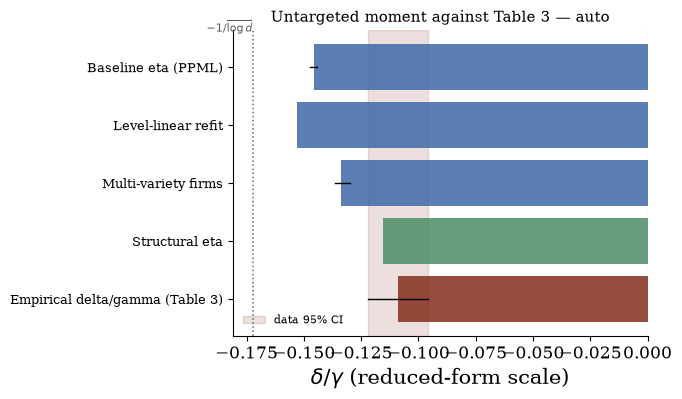

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


[aero]  236,484 supplier x downstream-region cells, 13,138 suppliers, 45.0% zeros, from ../reporting_aero_profiled_aa_gran_nlo1_pso/step3/suppliers.parquet
  measured eta = -1.3154 (0.0359)   ->  delta/gamma = -0.1524 [-0.1533, -0.1514]   (mean log d = 5.8, theta*alpha = 0.4579)
  DATA delta/gamma = -0.0980  [-0.1300, -0.0650]
  structural eta = -0.6672  =  extensive -0.5719 (86%) + substitution -0.0953 (14%)   ->  delta/gamma = -0.1370
    E_w(Lambda) = 1.249,  E_w(1-a) = 0.416,  theta*alpha = 0.4579,  (nu_s-1)/theta = 0.500
                                                            closed form  measured   ratio
check                                                                                    
E(Lambda | win) = 1 - gamma                                      1.2490    0.2182  5.7242
E(exp(-Lambda)) vs serving rate (ratio < 1: see docstring)       0.3481    0.5503  0.6325
eta_int/(theta*alpha) = (nu_s-1)/theta * E(1-a)                  0.2082    0.2082  1.0000
    a ratio far fr

/tmp/ipykernel_181628/2789161185.py:271: RuntimeWarning: invalid value encountered in scalar divide
  under_mu = float((mu * deriv).sum() / mu.sum())


  gap R = -0.6481  (measured STEEPER than structural)
    weighting  +nan   (derivative under fitted weights +nan vs under a*rho/rho~ -0.6672)
    functional +0.6099   (level-linear delta/gamma -0.1582 vs PPML's -0.1524)
    composition -1.2580   (origin-level primitives covarying with distance — the term the derivative does not take)
  within-area check (236,016 pairs, 13,112 suppliers): eta -1.3148 vs structural -0.6672, R = -0.6477   (against R = -0.6481 on the full sample — a smaller |R| here means comparative advantage covarying with distance was carrying it)
[aero]  delta/gamma, the reduced form's own scale (mean log d = 5.8, d = 330 km; the ratio cannot exceed 0.172 in magnitude)
                                 delta/gamma   ci_lo   ci_hi     n_obs                                                                isolates
specification                                                                                                                                 
Baseline eta (PPML

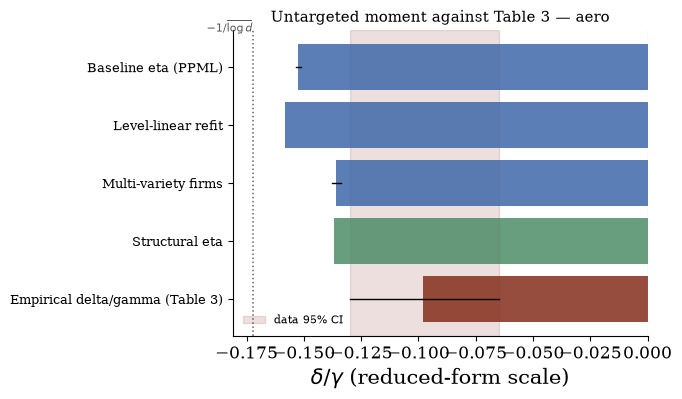

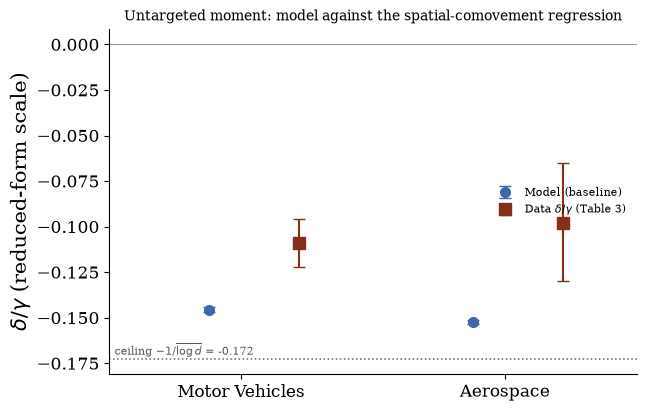

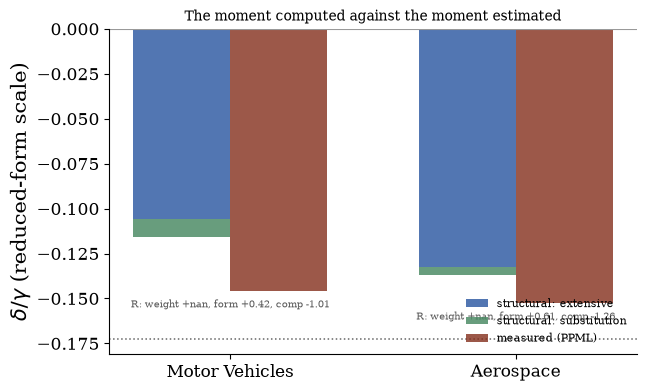

,fixed effect,delta/gamma (model),"95% CI (model, delta/gamma)",delta/gamma (data),95% CI (data),inside data CI,theta*alpha,suppliers,cells
industry,,,,,,,,,
Motor Vehicles,supplier + sector x buyer region,-0.145673,"[-0.147, -0.144]",-0.109,"[-0.122, -0.096]",False,0.228269,4010,88220
Aerospace,supplier + sector x buyer region,-0.152433,"[-0.153, -0.151]",-0.098,"[-0.130, -0.065]",False,0.457918,13138,236484


,theta*alpha,nu_s,eta struct,share ext,share int,E_w(Lambda),E_w(1-a),eta measured,R,R weighting,R functional,R composition,serving rate,buyers per supplier
industry,,,,,,,,,,,,,,
Motor Vehicles,0.228269,1.5,-0.350215,0.780859,0.219141,1.198013,0.672424,-0.939246,-0.58903,NaN,0.418425,-1.007455,0.730673,16.074813
Aerospace,0.457918,1.5,-0.667234,0.857146,0.142854,1.248953,0.416305,-1.315364,-0.64813,NaN,0.609885,-1.258015,0.550312,9.905617


In [265]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
# NOTE: `attach_lambda` and `structural_eta` need `unpack_estimated_T`, which is defined in
# the comparative-advantage section BELOW — run that definitions cell first if you are
# running this section on its own. The full run at the bottom does it in order.
untargeted_results, structural_results = [], []

for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    panel = attach_lambda(data, build_a_ir_panel(data))

    res = estimate_untargeted_moment(data, panel=panel)      # measured
    sres = structural_eta(data, panel)                       # computed
    validate_structural(data, panel, sres)                   # is Lambda wired correctly?
    gap = decompose_gap(data, panel, res, sres)              # what separates the two
    within_area_check(data, panel, gap)                      # a bound on the composition

    ladder = untargeted_specification_ladder(data, panel=panel, structural=sres)
    plot_untargeted_ladder(ladder, industry,
                           save_to=f"{out_folder}/untargeted_ladder_{industry}_mu{MU}.pdf")
    plt.show()

    untargeted_results.append(res)
    structural_results.append({**sres, **gap})

plot_untargeted_moment(untargeted_results,
                       save_to=f"{out_folder}/untargeted_eta_mu{MU}.pdf")
plt.show()
plot_structural_vs_measured(structural_results,
                            save_to=f"{out_folder}/untargeted_structural_mu{MU}.pdf")
plt.show()
display(untargeted_summary(untargeted_results))
display(structural_summary(structural_results))


# Comparative advantage against distance, within a sector

Inside a sector, competition for a given downstream buyer is between **cells**, and a
cell is a (sector, *region*) pair — not an attraction area. Comparative advantage is what
is constant within an area: every region of area $a$ shares $T_{as}$, but each has its own
distance to each buyer. With Fréchet productivity and wages normalised to one, the
Ricardian competition has a closed form over cells,

$$\rho_{l r s} = \frac{\psi_{l r s}}{\sum_{l'} \psi_{l' r s}}, \qquad
\psi_{l r s} = T_{a(l)s}\, d_{lr}^{-\theta\alpha},$$

so on a log scale the two forces are **additive and directly commensurable**:

$$\log \psi_{l r s} = \log T_{a(l)s} \;-\; \theta\alpha \log d_{lr}.$$

**The comparison is between two regions, not between two areas.** Region $r''$ beats
region $r'$ at buyer $r$ iff

$$\theta\alpha\big(\log d_{r'r} - \log d_{r''r}\big) \;<\; \log T_{a(r'')} - \log T_{a(r')},$$

with the distances measured *from each competing region* to the buyer and the comparative
advantages taken at the area each belongs to. Two things follow that an area-level reading
would miss:

1. when $a(r') = a(r'')$ the right-hand side is exactly zero, so **within an area
   competition is pure distance**. This is the variation that identifies $\alpha$, and it
   is invisible to any statement written in terms of area-level distances;
2. an area's edge does not protect *all* of its regions. It buys a distance handicap that
   each of its regions has to pay for out of its own location.

The section is written cell-by-cell throughout, so the only line that changes on the day
regions are allowed their own $T_{ls}$ deviating from their area's is the one that reads
$T_{a(l)s}$ off the area — nothing downstream assumes comparative advantage is constant
within an area.

**How the section proceeds.** Five tests, each in its own pair of cells (definitions, then
a run cell), building on one another:

| | question | answer |
|---|---|---|
| 1 | How unequal is comparative advantage inside a sector? | the spread of $\hat T$ across areas |
| 2 | What is that inequality worth in distance? | $\Delta \log \hat T / (\theta\hat\alpha)$, against the distances the geography offers |
| 3 | Does the favoured area actually win? | the exact comparison, buyer by buyer, region by region |
| 4 | Which of the two forces disperses the competition more? | the variance decomposition of $\log \psi$ |
| 5 | Is its covariance term telling us about the economy or about the estimator? | the Sinkhorn split of $\operatorname{Cov}(\log \hat T, \log d)$ |

Test 1 is descriptive, 2 turns it into a distance, 3 replaces the average with the exact
statement, and 4–5 ask which force does the work and whether the answer is contaminated by
how $\hat T$ was obtained. A sixth cell collects everything into one table, with a
glossary.

What the two forces do to the ALLOCATION is asked where it can be read as an economic
outcome rather than as a concentration index — in the amplification section below, which
propagates an actual shock with each force switched off.

Everything is computed from the estimated $\hat T$ and $\hat\alpha$ in `best_params`, the
distance matrix and $\theta$ — exact rather than Monte-Carlo, and available at either
`mu`. The geometry itself (`unpack_estimated_T`, `sourcing_geometry`) is defined with the
loader rather than here, because the amplification section needs the same win
probabilities to propagate a shock with one force switched off, and a helper with two
consumers cannot live inside either of them. It assumes the $N_{\tau} = 1$ power law $\tau = d^{\alpha}$; under a binned trade
cost there is no single distance elasticity to trade off against $T$, and the functions
refuse to run rather than report the first bin's coefficient. Regional wages are
normalised to one in this calibration, which is why they do not appear in $\psi$.


## Test 1 — how unequal is comparative advantage inside a sector?

The starting point, and purely descriptive: one dot per active attraction area, on a
**base-10 log** scale centred at the sector's median area, so the question "is there one
area that stands out, or is the sector flat?" is answered before anything is traded against
distance. One unit on the axis is an order of magnitude of $\hat T$. The top area is marked
and named.

Read in distance, which is what Test 2 does formally: the trade-off is scale-free, so an
area ahead by $x$ decades of $\hat T$ is offset by $x/(\theta\alpha)$ decades of distance —
about $3.6x$ at the motor-vehicle estimate $\theta\hat\alpha = 0.278$ and $2.3x$ at the
aerospace $0.430$. A dot one unit to the right of the pack is therefore an area that could
sit two to four orders of magnitude further from a buyer and still win, which is why these
gaps have to be checked against the distances the country actually offers rather than read
on their own.

Read the count of regions per area beside it: an area's edge is only as useful as the
locations that can exploit it, and the areas differ enormously in how many commuting zones
they contain. Note also that $\hat T$ is only identified up to a per-sector scale — the
reference area is normalised to one — so only *differences* within a sector mean anything,
which is why the figure is centred at the median.


In [266]:
# Test 1 — the within-sector spread of estimated comparative advantage.
# The helpers below are used by every test in the section.

def _sectors_in_code_order(data):
    """
    Sector display names in A129-CODE order.

    Every sector-indexed table and figure in this section is presented in this order, so
    the reader compares the same row across figures instead of re-reading a legend that
    has been resorted by whatever the figure happens to rank on.
    """
    return [n for _, n in sorted(zip(data["sector_names"], data["sector_names"]))]


def _by_sector_code(df, data, level=None):
    """Reindex a sector-indexed frame into A129-code order, dropping absent sectors."""
    order = [s for s in _sectors_in_code_order(data)
             if s in (df.index if level is None else df.index.get_level_values(level))]
    return df.reindex(order) if level is None else df.reindex(order, level=level)


def _buyer_weights(data):
    """Downstream buyers weighted by their purchases (the empirical pi_r target)."""
    w = np.asarray(data["emp_pi_r"], dtype=float).ravel()
    return w / w.sum()


def comparative_advantage_frame(data):
    """
    One row per (sector, active attraction area): the estimated T, its deviation from the
    sector's median area in BOTH log bases, its rank, and how many REGIONS the area
    contributes to that sector's competition (the areas differ enormously in that count,
    and an area's edge is only as useful as the locations that can exploit it).

    `log10_T_dev` is the column to read: one unit is an order of magnitude of comparative
    advantage, and because the trade-off against distance is scale-free
    (`log10 d_equivalent = log10_T_dev / (theta*alpha)`), a decade of T reads directly as
    `1/(theta*alpha)` decades of distance. `log_T_dev` keeps the natural log, which is the
    unit every theta*alpha-scaled formula in the tests below is written in.
    """
    est = unpack_estimated_T(data)
    aa_of_ze, CELL_MASK, AA_ACTIVE = data["aa_of_ze"], data["CELL_MASK"], data["AA_ACTIVE"]
    aa_names = aa_display_names(data)          # commuting-zone NAMES, not ZE codes
    rows = []
    for s in range(data["S"]):
        act = np.flatnonzero(AA_ACTIVE[s])
        if act.size == 0:
            continue
        T = est["T"][s, act]
        med = np.median(np.log(np.maximum(T, 1e-300)))
        order = np.argsort(-T)
        rank = np.empty(act.size, dtype=int)
        rank[order] = np.arange(1, act.size + 1)
        for k, a in enumerate(act):
            rows.append({
                "sector": data["sector_names"][s],
                "area": aa_names[a],
                "area_code": data["aa_names"][a],
                "T": float(T[k]),
                "log_T_dev": float(np.log(max(T[k], 1e-300)) - med),
                "log10_T_dev": float((np.log(max(T[k], 1e-300)) - med) / np.log(10.0)),
                "rank": int(rank[k]),
                "is_reference": bool(data["T_REF_AA"][s] == a),
                "n_cells": int(np.sum(CELL_MASK[s] & (aa_of_ze == a))),
            })
    return pd.DataFrame(rows)

def plot_ca_distribution(data, figsize=None, save_to=None, floor_ratio=1e-4):
    """
    The within-sector spread of estimated comparative advantage: one row per sector, one
    dot per active attraction area, on a LOG x axis centred at the sector's median area,
    so the axis reads in POWERS OF TEN of the ratio T_as / median_s(T) — a tick of 10
    means "ten times the median area", and one decade is one order of magnitude (and,
    divided by theta*alpha, decades of distance). The top area is marked and named — a
    sector whose best area sits far to the right of the pack is one where comparative
    advantage, not geography, decides.

    `floor_ratio` clips the left edge of the axis. `comparative_advantage_frame` guards
    T against zero with 1e-300, so a degenerate area would otherwise land at 10^-300 and
    compress every other sector into a single tick.
    """
    from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter

    caf = comparative_advantage_frame(data)
    order = [s for s in _sectors_in_code_order(data) if s in set(caf["sector"])][::-1]

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.95, hf=0.75))
    for y, sec in enumerate(order):
        sub = caf[caf["sector"] == sec]
        ratio = np.power(10.0, sub["log10_T_dev"].to_numpy(float))
        ax.scatter(ratio, np.full(len(sub), y), s=22, color=sim_color,
                   alpha=0.65, zorder=2)
        top = sub.loc[sub["rank"].idxmin()]
        r_top = 10.0 ** float(top["log10_T_dev"])
        ax.scatter([r_top], [y], s=60, marker="D", color=reference_color, zorder=3)
        ax.annotate(str(top["area"]), (r_top, y), fontsize=8,
                    xytext=(6, 4), textcoords="offset points", color=reference_color)

    # set_xscale BEFORE margins: margins computed on a linear axis then reinterpreted in
    # log units would push the extreme points against the frame.
    ax.set_xscale("log")
    ax.margins(x=0.12)
    ax.axvline(1.0, color="0.6", linewidth=0.8)          # the median area, ratio = 1

    all_ratio = np.power(10.0, caf["log10_T_dev"].to_numpy(float))
    finite = all_ratio[np.isfinite(all_ratio) & (all_ratio > 0)]
    if finite.size:
        ax.set_xlim(left=max(float(finite.min()) * 0.5, floor_ratio))

    # Plain numbers rather than 10^k: the ratios of interest sit within a few decades of
    # 1, and "30" is read faster than "3x10^1". %g would fall back to scientific notation
    # below 1e-4 on its own, hence the explicit decimal count per decade.
    def _plain(v, _):
        if v <= 0:
            return ""
        k = int(np.floor(np.log10(v)))
        return f"{v:,.0f}" if k >= 0 else f"{v:.{-k}f}"

    ax.xaxis.set_major_locator(LogLocator(base=10.0))
    ax.xaxis.set_major_formatter(FuncFormatter(_plain))
    ax.xaxis.set_minor_formatter(NullFormatter())

    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order, fontsize=9)
    ax.set_xlabel(r"$\hat T_{as}$ relative to the sector's median area "
                  r"(ratio, log scale; one decade = one order of magnitude)")
    ax.set_ylabel("Sector")
    ax.set_title(f"Comparative advantage within sector — {data['industry']}, "
                 rf"$\hat\mu_{data['mu']}$")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax

[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


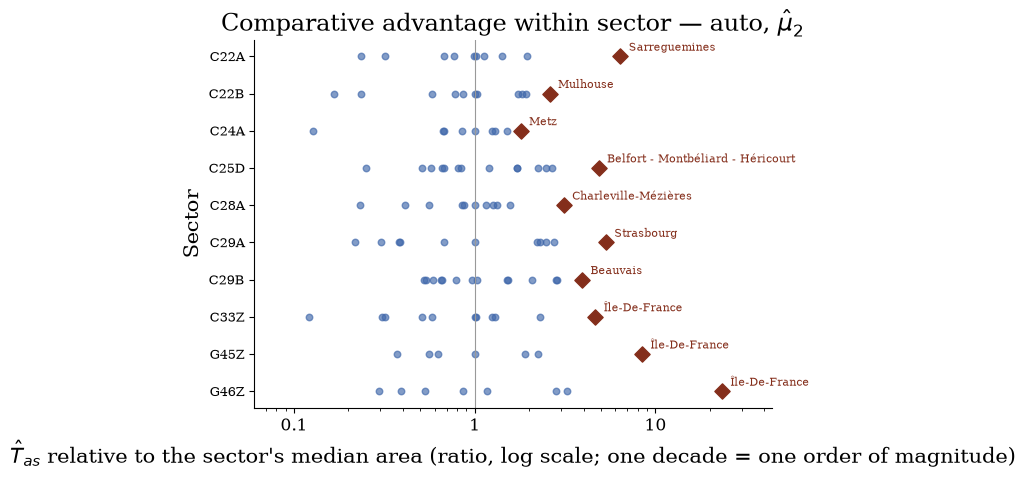

,sector,area,area_code,T,log_T_dev,log10_T_dev,rank,is_reference,n_cells
0,C22A,Île-De-France,1100,0.701017,-0.011566,-0.005023,6,False,11
1,C22A,Beauvais,2207,1.382199,0.667333,0.289819,2,False,4
2,C22A,Rouen,2307,0.225749,-1.144674,-0.497126,9,False,4
3,C22A,Sarreguemines,4110,4.536073,1.855719,0.805928,1,False,3
4,C22A,Vesoul,4309,0.717422,0.011566,0.005023,5,False,7
5,C22A,Angers,5205,0.479609,-0.391126,-0.169864,8,False,20
6,C22A,Le Mans,5213,0.543799,-0.265519,-0.115313,7,False,11
7,C22A,Rennes,5312,0.795064,0.114324,0.049650,4,False,8
8,C22A,Valence,8208,1.000000,0.343657,0.149248,3,True,34
9,C22A,Annecy,8218,0.167384,-1.443805,-0.627037,10,False,11


[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


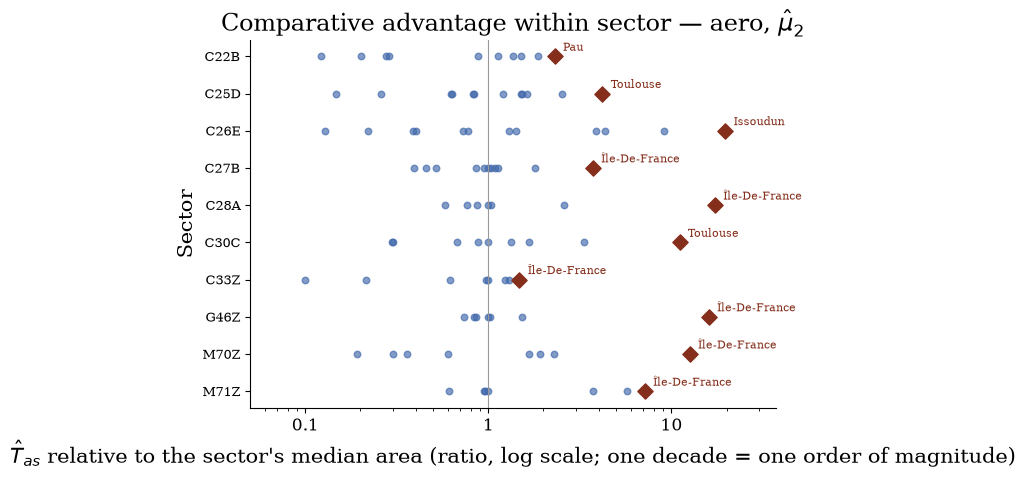

,sector,area,area_code,T,log_T_dev,log10_T_dev,rank,is_reference,n_cells
0,C22B,Roissy - Sud Picardie,0056,0.133001,-1.605802,-0.697391,9,False,50
1,C22B,Toulouse,0061,0.585052,-0.124459,-0.054052,6,False,14
2,C22B,Île-De-France,1100,0.904628,0.311364,0.135223,4,False,12
3,C22B,Issoudun,2408,0.750410,0.124459,0.054052,5,False,9
4,C22B,Cholet,5206,1.000000,0.411595,0.178753,3,True,19
5,C22B,Bordeaux,7204,0.182930,-1.287059,-0.558963,8,False,8
6,C22B,Pau,7214,1.524525,0.833278,0.361888,1,False,4
7,C22B,Valence,8208,0.190381,-1.247131,-0.541622,7,False,32
8,C22B,Montluçon,8301,0.080622,-2.106395,-0.914796,10,False,25
9,C22B,Marseille - Aubagne,9310,1.230412,0.618944,0.268804,2,False,4


In [267]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_ca_distribution(
        data, save_to=f"{out_folder}/ca_distribution_{industry}_mu{MU}.pdf")
    plt.show()
    display(comparative_advantage_frame(data).head(12))


## Test 2 — what is that inequality worth in distance?

The two forces are commensurable on a log scale, so an edge in comparative advantage can be
quoted in kilometres. A gap of $\Delta$ in $\log T$ is offset by a distance ratio of
$\exp\!\big(\Delta/(\theta\alpha)\big)$: how many times further from a buyer a region of the
favoured area may sit than a competing region of the other area, and still win.

That number is only meaningful against the distances the geography actually offers, so it
is compared with two benchmarks, both computed on **cell-to-buyer** distances:

* `geo_log_spread` — the *typical* spread, p90 − p10 of $\log d$ across the regions
  competing for a given buyer, averaged over buyers with their purchase weights. Clearing
  it means the edge beats the distances a buyer ordinarily faces;
* `geo_log_range` — the *extreme* spread, pooled max − min. It is anchored at the
  own-region cell, so one degenerate observation sets it: clearing it means no location in
  the country offsets the edge and the area supplies every buyer.

Both benchmarks are averages of a distribution, which is what Test 3 then removes.


In [268]:
# Test 2 — the edge in distance units, against the distances the geography offers.
from matplotlib.ticker import LogFormatterSciNotation
def ca_distance_equivalence(data):
    """
    How much distance a comparative-advantage gap is worth, against how much distance the
    country actually offers.

    `equiv_log_d = Delta log T / (theta*alpha)` is the log distance ratio that exactly
    offsets the gap between the top area and the median one — how much further from a
    buyer a REGION of the top area may sit than a competing REGION of the median area.
    It is compared with two benchmarks, both computed on cell-to-buyer distances:

      `geo_log_range`  the EXTREME spread, pooled max - min of log distance across all
                       competing cells and buyers. Anchored at the own-region cell, so
                       one degenerate observation sets it: it is the largest gap the
                       geography could ever offer;
      `geo_log_spread` the TYPICAL spread: p90 - p10 of log distance across the cells
                       competing for a given buyer, averaged over buyers with their
                       purchase weights.

    These two are averages over a distribution. `ca_win_margin` does the same comparison
    exactly, buyer by buyer, and is the one to quote; this table is the summary version.
    """
    geom = sourcing_geometry(data)
    ta = geom["theta"] * geom["alpha"]
    caf = comparative_advantage_frame(data)
    rows = []
    for s, blk in geom["by_sector"].items():
        name = data["sector_names"][s]
        sub = caf[caf["sector"] == name].sort_values("rank")
        if sub.empty:
            continue
        logT = np.log(np.maximum(sub["T"].to_numpy(), 1e-300))
        d_top_med = float(logT[0] - np.median(logT))
        d_top_2nd = float(logT[0] - logT[1]) if logT.size > 1 else np.nan
        ld = np.log(blk["distance"])
        geo_range = float(ld.max() - ld.min())
        per_buyer = np.percentile(ld, 90, axis=0) - np.percentile(ld, 10, axis=0)
        geo_spread = float(per_buyer @ _buyer_weights(data))
        equiv = d_top_med / ta if ta > 0 else np.inf
        rows.append({
            "sector": name, "top_area": sub["area"].iloc[0], "n_areas": len(sub),
            "dlogT_top_vs_median": d_top_med, "dlogT_top_vs_2nd": d_top_2nd,
            "equiv_log_d": equiv,
            "equiv_distance_ratio": float(np.exp(min(equiv, 700))),
            "geo_log_range": geo_range, "geo_log_spread": geo_spread,
            "CA_beats_any_geography": bool(equiv > geo_range),
            "CA_beats_typical_geography": bool(equiv > geo_spread),
        })
    df = _by_sector_code(pd.DataFrame(rows).set_index("sector"), data)
    df.attrs["theta_alpha"] = ta
    return df

def plot_ca_distance_equivalence(data, figsize=None, save_to=None, reference_km=1.0):
    """
    What the top area's comparative-advantage edge is worth, in kilometres.

    One POINT per sector, on a LOG x axis. The edge is a RATIO --
    `exp(Delta log T / (theta*alpha))` is the factor by which a region of the top area
    may be further from a buyer than a competing region of the median area and still
    win. With `reference_km = 1` the point IS that factor read as kilometres:

        equiv_km = exp(Delta log T / (theta * alpha))

    Read it as: a supplier of the top area wins a buyer at that distance against a
    median area's supplier sitting one kilometre away. The axis is logarithmic because
    theta*alpha is small, so the factor spans orders of magnitude across sectors.

    A point rather than a bar because the quantity is a RATIO on a log axis: a bar's
    length is read against its origin, and on a log axis that origin is arbitrary (it is
    wherever the axis happens to start), so the bar encodes the axis limits as much as
    the number. A point encodes only its position, which is the whole of the content.

    Each point is NAMED with its TOP AREA -- the attraction area holding the edge, by its
    anchor commuting zone -- in the same form test 1 names it, beside the mark rather than
    on the axis. Without it the figure says how large the edge is and not whose it is, and
    that name is the first thing a reader of the table looks up; beside the point it is
    read WITH the number, and the y axis stays a plain list of sectors.

    The dashed line is the BILATERAL MEDIAN cell-to-buyer distance -- the distance a
    typical supplier-buyer link actually spans in this industry. It is drawn for scale
    only: it is NOT the anchor of the bars, and a bar exceeding it does not by itself
    establish that comparative advantage beats geography. Test 3 (`ca_win_margin`) is
    the buyer-by-buyer comparison that does.
    """
    from matplotlib.ticker import LogFormatterSciNotation, LogLocator, NullFormatter

    df = ca_distance_equivalence(data)[::-1]        # A129-code order, top to bottom
    geom = sourcing_geometry(data)

    # Median over all cell-buyer pairs, pooled across sectors: a scale benchmark, not an
    # anchor. Unweighted, so each buyer counts in proportion to the cells competing for
    # it rather than to its purchases.
    med = [float(np.median(blk["distance"])) for blk in geom["by_sector"].values()]
    median_km = float(np.mean(med)) if med else np.nan

    km = reference_km * np.exp(np.minimum(df["equiv_log_d"].to_numpy(float), 700.0))
    y = np.arange(len(df))

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.95, hf=0.62))
    ax.plot(km, y, linestyle="none", marker="o", markersize=7, color=reference_color,
            markeredgecolor="black", markeredgewidth=0.5)
    for yi, (x_i, area) in enumerate(zip(km, df["top_area"].astype(str))):
        ax.annotate(area, (x_i, yi), fontsize=8, xytext=(6, 4),
                    textcoords="offset points", color=reference_color)
    ax.set_xscale("log")
    ax.set_ylim(-0.6, len(df) - 0.4)

    if np.isfinite(median_km) and median_km > 0:
        ax.axvline(median_km, color="black", ls="dashed", lw=1.0, alpha=0.7)
        # anchored to the axis top and set to the LEFT of the line: with no title there
        # is no margin above, and the line sits near the right edge, so a label placed
        # to its right runs off the figure
        ax.text(median_km, ax.get_ylim()[1],
                f"Bilateral median distance: {median_km:,.0f} km ",
                fontsize=8, va="top", ha="right", color="0.3")

    fmt = LogFormatterSciNotation(base=10.0)
    ax.xaxis.set_major_locator(LogLocator(base=10.0))
    ax.xaxis.set_major_formatter(fmt)
    ax.xaxis.set_minor_formatter(NullFormatter())

    # Limits must now bracket the bars AND the benchmark line: the line is no longer the
    # anchor, so nothing guarantees it falls inside the range the bars span.
    finite = km[np.isfinite(km) & (km > 0)]
    anchors = [v for v in (float(finite.min()) if finite.size else np.nan, median_km)
               if np.isfinite(v) and v > 0]
    if anchors:
        ax.set_xlim(left=min(anchors) * 0.5)
    if finite.size and np.isfinite(median_km):
        # room for the NAME, not just for the number: the annotation runs to the right of
        # the widest point, and at x2 that point sits ~90% across and its label overhangs
        # the frame
        ax.set_xlim(right=max(float(finite.max()), median_km) * 4.0)

    ax.set_yticks(y)
    ax.set_yticklabels(df.index, fontsize=9)
    ax.set_xlabel("Distance (km)")
    ax.grid(axis="x", which="major", linestyle="dashed", alpha=0.4)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax

[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


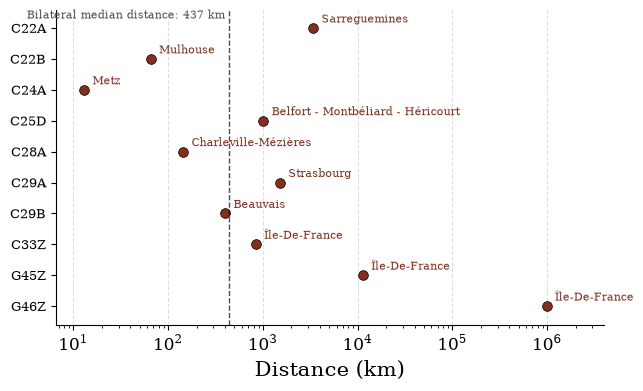

,top_area,n_areas,dlogT_top_vs_median,dlogT_top_vs_2nd,equiv_log_d,equiv_distance_ratio,geo_log_range,geo_log_spread,CA_beats_any_geography,CA_beats_typical_geography
sector,,,,,,,,,,
C22A,Sarreguemines,10,1.855719,1.188386,8.129536,3393.225449,4.510434,1.538358,True,True
C22B,Mulhouse,11,0.955204,0.303019,4.184562,65.664709,4.533789,1.350025,False,True
C24A,Metz,9,0.586143,0.180975,2.567777,13.036811,4.533789,1.342422,False,True
C25D,Belfort - Montbéliard - Héricourt,14,1.579761,0.597289,6.920621,1012.948630,4.771428,1.528611,True,True
C28A,Charleville-Mézières,11,1.135484,0.691776,4.974329,144.651759,4.552407,1.367805,True,True
C29A,Strasbourg,11,1.672087,0.666924,7.325082,1517.898810,4.787456,1.272539,True,True
C29B,Beauvais,14,1.368051,0.317779,5.993161,400.679152,4.745919,1.528344,True,True
C33Z,Île-De-France,11,1.537396,0.707666,6.735026,841.365210,4.533789,1.365123,True,True
G45Z,Île-De-France,7,2.131719,1.328828,9.338638,11368.907837,4.536379,1.381816,True,True


[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


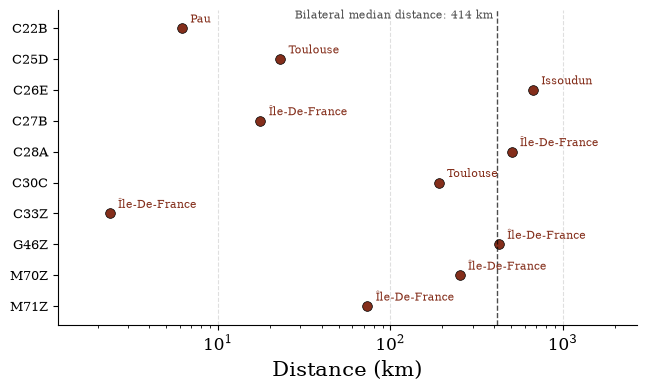

,top_area,n_areas,dlogT_top_vs_median,dlogT_top_vs_2nd,equiv_log_d,equiv_distance_ratio,geo_log_range,geo_log_spread,CA_beats_any_geography,CA_beats_typical_geography
sector,,,,,,,,,,
C22B,Pau,10,0.833278,0.214334,1.819711,6.170076,4.434990,1.406121,False,True
C25D,Toulouse,12,1.434649,0.503993,3.132986,22.942388,5.647328,1.413060,False,True
C26E,Issoudun,12,2.980589,0.770515,6.509008,671.160002,5.687365,1.489231,True,True
C27B,Île-De-France,11,1.313386,0.733093,2.868171,17.604793,5.647328,1.393490,False,True
C28A,Île-De-France,7,2.849522,1.900608,6.222785,504.105080,4.182868,1.277212,True,True
C30C,Toulouse,9,2.404526,1.197783,5.251002,190.757289,4.778641,1.400256,True,True
C33Z,Île-De-France,9,0.390775,0.046869,0.853374,2.347553,4.823596,1.585438,False,False
G46Z,Île-De-France,7,2.771921,2.347832,6.053318,425.522783,5.647328,1.475244,True,True
M70Z,Île-De-France,8,2.531519,1.701145,5.528330,251.723068,4.965071,1.481145,True,True


In [269]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_ca_distance_equivalence(
        data, save_to=f"{out_folder}/ca_distance_equivalence_{industry}_mu{MU}.pdf")
    plt.show()
    display(ca_distance_equivalence(data))


## Test 3 — does the favoured area actually win?

Test 2 compares an average edge with an average spread. Neither average has to hold for any
particular buyer, so here the comparison is made exactly, **buyer by buyer and region by
region**, which is the form the inequality at the top of the section takes.

For each sector let $A^*$ be the area with the highest $\hat T$. For each downstream buyer
$r$, every competing cell $l$ carries a score $\log \psi_{lr} = \log T_{a(l)} - \theta\alpha
\log d_{lr}$, and $A^*$ takes the buyer iff its best cell outscores the best cell outside
it. Two numbers come out, both in log-distance units:

* **`mean_win_margin`** — $\big[\max_{l \in A^*} \log\psi - \max_{l \notin A^*}
  \log\psi\big]/(\theta\alpha)$: how much further from this buyer the favoured area's best
  region could be and still win. Positive means it wins; `share_buyers_won` is the
  purchase-weighted share of buyers it takes;
* **`mean_within_penalty`** — $\log d$ of the worst region of $A^*$ minus that of its best,
  for the same buyer. Inside an area $T$ cancels exactly, so this comparison is **pure
  geography**: it is the handicap the area's own spread imposes on its worst region, and it
  is the variation that identifies $\alpha$.

Putting the two side by side answers a question the area-level statement cannot even pose:
does it matter more *which area* a supplier belongs to, or *which region of it* it sits in?
When the second bar is longer than the first, the answer is the region — and that is
exactly the case in which letting regions deviate from their area's $T$ would change the
picture most.


In [270]:
# Test 3 — the exact comparison, buyer by buyer and region by region.

def ca_win_margin(data):
    """
    The decisive test, buyer by buyer and REGION by region — no averaging of distances.

    For each sector, let A* be the area with the highest T. For each downstream buyer r,
    every competing cell l has score

        log psi_lr = log T_{a(l)} - theta*alpha*log d_{lr},

    so A* takes the buyer iff its best cell outscores the best cell OUTSIDE it. Two
    numbers come out of that comparison, both in LOG-DISTANCE units (divide by
    theta*alpha), which is what makes them readable:

      win_margin_r  = [max_{l in A*} score - max_{l not in A*} score] / (theta*alpha)
                      how much FURTHER the favoured area's best region could be from
                      this buyer and still win. Positive = it wins.
      within_penalty_r = log d(worst cell of A*) - log d(best cell of A*)
                      the handicap A*'s own geography imposes on its worst region. Inside
                      an area T cancels exactly, so this comparison is PURE DISTANCE —
                      it is the variation that identifies alpha, and it is invisible to
                      any statement written in terms of area-level distances.

    Both are averaged over buyers with their purchase weights. `share_buyers_won` is the
    purchase-weighted share of buyers the favoured area actually takes; comparing
    `mean_win_margin` with `mean_within_penalty` says whether belonging to the right area
    or sitting in the right region of it matters more.
    """
    geom = sourcing_geometry(data)
    ta, w = geom["theta"] * geom["alpha"], _buyer_weights(data)
    est_T = geom["T"]
    rows = []
    for s, blk in geom["by_sector"].items():
        act = np.flatnonzero(data["AA_ACTIVE"][s])
        if act.size == 0:
            continue
        top_area = int(act[np.argmax(est_T[s, act])])
        in_top = blk["areas"] == top_area
        if not in_top.any() or in_top.all():
            continue                       # no cross-area comparison to make
        score = blk["log_psi"]                                   # (n_cell, R_d)
        ld = np.log(blk["distance"])
        best_top = score[in_top].max(axis=0)
        best_out = score[~in_top].max(axis=0)
        margin = (best_top - best_out) / ta if ta > 0 else np.full_like(best_top, np.inf)
        penalty = ld[in_top].max(axis=0) - ld[in_top].min(axis=0)
        rows.append({
            "sector": data["sector_names"][s],
            "top_area": aa_display_names(data)[top_area],
            "n_cells_top_area": int(in_top.sum()),
            "share_buyers_won": float((margin > 0) @ w),
            "mean_win_margin": float(margin @ w),
            "min_win_margin": float(margin.min()),
            "mean_within_penalty": float(penalty @ w),
            "area_beats_own_geography": bool(float(margin @ w) > float(penalty @ w)),
        })
    df = pd.DataFrame(rows)
    return _by_sector_code(df.set_index("sector"), data) if len(df) else df


def plot_ca_win_margin(data, figsize=None, save_to=None):
    """
    The exact test, per sector: how much further the top area's best region could be from
    the average buyer and still win (bar), against the distance handicap that area's own
    geography already imposes on its worst region (marker). Both in log-distance units,
    so they are directly comparable — a bar shorter than its marker is a sector where
    WHICH REGION of the favoured area a supplier sits in matters more than the area's
    edge itself.
    """
    df = ca_win_margin(data)
    if not len(df):
        raise ValueError("no sector has cells both inside and outside its top area — "
                         "there is no cross-area comparison to draw.")
    df = df[::-1]
    y = np.arange(len(df))
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.95, hf=0.7))
    ax.barh(y, df["mean_win_margin"],
            color=[reference_color if v else sim_color
                   for v in df["area_beats_own_geography"]], alpha=0.85,
            label="win margin of the top area (log distance it could give away)")
    ax.scatter(df["mean_within_penalty"], y, marker="|", s=220, color="black", zorder=3,
               label="within-area distance handicap (best to worst region of that area)")
    ax.axvline(0.0, color="0.6", linewidth=0.8)
    for i, (_, r) in enumerate(df.iterrows()):
        ax.annotate(f"{100 * r['share_buyers_won']:.0f}% of buyers",
                    (max(r["mean_win_margin"], 0.0), i), fontsize=8,
                    xytext=(4, -3), textcoords="offset points")
    ax.set_yticks(y)
    ax.set_yticklabels(df.index, fontsize=9)
    ax.set_xlabel("log distance")
    ax.set_title(f"Does the favoured area actually win? — {data['industry']}, "
                 rf"$\hat\mu_{data['mu']}$", fontsize=11)
    ax.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.18))
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


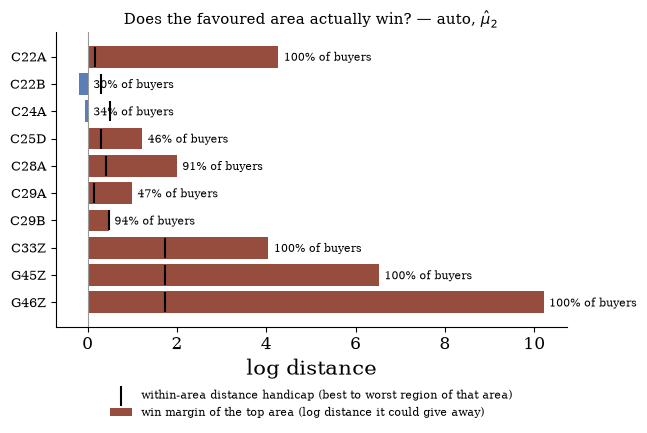

,top_area,n_cells_top_area,share_buyers_won,mean_win_margin,min_win_margin,mean_within_penalty,area_beats_own_geography
sector,,,,,,,
C22A,Sarreguemines,3,1.000000,4.267735,2.211579,0.163494,True
C22B,Mulhouse,4,0.301290,-0.195206,-2.066765,0.306439,False
C24A,Metz,7,0.340575,-0.064811,-2.147457,0.497587,False
C25D,Belfort - Montbéliard - Héricourt,3,0.459465,1.218489,-0.213569,0.296740,True
C28A,Charleville-Mézières,4,0.908475,1.994199,-0.106490,0.419986,True
C29A,Strasbourg,4,0.471849,0.988877,-0.154471,0.150576,True
C29B,Beauvais,3,0.944026,0.474431,-1.395903,0.466361,True
C33Z,Île-De-France,14,1.000000,4.046695,0.404516,1.722662,True
G45Z,Île-De-France,14,1.000000,6.521338,3.855291,1.722662,True


[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


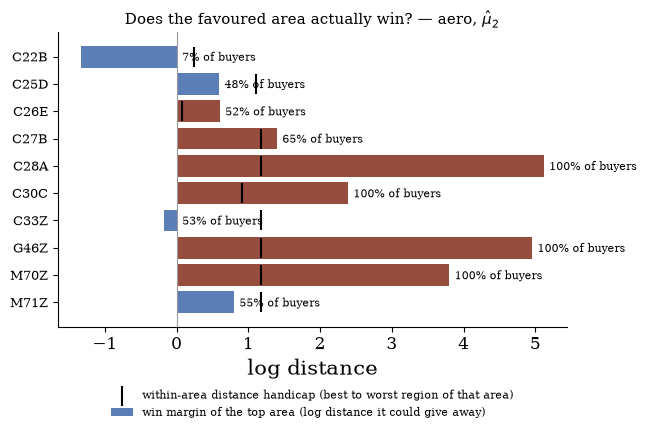

,top_area,n_cells_top_area,share_buyers_won,mean_win_margin,min_win_margin,mean_within_penalty,area_beats_own_geography
sector,,,,,,,
C22B,Pau,4,0.073753,-1.334527,-3.002795,0.242306,False
C25D,Toulouse,18,0.477527,0.589860,-1.409357,1.111834,False
C26E,Issoudun,2,0.516274,0.599860,-0.727389,0.079622,True
C27B,Île-De-France,11,0.649417,1.395943,-2.108064,1.179510,True
C28A,Île-De-France,11,1.000000,5.116175,1.216319,1.175907,True
C30C,Toulouse,6,1.000000,2.387242,0.357747,0.917569,True
C33Z,Île-De-France,12,0.534039,-0.169212,-3.606639,1.179510,False
G46Z,Île-De-France,12,1.000000,4.953941,2.192965,1.179510,True
M70Z,Île-De-France,12,1.000000,3.798925,0.042871,1.179510,True


In [271]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_ca_win_margin(
        data, save_to=f"{out_folder}/ca_win_margin_{industry}_mu{MU}.pdf")
    plt.show()
    display(ca_win_margin(data))


## Test 4 — which force disperses the competition more?

Tests 2 and 3 ask who wins. This one asks which force is doing the work, and it is an
identity rather than a regression. Because $\log\psi$ is a sum, its dispersion across the
cells competing for a given buyer splits *exactly*:

$$\operatorname{Var}(\log\psi) = \operatorname{Var}(\log T) + (\theta\alpha)^2\operatorname{Var}(\log d) - 2\theta\alpha\operatorname{Cov}(\log T, \log d).$$

Variances are taken **across cells at a fixed buyer** — the competition the model actually
runs — and then averaged over buyers with their purchase weights.
$\operatorname{sd}(\log T)$ against $\theta\alpha\operatorname{sd}(\log d)$ is the
like-for-like size of the two pulls, and `ratio_CA_over_distance` above one says
comparative advantage disperses the competition more than geography does.

The three shares sum to one by construction. The covariance share is the interesting one
and the one not to over-read — which is what Test 5 is for.


In [272]:
# Test 4 — the exact variance decomposition of log psi across competing cells.

def ca_variance_decomposition(data):
    """
    The exact split of the dispersion of log psi across competing cells.

    For a given buyer r, log psi_{l,r} = log T_l - theta*alpha*log d_{l,r}, so

        Var_l(log psi) = Var_l(log T) + (theta*alpha)^2 Var_l(log d)
                         - 2*theta*alpha*Cov_l(log T, log d)

    holds with no approximation. Variances are taken ACROSS CELLS at a fixed buyer —
    which is the competition the model actually runs — then averaged over buyers with
    their purchase weights. `sd_logT` against `sd_dist` is the like-for-like size of the
    two forces.

    The covariance term is NOT free of the estimator: T is the Sinkhorn image of the
    observed sourcing shares, which loads onto comparative advantage whatever distance
    takes away, so a positive Cov(log T, log d) — hence a negative contribution
    `share_covariance` — is the expected reading. `ca_covariance_benchmark` splits it.
    """
    geom = sourcing_geometry(data)
    ta, w = geom["theta"] * geom["alpha"], _buyer_weights(data)
    rows = []
    for s, blk in geom["by_sector"].items():
        if blk["cells"].size < 2:
            continue
        logT = np.log(np.maximum(blk["T_cell"], 1e-300))
        ld = np.log(blk["distance"])                       # (n_cell, R_d)
        v_T = float(np.var(logT))
        v_d = np.var(ld, axis=0)                           # per buyer
        cov = np.array([np.cov(logT, ld[:, r], bias=True)[0, 1] for r in range(ld.shape[1])])
        v_psi = v_T + (ta ** 2) * v_d - 2 * ta * cov
        vd_bar, cov_bar, vpsi_bar = float(v_d @ w), float(cov @ w), float(v_psi @ w)
        rows.append({
            "sector": data["sector_names"][s],
            "sd_logT": np.sqrt(v_T),
            "sd_dist": ta * np.sqrt(vd_bar),
            "ratio_CA_over_distance": np.sqrt(v_T) / (ta * np.sqrt(vd_bar))
            if vd_bar > 0 else np.inf,
            "share_CA": v_T / vpsi_bar if vpsi_bar > 0 else np.nan,
            "share_distance": (ta ** 2) * vd_bar / vpsi_bar if vpsi_bar > 0 else np.nan,
            "share_covariance": -2 * ta * cov_bar / vpsi_bar if vpsi_bar > 0 else np.nan,
            "sd_log_psi": np.sqrt(vpsi_bar),
        })
    return _by_sector_code(pd.DataFrame(rows).set_index("sector"), data)


In [273]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    display(ca_variance_decomposition(data))


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,sd_logT,sd_dist,ratio_CA_over_distance,share_CA,share_distance,share_covariance,sd_log_psi
sector,,,,,,,
C22A,0.646854,0.143408,4.510577,0.990982,0.048708,-0.039690,0.649790
C22B,0.869439,0.131992,6.587063,0.890662,0.020527,0.088811,0.921262
C24A,0.992669,0.146356,6.782546,0.853673,0.018557,0.127770,1.074382
C25D,0.944432,0.148158,6.374488,0.846555,0.020834,0.132612,1.026462
C28A,0.743101,0.133378,5.571392,0.819060,0.026387,0.154553,0.821088
C29A,1.004207,0.132223,7.594825,0.870090,0.015084,0.114826,1.076568
C29B,0.580684,0.152631,3.804497,0.768229,0.053076,0.178695,0.662513
C33Z,0.974689,0.133501,7.300991,0.879691,0.016503,0.103806,1.039204
G45Z,0.868850,0.135668,6.404234,0.947740,0.023108,0.029152,0.892484


[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,sd_logT,sd_dist,ratio_CA_over_distance,share_CA,share_distance,share_covariance,sd_log_psi
sector,,,,,,,
C22B,0.937202,0.276643,3.387771,0.865898,0.075446,0.058656,1.007163
C25D,1.056287,0.270998,3.897773,0.875221,0.057608,0.067170,1.129076
C26E,1.360519,0.306745,4.435344,0.878195,0.044641,0.077164,1.451808
C27B,0.545449,0.272573,2.001110,0.712436,0.177911,0.109653,0.646221
C28A,0.900124,0.256494,3.509334,0.849872,0.069009,0.081120,0.976395
C30C,1.204839,0.313906,3.838219,0.852162,0.057845,0.089994,1.305173
C33Z,0.913156,0.309986,2.945801,0.889487,0.102502,0.008011,0.968222
G46Z,0.759738,0.287425,2.643252,0.783989,0.112210,0.103801,0.858042
M70Z,1.231424,0.293456,4.196281,0.861462,0.048922,0.089616,1.326752


## Test 5 — is the covariance term about the economy or about the estimator?

Under `--profile_T=true`, $\hat T$ is not a free estimate: it is the Sinkhorn image that
makes the model reproduce the *observed* sourcing shares at the current $\alpha$. At the
area level,

$$\log \hat T_{as} \;=\; \log \hat\gamma^{\,emp}_{as} \;-\; \log M_{as}(\alpha) + \text{const},
\qquad M_{as}(\alpha) = \sum_r \omega_r\, d_{ar}^{-\theta\alpha}/\Phi_{sr},$$

with $M$ the market-access term. $M$ falls with distance to markets, so a remote area that
nonetheless sells must be handed a **higher** $T$: the inversion loads onto comparative
advantage exactly what distance takes away. Hence, cell by cell,

$$\operatorname{Cov}(\log \hat T, \log d) \;=\; \underbrace{\operatorname{Cov}(\log \hat\gamma^{\,emp}, \log d)}_{\text{the gradient in the data}} \;-\; \underbrace{\operatorname{Cov}(\log M, \log d)}_{<\,0,\ \text{growing in } \alpha},$$

so the expected sign of $\operatorname{Cov}(\log \hat T, \log d)$ is **positive** unless the
observed sourcing shares fall with distance fast enough to outweigh the correction — and a
positive covariance makes Test 4's `share_covariance` **negative**: the two forces offset,
and $\operatorname{Var}(\log\psi)$ is smaller than the sum of the two separate variances.
That is the inversion's signature, not a finding about the economy, and reading Test 4
without it invites calling comparative advantage "large" when what is large is the
compensation for remoteness.

`ca_covariance_benchmark` reports the two terms separately, taking
$\log M = \log\hat\gamma^{emp} - \log\hat T$ as the residual (exact up to the per-sector
constant, which a covariance drops), so which one drives the total is a number. At
$\alpha = 0$ the market-access term is common within a sector and must vanish, leaving
$\operatorname{Cov}(\log\hat T, \log d) = \operatorname{Cov}(\log\hat\gamma, \log d)$ — the
limiting case to check the split against.


In [274]:
# Test 5 — where the covariance term comes from, given how T was obtained.

def ca_covariance_benchmark(data):
    """
    Where the covariance term of the decomposition comes from — the data, or the
    inversion.

    Under profiling, T is chosen so the model reproduces the observed sourcing shares:
    at the area level, log T_a = log gamma^emp_a - log M_a(alpha) + const, with M the
    market-access term. Hence, cell by cell,

        Cov(log T, log d) = Cov(log gamma^emp, log d) - Cov(log M, log d),

    and since M falls with distance to markets the second term is negative, i.e. the
    inversion MECHANICALLY pushes Cov(log T, log d) up: a remote area that nonetheless
    sells must be handed a higher T. This function reports the two pieces, taking
    log M = log gamma^emp - log T as the residual (exact up to the per-sector constant,
    which drops out of a covariance). Read `cov_gamma` as the gradient in the data and
    `-cov_M` as what the inversion added on top of it.

    At alpha = 0 the market-access term is common within a sector and `cov_M` must
    vanish, leaving `cov_T == cov_gamma` — the limiting case to check the split against.
    """
    geom = sourcing_geometry(data)
    ta, w = geom["theta"] * geom["alpha"], _buyer_weights(data)
    emp_gamma_aa, aa_of_ze = data["emp_gamma_aa"], data["aa_of_ze"]
    rows = []
    for s, blk in geom["by_sector"].items():
        cells, areas = blk["cells"], blk["areas"]
        g = emp_gamma_aa[s, areas]
        keep = (g > 0) & (blk["T_cell"] > 0)
        if keep.sum() < 2:
            continue
        logT = np.log(blk["T_cell"][keep])
        logG = np.log(g[keep])
        logM = logG - logT                                  # the market-access residual
        ld = np.log(blk["distance"][keep])
        def _cov(x):
            return float(np.array([np.cov(x, ld[:, r], bias=True)[0, 1]
                                   for r in range(ld.shape[1])]) @ w)
        cov_T, cov_G, cov_M = _cov(logT), _cov(logG), _cov(logM)
        sd_ld = float(np.sqrt(np.array([np.var(ld[:, r]) for r in range(ld.shape[1])]) @ w))
        rows.append({
            "sector": data["sector_names"][s],
            "cov_T": cov_T, "cov_gamma": cov_G, "cov_M": cov_M,
            "check_gamma_minus_M": cov_G - cov_M - cov_T,      # 0 by construction
            "corr_T_d": cov_T / (np.std(logT) * sd_ld) if sd_ld > 0 and np.std(logT) > 0 else np.nan,
            "corr_gamma_d": cov_G / (np.std(logG) * sd_ld) if sd_ld > 0 and np.std(logG) > 0 else np.nan,
            "share_covariance": np.nan,
        })
    df = pd.DataFrame(rows).set_index("sector")
    vd = ca_variance_decomposition(data)
    df["share_covariance"] = vd["share_covariance"].reindex(df.index)
    df.attrs["theta_alpha"] = ta
    return _by_sector_code(df, data)


In [275]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    display(ca_covariance_benchmark(data))


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,cov_T,cov_gamma,cov_M,check_gamma_minus_M,corr_T_d,corr_gamma_d,share_covariance
sector,,,,,,,
C22A,0.036707,0.234161,0.197453,-4.857226e-17,0.090328,0.390179,-0.039690
C22B,-0.165104,0.070128,0.235232,-8.326673e-17,-0.328410,0.169587,0.088811
C24A,-0.323050,-0.153344,0.169706,5.551115e-17,-0.507575,-0.336166,0.127770
C25D,-0.306049,0.087636,0.393685,0.000000e+00,-0.499277,0.187015,0.132612
C28A,-0.228234,0.024428,0.252662,-2.775558e-17,-0.525649,0.072531,0.154553
C29A,-0.291505,-0.040101,0.251404,-5.551115e-17,-0.501145,-0.106569,0.114826
C29B,-0.171801,0.108043,0.279844,-5.551115e-17,-0.442475,0.247324,0.178695
C33Z,-0.245554,0.068004,0.313558,-5.551115e-17,-0.430767,0.112579,0.103806
G45Z,-0.050862,0.283052,0.333914,1.734723e-16,-0.098495,0.343403,0.029152


[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,cov_T,cov_gamma,cov_M,check_gamma_minus_M,corr_T_d,corr_gamma_d,share_covariance
sector,,,,,,,
C22B,-0.064967,-0.023118,0.041850,1.387779e-17,-0.114744,-0.056769,0.058656
C25D,-0.093499,-0.042733,0.050766,1.942890e-16,-0.149571,-0.085350,0.067170
C26E,-0.177588,-0.138924,0.038665,-2.775558e-17,-0.194859,-0.173421,0.077164
C27B,-0.049999,0.009147,0.059147,0.000000e+00,-0.153998,0.018657,0.109653
C28A,-0.084442,-0.013714,0.070728,4.163336e-17,-0.167482,-0.023909,0.081120
C30C,-0.167390,-0.167486,-0.000096,5.551115e-17,-0.202670,-0.215595,0.089994
C33Z,-0.008200,-0.008214,-0.000014,-1.231654e-16,-0.013265,-0.011438,0.008011
G46Z,-0.083445,-0.019798,0.063646,5.551115e-17,-0.174984,-0.040829,0.103801
M70Z,-0.172245,-0.136585,0.035660,-5.551115e-17,-0.218264,-0.191382,0.089616


## Everything in one table

The five tests joined on the sector, in A129-code order, with
`comparative_advantage_glossary()` documenting what every column is and how to read it.


In [276]:
# The five tests in one table, and the reading guide for it.

CA_SUMMARY_GLOSSARY = [
    ("top_area", "The attraction area with the highest estimated T in that sector: the "
                 "sector's favoured location, named by its anchor commuting zone."),
    ("n_areas", "How many attraction areas host at least one observed supplier of the "
                "sector — the number of distinct T values in the competition."),
    ("dlogT_top_vs_median", "log T of the top area minus log T of the median area. The "
                            "size of the edge, in log points, before any distance is "
                            "traded against it."),
    ("equiv_log_d", "That edge converted into distance: Delta log T / (theta*alpha), the "
                    "log distance ratio that exactly offsets it. A region of the top "
                    "area may be exp(.) times further from a buyer than a competing "
                    "region of the median area and still win."),
    ("geo_log_spread", "The log-distance spread a buyer typically faces across the "
                       "regions competing for it (p90 - p10, purchase-weighted). The "
                       "benchmark `equiv_log_d` has to clear for the edge to be decisive "
                       "in ordinary competition."),
    ("geo_log_range", "The extreme version of the same thing: max - min log distance over "
                      "all competing regions and buyers. Anchored at the own-region cell, "
                      "so it is the largest handicap the geography could ever impose."),
    ("CA_beats_typical_geography", "equiv_log_d > geo_log_spread: the edge beats the "
                                   "distances buyers ordinarily face."),
    ("CA_beats_any_geography", "equiv_log_d > geo_log_range: no location in the country "
                               "offsets the edge."),
    ("share_buyers_won", "The exact test, purchase-weighted: the share of downstream "
                         "buyers whose best supplier region actually belongs to the top "
                         "area. Unlike the columns above, nothing is averaged before the "
                         "comparison is made."),
    ("mean_win_margin", "How much further from the buyer the top area's best region could "
                        "be and still beat the best region outside it, in log distance, "
                        "purchase-weighted. Negative means it loses."),
    ("mean_within_penalty", "The log-distance gap between the best and the worst region "
                            "OF THE TOP AREA. Inside an area T cancels, so this is pure "
                            "geography: the handicap the area's own spread imposes."),
    ("area_beats_own_geography", "mean_win_margin > mean_within_penalty: the area's edge "
                                 "matters more than which of its regions a supplier is in."),
    ("sd_logT", "Standard deviation of log T across the cells competing for a buyer — the "
                "pull of comparative advantage."),
    ("sd_dist", "theta*alpha times the standard deviation of log distance across the same "
                "cells — the pull of geography, in the same units."),
    ("ratio_CA_over_distance", "sd_logT / sd_dist. Above one: comparative advantage "
                               "disperses the competition more than distance does."),
    ("share_CA", "Share of Var(log psi) attributable to Var(log T)."),
    ("share_distance", "Share attributable to (theta*alpha)^2 Var(log d)."),
    ("share_covariance", "Share attributable to -2 theta*alpha Cov(log T, log d). Expected "
                         "NEGATIVE: T is the Sinkhorn image of the observed sourcing "
                         "shares, so it compensates remoteness and the two forces offset. "
                         "See ca_covariance_benchmark for the split of that covariance."),
]


def comparative_advantage_glossary():
    """The column-by-column reading guide for `comparative_advantage_summary`."""
    return pd.DataFrame(CA_SUMMARY_GLOSSARY, columns=["column", "meaning"]).set_index("column")


def comparative_advantage_summary(data):
    """
    One row per sector: the spread of T, what it buys in distance, whether it actually
    wins, and how the dispersion of log psi splits.

    `comparative_advantage_glossary()` documents every column.
    """
    eq = ca_distance_equivalence(data)
    wm = ca_win_margin(data)
    vd = ca_variance_decomposition(data)
    out = eq.join(vd, how="outer")
    if len(wm):
        out = out.join(wm.drop(columns=[c for c in ("top_area",) if c in wm.columns]),
                       how="outer")
    cols = [c for c, _ in CA_SUMMARY_GLOSSARY]
    return _by_sector_code(out[[c for c in cols if c in out.columns]], data)


In [277]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    display(comparative_advantage_summary(data))

display(comparative_advantage_glossary())


[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,top_area,n_areas,dlogT_top_vs_median,equiv_log_d,geo_log_spread,geo_log_range,CA_beats_typical_geography,CA_beats_any_geography,share_buyers_won,mean_win_margin,mean_within_penalty,area_beats_own_geography,sd_logT,sd_dist,ratio_CA_over_distance,share_CA,share_distance,share_covariance
sector,,,,,,,,,,,,,,,,,,
C22A,Sarreguemines,10,1.855719,8.129536,1.538358,4.510434,True,True,1.000000,4.267735,0.163494,True,0.646854,0.143408,4.510577,0.990982,0.048708,-0.039690
C22B,Mulhouse,11,0.955204,4.184562,1.350025,4.533789,True,False,0.301290,-0.195206,0.306439,False,0.869439,0.131992,6.587063,0.890662,0.020527,0.088811
C24A,Metz,9,0.586143,2.567777,1.342422,4.533789,True,False,0.340575,-0.064811,0.497587,False,0.992669,0.146356,6.782546,0.853673,0.018557,0.127770
C25D,Belfort - Montbéliard - Héricourt,14,1.579761,6.920621,1.528611,4.771428,True,True,0.459465,1.218489,0.296740,True,0.944432,0.148158,6.374488,0.846555,0.020834,0.132612
C28A,Charleville-Mézières,11,1.135484,4.974329,1.367805,4.552407,True,True,0.908475,1.994199,0.419986,True,0.743101,0.133378,5.571392,0.819060,0.026387,0.154553
C29A,Strasbourg,11,1.672087,7.325082,1.272539,4.787456,True,True,0.471849,0.988877,0.150576,True,1.004207,0.132223,7.594825,0.870090,0.015084,0.114826
C29B,Beauvais,14,1.368051,5.993161,1.528344,4.745919,True,True,0.944026,0.474431,0.466361,True,0.580684,0.152631,3.804497,0.768229,0.053076,0.178695
C33Z,Île-De-France,11,1.537396,6.735026,1.365123,4.533789,True,True,1.000000,4.046695,1.722662,True,0.974689,0.133501,7.300991,0.879691,0.016503,0.103806
G45Z,Île-De-France,7,2.131719,9.338638,1.381816,4.536379,True,True,1.000000,6.521338,1.722662,True,0.868850,0.135668,6.404234,0.947740,0.023108,0.029152


[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,top_area,n_areas,dlogT_top_vs_median,equiv_log_d,geo_log_spread,geo_log_range,CA_beats_typical_geography,CA_beats_any_geography,share_buyers_won,mean_win_margin,mean_within_penalty,area_beats_own_geography,sd_logT,sd_dist,ratio_CA_over_distance,share_CA,share_distance,share_covariance
sector,,,,,,,,,,,,,,,,,,
C22B,Pau,10,0.833278,1.819711,1.406121,4.434990,True,False,0.073753,-1.334527,0.242306,False,0.937202,0.276643,3.387771,0.865898,0.075446,0.058656
C25D,Toulouse,12,1.434649,3.132986,1.413060,5.647328,True,False,0.477527,0.589860,1.111834,False,1.056287,0.270998,3.897773,0.875221,0.057608,0.067170
C26E,Issoudun,12,2.980589,6.509008,1.489231,5.687365,True,True,0.516274,0.599860,0.079622,True,1.360519,0.306745,4.435344,0.878195,0.044641,0.077164
C27B,Île-De-France,11,1.313386,2.868171,1.393490,5.647328,True,False,0.649417,1.395943,1.179510,True,0.545449,0.272573,2.001110,0.712436,0.177911,0.109653
C28A,Île-De-France,7,2.849522,6.222785,1.277212,4.182868,True,True,1.000000,5.116175,1.175907,True,0.900124,0.256494,3.509334,0.849872,0.069009,0.081120
C30C,Toulouse,9,2.404526,5.251002,1.400256,4.778641,True,True,1.000000,2.387242,0.917569,True,1.204839,0.313906,3.838219,0.852162,0.057845,0.089994
C33Z,Île-De-France,9,0.390775,0.853374,1.585438,4.823596,False,False,0.534039,-0.169212,1.179510,False,0.913156,0.309986,2.945801,0.889487,0.102502,0.008011
G46Z,Île-De-France,7,2.771921,6.053318,1.475244,5.647328,True,True,1.000000,4.953941,1.179510,True,0.759738,0.287425,2.643252,0.783989,0.112210,0.103801
M70Z,Île-De-France,8,2.531519,5.528330,1.481145,4.965071,True,True,1.000000,3.798925,1.179510,True,1.231424,0.293456,4.196281,0.861462,0.048922,0.089616


,meaning
column,
top_area,The attraction area with the highest estimated...
n_areas,How many attraction areas host at least one ob...
dlogT_top_vs_median,log T of the top area minus log T of the media...
equiv_log_d,That edge converted into distance: Delta log T...
geo_log_spread,The log-distance spread a buyer typically face...
geo_log_range,The extreme version of the same thing: max - m...
CA_beats_typical_geography,equiv_log_d > geo_log_spread: the edge beats t...
CA_beats_any_geography,equiv_log_d > geo_log_range: no location in th...
share_buyers_won,"The exact test, purchase-weighted: the share o..."


# Amplification of shocks along vertical production linkages

Section 5.1 of the paper, Figure 6. Two numbers per shocked downstream region, both read
off the simulated firm-level economy and therefore selected by `MU` like everything else
here.

**The amplification coefficient.** `share` in `suppliers.parquet` is `exp_val`, the share
of downstream region $r$'s unit cost spent on that supplying firm, so summing over firms
gives $r$'s intermediate-input share of costs and

$$D_r \;=\; 1 \;+\; \sum_{l} X_{lr},$$

the aggregate increase in sales one additional euro of demand in $r$ generates — the euro
itself plus what it pulls upstream. About $1.5$ in the paper: one euro of final demand
generating roughly 50 cents of upstream sales.

**The share of upstream sales within a radius.**

$$L_r(d) \;=\; \frac{\sum_{l\,:\,\mathrm{Dist}_{lr} \le d} X_{lr}}{\sum_l X_{lr}},$$

the geographic incidence of the same shock. The denominator is upstream sales *only* —
the euro of downstream demand is not in it — so $L_r(d)$ is a share of what propagates.

**The radius is a free parameter.** `AMPLIFICATION_RADII` in the Constants cell sets what
the run uses, every function takes `radius_km` or `radii`, and
`amplification_summary(data, radii=(100, 200))` returns both in one pass.
`local_share_profile` sweeps it, so the 100 km headline can be seen for what it is — one
point on a curve — rather than assumed robust. Because $L_r(\cdot)$ is a CDF the radii
NEST, so the figure draws them on one bar — the 100 km share, then the increment out to
200 km in blue — rather than side by side, which would invite two nested numbers to be
read as competing measurements.

**The same shock with one force switched off.** Where a shock goes is decided by the
Ricardian competition between cells, and that competition is closed form, so the
propagation can be recomputed with comparative advantage removed ($T$ equalised within
the sector) or with distance removed ($\alpha = 0$), through the same
`sourcing_geometry` the comparative-advantage section uses (defined with the loader, so
this section runs on its own). What is held fixed is what the model makes a cost-share object — how much
of the euro leaves for upstream and how it splits across sectors — and what moves is
where inside a sector it lands:

$$X_{lr} \;=\; \sum_s \text{spend}_{sr}\, \rho^{\text{regime}}_{lrs}.$$

Since $\sum_l \rho = 1$ for every (sector, buyer), $D_r$ is **identical in every
regime**: cancelling a channel moves a shock in space without changing its size, which is
why the counterfactual figures are all about $L_r(d)$. Note that the "both forces" regime
is the closed-form *expectation* of the allocation while the parquet is one realised
finite-variety draw of it, so the two differ by granularity; the printed table reports
that gap, and the closed-form row — not the realised one — is the baseline the other
three regimes should be read against.

Three conventions that set the *level* of $D_r$, stated because they are easy to trip over:
`share` is a share of downstream **cost** and the markup factor $\mu$ relating cost to
sales is not applied (the convention of the published figure); the parquet's
`intermediate_derivative` column is renormalised *within* intermediates, sums to one by
construction, and is **not** an amplification measure; and the model has a single upstream
tier, so $D_r$ is the whole of its amplification — there is no round-2 Leontief term to add.

**Is $D_r$ large?** Summing `exp_val` over varieties kills the within-sector CES index
exactly, and summing over sectors kills the across-sector one, so in the model

$$D_r \;=\; 1 + (1-\Omega_L)\left(\frac{P_r}{c_r}\right)^{1-\lambda}$$

over the modelled domestic sectors. $D_r$ is a **cost-share** object: the
comparative-advantage parameters do not appear in it, so the fact that $T$ is only
identified as $w^{\theta}T$ — wages normalised to one — does not contaminate it. That
conflation shapes the *geography* of a shock, not its *size*. The only regional
variation left is $(P_r/c_r)^{1-\lambda}$, local access to cheap inputs, which is why
the coefficients are nearly flat across commuting zones.

The last cells of the section put that number against the input-output table: the
composition and **coverage** of the downstream industry's intermediate purchases (which
need no gross-output data at all), and then the Leontief cascade
$M_d = \sum_i[(I-A)^{-1}]_{id}$ on two supports — every A129 sector, and the modelled
sectors only — which is the aggregate benchmark Acemoglu, Carvalho, Ozdaglar and
Tahbaz-Salehi (2016) use. Read the caveat in that cell before quoting the cascade: the
TES block carries no value added, so the intermediate share each column is normalised to
has to be supplied, and a *common* one makes every sector's multiplier exactly
$1/(1-m)$.

In [278]:
# The two objects of Figure 6 — the amplification coefficient D_r and the share of
# the upstream sales it generates that stays within a radius of the shock. Both are
# read off the simulated firm-level economy, so `mu` selects them. The conventions
# that set the LEVEL of D_r are in the markdown above; the radius is a free
# parameter throughout.

AMPLIFICATION_RADIUS_KM = 100      # the paper's Figure 6; 200 etc. are just as valid
# The radii every function below defaults to. It is a PRIVATE copy of the Constants
# cell's `AMPLIFICATION_RADII`, so re-running that cell cannot clobber an edit here
# and the section still runs when only the definition cells have been executed.
_DEFAULT_RADII = (AMPLIFICATION_RADIUS_KM, 200)


def build_diffusion_frame(data, value_col="share"):
    """
    One row per (shocked downstream region, upstream cell): the upstream sales that
    one euro spent in the downstream region generates there, and the distance
    between the two.

    The grid is ZERO-FILLED over every (downstream region, region) pair — a cell that
    supplies nothing still belongs in the denominator's support and, more to the
    point, in the map. Distances come from `distances.npy` read by the model's own
    integer region indices, so there is no ZE-name round trip to get wrong.
    """
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data.get('step_dir','<step>')}/ "
            f"or {data['folder']}/ — main.jl writes one per estimate in its post-hoc block.")
    if value_col not in sup.columns:
        raise KeyError(f"`{value_col}` is not a column of suppliers.parquet "
                       f"({list(sup.columns)}).")

    R = data["R"]
    D = np.load(data["input_folder"] / "distances.npy")[:R, :R]

    agg = (sup.groupby(["ze2010_downstream", "ze2010"], as_index=False)
              .agg(upstream_sales=(value_col, "sum"),
                   n_links=(value_col, "size")))
    shocked = np.sort(sup["ze2010_downstream"].unique())

    grid = pd.MultiIndex.from_product([shocked, np.arange(1, R + 1)],
                                      names=["ze2010_downstream", "ze2010"]).to_frame(index=False)
    df = grid.merge(agg, on=["ze2010_downstream", "ze2010"], how="left").fillna(
        {"upstream_sales": 0.0, "n_links": 0})
    df["distance"] = D[df["ze2010"].to_numpy() - 1, df["ze2010_downstream"].to_numpy() - 1]

    lab = _region_labels(data)
    df = (df.merge(lab.rename(columns={"index": "ze2010", "ze2010": "ze_code",
                                       "ze2010_name": "ze_name"}), on="ze2010")
            .merge(lab.rename(columns={"index": "ze2010_downstream",
                                       "ze2010": "shocked_code",
                                       "ze2010_name": "shocked_name"}),
                   on="ze2010_downstream"))
    df["value_col"] = value_col
    return df


def amplification_summary(data, radii=(AMPLIFICATION_RADIUS_KM,), value_col="share",
                          diffusion=None):
    """
    One row per shocked downstream region: the amplification coefficient and the
    share of the upstream sales it generates that stays within each radius.

    `radii` is a tuple, so 100 km and 200 km (or any other) come out of one pass.
    """
    df = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    tot = df.groupby("ze2010_downstream")["upstream_sales"].sum()
    out = pd.DataFrame({
        "region": df.groupby("ze2010_downstream")["shocked_name"].first(),
        "upstream_sales": tot,
        "amplification": 1.0 + tot,
        "supplier_cells": df.assign(hit=df["upstream_sales"] > 0)
                            .groupby("ze2010_downstream")["hit"].sum(),
        "mean_upstream_distance": df.eval("upstream_sales * distance")
                                    .groupby(df["ze2010_downstream"]).sum() / tot.replace(0, np.nan),
    })
    for d in radii:
        near = df.loc[df["distance"] <= d].groupby("ze2010_downstream")["upstream_sales"].sum()
        out[f"share_within_{int(d)}km"] = (near.reindex(out.index).fillna(0.0)
                                           / tot.replace(0, np.nan))
    out.attrs["value_col"] = value_col
    out.attrs["radii"] = tuple(radii)
    return out.sort_values("amplification", ascending=False)


def local_share_profile(data, radii=(25, 50, 75, 100, 150, 200, 300, 500),
                        value_col="share", diffusion=None):
    """
    The share within `d` as a FUNCTION of `d`: the mean across shocked regions, its
    interquartile band, and the sales-weighted mean. The single 100 km number of
    Figure 6 is one point on this curve, and the curve says whether that number is a
    knife edge or a plateau.
    """
    df = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    tot = df.groupby("ze2010_downstream")["upstream_sales"].sum()
    rows = []
    for d in radii:
        near = (df.loc[df["distance"] <= d].groupby("ze2010_downstream")["upstream_sales"]
                  .sum().reindex(tot.index).fillna(0.0))
        sh = (near / tot.replace(0, np.nan)).dropna()
        rows.append({"radius_km": d, "mean": sh.mean(), "median": sh.median(),
                     "p25": sh.quantile(0.25), "p75": sh.quantile(0.75),
                     "weighted_mean": float(near.sum() / tot.sum()) if tot.sum() > 0 else np.nan})
    return pd.DataFrame(rows).set_index("radius_km")


# --- The same shock, with one force switched off ----------------------------
#
# Where a shock goes is decided by the Ricardian competition, which is closed form
# (`sourcing_geometry`, defined in the comparative-advantage section above and reused
# here rather than duplicated). So the propagation can be recomputed with either force
# removed without re-simulating or re-estimating anything.

CF_REGIMES = {"Both forces": dict(),
              "Distance only": dict(equalise_T=True),
              "Comparative advantage only": dict(alpha=0.0),
              "Neither": dict(equalise_T=True, alpha=0.0)}

# The realised economy is drawn beside the regimes wherever both appear, so it needs a
# colour of its own: sharing "Both forces"' would make the granularity gap invisible.
CF_COLORS = {"Realised": (0.32, 0.32, 0.32),
             "Both forces": toulouse_color,
             "Distance only": sim_color,
             "Comparative advantage only": (0.45, 0.60, 0.45),
             "Neither": (0.72, 0.72, 0.72)}


def _parquet_sector_index(data, sup):
    """
    The model's 0-based sector index for every row of `suppliers.parquet`.

    The parquet's `A129` column holds the model's OWN index 1..S, not the A129 code —
    the column glossary says so, and `main.jl` writes `sectors = s`. It is read as such
    and then cross-checked: a column that does not fit 1..S is tried against
    `sector_names` before the function gives up, so a file written with real codes is
    NAMED rather than silently mapped onto the wrong sectors.
    """
    S = data["S"]
    col = sup["A129"]
    if pd.api.types.is_numeric_dtype(col):
        idx = col.to_numpy().astype(int) - 1
        if idx.size and idx.min() >= 0 and idx.max() < S:
            return idx
    name_of = {str(c): s for s, c in enumerate(data["sector_names"])}
    mapped = col.astype(str).str.strip().map(name_of)
    if mapped.notna().all():
        return mapped.to_numpy().astype(int)
    bad = sorted(set(col[mapped.isna()].astype(str)))[:5]
    raise ValueError(
        f"cannot place suppliers.parquet's A129 values {bad} among the model's S = {S} "
        f"sectors {list(data['sector_names'])} — the column should be the model index "
        "1..S, as main.jl writes it.")


def counterfactual_diffusion_frame(data, alpha=None, equalise_T=False,
                                   value_col="share", diffusion=None, verbose=True):
    """
    The same diffusion frame with the upstream euros REALLOCATED across cells by the
    closed-form win probabilities of a counterfactual regime.

    What is held fixed is what the model makes a cost-share object: how much of a
    downstream region's euro leaves for upstream at all, and how that splits across
    SECTORS. Neither involves T or alpha — the section header derives
    $D_r = 1 + (1-\\Omega_L)(P_r/c_r)^{1-\\lambda}$, in which the comparative-advantage
    parameters simply do not appear. What the two forces decide is where INSIDE a sector
    the euro lands, so

        X_{lr} = sum_s spend_{sr} * rho^{regime}_{lrs},

    with `spend` read off the realised economy and rho from `sourcing_geometry`:
    `alpha=0` switches distance off, `equalise_T=True` switches comparative advantage
    off, both switches off is the uniform benchmark.

    Two consequences, both worth stating before the figures are read.

    Since sum_l rho = 1 for every (sector, buyer), the TOTAL upstream sales of every
    shocked region — hence $D_r$ — is identical under every regime. Cancelling a channel
    moves a shock in space; it does not change its size. That is a property of the
    one-tier structure, not an approximation, and it is why the counterfactual figures
    are all about $L_r(d)$ and none of them re-draws $D_r$.

    And "Both forces" is the closed-form EXPECTATION of the allocation, whereas the
    parquet is one realised finite-variety draw of it: the closed form spreads mass over
    every modelled cell, the realisation concentrates it on the varieties that happened
    to win. The two therefore differ, and the gap is simulation noise plus that
    granularity — `counterfactual_amplification` prints it rather than hiding it, and
    "Both forces" (not the realised frame) is the right baseline to read the other three
    regimes against.
    """
    base = (build_diffusion_frame(data, value_col) if diffusion is None
            else diffusion).copy()
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data.get('step_dir','<step>')}/ "
            "— the counterfactual needs the realised sector-level spending.")

    geom = sourcing_geometry(data, alpha=alpha, equalise_T=equalise_T)
    col_of_rd = {int(z): j for j, z in enumerate(geom["downstream"])}
    spend = (sup.assign(_s=_parquet_sector_index(data, sup))
                .groupby(["ze2010_downstream", "_s"])[value_col].sum())

    R = data["R"]
    X = np.zeros((R, R))                      # [upstream region, shocked region], 0-based
    dropped = []
    for (rd, s), tot in spend.items():
        blk = geom["by_sector"].get(int(s))
        j = col_of_rd.get(int(rd))
        if blk is None or j is None:
            dropped.append((int(rd), int(s), float(tot)))
            continue
        X[blk["cells"], int(rd) - 1] += float(tot) * blk["rho"][:, j]
    if dropped and verbose:
        lost = sum(t for _, _, t in dropped)
        print(f"  [counterfactual] {len(dropped)} (buyer, sector) pairs have no modelled "
              f"cells or no downstream column and were dropped "
              f"({lost:.3g} of upstream sales): {[(r, s) for r, s, _ in dropped[:4]]}")

    out = base.drop(columns=[c for c in ("upstream_sales", "n_links") if c in base.columns])
    out["upstream_sales"] = X[out["ze2010"].to_numpy() - 1,
                              out["ze2010_downstream"].to_numpy() - 1]
    out["n_links"] = np.nan       # a closed-form allocation has no realised linkages
    out.attrs["regime"] = ("alpha=0 " if alpha == 0 else "") + ("T equalised" if equalise_T else "")
    out.attrs["value_col"] = value_col
    return out


def counterfactual_frames(data, regimes=CF_REGIMES, value_col="share", diffusion=None,
                          verbose=True):
    """One reallocated diffusion frame per regime, built once off a shared base frame."""
    base = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    return {label: counterfactual_diffusion_frame(data, value_col=value_col,
                                                  diffusion=base, verbose=verbose, **kw)
            for label, kw in regimes.items()}


def counterfactual_amplification(data, regimes=CF_REGIMES, radii=None, value_col="share",
                                 frames=None, diffusion=None, verbose=True):
    """
    One row per (shocked region, regime): the amplification coefficient, the share of
    upstream sales within each radius, and the mean distance those sales travel.

    The realised economy is reported too, as the regime `"Realised"`, so the closed-form
    "Both forces" row can be read against the draw it is the expectation of.
    """
    radii = _DEFAULT_RADII if radii is None else tuple(radii)
    base = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    frames = (counterfactual_frames(data, regimes=regimes, value_col=value_col,
                                    diffusion=base, verbose=verbose)
              if frames is None else frames)

    rows = {"Realised": amplification_summary(data, radii=radii, value_col=value_col,
                                              diffusion=base)}
    rows.update({lab: amplification_summary(data, radii=radii, value_col=value_col,
                                            diffusion=f) for lab, f in frames.items()})
    out = pd.concat([s.assign(regime=lab) for lab, s in rows.items()])
    out["regime"] = pd.Categorical(out["regime"], categories=list(rows), ordered=True)
    out = out.reset_index().set_index(["ze2010_downstream", "regime"]).sort_index()

    if verbose:
        amp = out["amplification"].unstack("regime")
        spread = float((amp[list(frames)].max(axis=1) - amp[list(frames)].min(axis=1)).max())
        gap = float((amp["Both forces"] - amp["Realised"]).abs().max())
        col = f"share_within_{int(radii[0])}km"
        sh = out[col].unstack("regime")
        print(f"  [counterfactual] D_r is identical across regimes to {spread:.2e} "
              f"(it must be: sum_l rho = 1), and matches the realised D_r to {gap:.2e}")
        print(f"  [counterfactual] {col}: realised {sh['Realised'].mean():.3f} vs "
              f"closed-form both-forces {sh['Both forces'].mean():.3f} — the gap is "
              "granularity, not a different economy")
    return out


def counterfactual_summary(data, regimes=CF_REGIMES, radii=None, value_col="share",
                           detail=None, frames=None, diffusion=None, verbose=False):
    """
    The counterfactual in one table: per regime, how much of the shock stays within each
    radius and how far it travels on average.

    Two averages per radius, because they answer different questions: `share_within_*`
    is the mean across shocked regions (the typical region), `weighted_*` weights each
    region by the upstream sales it generates (the aggregate euro).
    """
    radii = _DEFAULT_RADII if radii is None else tuple(radii)
    det = (counterfactual_amplification(data, regimes=regimes, radii=radii,
                                        value_col=value_col, frames=frames,
                                        diffusion=diffusion, verbose=verbose)
           if detail is None else detail)
    w = det["upstream_sales"]
    out = pd.DataFrame({
        "amplification": det["amplification"].groupby(level="regime", observed=True).mean(),
        "mean_upstream_distance":
            (det["mean_upstream_distance"] * w).groupby(level="regime", observed=True).sum()
            / w.groupby(level="regime", observed=True).sum(),
    })
    for d in radii:
        c = f"share_within_{int(d)}km"
        out[c] = det[c].groupby(level="regime", observed=True).mean()
        out[f"weighted_{c}"] = ((det[c] * w).groupby(level="regime", observed=True).sum()
                                / w.groupby(level="regime", observed=True).sum())
    return out


In [279]:
# The two Figure-6 panels (the second with every radius nested on one bar), the radius
# sweep the fixed 100 km hides, the two together in one scatter, and the same shock
# propagated with one force switched off.

def plot_amplification(data, value_col="share", summary=None, figsize=None,
                       save_to=None):
    """Top panel of Figure 6: the amplification coefficient D_r, by commuting zone."""
    s = (amplification_summary(data, value_col=value_col) if summary is None
         else summary).sort_values("amplification")
    fig, ax = plt.subplots(figsize=figsize or (8, max(3.0, 0.28 * len(s))))
    ax.barh(s["region"].astype(str), s["amplification"], color=toulouse_color)
    ax.set_xlabel(r"Amplification measure $D_r$")
    ax.set_ylabel("Commuting zone")
    ax.set_xlim(left=1.0)
    ax.grid(alpha=0.2, axis="x")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"
                 f"   mean $D_r$ = {s['amplification'].mean():.3f}", fontsize=11)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def _ring_colors(n):
    """
    Colours for nested radii: the headline radius in the section's own colour, every
    ring beyond it in blue, lightening outward so the order of the radii is visible
    without reading the legend.
    """
    if n <= 1:
        return [toulouse_color]
    blue = np.asarray(sim_color, dtype=float)
    rings = [tuple(1.0 - (1.0 - blue) * (1.0 - 0.30 * k / max(1, n - 2)))
             if n > 2 else tuple(blue) for k in range(n - 1)]
    return [toulouse_color] + rings


def plot_local_share(data, radii=None, value_col="share", summary=None, radius_km=None,
                     sort_by="share_within_200km", order=None, xmax=None, ax=None, figsize=None,
                     save_to=None, title=None):
    """
    Bottom panel of Figure 6, with every radius on the SAME bar.

    $L_r(d)$ is a CDF in $d$: the 200 km share CONTAINS the 100 km one. Side-by-side
    bars would hide that nesting and invite the two numbers to be read as competing
    measurements. Drawn nested instead — the widest radius first, each narrower one
    painted over it, all fully opaque — one bar says "this much stays within 100 km, and
    this much more is picked up by going out to 200 km", which is what the nesting
    means. Regions are sorted by the headline (smallest) radius, so the inner segments
    form a staircase and the blue extensions are read against it.

    `xmax` pins the axis. Left to itself it tracks the widest bar, which uses the panel
    but gives the two industries different scales; pass the same number to both when the
    figures are to be compared side by side.
    """
    if radii is None:
        radii = (radius_km,) if radius_km is not None else _DEFAULT_RADII
    radii = tuple(sorted({float(r) for r in np.atleast_1d(radii)}))
    cols = [f"share_within_{int(r)}km" for r in radii]

    s = (amplification_summary(data, radii=radii, value_col=value_col)
         if summary is None else summary)
    missing = [c for c in cols if c not in s.columns]
    if missing:
        raise KeyError(f"{missing} not in the summary — pass `radii={radii}` to "
                       "amplification_summary, or let this function build it.")
    s = s.reindex(order) if order is not None else s.sort_values(sort_by or cols[0])

    if ax is None:
        _, ax = plt.subplots(figsize=figsize or (8, max(3.0, 0.28 * len(s))))
    colors = _ring_colors(len(radii))
    y = np.arange(len(s))
    handles = []
    for i in range(len(radii) - 1, -1, -1):          # widest first, narrowest on top
        lab = (f"within {radii[0]:g} km" if i == 0
               else f"{radii[i-1]:g}–{radii[i]:g} km")
        handles.append(ax.barh(y, s[cols[i]].to_numpy(), height=0.75, color=colors[i],
                               alpha=1.0, label=lab, zorder=2 + (len(radii) - i)))
    ax.set_yticks(y)
    ax.set_yticklabels(s["region"].astype(str))
    ax.set_ylim(-0.7, len(s) - 0.3)
    # no bar comes near 1, and a mostly empty panel is harder to read, not more honest:
    # the axis tracks the widest bar unless `xmax` pins it
    top = float(s[cols[-1]].max())
    ax.set_xlim(0, xmax if xmax is not None else max(0.1, np.ceil(top * 20) / 20 + 0.05))
    # the means ride on the x label: inside the panel they would sooner or later land on
    # a bar, and in the title they would run into the legend
    ax.set_xlabel("Share of the upstream sales a shock generates\n"
                  + "mean  " + ",  ".join(f"{s[c].mean():.3f} within {r:g} km"
                                          for r, c in zip(radii, cols)))
    ax.set_ylabel("Commuting zone")
    ax.grid(alpha=0.2, axis="x")
    # the legend sits ABOVE the axes: with a bar per commuting zone there is no corner
    # inside the plot it can occupy without covering the regions it explains
    ax.legend(handles=handles[::-1], frameon=False, fontsize=9, ncol=len(radii),
              loc="lower left", bbox_to_anchor=(0.0, 1.005))
    ax.set_title(title or (f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"),
                 fontsize=10, loc="right")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.figure.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, bbox_inches="tight")
    return ax


def plot_local_share_profile(data, radii=(25, 50, 75, 100, 150, 200, 300, 500),
                             mark=(AMPLIFICATION_RADIUS_KM,), value_col="share",
                             profile=None, figsize=None, save_to=None):
    """
    The share within `d` against `d`: the median across shocked regions with its
    interquartile band, and the sales-weighted mean. Shows whether the headline
    number is robust to the radius or sits on a steep part of the curve.
    """
    p = (local_share_profile(data, radii=radii, value_col=value_col)
         if profile is None else profile)
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.6))
    ax.fill_between(p.index, p["p25"], p["p75"], color=sim_color, alpha=0.20,
                    label="interquartile range across regions")
    ax.plot(p.index, p["median"], marker="o", color=sim_color, label="median region")
    ax.plot(p.index, p["weighted_mean"], marker="s", color=reference_color,
            linestyle="--", label="sales-weighted mean")
    ax.set_ylim(0, 1)
    for m in mark:
        ax.axvline(m, color="0.6", linewidth=0.9, linestyle=":")
        ax.annotate(f"{m:g} km", (m, 0.98), fontsize=8, color="0.4", ha="left",
                    va="top", xytext=(3, 0), textcoords="offset points")
    ax.set_xlabel("Radius around the shocked region (km)")
    ax.set_ylabel("Share of upstream sales within the radius")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$", fontsize=11)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_amplification_vs_local(data, radius_km=AMPLIFICATION_RADIUS_KM,
                                value_col="share", summary=None, n_label=5,
                                figsize=None, save_to=None):
    """
    How much a shock amplifies against how much of it stays nearby — the two panels
    of Figure 6 in one picture. Labelled: the `n_label` regions that keep the least
    locally, and the `n_label` that amplify the most.
    """
    s = (amplification_summary(data, radii=(radius_km,), value_col=value_col)
         if summary is None else summary).copy()
    col = f"share_within_{int(radius_km)}km"
    flagged = set(s.nsmallest(n_label, col).index) | set(s.nlargest(n_label, "amplification").index)

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.7))
    plain = s.loc[~s.index.isin(flagged)]
    named = s.loc[s.index.isin(flagged)]
    ax.scatter(plain["amplification"], plain[col], s=30, color=toulouse_color, alpha=0.8)
    ax.scatter(named["amplification"], named[col], s=45, facecolors="none",
               edgecolors=toulouse_color, linewidths=1.2)
    texts = [ax.text(r["amplification"], r[col], str(r["region"]), fontsize=8)
             for _, r in named.iterrows()]
    try:                                   # nicer label placement when available
        from adjustText import adjust_text
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", lw=0.5, color="black"))
    except ImportError:
        pass
    ax.set_xlabel(r"Amplification measure $D_r$")
    ax.set_ylabel(f"Share of upstream sales within {radius_km:g} km")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$", fontsize=11)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax

def plot_counterfactual_local_share(data, regimes=CF_REGIMES, radius_km=None,
                                    value_col="share", detail=None, frames=None,
                                    diffusion=None, include_realised=True, xmax=None,
                                    figsize=None, save_to=None):
    """
    The same shock, propagated with one force switched off: the share of upstream sales
    staying within `radius_km`, region by region, one bar per regime.

    Read as a decomposition. `Neither` is the uniform benchmark — every modelled cell of
    the sector equally likely — so it is what the geography of the country alone gives
    once nothing selects among cells; the step from it to `Distance only` is what
    proximity does, and the step to `Comparative advantage only` is what $T$ does. The
    two switched-off regimes are the interesting ones: comparative advantage pulls
    sourcing towards a few favoured areas wherever they happen to be, so it should push
    the local share DOWN for most regions and up only for those that host a favoured
    area, while distance mechanically pushes it up everywhere.

    Regions keep the order of the previous figure (the realised share within the same
    radius), so the two are read together. $D_r$ is not re-plotted: it is identical in
    every regime by construction, which is the whole point — the counterfactual moves a
    shock in space without changing its size.
    """
    radius_km = _DEFAULT_RADII[0] if radius_km is None else radius_km
    det = (counterfactual_amplification(data, regimes=regimes, radii=(radius_km,),
                                        value_col=value_col, frames=frames,
                                        diffusion=diffusion)
           if detail is None else detail)
    col = f"share_within_{int(radius_km)}km"
    if col not in det.columns:
        raise KeyError(f"{col} is not in the detail table — pass "
                       f"`radii=({radius_km},)` to counterfactual_amplification.")

    wide = det[col].unstack("regime")
    order = wide["Realised"].sort_values().index      # the order of the previous figure
    labels = [r for r in (["Realised"] if include_realised else []) + list(regimes)
              if r in wide.columns]
    wide = wide[labels].reindex(order)
    names = det["region"].groupby(level="ze2010_downstream").first().reindex(wide.index)

    # one row per region, sized so each of the regimes keeps a legible bar
    fig, ax = plt.subplots(
        figsize=figsize or (9, max(3.5, 0.085 * len(labels) * len(wide))))
    y = np.arange(len(wide))
    height = 0.8 / len(labels)
    for k, lab in enumerate(labels):
        off = ((len(labels) - 1) / 2 - k) * height        # first label on top of the group
        ax.barh(y + off, wide[lab].to_numpy(), height=height, alpha=1.0,
                color=CF_COLORS.get(lab, toulouse_color),
                edgecolor="white", linewidth=0.4, label=lab)
    ax.set_yticks(y)
    ax.set_yticklabels(names.astype(str))
    ax.set_ylim(-0.6, len(wide) - 0.4)
    top = float(np.nanmax(wide.to_numpy()))
    ax.set_xlim(0, xmax if xmax is not None else max(0.1, np.ceil(top * 20) / 20 + 0.05))
    ax.set_xlabel(f"Share of upstream sales within {radius_km:g} km")
    ax.set_ylabel("Commuting zone")
    ax.grid(alpha=0.2, axis="x")
    ax.legend(frameon=False, fontsize=9, ncol=min(3, len(labels)),
              loc="lower left", bbox_to_anchor=(0.0, 1.005))
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"
                 "  one force off", fontsize=10, loc="right")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_counterfactual_profile(data, regimes=CF_REGIMES,
                                radii=(25, 50, 75, 100, 150, 200, 300, 500),
                                mark=None, value_col="share", frames=None,
                                diffusion=None, figsize=None, save_to=None):
    """
    The whole curve rather than one radius: $L_r(d)$ against $d$, median across shocked
    regions, one line per regime.

    A single radius can flatter a regime that happens to cross it steeply; the curves
    say whether a gap at 100 km is a level difference that persists or a crossing that
    closes by 200 km. The vertical distance between `Neither` and `Distance only` is the
    reach of geography; between `Neither` and `Comparative advantage only`, the reach of
    $T$; and where the second sits BELOW the first, comparative advantage is sending the
    shock further away than chance would.
    """
    mark = _DEFAULT_RADII if mark is None else mark
    base = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    frames = (counterfactual_frames(data, regimes=regimes, value_col=value_col,
                                    diffusion=base) if frames is None else frames)

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.6))
    curves = {"Realised": local_share_profile(data, radii=radii, value_col=value_col,
                                              diffusion=base)}
    curves.update({lab: local_share_profile(data, radii=radii, value_col=value_col,
                                            diffusion=f) for lab, f in frames.items()})
    for lab, p in curves.items():
        ax.plot(p.index, p["median"], marker="o", markersize=4,
                color=CF_COLORS.get(lab, "0.3"),
                linestyle="--" if lab == "Realised" else "-",
                linewidth=1.6 if lab != "Realised" else 1.2, label=lab)
    for m in mark:
        ax.axvline(m, color="0.6", linewidth=0.9, linestyle=":")
        ax.annotate(f"{m:g} km", (m, 0.99), fontsize=8, color="0.4", ha="left",
                    va="top", xytext=(3, 0), textcoords="offset points")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Radius around the shocked region (km)")
    ax.set_ylabel("Share within the radius (median region)")
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$", fontsize=11)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax

def amplification_report(data, radii=None, value_col="share", out_folder=None, show=True,
                         counterfactual=True, regimes=CF_REGIMES):
    """
    Everything in this section for one industry, in one call: the two Figure-6 panels
    (the second carrying every radius on one bar), the radius sweep, the joint scatter,
    the summary table, and the same shock propagated with one force switched off.

    Returns `(summary, profile)` so the numbers can be reused without recomputing.
    `radii[0]` is the headline radius — the one the scatter and the counterfactual bars
    use, and the one the nested bars sort on.

    The counterfactual block needs `best_params` and the estimated geometry. If the run
    tree carries no parameter vector, or the fit is a binned trade cost (where there is
    no single distance elasticity to switch off), it says so and the rest of the section
    is unaffected.
    """
    radii = _DEFAULT_RADII if radii is None else tuple(radii)
    diff = build_diffusion_frame(data, value_col)
    summ = amplification_summary(data, radii=radii, value_col=value_col, diffusion=diff)
    prof = local_share_profile(data, value_col=value_col, diffusion=diff)

    ind, mu = data["industry"], data["mu"]
    tag = lambda name: (None if out_folder is None
                        else f"{out_folder}/{name}_{ind}_mu{mu}.pdf")

    print(f"[{ind}, mu = {mu}]  mean D_r = {summ['amplification'].mean():.3f} "
          f"(one euro of demand -> {summ['upstream_sales'].mean():.3f} upstream), "
          f"p90 = {summ['amplification'].quantile(0.9):.3f}")
    for d in radii:
        c = f"share_within_{int(d)}km"
        print(f"                 share of upstream sales within {d:g} km: "
              f"mean {summ[c].mean():.3f}, median {summ[c].median():.3f}, "
              f"min {summ[c].min():.3f}, max {summ[c].max():.3f}")

    plot_amplification(data, summary=summ, save_to=tag("amplification"))
    if show:
        plt.show()
    plot_local_share(data, radii=radii, summary=summ, save_to=tag("local_share"))
    if show:
        plt.show()
    plot_local_share_profile(data, profile=prof, mark=radii,
                             save_to=tag("local_share_profile"))
    if show:
        plt.show()
    plot_amplification_vs_local(data, radius_km=radii[0], summary=summ,
                                save_to=tag("amplification_vs_local"))
    if show:
        plt.show()

    if counterfactual:
        try:
            frames = counterfactual_frames(data, regimes=regimes, value_col=value_col,
                                           diffusion=diff)
            det = counterfactual_amplification(data, regimes=regimes, radii=radii,
                                               value_col=value_col, frames=frames,
                                               diffusion=diff)
            plot_counterfactual_local_share(data, regimes=regimes, radius_km=radii[0],
                                            detail=det,
                                            save_to=tag("counterfactual_local_share"))
            if show:
                plt.show()
            plot_counterfactual_profile(data, regimes=regimes, mark=radii, frames=frames,
                                        diffusion=diff,
                                        save_to=tag("counterfactual_profile"))
            if show:
                plt.show()
            print("\n  the shock with one force switched off "
                  "(D_r is the same in every regime by construction):")
            print(counterfactual_summary(data, regimes=regimes, radii=radii,
                                         detail=det).round(3).to_string())
        except (FileNotFoundError, KeyError, ValueError) as e:
            print(f"  counterfactual propagation skipped: {type(e).__name__}: {e}")
    return summ, prof


## Is $D_r$ large? The input-output benchmark

The model's amplification has a closed form. Summing `share` over the varieties of a
sector kills the within-sector CES index exactly, and summing the result over sectors
kills the across-sector one, so over the modelled domestic sectors

$$D_r \;=\; 1 + (1-\Omega_L)\left(\frac{P_r}{c_r}\right)^{1-\lambda}.$$

Three things follow. $D_r$ is a **cost-share** object: the comparative-advantage
parameters do not appear in it — $T$ reallocates *which* cell supplies, not *how much* is
bought — so the fact that $T$ is only identified as $w^\theta T$ does not contaminate it.
That conflation shapes the *geography* of a shock, not its *size*. The only regional
variation left is $(P_r/c_r)^{1-\lambda}$, local access to cheap inputs, which is why the
coefficients are nearly flat across commuting zones. And $D_r - 1$ *is* the downstream
firm's intermediate-input share of unit cost, so it can be checked against one minus the
aggregate labor share the estimator targets: those two disagreeing is a real problem,
agreeing is a check that the level is not an artefact of the summation.

**The benchmark.** The model has one upstream tier, so $D_r$ is a first-round object. The
input-output analogue of the first round is $1 + \sum_i a_{id}$, the column sum of the
technical-coefficient matrix; the analogue of the whole cascade is the column sum of the
Leontief inverse, $M_d = \sum_i[(I-A)^{-1}]_{id}$ — the total output generated across the
economy by one euro of final demand for $d$ (Acemoglu, Carvalho, Ozdaglar and
Tahbaz-Salehi, 2016).

**The one thing the TES block cannot supply.** $a_{ij} = X_{ij}/x_j$ needs sector $j$'s
gross output, and the intermediate-flow block carries no value added and no output row.
Each column has to be normalised to an intermediate share $m_j$ supplied from outside —
and with a *common* $m$, every column of $A$ sums to $m$, so $\sum_i (A^k)_{ij} = m^k$ and
the Leontief total is exactly $1/(1-m)$ for **every** sector. The cascade then measures
the assumption and nothing about the network. Pass a per-sector Series (value added over
gross output) for an informative answer; the scalar path still runs, and says so loudly.

Two comparisons need no output data at all, which is why they come first: the
**composition** of the downstream industry's intermediate purchases against the model's
own simulated split, and the **coverage** — the share of those purchases falling on the
modelled sectors, and how much of the column is domestic. The model's $D_r - 1$ is a
first-round, domestic, modelled-sectors-only object, so $(D_r-1)/\text{coverage}$ is what
it implies for the downstream firm's total intermediate share, a number that has to be
below one and near the labour-share moment's complement to be credible.


In [280]:
# The input-output benchmark for D_r: the composition and coverage of the downstream
# industry's intermediate purchases, then the Leontief cascade. The caveat about the
# intermediate share the TES block cannot supply is in the markdown above, and the
# scalar path repeats it at runtime.

IO_TABLE_KINDS = ("dom", "imp")     # TES_dom.csv = domestic flows, TES_imp.csv = imports


def read_io_table(kind, folder):
    """
    One INSEE TES intermediate-flow block, long: (A129_1 supplying, A129_2 using, value).

    Same parsing as the pipeline that built `pi_s`: semicolon separated, no header,
    the first column being the row labels, and a comma decimal separator.
    """
    path = Path(folder) / f"TES_{kind}.csv"
    if not path.exists():
        raise FileNotFoundError(path)
    io = pd.read_csv(path, sep=";", header=None, index_col=0)
    io.columns = io.index
    io = io.reset_index()
    first = io.columns[0]
    io = io.melt(id_vars=first, var_name="A129_2", value_name="value")
    io = io.rename(columns={first: "A129_1"})
    io["value"] = io["value"].astype(str).str.replace(",", ".").astype(float)
    io["A129_1"] = io["A129_1"].astype(str).str.strip()
    io["A129_2"] = io["A129_2"].astype(str).str.strip()
    return io


def io_flow_matrix(data, kinds=("dom",), io_folder=None):
    """
    The square (supplying x using) flow matrix, summed over `kinds`.

    `kinds=("dom",)` is the domestic technology — the right support for a multiplier
    that is meant to stay in France, since imports leak out of the cascade.
    `("dom", "imp")` is total use, which is the support the sector shares `pi_s` were
    built on.
    """
    folders = ([Path(io_folder)] if io_folder is not None
               else [data["input_folder"], data["folder"], data["input_folder"].parent])
    total, used = None, None
    for f in folders:
        try:
            parts = [read_io_table(k, f) for k in kinds]
        except FileNotFoundError:
            continue
        used = f
        for p in parts:
            m = p.pivot(index="A129_1", columns="A129_2", values="value").fillna(0.0)
            total = m if total is None else total.add(m, fill_value=0.0)
        break
    if total is None:
        raise FileNotFoundError(
            "no TES table found. Looked for " + ", ".join(f"TES_{k}.csv" for k in kinds)
            + " in " + ", ".join(str(f) for f in folders) +
            ". Pass `io_folder=` to point at the directory that holds them.")
    idx = sorted(set(total.index) | set(total.columns))
    total = total.reindex(index=idx, columns=idx).fillna(0.0)
    total.attrs["io_folder"] = str(used)
    total.attrs["kinds"] = tuple(kinds)
    return total


def io_technical_coefficients(X, intermediate_share):
    """
    `A` from the flow block: each column normalised to sum to that sector's
    intermediate share of output.

    `intermediate_share` is a scalar applied to every sector, or a Series indexed by
    A129. A column of zeros (a sector that buys nothing in the table) stays zero.
    """
    col_tot = X.sum(axis=0).replace(0.0, np.nan)
    m = (pd.Series(float(intermediate_share), index=X.columns)
         if np.isscalar(intermediate_share)
         else pd.Series(intermediate_share).reindex(X.columns))
    if m.isna().any():
        raise ValueError(f"no intermediate share for {list(m.index[m.isna()])}")
    if (m >= 1).any():
        raise ValueError("an intermediate share >= 1 makes (I - A) singular: a sector "
                         "cannot spend its whole output on intermediates and still "
                         "close the cascade.")
    return (X / col_tot).fillna(0.0) * m


def leontief_multipliers(A, max_rounds=None):
    """
    Column sums of the Leontief inverse — total output per euro of final demand — and,
    when `max_rounds` is given, the same truncated after that many rounds.

    `(I - A)^{-1} = I + A + A^2 + ...`, so the round-1 truncation `1 + sum_i a_{id}`
    is the object the model's single upstream tier corresponds to.
    """
    n = A.shape[0]
    L = np.linalg.inv(np.eye(n) - A.to_numpy())
    if (np.diag(L) <= 0).any() or not np.isfinite(L).all():
        raise ValueError("(I - A) is not invertible or the inverse is not positive — "
                         "check the intermediate shares.")
    out = {"total": pd.Series(L.sum(axis=0), index=A.columns)}
    if max_rounds:
        P, acc = np.eye(n), np.eye(n)
        for _ in range(max_rounds):
            P = P @ A.to_numpy()
            acc = acc + P
            out[f"rounds_{_ + 1}"] = pd.Series(acc.sum(axis=0), index=A.columns)
    return pd.DataFrame(out)


def io_downstream_column(data, io_folder=None, summary=None):
    """
    Who supplies the downstream industry, in the IO table and in the model.

    Needs no gross output and no assumption: both sides are SHARES of the downstream
    industry's intermediate purchases. `pi_s_io` is the object the sector weights were
    calibrated on (dom + imp over the modelled sectors, renormalised); `share_model` is
    the simulated split of upstream sales across sectors, so the two should agree, and
    a sector where they do not is a fit problem rather than a benchmarking one.
    """
    d = data["d"]
    dom = io_flow_matrix(data, kinds=("dom",), io_folder=io_folder)
    imp = io_flow_matrix(data, kinds=("imp",), io_folder=io_folder)
    if d not in dom.columns:
        raise KeyError(f"the downstream industry {d} is not a column of the TES table.")
    col = pd.DataFrame({"dom": dom[d], "imp": imp[d].reindex(dom.index).fillna(0.0)})
    col["total"] = col["dom"] + col["imp"]
    col["modelled"] = col.index.isin(data["sector_names"])
    col["share_of_total"] = col["total"] / col["total"].sum()
    col["share_of_dom"] = col["dom"] / col["dom"].sum()
    col["pi_s_io"] = np.where(col["modelled"],
                              col["total"] / col.loc[col["modelled"], "total"].sum(), np.nan)

    sup = data.get("suppliers")
    if sup is not None:
        by_s = sup.groupby("A129")["share"].sum()
        by_s = by_s / by_s.sum()
        # the parquet keys sectors by the model's 1..S index, in A129-code order
        names = list(data["sector_names"])
        by_s.index = [names[int(i) - 1] if 1 <= int(i) <= len(names) else str(i)
                      for i in by_s.index]
        col["share_model"] = by_s.reindex(col.index)
    return col.sort_values("total", ascending=False)


def io_amplification_benchmark(data, summary=None, intermediate_share=None,
                               kinds=("dom",), io_folder=None, verbose=True):
    """
    The model's D_r against the input-output benchmarks: the first round, and the whole
    Leontief cascade — the latter on TWO supports, since restricting the economy to the
    modelled sectors is a judgement call rather than a fact.

      FULL     every A129 sector in the table: the true aggregate multiplier;
      SUBSET   the modelled sectors plus the downstream industry: the cascade the model
               could in principle represent, so the honest ceiling for it.

    Returns a one-row-per-support table plus the per-sector multipliers for the figure.
    """
    d = data["d"]                                    # C29A (auto) / C30C (aero)
    X = io_flow_matrix(data, kinds=kinds, io_folder=io_folder)
    if d not in X.columns:
        raise KeyError(f"the downstream industry {d} is not a column of the TES table "
                       f"({len(X.columns)} sectors).")
    m = (1.0 - float(data["agg_labor_share"])) if intermediate_share is None \
        else intermediate_share
    scalar_m = np.isscalar(m)

    subset = [s for s in data["sector_names"] if s in X.columns]
    if d not in subset:
        subset = subset + [d]
    missing = [s for s in data["sector_names"] if s not in X.columns]

    rows, per_sector = [], {}
    for label, cols in (("full", list(X.columns)), ("subset", subset)):
        Xs = X.loc[cols, cols]
        A = io_technical_coefficients(Xs, m)
        mult = leontief_multipliers(A, max_rounds=2)
        per_sector[label] = mult
        rows.append({
            "support": label,
            "n_sectors": len(cols),
            "round1": 1.0 + float(A[d].sum()),
            "rounds_2": float(mult.loc[d, "rounds_2"]),
            "leontief_total": float(mult.loc[d, "total"]),
        })
    tab = pd.DataFrame(rows).set_index("support")

    # --- coverage: what fraction of the true first round the model can represent,
    # from shares alone, with no output data and no assumption
    col = io_downstream_column(data, io_folder=io_folder, summary=summary)
    cov_dom = float(col.loc[col["modelled"], "dom"].sum() / col["dom"].sum())
    cov_tot = float(col.loc[col["modelled"], "total"].sum() / col["total"].sum())
    dom_share = float(col["dom"].sum() / col["total"].sum())

    # the model side: D_r - 1 IS the intermediate share of downstream unit cost
    s = amplification_summary(data) if summary is None else summary
    D_mean = float(s["amplification"].mean())
    tab["model_D_r"] = D_mean
    tab["captured_of_aggregate"] = (D_mean - 1.0) / (tab["leontief_total"] - 1.0)
    tab["model_over_round1"] = (D_mean - 1.0) / (tab["round1"] - 1.0)
    tab.attrs.update(intermediate_share=m, downstream=d, kinds=tuple(kinds),
                     io_folder=X.attrs["io_folder"], per_sector=per_sector,
                     missing_sectors=missing, downstream_column=col,
                     scalar_m=scalar_m,
                     coverage_modelled_dom=cov_dom, coverage_modelled_total=cov_tot,
                     domestic_share_of_column=dom_share,
                     implied_intermediate_share=D_mean - 1.0,
                     implied_total_intermediate_share=(D_mean - 1.0) / cov_dom
                     if cov_dom > 0 else np.nan,
                     data_intermediate_share=1.0 - float(data["agg_labor_share"]))

    if verbose:
        print(f"[{data['industry']}]  downstream industry {d}, TES from "
              f"{X.attrs['io_folder']} ({'+'.join(kinds)}), "
              f"intermediate share m = {m if np.isscalar(m) else 'per sector'}")
        print(f"  model  : mean D_r = {D_mean:.3f}  -> the modelled domestic sectors are "
              f"{D_mean - 1:.3f} of downstream unit cost")
        print(f"  IO     : those sectors are {100 * cov_dom:.1f}% of the industry's "
              f"DOMESTIC intermediate purchases ({100 * cov_tot:.1f}% of dom + imp; "
              f"the column is {100 * dom_share:.1f}% domestic)")
        print(f"           => implied TOTAL intermediate share of unit cost = "
              f"{(D_mean - 1) / cov_dom:.3f}" if cov_dom > 0 else "")
        print(f"           1 - aggregate labor share (the targeted moment) = "
              f"{1 - float(data['agg_labor_share']):.3f}")
        if scalar_m:
            print("  NOTE: a COMMON intermediate share was used, so every sector's "
                  f"Leontief total is exactly 1/(1-m) = {1 / (1 - m):.3f} and the "
                  "cascade below measures that assumption, not the network. Pass a "
                  "per-sector `intermediate_share` (value added / gross output) for an "
                  "informative comparison.")
        for lab, r in tab.iterrows():
            print(f"  IO {lab:<6}: round 1 = {r['round1']:.3f}, "
                  f"two rounds = {r['rounds_2']:.3f}, Leontief total = "
                  f"{r['leontief_total']:.3f}   "
                  f"(model captures {100 * r['captured_of_aggregate']:.0f}% of the "
                  f"aggregate, {100 * r['model_over_round1']:.0f}% of round 1)")
        if missing:
            print(f"  NOTE: {len(missing)} modelled sector(s) absent from the TES "
                  f"table: {missing}")
    return tab


def plot_io_benchmark(data, benchmark=None, figsize=None, save_to=None, **kw):
    """
    Is D_r large? The distribution of the Leontief total multiplier across ALL sectors,
    with the downstream industry, the model's mean D_r and the first-round benchmark
    marked on it. A number is high or low relative to that distribution, not in itself.
    """
    tab = io_amplification_benchmark(data, verbose=False, **kw) if benchmark is None \
        else benchmark
    mult = tab.attrs["per_sector"]["full"]["total"].sort_values()
    d, D_mean = tab.attrs["downstream"], float(tab["model_D_r"].iloc[0])
    if tab.attrs.get("scalar_m", False):
        print("plot_io_benchmark: the cross-sector distribution is degenerate under a "
              "common intermediate share (every sector at 1/(1-m)). The figure still "
              "places the model, but the spread is an artefact — pass a per-sector "
              "`intermediate_share` for a real distribution.")

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.85, hf=0.6))
    ax.plot(mult.to_numpy(), np.linspace(0, 1, len(mult)), color=sim_color, lw=1.6,
            label="all A129 sectors (Leontief total)")
    for x, c, lab in ((mult.get(d, np.nan), reference_color,
                       f"{d} Leontief total = {mult.get(d, np.nan):.2f}"),
                      (float(tab.loc["full", "round1"]), "0.45",
                       f"{d} round 1 = {tab.loc['full', 'round1']:.2f}"),
                      (D_mean, toulouse_color, rf"model mean $D_r$ = {D_mean:.2f}")):
        if np.isfinite(x):
            ax.axvline(x, color=c, linestyle="--", lw=1.3, label=lab)
    q = float((mult <= D_mean).mean())
    ax.set_xlabel("Total output per euro of final demand")
    ax.set_ylabel("Share of sectors below")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"
                 f"   model $D_r$ at the {100 * q:.0f}th percentile of sectors",
                 fontsize=11)
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax

[load] G_K.csv has no row for [('C33Z', 3), ('G45Z', 1), ('G45Z', 2)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[auto, mu = 2]  mean D_r = 1.838 (one euro of demand -> 0.838 upstream), p90 = 1.839
                 share of upstream sales within 100 km: mean 0.075, median 0.057, min 0.017, max 0.180
                 share of upstream sales within 200 km: mean 0.239, median 0.222, min 0.145, max 0.418


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


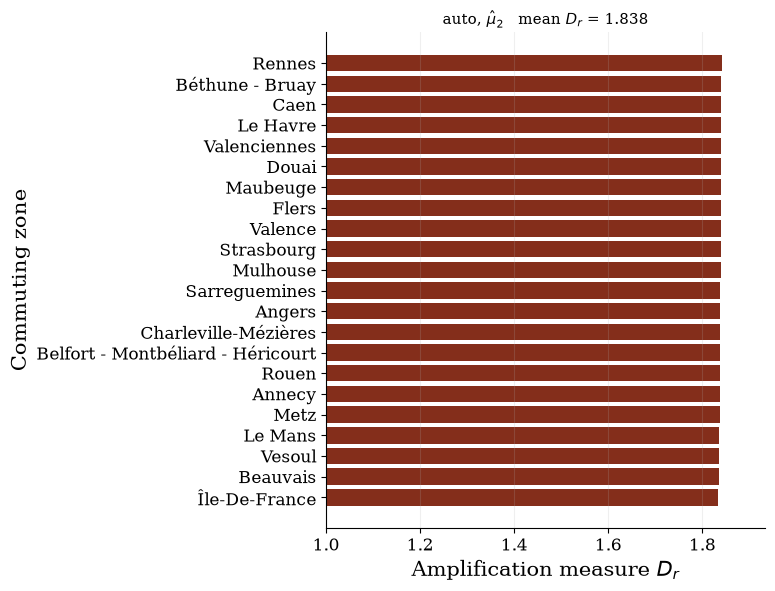

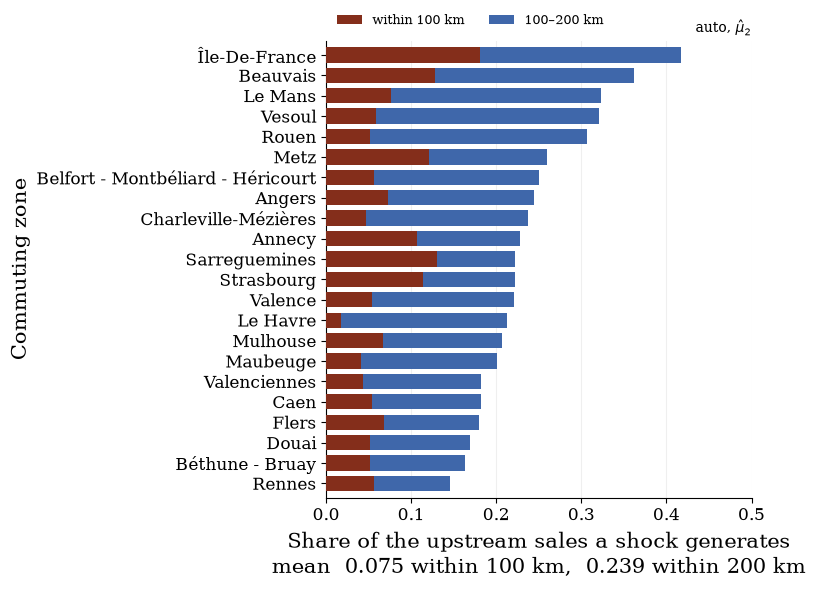

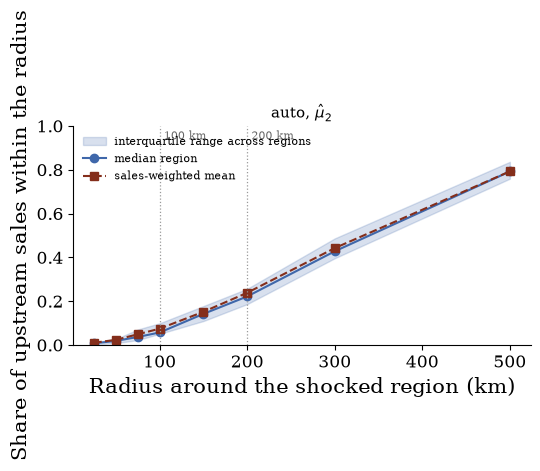

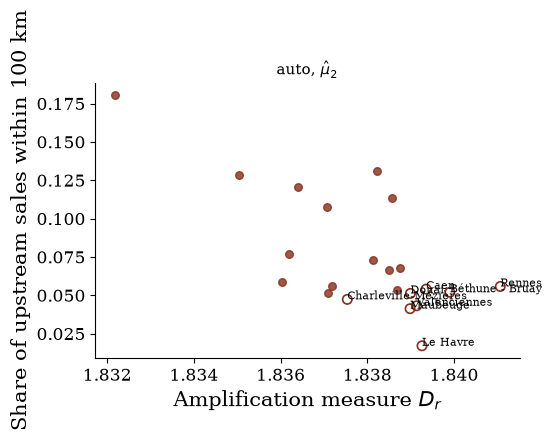

  [counterfactual] D_r is identical across regimes to 8.88e-16 (it must be: sum_l rho = 1), and matches the realised D_r to 4.44e-16
  [counterfactual] share_within_100km: realised 0.075 vs closed-form both-forces 0.074 — the gap is granularity, not a different economy


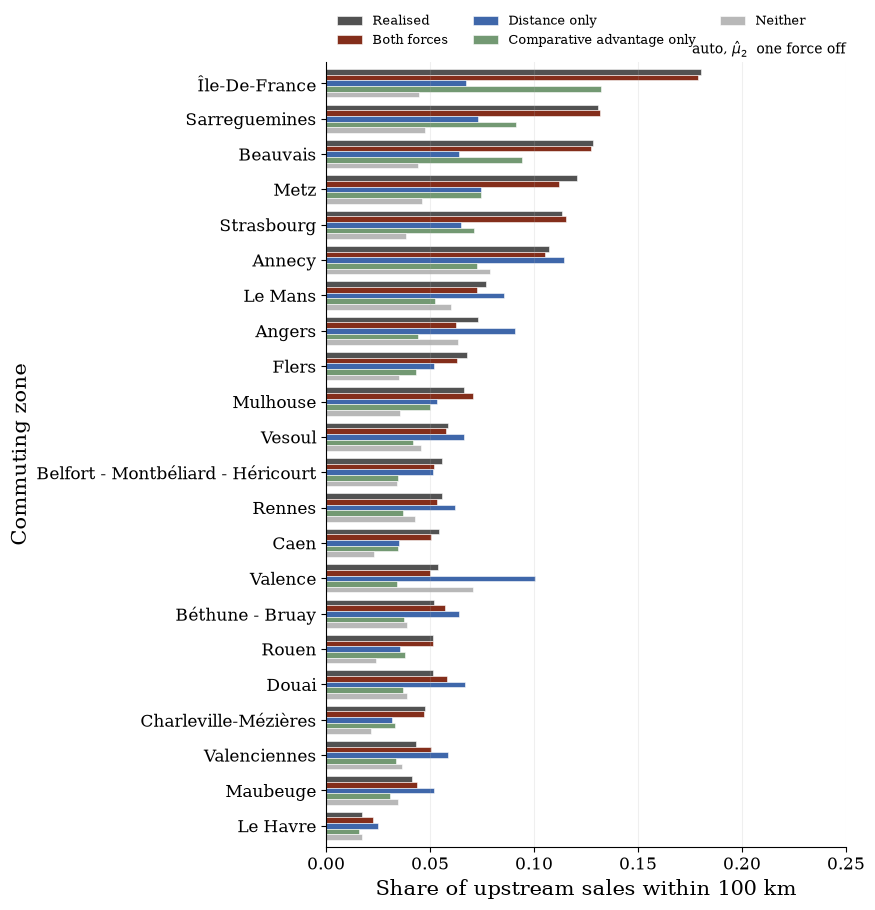

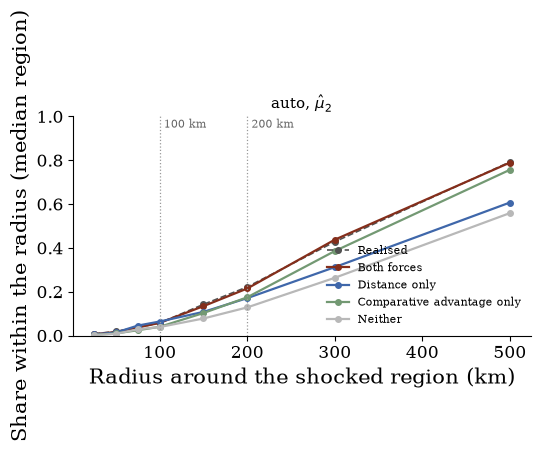


  the shock with one force switched off (D_r is the same in every regime by construction):
                            amplification  mean_upstream_distance  share_within_100km  weighted_share_within_100km  share_within_200km  weighted_share_within_200km
regime                                                                                                                                                             
Realised                            1.838                 345.846               0.075                        0.075               0.239                        0.239
Both forces                         1.838                 346.644               0.074                        0.074               0.240                        0.240
Distance only                       1.838                 411.502               0.063                        0.063               0.183                        0.183
Comparative advantage only          1.838                 369.704               0.052   

region  upstream_sales  \
ze2010_downstream regime                                                      
12                Realised                    Île-De-France           0.832   
                  Both forces                 Île-De-France           0.832   
                  Distance only               Île-De-France           0.832   
                  Comparative advantage only  Île-De-France           0.832   
                  Neither                     Île-De-France           0.832   
...                                                     ...             ...   
230               Realised                           Annecy           0.837   
                  Both forces                        Annecy           0.837   
                  Distance only                      Annecy           0.837   
                  Comparative advantage only         Annecy           0.837   
                  Neither                            Annecy           0.837   

                                              amplification  supplier_cells  \
ze2010_downstream regime                                                      
12                Realised                            1.832             273   
                  Both forces                         1.832             275   
                  Distance only                       1.832             275   
                  Comparative advantage only          1.832             275   
                  Neither                             1.832             275   
...                                                     ...             ...   
230               Realised                            1.837             272   
                  Both forces                         1.837             275   
                  Distance only                       1.837             275   
                  Comparative advantage only          1.837             275   
                  Neither                             1.837             275   

                                              mean_upstream_distance  \
ze2010_downstream regime                                               
12                Realised                                   259.337   
                  Both forces                                258.496   
                  Distance only                              351.004   
                  Comparative advantage only                 285.056   
                  Neither                                    374.579   
...                                                              ...   
230               Realised                                   331.708   
                  Both forces                                337.223   
                  Distance only                              327.725   
                  Comparative advantage only                 358.743   
                  Neither                                    352.374   

                                              share_within_100km  \
ze2010_downstream regime                                           
12                Realised                                 0.180   
                  Both forces                              0.179   
                  Distance only                            0.067   
                  Comparative advantage only               0.132   
                  Neither                                  0.045   
...                                                          ...   
230               Realised                                 0.107   
                  Both forces                              0.105   
                  Distance only                            0.114   
                  Comparative advantage only               0.072   
                  Neither                                  0.079   

                                              share_within_200km  
ze2010_downstream regime                                          
12                Realised               

[auto]  downstream industry C29A, TES from ../baseline_auto (dom), intermediate share m = 0.8448979386516853
  model  : mean D_r = 1.838  -> the modelled domestic sectors are 0.838 of downstream unit cost
  IO     : those sectors are 63.5% of the industry's DOMESTIC intermediate purchases (67.3% of dom + imp; the column is 59.0% domestic)
           => implied TOTAL intermediate share of unit cost = 1.320
           1 - aggregate labor share (the targeted moment) = 0.845
  NOTE: a COMMON intermediate share was used, so every sector's Leontief total is exactly 1/(1-m) = 6.447 and the cascade below measures that assumption, not the network. Pass a per-sector `intermediate_share` (value added / gross output) for an informative comparison.
  IO full  : round 1 = 1.845, two rounds = 2.559, Leontief total = 6.447   (model captures 15% of the aggregate, 99% of round 1)
  IO subset: round 1 = 1.845, two rounds = 2.559, Leontief total = 6.447   (model captures 15% of the aggregate, 99% of round

,n_sectors,round1,rounds_2,leontief_total,model_D_r,captured_of_aggregate,model_over_round1
support,,,,,,,
full,138,1.845,2.559,6.447,1.838,0.154,0.992
subset,10,1.845,2.559,6.447,1.838,0.154,0.992


,dom,imp,total,modelled,share_of_total,share_of_dom,pi_s_io,share_model
A129_1,,,,,,,,
C29A,1305.992,3491.482,4797.474,True,0.1602,0.0739,0.2380,0.2354
C29B,1264.404,1907.007,3171.411,True,0.1059,0.0715,0.1573,0.1577
G45Z,2368.608,0.000,2368.608,True,0.0791,0.1340,0.1175,0.1185
C28A,385.795,1799.754,2185.549,True,0.0730,0.0218,0.1084,0.1074
G46Z,1874.860,179.963,2054.823,True,0.0686,0.1060,0.1019,0.1054
C25D,1606.833,0.000,1606.833,True,0.0536,0.0909,0.0797,0.0800
C22B,841.858,514.752,1356.610,True,0.0453,0.0476,0.0673,0.0667
C33Z,1150.074,90.690,1240.764,True,0.0414,0.0650,0.0616,0.0619
M73Z,663.758,218.441,882.199,False,0.0295,0.0375,NaN,NaN


plot_io_benchmark: the cross-sector distribution is degenerate under a common intermediate share (every sector at 1/(1-m)). The figure still places the model, but the spread is an artefact — pass a per-sector `intermediate_share` for a real distribution.


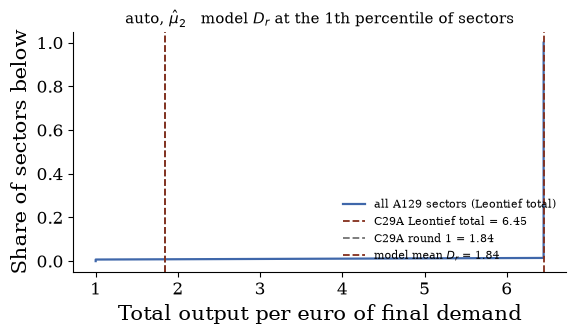

[load] G_K.csv has no row for [('C25D', 1), ('C25D', 2), ('C33Z', 1), ('G46Z', 1), ('G46Z', 2), ('M71Z', 1), ('M71Z', 2), ('M71Z', 3)]; the CDF is flat there (no mass added), so those increments are read as 0 rather than dropped.
[load] G_K_var.csv: reading column 'G' as the VARIANCE of the increment p_s(K) (no var/se column name to go on). Rename it to `var` or `se` to be explicit.
[aero, mu = 2]  mean D_r = 1.861 (one euro of demand -> 0.861 upstream), p90 = 1.870
                 share of upstream sales within 100 km: mean 0.092, median 0.056, min 0.007, max 0.421
                 share of upstream sales within 200 km: mean 0.212, median 0.194, min 0.031, max 0.603


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


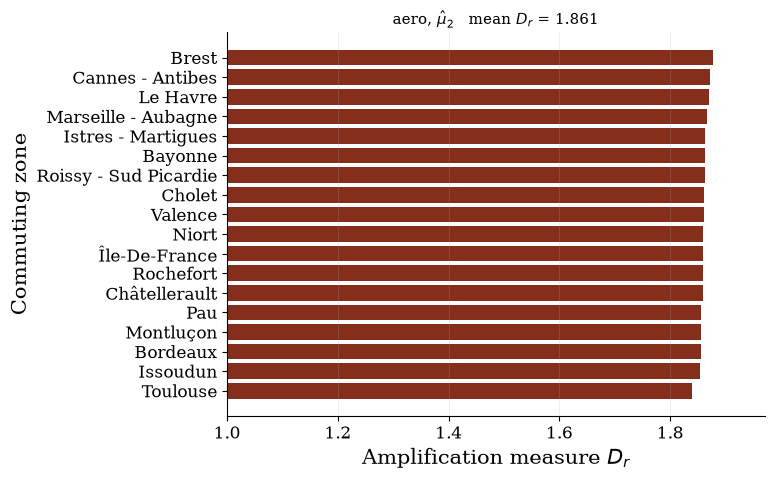

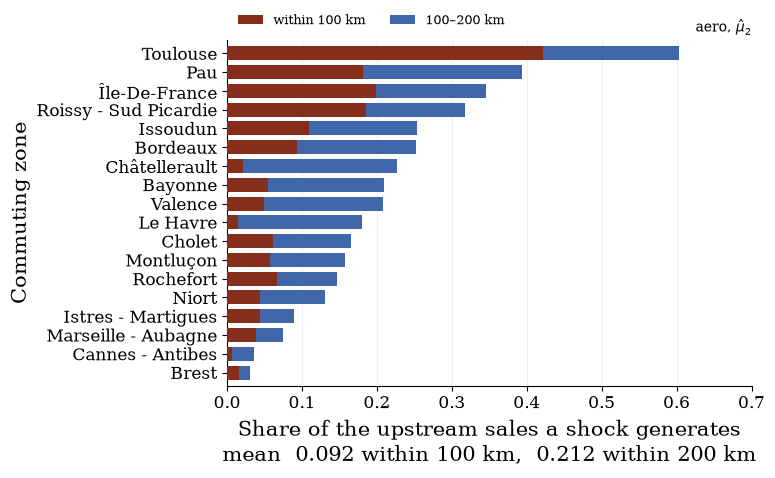

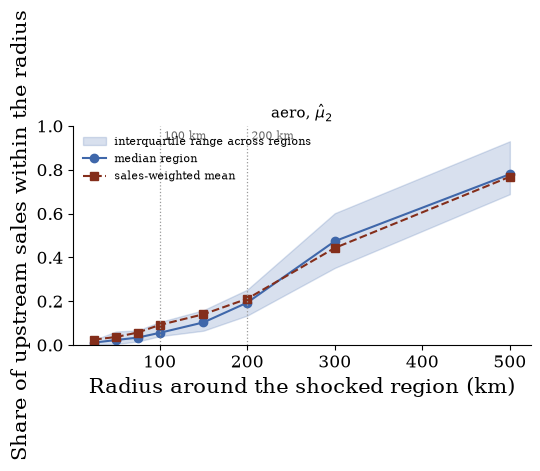

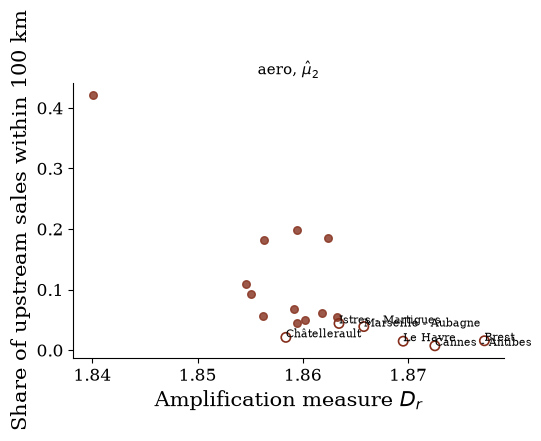

  [counterfactual] D_r is identical across regimes to 4.44e-16 (it must be: sum_l rho = 1), and matches the realised D_r to 4.44e-16
  [counterfactual] share_within_100km: realised 0.092 vs closed-form both-forces 0.089 — the gap is granularity, not a different economy


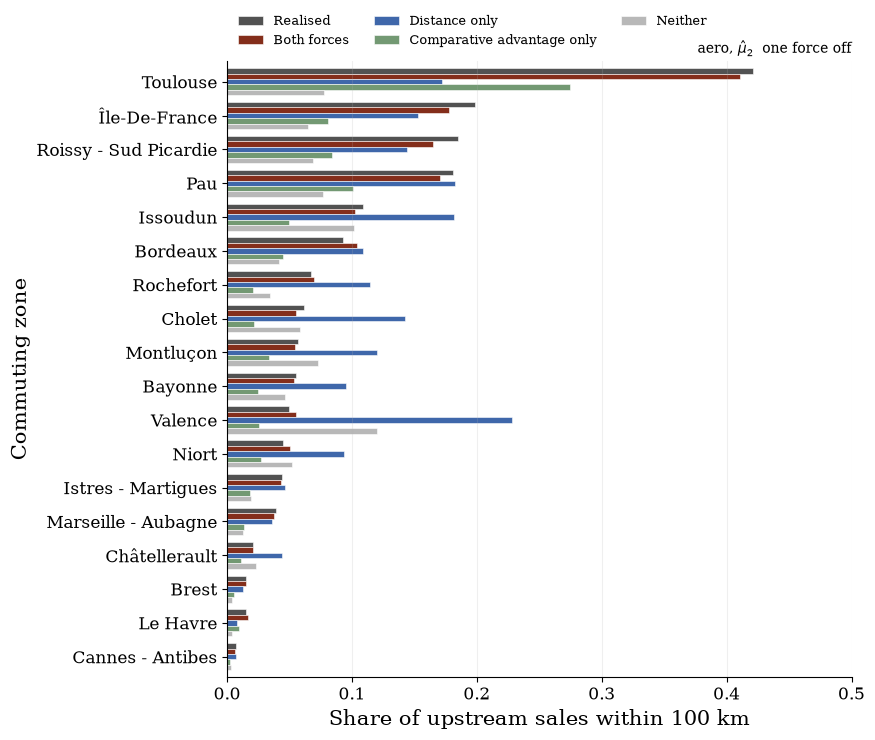

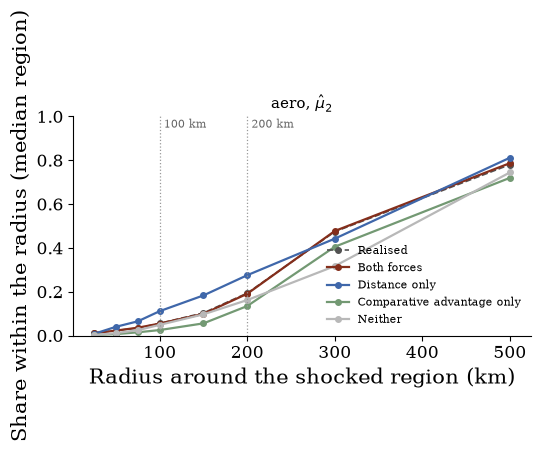


  the shock with one force switched off (D_r is the same in every regime by construction):
                            amplification  mean_upstream_distance  share_within_100km  weighted_share_within_100km  share_within_200km  weighted_share_within_200km
regime                                                                                                                                                             
Realised                            1.861                 353.554               0.092                        0.092               0.212                        0.211
Both forces                         1.861                 353.057               0.089                        0.089               0.211                        0.210
Distance only                       1.861                 354.282               0.105                        0.104               0.248                        0.247
Comparative advantage only          1.861                 386.718               0.047   

region  \
ze2010_downstream regime                                              
7                 Realised                    Roissy - Sud Picardie   
                  Both forces                 Roissy - Sud Picardie   
                  Distance only               Roissy - Sud Picardie   
                  Comparative advantage only  Roissy - Sud Picardie   
                  Neither                     Roissy - Sud Picardie   
...                                                             ...   
273               Realised                       Istres - Martigues   
                  Both forces                    Istres - Martigues   
                  Distance only                  Istres - Martigues   
                  Comparative advantage only     Istres - Martigues   
                  Neither                        Istres - Martigues   

                                              upstream_sales  amplification  \
ze2010_downstream regime                                                      
7                 Realised                             0.862          1.862   
                  Both forces                          0.862          1.862   
                  Distance only                        0.862          1.862   
                  Comparative advantage only           0.862          1.862   
                  Neither                              0.862          1.862   
...                                                      ...            ...   
273               Realised                             0.863          1.863   
                  Both forces                          0.863          1.863   
                  Distance only                        0.863          1.863   
                  Comparative advantage only           0.863          1.863   
                  Neither                              0.863          1.863   

                                              supplier_cells  \
ze2010_downstream regime                                       
7                 Realised                               261   
                  Both forces                            275   
                  Distance only                          275   
                  Comparative advantage only             275   
                  Neither                                275   
...                                                      ...   
273               Realised                               259   
                  Both forces                            275   
                  Distance only                          275   
                  Comparative advantage only             275   
                  Neither                                275   

                                              mean_upstream_distance  \
ze2010_downstream regime                                               
7                 Realised                                   386.649   
                  Both forces                                390.026   
                  Distance only                              335.206   
                  Comparative advantage only                 446.947   
                  Neither                                    388.979   
...                                                              ...   
273               Realised                                   362.103   
                  Both forces                                359.662   
                  Distance only                              375.549   
                  Comparative advantage only                 395.028   
                  Neither                                    422.797   

                                              share_within_100km  \
ze2010_downstream regime                                           
7                 Realised                                 0.185   
                  Both forces                              0.165   
                  Distance only                            0.144   

[aero]  downstream industry C30C, TES from ../baseline_aero (dom), intermediate share m = 0.8510782076751053
  model  : mean D_r = 1.861  -> the modelled domestic sectors are 0.861 of downstream unit cost
  IO     : those sectors are 72.3% of the industry's DOMESTIC intermediate purchases (80.5% of dom + imp; the column is 45.8% domestic)
           => implied TOTAL intermediate share of unit cost = 1.191
           1 - aggregate labor share (the targeted moment) = 0.851
  NOTE: a COMMON intermediate share was used, so every sector's Leontief total is exactly 1/(1-m) = 6.715 and the cascade below measures that assumption, not the network. Pass a per-sector `intermediate_share` (value added / gross output) for an informative comparison.
  IO full  : round 1 = 1.851, two rounds = 2.575, Leontief total = 6.715   (model captures 15% of the aggregate, 101% of round 1)
  IO subset: round 1 = 1.851, two rounds = 2.575, Leontief total = 6.715   (model captures 15% of the aggregate, 101% of rou

,n_sectors,round1,rounds_2,leontief_total,model_D_r,captured_of_aggregate,model_over_round1
support,,,,,,,
full,138,1.851,2.575,6.715,1.861,0.151,1.011
subset,10,1.851,2.575,6.715,1.861,0.151,1.011


,dom,imp,total,modelled,share_of_total,share_of_dom,pi_s_io,share_model
A129_1,,,,,,,,
C30C,6349.585,16899.867,23249.452,True,0.4979,0.2972,0.6184,0.6231
C33Z,4340.815,342.295,4683.110,True,0.1003,0.2032,0.1246,0.1291
C26E,12.912,2563.343,2576.255,True,0.0552,0.0006,0.0685,0.0674
G46Z,2124.009,203.879,2327.888,True,0.0499,0.0994,0.0619,0.0505
C28A,269.091,1255.322,1524.413,True,0.0326,0.0126,0.0405,0.0364
N78Z,977.000,0.000,977.000,False,0.0209,0.0457,NaN,NaN
M70Z,828.542,55.679,884.221,True,0.0189,0.0388,0.0235,0.0217
M71Z,569.876,148.231,718.107,True,0.0154,0.0267,0.0191,0.0234
C27B,110.626,468.915,579.541,True,0.0124,0.0052,0.0154,0.0212


plot_io_benchmark: the cross-sector distribution is degenerate under a common intermediate share (every sector at 1/(1-m)). The figure still places the model, but the spread is an artefact — pass a per-sector `intermediate_share` for a real distribution.


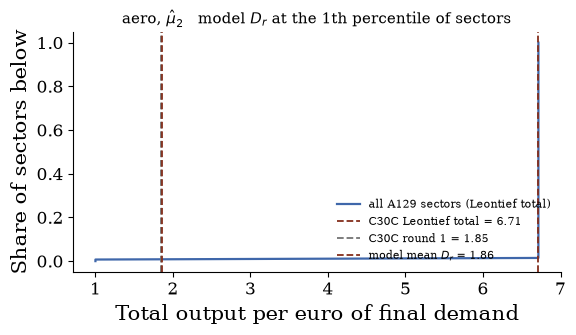

In [281]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)   # same pattern as analysis.ipynb: binds input_folder, folder,
                             # coefs, emp_gamma_ls, X_dr, best_params, france, ... by name

    # --- Amplification along vertical linkages (Figure 6) --------------------
    # radii[0] is the radius the bar chart and the scatter use; change
    # AMPLIFICATION_RADII in the Constants cell to test another one.
    summary, _ = amplification_report(data, radii=AMPLIFICATION_RADII,
                                      out_folder=out_folder)

    # --- The same shock with one force switched off, region by region --------
    # D_r is identical in every regime by construction; what moves is where the
    # euro lands, which is what these rows show.
    display(counterfactual_amplification(data, radii=AMPLIFICATION_RADII,
                                         verbose=False).round(3))

    # --- Is D_r large? the input-output benchmark ----------------------------
    # Guarded: without TESdom.csv / TESimp.csv beside the run this prints a note
    # instead of breaking the section.
    try:
        bench = io_amplification_benchmark(data, summary=summary)
        display(bench.round(3))
        display(io_downstream_column(data).head(15).round(4))
        plot_io_benchmark(data, benchmark=bench,
                          save_to=f"{out_folder}/io_benchmark_{industry}_mu{MU}.pdf")
        plt.show()
    except FileNotFoundError as e:
        print(f"  IO benchmark skipped: {e}")

# Validation of the sections above

These sections do arithmetic that is easy to get wrong *silently*: an index space
confused for another, a mask applied on the wrong axis, an estimator that converges to
a plausible-looking number that is not the one intended. None of it would raise. So each
is gated by `test/test_analysis_granular_sections.py`, which needs neither Julia nor the
real data:

```bash
python test/test_analysis_granular_sections.py
```

It writes a **synthetic run tree with the exact file layout the loader expects** and then
executes **the notebook's own code cells** against it (located by content, not by index),
so what is tested is the shipped artefact rather than a copy that can drift from it. The
reasoning behind each gate:

**Identification / sensitivity.** Two risks. The *axis*: the variety-count columns are
appended on the right of the Jacobian by Julia, so the loader has to attach the label
block to the correct end, and a silent off-by-one would move the $N_s$ derivative onto the
wrong parameters and still look reasonable. The gate plants a diagonal
$\partial \bar G_s/\partial N_s$ and requires the embedded columns to be exactly zero off
block 6 and equal to $\hat N_s\,(\partial m/\partial N)/m$ on it. The *thresholds*: a
structural zero and an unmeasurable entry are different objects and must never be pooled,
so the gate plants one entry whose Monte-Carlo standard deviation is twice its elasticity
and requires it — and only it — to be masked, while the exact zeros come back as measured.

**Untargeted moment.** Three risks. The *wiring* of the estimator: `fepois_fit` writes the
formula, passes the draw weights as analytic weights and clusters on the supplier's region,
and a mistake in any of those returns a plausible number without complaint — it is checked
against `statsmodels`' Poisson GLM with **explicit dummies**, a different algorithm for the
same estimand, agreeing to $10^{-6}$, and a continuous share-like outcome recovers a planted
elasticity (Poisson PML is a conditional-*mean* estimator, which is why shares are
admissible). The *panel*: the zeros are half the moment, so the grid must be filled to
exactly $n_{\text{firms}} \times R_d$ rows, $a_{ir}$ must sum to one per supplier, and every
distance must match `distances.npy` read by integer region index. The *structural moment*,
which is new and is arithmetic rather than estimation, so it can be gated exactly:
`attach_lambda` is checked against a direct loop over its own definition (with $T$
ref-normalised as `unpack_params` normalises it), it must refuse a panel built with an
aggregating `firm_key` (a pooled firm's productivity is a mean of draws and $\Lambda$ is not
defined pair by pair), and `structural_eta`'s two shares must equal
$\theta\Lambda/[\theta\Lambda + (\nu_s-1)(1-a)]$ and its complement and sum to one. The
granular derivation itself is gated on an economy built the way the model builds one —
Fréchet draws, the lowest-cost origin taking the whole variety, CES demand within the sector
— where the intensive PPML must return $(1-\nu_s)\alpha$ to $10^{-6}$, the extensive one must
sit within 25% of $-\theta\alpha$, $\overline{e^{-\Lambda}}$ must match the serving rate,
and pooling the varieties of a cell must collapse the extensive margin.

**Comparative advantage.** The risk is the parameter layout: `best_params` is the raw
$\theta$, whose $T$ block is s-major over the *active* $(s, a)$ pairs and includes each
sector's reference, which `unpack_params` then divides out. Read it with the wrong offset
or the wrong ordering and every number downstream is wrong but finite. The gate plants a
known $T$, checks the recovered matrix equals $T/T_{\text{ref}}$ entry by entry, and
checks the length assertion fires on a mismatch. The win probabilities are recomputed
independently from the closed form and must agree; $\alpha = 0$ must make $\rho$
buyer-invariant and proportional to $T$; equalising $T$ must leave pure gravity — the two
switches the amplification section then propagates a shock through. The variance
decomposition is an
identity, so its three shares must sum to one to machine precision. Finally a sector is
given a large planted edge and one a flat profile, and the gate checks the summary ranks
them accordingly — that the measurement responds to the thing it claims to measure.

**Amplification.** The measure is a ratio whose numerator and denominator are easy to
mismatch — the denominator is upstream sales only, the numerator a distance-truncated part
of the same sum — and a wrong distance lookup would still produce a plausible bar chart.
The gate plants a firm-level economy in which every downstream region spends a known total
on intermediates, so $D_r = 1.5$ must come back exactly; it checks the
(region $\times$ region) grid is fully zero-filled, that every distance matches
`distances.npy` read by integer index, and that $L_r(d)$ reproduces a direct count on the
same frame. Because $L_r(\cdot)$ is a CDF in the radius, the profile must be monotone with
$p_{25}\le$ median $\le p_{75}$ throughout, a 10 000 km radius must return exactly one, and
a 0 km radius must keep the shocked region alone — four properties a sign error or a
transposed distance matrix would break. A smaller radius keeping strictly less than a
larger one is the check that the radius is genuinely free rather than baked in somewhere.
The nested-bar figure is checked as a figure: two opaque bar groups, the narrower radius
drawn over the wider one, the inner bar never longer than the outer, and the outer ring
blue — the nesting is the whole message, so it is asserted rather than eyeballed.

**The shock with one force switched off.** The reallocation must not quietly become a
different economy. So the counterfactual frame has to keep the base frame's support and
its distances entry for entry; $D_r$ has to be identical under every regime AND equal to
the realised one to machine precision, which is the arithmetic consequence of
$\sum_l \rho = 1$ and the reason the section can claim a switched-off channel moves a
shock without resizing it; the *Neither* regime has to return exactly the uniform $1/n$
over the sector's modelled cells; and gravity alone has to pull sourcing strictly closer
than uniform does, which is guaranteed once $\rho$ is decreasing in distance. The
allocation itself is then recomputed from $\hat T$ and the distance matrix WITHOUT going
through `sourcing_geometry` and must agree to $10^{-12}$ — an independent path, not a
restatement of the implementation. Finally the sector column: `suppliers.parquet` stores
`A129` as the model's index $1..S$, so a file written with real A129 codes must map
through `sector_names` and anything unmappable must be named rather than silently placed
on the wrong sector, which would reallocate a sector's euros with another's $T$.

**The input-output benchmark.** Three separable risks. The *parser*: the TES CSV has
comma decimals, no header and its labels in the first column, so a silent misread would
transpose supplying and using sectors — the gate writes a known matrix out in that exact
format and requires it back, orientation included. The *normalisation*: each column of
$A$ must sum to the intermediate share it was given, scalar or per sector. The *algebra*:
under a common $m$ every column of $A$ sums to $m$, so
$\sum_i (A^k)_{ij} = m^k$ and the Leontief total must be exactly the geometric series
$1/(1-m)$ for every sector, with the truncations $1+m$ and $1+m+m^2$ — three closed
forms the gate checks to machine precision, which pins the inverse, the round
truncations and their nesting at once. It is also the reason the scalar path prints a
warning: that same identity means a common $m$ makes the cross-sector distribution
degenerate, so the cascade would be measuring the assumption rather than the network.
Finally the *coverage* numbers, which need no output data, are checked against a direct
share computation, and both an unknown downstream industry and an absent table must
raise something that names what is missing.

Two behaviours are asserted rather than assumed because they are the ones a reader would
otherwise have to take on trust: the exact zeros in the $N_s$ columns (structural, not
numerical) and the refusal to run the distance-equivalence under a binned trade cost,
where no single distance elasticity exists.

# Full Run

In [282]:
# =============================================================================
# RUN THE REPORTING — every section above, in order, on one set of flags.
#
# Each section can be run on its own from its own run cell; this cell re-executes all
# of them for a clean end-to-end pass. A new figure has to be added in BOTH places.
# =============================================================================
# mu = 1 -> step1 best parameters (theta_hat_1)
# mu = 2 -> step3 best parameters (theta_hat_2, the efficient estimate)
MU = 1

INDUSTRIES = [{"industry": "auto", "display_name": "Motor Vehicles"},
              {"industry": "aero", "display_name": "Aerospace"}]
RUN_KWARGS = dict(base="..", profile_T=True, ca_level="aa",
                  granular=True, relax_n_lo=False, optimizer="pso")

AMPLIFICATION_RADII = (100, 200)

out_folder = "../reporting_combined"
os.makedirs(out_folder, exist_ok=True)

# --- Moment table: labor share + industry shares -----------------------------
tex = generate_combined_table(INDUSTRIES, mu=MU, **RUN_KWARGS,
                              output_file=os.path.join(out_folder, f"moments_comparison_combined_mu{MU}.tex"))
print(tex)

untargeted_results, structural_results = [], []

for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"moments from {data['folder'].name}/{data['step_dir']}, "
          f"SEs from {data['inference_step']}/inference")

    # --- Fit ------------------------------------------------------------------
    plot_gamma_aa(data, save_to=f"{out_folder}/emp_sim_gamma_aa_{industry}_mu{MU}.pdf")
    plt.show()
    plot_pi_r(data, save_to=f"{out_folder}/emp_sim_pi_{industry}_mu{MU}.pdf")
    plt.show()
    plot_reg_coef(data, save_to=f"{out_folder}/emp_sim_reg_coef_{industry}_mu{MU}.pdf")
    plt.show()
    plot_G0(data, save_to=f"{out_folder}/emp_sim_G0_{industry}_mu{MU}.pdf")
    plt.show()
    display(g0_consistency(data))
    # ... and the rest of the count curve, which nothing in the criterion targets.
    cc = count_curve(data, K_values=COUNT_CURVE_K)
    # one figure per K, each in its own file; K = 0 is `plot_G0` above, which carries
    # the N_hat annotation, so only the untargeted K >= 1 are drawn here
    plot_count_curve(data, df=cc, K_values=[K for K in COUNT_CURVE_K if K > 0],
                     save_to=f"{out_folder}/emp_sim_count_curve_{industry}_mu{MU}.pdf")
    plt.show()
    display(cc.unstack("K"))

    # --- Jacobian: the triptych, the per-block panels, the summary ------------
    plot_jacobian_triptych(data, noise_max=NOISE_MAX, out_folder=out_folder,
                           tag="jacobian")
    plot_jacobian_blocks(data, save_to=f"{out_folder}/jacobian_blocks_{industry}_mu{MU}.pdf")
    plt.show()
    display(jacobian_block_summary(data, noise_max=NOISE_MAX))

    # --- Variance-covariance and correlation of the moments -------------------
    plot_variance_covariance(data, save_to=f"{out_folder}/varcov_{industry}.pdf")
    plt.show()
    plot_moment_correlation(data, save_to=f"{out_folder}/moment_correlation_{industry}.pdf")
    plt.show()
    display(variance_covariance_summary(data))

    # --- Identification / sensitivity -----------------------------------------
    plot_identification_map(
        data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX,
        save_to=f"{out_folder}/identification_map_{industry}_mu{MU}.pdf")
    plt.show()
    plot_channel_elasticities(
        data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX,
        save_to=f"{out_folder}/identification_channels_{industry}_mu{MU}.pdf")
    plt.show()
    plot_jacobian_thresholded(
        data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX,
        save_to=f"{out_folder}/jacobian_thresholded_{industry}_mu{MU}.pdf")
    plt.show()
    display(identification_summary(data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX))

    # --- Untargeted moment: measured against computed --------------------------
    panel = attach_lambda(data, build_a_ir_panel(data))
    res = estimate_untargeted_moment(data, panel=panel)
    sres = structural_eta(data, panel)
    validate_structural(data, panel, sres)
    gap = decompose_gap(data, panel, res, sres)
    within_area_check(data, panel, gap)
    untargeted_results.append(res)
    structural_results.append({**sres, **gap})
    ladder = untargeted_specification_ladder(data, panel=panel, structural=sres)
    plot_untargeted_ladder(ladder, industry,
                           save_to=f"{out_folder}/untargeted_ladder_{industry}_mu{MU}.pdf")
    plt.show()

    # --- Comparative advantage against distance: the five tests, in order ------
    plot_ca_distribution(                                            # 1 spread of T
        data, save_to=f"{out_folder}/ca_distribution_{industry}_mu{MU}.pdf")
    plt.show()
    plot_ca_distance_equivalence(                                    # 2 in distance units
        data, save_to=f"{out_folder}/ca_distance_equivalence_{industry}_mu{MU}.pdf")
    plt.show()
    plot_ca_win_margin(                                              # 3 the exact test
        data, save_to=f"{out_folder}/ca_win_margin_{industry}_mu{MU}.pdf")
    plt.show()
    display(ca_variance_decomposition(data))                         # 4 which force
    display(ca_covariance_benchmark(data))                           # 5 and the estimator
    display(comparative_advantage_summary(data))

    # --- Amplification along vertical linkages (Figure 6) ---------------------
    summary, _ = amplification_report(data, radii=AMPLIFICATION_RADII,
                                      out_folder=out_folder)
    display(counterfactual_amplification(data, radii=AMPLIFICATION_RADII,
                                         verbose=False).round(3))

    # --- Is D_r large? the input-output benchmark -----------------------------
    try:
        bench = io_amplification_benchmark(data, summary=summary)
        display(bench.round(3))
        display(io_downstream_column(data).head(15).round(4))
        plot_io_benchmark(data, benchmark=bench,
                          save_to=f"{out_folder}/io_benchmark_{industry}_mu{MU}.pdf")
        plt.show()
    except FileNotFoundError as e:
        print(f"  IO benchmark skipped: {e}")

# --- Untargeted moment: model eta against the reduced-form delta/gamma -------
plot_untargeted_moment(untargeted_results,
                       save_to=f"{out_folder}/untargeted_eta_mu{MU}.pdf")
plt.show()
plot_structural_vs_measured(structural_results,
                            save_to=f"{out_folder}/untargeted_structural_mu{MU}.pdf")
plt.show()
display(structural_summary(structural_results))
display(untargeted_summary(untargeted_results))
display(comparative_advantage_glossary())


FileNotFoundError: run folder ../reporting_auto_profiled_aa_gran_pso not found — check profile_T / ca_level / granular / relax_n_lo / optimizer against main.jl's naming